# Predviđanje godišnje kompenzacije programera

### Stack Overflow Developer Survey 2025 · seminarski rad

Rad je nastao u pet koraka koji su rađeni jedan za drugim — opis skupa podataka, izbor i provera ciljne
promenljive, čišćenje, izvođenje novih promenljivih i modelovanje — i ovde su spojeni u jedan dokument.
Svaki od njih zadržava svoj tok: motivacija, kod, rezultat izvršenja i tumačenje.

Sekcije su numerisane redom, **od 1 do 43**, a grafici **od 1 do 37**. Tabela na kraju sekcije 7 kaže
koji deo pokriva koje sekcije.

# Stack Overflow Developer Survey 2025: opis skupa podataka

## Uvod

Koliko programer zarađuje zavisi od mnogo stvari odjednom — od zemlje u kojoj radi, od toga koliko dugo
radi, od tehnologija koje koristi, od veličine firme. Neke od tih stvari se daju izmeriti, druge se ne
mere uopšte. Pitanje koje ovaj rad postavlja je koliko se razlike u platama mogu objasniti onim što se
izmeriti **može**.

Smisao takvog modela nije da nekome predvidi platu na dolar. Pre je u tome da pokaže **koja obeležja i
koliko** nose razliku: da li više znači zemlja ili iskustvo, da li se poznavanje pojedinih tehnologija
vidi na plati, i koliko od razlike ostane neobjašnjeno.

Za to koristimo **Stack Overflow Developer Survey 2025**, godišnju anketu koju Stack Overflow sprovodi
među programerima širom sveta. Rad je u Python-u, sa `pandas` za obradu i `matplotlib` i `seaborn` za
grafike.

Ovaj deo je **prvi pogled na podatke**. Njegov posao je da opiše šta u skupu ima: odakle dolazi,
kako je složen, koliko mu vrednosti nedostaje i koje kolone su kandidati za ono što bismo predviđali.
Nijedna odluka o čišćenju, izboru ciljne promenljive ili modelu se ovde ne donosi — plan daljih koraka je u sekciji 7.

## 1. Izvor podataka i prvi pogled

Anketu Stack Overflow objavljuje javno svake godine. Skup za 2025. preuzimamo sa **Kaggle platforme**, i
to **programski** — funkcija `download_raw` iz `src/data_loader.py` preuzima fajlove preko biblioteke
`kagglehub` i kopira ih u `data/raw/`.

Zašto se kopiraju lokalno: preuzimanje se radi **jednom**, pa svako sledeće pokretanje čita isti lokalni
snimak. Kad bi se svaki put išlo na Kaggle, dataset bi se u međuvremenu mogao izmeniti i brojevi u tekstu prestali bi da odgovaraju tekstu. Zbog toga `data/raw/` i nije u git-u — podaci se dobijaju
pokretanjem koda.

Preuzimaju se dva fajla: `survey_results_public.csv` sa odgovorima i `survey_results_schema.csv` sa
šemom ankete. Pre nego što bilo šta kažemo o sadržaju, pogledajmo dimenzije, tipove kolona i nekoliko
stvarnih vrednosti.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import KAGGLE_DATASET, load_raw

responses, schema = load_raw()


def is_text(series):
    """True for columns pandas stores as strings, whichever string dtype it uses."""
    return series.dtype.kind in "OU" or str(series.dtype) in ("str", "string")


print(f"skup na Kaggle-u: {KAGGLE_DATASET}")
print()
print(f"odgovori:  {responses.shape[0]:>6,} redova x {responses.shape[1]:>3} kolona")
print(f"šema:      {schema.shape[0]:>6,} redova x {schema.shape[1]:>3} kolone   "
      f"{list(schema.columns)}")
print()
print(f"jedinstvenih vrednosti u ResponseId: {responses['ResponseId'].nunique():,}")
print(f"potpuno dupliranih redova:           {int(responses.duplicated().sum())}")
print()
print("tipovi kolona u odgovorima:")
for dtype, count in responses.dtypes.value_counts().items():
    print(f"  {str(dtype):<10} {count:>3}")
print()
print("prvih pet redova i prvih šest kolona, da se vidi kako vrednosti izgledaju:")
print(responses.iloc[:5, :6].to_string())

skup na Kaggle-u: edoardogalli/stack-overflow-annual-developer-survey-2025

odgovori:  49,123 redova x 170 kolona
šema:         139 redova x   6 kolone   ['qid', 'qname', 'question', 'type', 'sub', 'sq_id']

jedinstvenih vrednosti u ResponseId: 49,123


potpuno dupliranih redova:           0

tipovi kolona u odgovorima:
  str        119
  float64     50
  int64        1

prvih pet redova i prvih šest kolona, da se vidi kako vrednosti izgledaju:
   ResponseId                      MainBranch              Age                                          EdLevel                                            Employment                                   EmploymentAddl
0           1  I am a developer by profession  25-34 years old  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                              Employed  Caring for dependents (children, elderly, etc.)
1           2  I am a developer by profession  25-34 years old              Associate degree (A.A., A.S., etc.)                                              Employed                                              NaN
2           3  I am a developer by profession  35-44 years old     Bachelor’s degree (B.A., B.S., B.Eng., etc.)  Independent contractor, freelancer, or self-emp

**Zapažanje:** odgovori imaju **49.123 reda i 170 kolona**. `ResponseId` ima tačno **49.123** različite
vrednosti i nema ni jednog potpuno dupliranog reda, pa je red jedan ispitanik. Šema ima **139 redova i 6
kolona**: `qid`, `qname`, `question`, `type`, `sub`, `sq_id`.

Od 170 kolona odgovora **119 su tekstualne**, **50 brojčane** i jedna celobrojna.

U prikazanom uglu tabele svih pet ispitanika je na pitanje `MainBranch` odgovorilo
`I am a developer by profession`. Vrednosti u ostalim kolonama su duže, ali izgledaju kao ponuđeni
odgovori a ne kao slobodan tekst — `Master's degree (M.A., M.S., M.Eng., MBA, etc.)`,
`Independent contractor, freelancer, or self-employed`, `None of the above`. U drugom redu je
`EmploymentAddl` **prazan**, pa se praznine vide već u prvih pet redova.

**Tumačenje:** dimenzije su za rad ovog obima dobre — pedeset hiljada redova je dovoljno da se skup deli
na trening i test, a i da se podgrupe posmatraju odvojeno.

Ono što odmah traži objašnjenje je **broj tekstualnih kolona**. Sto devetnaest od sto sedamdeset je dve
trećine, a anketa ne izgleda kao da traži eseje — u prikazanom uglu su svi odgovori kratki i izgledaju
kao izbor iz spiska. Zašto su onda tekstualne, iz ovoga se ne vidi, i to je prvo što treba proveriti.

Broj 139 u šemi i 170 u odgovorima se ne poklapaju, pa i to treba razjasniti.

## 2. Šta je u tekstualnim kolonama

Da bismo videli šta tekstualne kolone sadrže, ne biramo ih po osećaju nego po meri: gledamo one sa
**najviše različitih vrednosti**. Ako je negde slobodan tekst, biće tamo, jer slobodan tekst skoro nikad
ne daje istu vrednost dvaput.

Uz broj različitih vrednosti ispisujemo i po jednu stvarnu vrednost iz svake, da se vidi kako izgleda.

In [2]:
text_columns = [c for c in responses.columns if is_text(responses[c])]
distinct = pd.Series({c: responses[c].nunique() for c in text_columns}).sort_values(ascending=False)

print(f"tekstualnih kolona: {len(text_columns)}")
print()
print("pet sa najviše različitih vrednosti, i po jedna stvarna vrednost iz svake:")
for name, count in distinct.head(5).items():
    example = str(responses[name].dropna().iloc[0])
    print(f"  {name:<24} {count:>6} razl.")
    print(f"      {example[:96]}")

tekstualnih kolona: 119

pet sa najviše različitih vrednosti, i po jedna stvarna vrednost iz svake:
  AIOpen                    20123 razl.
      Troubleshooting, profiling, debugging
  PlatformHaveWorkedWith    18782 razl.
      Amazon Web Services (AWS);Cloudflare;Firebase;Google Cloud;Gradle
  LanguageHaveWorkedWith    15467 razl.
      Bash/Shell (all shells);Dart;SQL
  LanguageWantToWorkWith    13724 razl.
      Dart
  PlatformWantToWorkWith    13329 razl.
      Amazon Web Services (AWS);Datadog;Docker;Homebrew;Kubernetes;Maven (build tool);Terraform


**Zapažanje:** kolona sa najviše različitih vrednosti je **`AIOpen`, sa 20.123**, i njena vrednost u
primeru je `Troubleshooting, profiling, debugging` — rečenica, bez ikakve pravilne strukture.

Odmah iza nje su **`PlatformHaveWorkedWith` (18.782)** i **`LanguageHaveWorkedWith` (15.467)**, i njihove
vrednosti izgledaju drugačije:
`Amazon Web Services (AWS);Cloudflare;Firebase;Google...` i `Bash/Shell (all shells);Dart;SQL`. To nisu
rečenice nego **spiskovi, sa tačka-zarezom između stavki**.

**Tumačenje:** dve vrste tekstualnih kolona, dakle, izgledaju sasvim različito. Jedna je slobodan tekst,
druga je više izabranih odgovora spojenih u jedan string.

Ako je to tako, onda tačka-zarez nije slučajan znak u tim vrednostima nego **razdvajač**, i mora se
javljati sistematski — u istim kolonama, kod većine odgovora. To je nešto što se može proveriti, pa
prelazimo na proveru.

### Grafik 1 — šta se dobije kad se vrednost razdvoji po tačka-zarezu

**Motivacija:** ako je tačka-zarez razdvajač, onda ono što nas zanima nisu vrednosti u koloni nego
**stavke** u njima. Zato prvo brojimo u koliko se tekstualnih kolona tačka-zarez javlja i kod kolikog
dela odgovora, a onda najširu takvu kolonu razdvojimo i nacrtamo najčešće stavke — da vidimo šta se time
dobija.

od 119 tekstualnih kolona, tačka-zarez se javlja:
  u bar 1% odgovora:  57 kolona
  u bar 50% odgovora: 47 kolona
  ni u jednom:        41 kolona



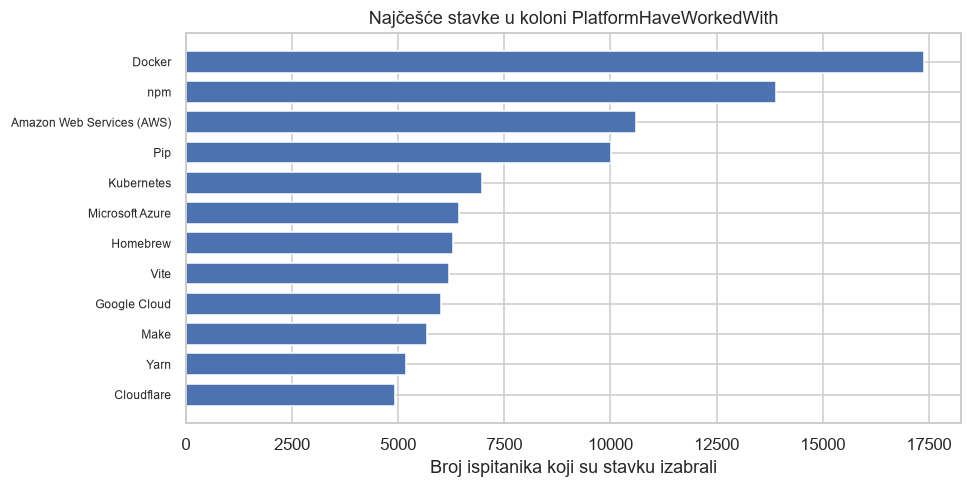

kolona PlatformHaveWorkedWith:
  odgovorilo:                          24,234 ispitanika
  različitih vrednosti u koloni:       18,782
  različitih stavki posle razdvajanja: 42
  najviše stavki u jednom odgovoru:    42
  tri najčešće stavke:
    Docker                               17,396
    npm                                  13,892
    Amazon Web Services (AWS)            10,605


In [3]:
semicolon_share = pd.Series({c: responses[c].dropna().astype(str).str.contains(";").mean()
                             for c in text_columns})

print(f"od {len(text_columns)} tekstualnih kolona, tačka-zarez se javlja:")
print(f"  u bar 1% odgovora:  {int((semicolon_share > 0.01).sum())} kolona")
print(f"  u bar 50% odgovora: {int((semicolon_share > 0.5).sum())} kolona")
print(f"  ni u jednom:        {int((semicolon_share == 0).sum())} kolona")
print()

# The widest column among those that hold lists, chosen by measurement rather
# than picked out: most distinct values among the columns with semicolons.
list_columns = list(semicolon_share[semicolon_share > 0.5].index)
widest = distinct[list_columns].idxmax()
items = responses[widest].dropna().str.split(";").explode()
counts = items.value_counts()

fig, ax = plt.subplots(figsize=(9, 4.6))
top_items = counts.head(12).iloc[::-1]
ax.barh(range(len(top_items)), top_items.to_numpy(), color="#4C72B0", height=0.72)
ax.set_yticks(range(len(top_items)))
ax.set_yticklabels([str(name)[:30] for name in top_items.index], fontsize=8)
ax.set_xlabel("Broj ispitanika koji su stavku izabrali")
ax.set_title(f"Najčešće stavke u koloni {widest}")
plt.tight_layout()
plt.show()

print(f"kolona {widest}:")
print(f"  odgovorilo:                          {responses[widest].notna().sum():,} ispitanika")
print(f"  različitih vrednosti u koloni:       {responses[widest].nunique():,}")
print(f"  različitih stavki posle razdvajanja: {counts.size}")
print(f"  najviše stavki u jednom odgovoru:    {int(items.groupby(level=0).size().max())}")
print("  tri najčešće stavke:")
for name, count in counts.head(3).items():
    print(f"    {str(name)[:34]:<36} {count:>6,}")

**Zapažanje:** provera potvrđuje da tačka-zarez nije slučajan. Od **119** tekstualnih kolona, u **57** se
javlja u bar jednom procentu odgovora, u **47** u više od polovine, a u **41** ga nema ni u jednom
odgovoru.

Razdvajanje daje čitljiv rezultat. Kolona `PlatformHaveWorkedWith` ima **18.782** različite vrednosti, ali
posle razdvajanja svega **42** različite stavke, od kojih su najčešće `Docker` (**17.396** ispitanika),
`npm` (**13.892**) i `Amazon Web Services (AWS)` (**10.605**). Odgovorilo je **24.234** ispitanika, a
jedan je izabrao svih **42** stavke.

**Tumačenje:** ovim je odgovoreno pitanje iz prethodne sekcije. Kolone nisu tekstualne zato što anketa
traži eseje, nego zato što je kod pitanja sa više dozvoljenih odgovora **ceo izbor jednog ispitanika
sačuvan kao jedan string**. Takvih kolona je 47, dakle skoro trećina svih.

Za dalji rad to znači da se takva kolona ne može uzeti kao obična kategorijska. Ako bi svaka različita
vrednost bila jedna kategorija, `PlatformHaveWorkedWith` bi dala 18.782 kategorije — a iza njih stoji
svega 42 stavke. Nešto se iz tih kolona mora izvesti, a šta i kako, nije stvar ovog dela.

Slobodan tekst je drugi slučaj i ovde ga samo beležimo: `AIOpen` sa dvadeset hiljada različitih odgovora
nije nešto što se razdvaja po tačka-zarezu.

## 3. Struktura ankete

Ostaje razlika između 139 redova šeme i 170 kolona odgovora. Šema je fajl u kome za pitanja iz ankete
stoji oznaka, pun tekst i **tip**, pa ćemo strukturu pročitati odatle.

Da bi se videlo koliko kolona nosi koji tip, svaku kolonu odgovora treba vezati za pitanje iz šeme.
Vezujemo po imenu: kolona pripada onom pitanju čije je ime **najduži početak** njenog imena. Najduži, a
ne bilo koji, jer se imena pitanja preklapaju — `AIModels` je početak i imena `AIModelsHaveWorkedWith`,
pa bi kraće ime pokupilo kolone koje mu ne pripadaju.

Uz to prikazujemo i **tabelu svih pitanja**, sa po jednim redom na pitanje. Tabela je duga, pa stoji u okviru koji se skroluje; ista tabela se izvozi i u `column_overview.csv`, gde se čita bez
skrolovanja.

In [4]:
questions = schema.drop_duplicates(subset="qname").set_index("qname")
questions.index = questions.index.astype(str)
# Longest first, so a question name never claims another question's columns.
by_length = sorted(questions.index, key=len, reverse=True)


def owning_question(column):
    """The question this column was exported from, if the schema knows one."""
    if column in questions.index:
        return column
    for name in by_length:
        if column.startswith(name):
            return name
    return None


def clean_text(value):
    """The question text with its HTML tags and line breaks taken out."""
    return "" if pd.isna(value) else re.sub(r"<[^>]+>|\s+", " ", str(value)).strip()


owner = pd.Series({column: owning_question(column) for column in responses.columns})
missing_share = responses.isna().mean().mul(100)

print(f"kolona odgovora: {len(owner)}")
print(f"  vezanih za pitanje iz šeme: {int(owner.notna().sum())}")
print(f"  bez pitanja u šemi:         {int(owner.isna().sum())}   "
      f"{list(owner[owner.isna()].index)}")
print()

linked = pd.DataFrame({"kolona": owner.index, "pitanje": owner.to_numpy()}).dropna()
linked["tip"] = linked["pitanje"].map(questions["type"])
by_type = linked.groupby("tip").agg(pitanja=("pitanje", "nunique"), kolona=("kolona", "size"))
by_type["kolona_po_pitanju"] = (by_type["kolona"] / by_type["pitanja"]).round(1)
print("koliko kolona nosi koji tip pitanja:")
print(by_type.to_string())
print(f"  ukupno {int(by_type['kolona'].sum())} kolona iz {int(by_type['pitanja'].sum())} pitanja")
print()

per_question = linked.groupby("pitanje").size()
print(f"pitanja koja daju tačno jednu kolonu: {int((per_question == 1).sum())} od {len(per_question)}")
print("pitanja izvezena kroz najviše kolona:")
for name, count in per_question.nlargest(3).items():
    print(f"  {name:<20} {count} kolona   ({questions.loc[name, 'type']})")
print()
print("po jedno pitanje svakog tipa, sa punim tekstom:")
for kind in sorted(questions["type"].dropna().unique()):
    row = questions[questions["type"] == kind].iloc[0]
    print(f"  {kind:<7} {row.name:<22} {clean_text(row['question'])[:64]}")
print()
print("da li ova dva pitanja imaju tekst u šemi:")
for name in ("CompTotal", "ConvertedCompYearly"):
    text = clean_text(questions.loc[name, "question"]) if name in questions.index else None
    print(f"  {name:<22} u šemi: {name in questions.index:<6} tekst: "
          f"{'—' if not text else text[:46]}")

kolona odgovora: 170
  vezanih za pitanje iz šeme: 168
  bez pitanja u šemi:         2   ['ResponseId', 'ConvertedCompYearly']

koliko kolona nosi koji tip pitanja:
        pitanja  kolona  kolona_po_pitanju
tip                                       
MC           48      48                1.0
Matrix       13      44                3.4
RO           47      47                1.0
TE           29      29                1.0
  ukupno 168 kolona iz 137 pitanja

pitanja koja daju tačno jednu kolonu: 124 od 137
pitanja izvezena kroz najviše kolona:
  AIAgentChallenges    5 kolona   (Matrix)
  AIAgentImpact        5 kolona   (Matrix)
  AITool               5 kolona   (Matrix)

po jedno pitanje svakog tipa, sa punim tekstom:
  MC      MainBranch             Are you someone who writes code? Please select one of the follow
  Matrix  Language               Which  programming, scripting, and markup languages  have you do
  RO      TechEndorse_1          What attracts you to a technology or causes you

In [5]:
# One row per question: what it is called, its type, how many columns it takes,
# and how much of it is missing. Long, so it goes in a box that scrolls.
overview = (linked.groupby("pitanje")
            .agg(kolona=("kolona", "size"))
            .join(questions[["type", "sub"]])
            .rename(columns={"type": "tip", "sub": "stavka"}))
overview["praznine_%"] = [round(missing_share[linked.loc[linked["pitanje"] == name, "kolona"]].mean(), 1)
                          for name in overview.index]
overview["pitanje"] = [clean_text(questions.loc[name, "question"])[:140] for name in overview.index]
overview = overview[["tip", "kolona", "praznine_%", "stavka", "pitanje"]].sort_index()

display(HTML(
    "<div style='max-height:420px; overflow-y:auto; border:1px solid #ddd; padding:4px'>"
    + overview.to_html(border=0)
    + "</div>"))
print(f"pitanja u tabeli: {len(overview)}")

# The same thing per column rather than per question, for reading outside the notebook.
per_column = pd.DataFrame({
    "column": responses.columns,
    "dtype": [str(responses[c].dtype) for c in responses.columns],
    "unique_values": [responses[c].nunique() for c in responses.columns],
    "missing_percent": missing_share.round(1).to_numpy(),
    "question_type": [questions.loc[owner[c], "type"] if pd.notna(owner[c]) else ""
                      for c in responses.columns],
    "question": [clean_text(questions.loc[owner[c], "question"]) if pd.notna(owner[c]) else ""
                 for c in responses.columns],
})
overview_path = Path.cwd().parent / "data" / "processed" / "column_overview.csv"
per_column.to_csv(overview_path, index=False, encoding="utf-8")
print(f"pun pregled po kolonama sačuvan: {overview_path.name} "
      f"({per_column.shape[0]} redova x {per_column.shape[1]} kolone)")

,tip,kolona,praznine_%,stavka,pitanje
pitanje,,,,,
AIAcc,MC,1,32.3,NaN,How much do you trust the accuracy of the output from AI tools as part of your development workflow?
AIAgentChallenges,Matrix,5,64.3,NaN,To what extent do you agree with the following statements regarding AI agents?
AIAgentChange,MC,1,35.6,NaN,Have AI tools or AI agents changed how you complete development work in the past year?
AIAgentExtWrite,TE,1,98.3,NaN,"Was the out-of-the-box agents, copilots or assistants you used in the past year not listed above? Please write them below separated by a com"
AIAgentExternal,MC,1,83.1,NaN,"You indicated you use or develop AI agents as part of your development work. Have you used any of the following out-of-the-box agents, copil"
AIAgentImpact,Matrix,5,85.3,NaN,To what extent do you agree with the following statements regarding the impact of AI agents on your work as a developer?
AIAgentKnowWrite,TE,1,98.4,NaN,Was the tool or tools for AI agent orchestration or agent frameworks you used in the past year not listed above? Please write them below sep
AIAgentKnowledge,MC,1,93.1,NaN,You indicated you use or develop AI agents as part of your development work. Have you used any of the following tools for AI agent memory or
AIAgentObsWrite,TE,1,99.5,NaN,"Was the tool or tools for AI agent observability, monitoring or security you used in the past year not listed above? Please write them below"


pitanja u tabeli: 137
pun pregled po kolonama sačuvan: column_overview.csv (170 redova x 6 kolone)


**Zapažanje:** od 170 kolona, **168 je vezano za pitanje iz šeme**, a dve nisu: `ResponseId` i
`ConvertedCompYearly`.

Tih 168 kolona dolazi iz **137 pitanja**, po tipovima:

| tip | pitanja | kolona | kolona po pitanju |
| --- | --- | --- | --- |
| `MC` | 48 | 48 | 1,0 |
| `Matrix` | 13 | 44 | 3,4 |
| `RO` | 47 | 47 | 1,0 |
| `TE` | 29 | 29 | 1,0 |

**124 od 137 pitanja daje tačno jednu kolonu.** Šire se samo pitanja tipa `Matrix`, najviše
`AIAgentChallenges`, `AIAgentImpact` i `AITool`, sa po pet kolona.

Poslednji deo ispisa gleda dve kolone koje se po imenu tiču kompenzacije: **`CompTotal` ima tekst
pitanja u šemi, a `ConvertedCompYearly` ga nema.**

**Tumačenje:** razlika 139 naspram 170 je time razjašnjena. Pitanje tipa `Matrix` je u anketi jedna
tabela, ali u podacima postaje nekoliko kolona; kod `Language` su to tri kolone. Zato je pitanja manje
nego kolona, a razlika je gotovo cela u tih trinaest matričnih pitanja.

Tipovi usput objašnjavaju i nalaz iz druge sekcije. `MC` je „Multiple Choice", pitanje sa jednim ili više
dozvoljenih odgovora, i takvih je 48 — u tu grupu spadaju i kolone sa tačka-zarezom iz druge sekcije, ali
i pitanja sa jednim odgovorom, kao `MainBranch`. `RO` je „Rank Order", i
tih 47 pitanja su pojedinačne stavke koje se rangiraju; ime im se završava brojem, kao `TechEndorse_1`, a
kolona `stavka` u tabeli pokazuje koju stavku svako od njih rangira. `TE` je „Text Entry", gde ispitanik
upisuje vrednost.

Ostaje jedna stvar koju **ne možemo da razjasnimo iz šeme**: zašto `ConvertedCompYearly` nema tekst
pitanja. Ime sugeriše da je u vezi sa `CompTotal`, ali odsustvo teksta samo po sebi ne kaže odakle ta
kolona dolazi ni kako je dobijena. To je pitanje koje ostavljamo otvoreno i vraćamo mu se kad budemo
birali šta se predviđa.

## 4. Ko je odgovorio na anketu

Problem koji smo u uvodu postavili tiče se plata **širom sveta**, pa je prvo što o uzorku treba znati
odakle su ispitanici i čime se bave.

Uz to nas zanima i koja su pitanja **skoro svi** odgovorili, jer se odatle vidi šta je u anketi
obavezno a šta ne. Te kolone ne biramo unapred nego ih uzimamo po meri: one sa najmanje praznih
vrednosti.

### Grafik 2 — sastav uzorka

**Motivacija:** ako je uzorak pretežno iz jedne zemlje ili iz jedne vrste posla, to oblikuje sve što se
kasnije o platama može reći. Crtamo dve slike: odakle su ispitanici i kako su odgovorili na pitanje koje
je u anketi prvo i obavezno.

deset kolona sa najmanje praznih vrednosti:
  ResponseId           0.0% praznih   49123 razl.   
  MainBranch           0.0% praznih       6 razl.   Are you someone who writes code? Please sele
  Age                  0.0% praznih       7 razl.   What is your age?
  Employment           1.7% praznih       6 razl.   Which of the following best describes your c
  EdLevel              2.1% praznih       8 razl.   Which of the following best describes the hi
  LearnCodeChoose      4.7% praznih       3 razl.   Did you begin learning to code or learn a ne
  LearnCodeAI          8.1% praznih       5 razl.   Did you spend time in the last year learning
  EmploymentAddl       8.8% praznih     171 razl.   Which of the following  additional  activiti
  DevType             11.2% praznih      32 razl.   Which of the following describes your curren
  YearsCode           12.5% praznih      78 razl.   Including any education, how many years have



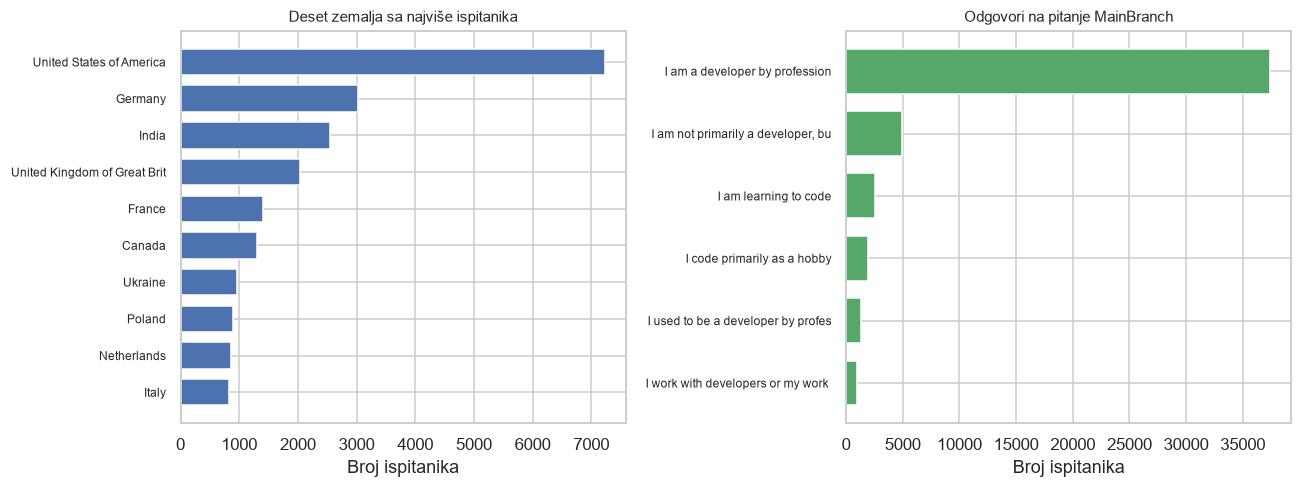

zemalja u anketi: 177   praznih u koloni Country: 27.9%
  United States of America                    7,226 (20.4%)
  Germany                                     3,022 ( 8.5%)
  India                                       2,542 ( 7.2%)
  prvih deset zemalja nosi 59.6% odgovorenih
  zemalja sa manje od 100 ispitanika: 124

MainBranch:
  I am a developer by profession                         37,418 (76.2%)
  I am not primarily a developer, but I write code som    4,888 (10.0%)
  I am learning to code                                   2,580 ( 5.3%)
  I code primarily as a hobby                             1,920 ( 3.9%)
  I used to be a developer by profession, but no longe    1,322 ( 2.7%)
  I work with developers or my work supports developer      995 ( 2.0%)


In [6]:
print("deset kolona sa najmanje praznih vrednosti:")
for name, value in missing_share.nsmallest(10).items():
    text = clean_text(questions.loc[name, "question"])[:44] if name in questions.index else ""
    print(f"  {name:<18} {value:>5.1f}% praznih   {responses[name].nunique():>5} razl.   {text}")
print()

countries = responses["Country"].value_counts()
branches = responses["MainBranch"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
top_countries = countries.head(10).iloc[::-1]
ax.barh(range(len(top_countries)), top_countries.to_numpy(), color="#4C72B0", height=0.72)
ax.set_yticks(range(len(top_countries)))
ax.set_yticklabels([name[:28] for name in top_countries.index], fontsize=8)
ax.set_xlabel("Broj ispitanika")
ax.set_title("Deset zemalja sa najviše ispitanika", fontsize=10)

ax = axes[1]
ordered = branches.iloc[::-1]
ax.barh(range(len(ordered)), ordered.to_numpy(), color="#55A868", height=0.72)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels([name[:34] for name in ordered.index], fontsize=8)
ax.set_xlabel("Broj ispitanika")
ax.set_title("Odgovori na pitanje MainBranch", fontsize=10)

plt.tight_layout()
plt.show()

print(f"zemalja u anketi: {countries.size}   praznih u koloni Country: "
      f"{missing_share['Country']:.1f}%")
for name, count in countries.head(3).items():
    print(f"  {name[:40]:<42} {count:>6,} ({100 * count / countries.sum():>4.1f}%)")
print(f"  prvih deset zemalja nosi {100 * countries.head(10).sum() / countries.sum():.1f}% odgovorenih")
print(f"  zemalja sa manje od 100 ispitanika: {int((countries < 100).sum())}")
print()
print("MainBranch:")
for name, count in branches.items():
    print(f"  {str(name)[:52]:<54} {count:>6,} ({100 * count / len(responses):>4.1f}%)")

**Zapažanje:** kolone sa najmanje praznina su **`ResponseId`, `MainBranch` i `Age` — sve tri bez ijedne
praznine** — pa `Employment` sa **1,7%** i `EdLevel` sa **2,1%**. Sve su to pitanja o samom ispitaniku, i
sva su na početku ankete.

Na pitanje `MainBranch` je **37.418 ispitanika, odnosno 76,2%**, odgovorilo da su programeri po zanimanju.
Ostatak je raspoređen na one kojima programiranje nije glavni posao (**10,0%**), one koji uče da programiraju
(**5,3%**), hobiste (**3,9%**), bivše programere (**2,7%**) i one koji rade sa programerima (**2,0%**).

Kolona `Country` je prazna kod **27,9%** ispitanika, dakle geografska slika stoji na nepunih tri četvrtine
uzorka. Među onima koji su odgovorili, zemalja je **177**, a raspodela je vrlo neravnomerna: Sjedinjene
Države nose **7.226 ispitanika, odnosno 20,4%**, Nemačka **8,5%**, Indija **7,2%**. Prvih deset zemalja
nosi **59,6%**, a **124 zemlje imaju manje od sto ispitanika**.

**Tumačenje:** tri nalaza.

**Uzorak je pretežno, ali ne isključivo, sastavljen od programera po zanimanju.** Tri četvrtine su tako
odgovorile, ali je preostala četvrtina raznorodna — u njoj su i oni koji uče, i hobisti, i bivši
programeri. Pitanje o plati kod tih kategorija ne mora da meri istu veličinu, pa je pre modelovanja
potrebno odlučiti čije plate uopšte modelujemo.

**Uzorak nije ravnomeran po zemljama.** Kad polovinu odgovorenih nosi desetak zemalja, a preko sto zemalja
ima manje od sto ispitanika, tvrdnje o platama biće mnogo bolje potkrepljene za neke zemlje nego za druge.

**Zemlja nedostaje kod svakog četvrtog ispitanika**, što je za obeležje koje je uvod postavio kao
deo pitanja neprijatno mnogo. To je i prvi konkretan primer nedostajanja koje nije zanemarljivo, pa sledeća
sekcija gleda kako su praznine raspoređene u celom skupu.

## 5. Nedostajuće vrednosti

Uputstvo predmeta traži da se u opisu skupa navede da li ima nedostajućih vrednosti. Kod ove ankete
odgovor nije samo procenat, jer je važnije **kako su praznine raspoređene** — po kolonama i po
ispitanicima.

Merimo tri stvari. Prvo, udeo praznih vrednosti po koloni, da se vidi da li je nedostajanje razliveno
svuda po malo ili skoncentrisano u nekoliko kolona. Drugo, kako se taj udeo menja **duž redosleda
kolona**, pošto kolone stoje u redosledu u kom anketa postavlja pitanja. Treće, koliko je pitanja
odgovorio pojedinačan ispitanik.

### Grafik 3 — raspodela praznina po kolonama i po ispitanicima

**Motivacija:** jedan procenat o celoj tabeli ne govori ni da li su praznine skoncentrisane u pojedinim
kolonama, ni da li dolaze od svih ispitanika podjednako. Crtamo zato dva prikaza: raspodelu udela
praznina po kolonama, i raspodelu broja odgovorenih pitanja po ispitaniku.

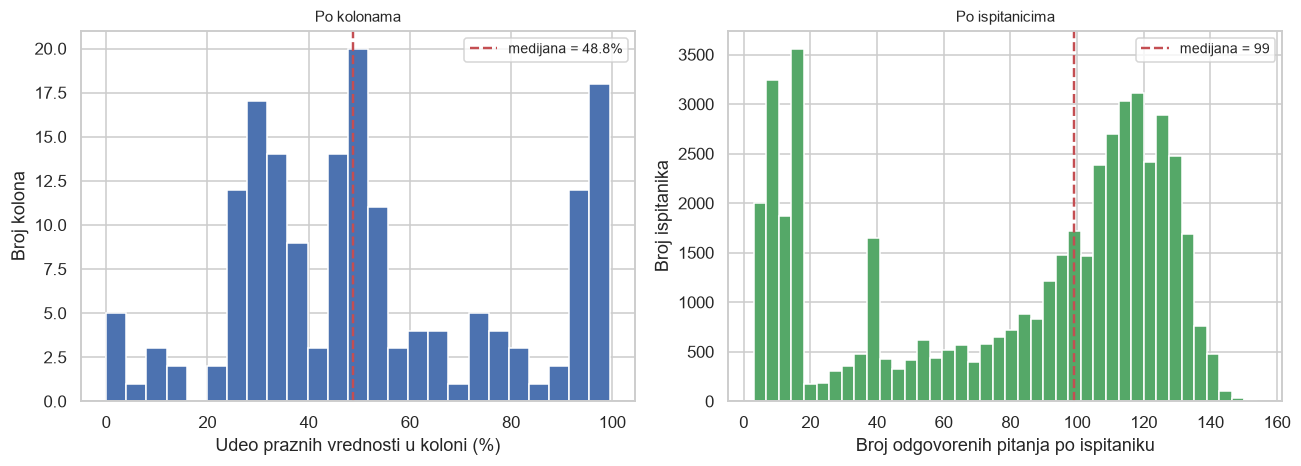

praznih ćelija u celoj tabeli: 52.5%
medijana praznina po koloni:   48.8%

koliko kolona pada u koji opseg:
  tačno 0%     3 kolona
    0 -  10%   5 kolona
   10 -  25%   5 kolona
   25 -  50%  86 kolona
   50 -  75%  29 kolona
   75 - 100%  42 kolona
  najgora kolona: AIAgentObsWrite, prazna kod 99.5%

prosek praznina po petini kolona, u redosledu kojim anketa postavlja pitanja:
  1. petina   23.3%
  2. petina   47.7%
  3. petina   65.7%
  4. petina   56.2%
  5. petina   69.3%

koliko je pitanja odgovorio pojedinačan ispitanik:
count    49123.0
mean        81.0
std         45.0
min          3.0
10%         10.0
25%         37.0
50%         99.0
75%        119.0
max        154.0
  ispitanika sa manje od 20 odgovorenih pitanja: 10,750 (21.9%)


In [7]:
answered_per_person = responses.notna().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

ax = axes[0]
ax.hist(missing_share.to_numpy(), bins=25, color="#4C72B0")
ax.axvline(missing_share.median(), color="#C44E52", linestyle="--", linewidth=1.6,
           label=f"medijana = {missing_share.median():.1f}%")
ax.set_xlabel("Udeo praznih vrednosti u koloni (%)")
ax.set_ylabel("Broj kolona")
ax.set_title("Po kolonama", fontsize=10)
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(answered_per_person.to_numpy(), bins=40, color="#55A868")
ax.axvline(answered_per_person.median(), color="#C44E52", linestyle="--", linewidth=1.6,
           label=f"medijana = {answered_per_person.median():.0f}")
ax.set_xlabel("Broj odgovorenih pitanja po ispitaniku")
ax.set_ylabel("Broj ispitanika")
ax.set_title("Po ispitanicima", fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"praznih ćelija u celoj tabeli: {100 * responses.isna().to_numpy().mean():.1f}%")
print(f"medijana praznina po koloni:   {missing_share.median():.1f}%")
print()
print("koliko kolona pada u koji opseg:")
for low, high in [(0, 0.001), (0.001, 10), (10, 25), (25, 50), (50, 75), (75, 100.1)]:
    inside = int(((missing_share >= low) & (missing_share < high)).sum())
    label = "tačno 0%" if high == 0.001 else f"{low:>3.0f} - {min(high, 100):>3.0f}%"
    print(f"  {label:<10} {inside:>3} kolona")
print(f"  najgora kolona: {missing_share.idxmax()}, prazna kod {missing_share.max():.1f}%")
print()
print("prosek praznina po petini kolona, u redosledu kojim anketa postavlja pitanja:")
for number, part in enumerate(np.array_split(missing_share.to_numpy(), 5), start=1):
    print(f"  {number}. petina  {part.mean():>5.1f}%")
print()
print("koliko je pitanja odgovorio pojedinačan ispitanik:")
print(answered_per_person.describe(percentiles=[0.1, 0.25, 0.5, 0.75]).round(0).to_string())
print(f"  ispitanika sa manje od 20 odgovorenih pitanja: "
      f"{int((answered_per_person < 20).sum()):,} ({100 * (answered_per_person < 20).mean():.1f}%)")

**Zapažanje:** praznih je **52,5% svih ćelija**, a medijana po koloni **48,8%** — dakle tipična kolona
ankete prazna je kod skoro svakog drugog ispitanika. Raspodela po kolonama je pri tome vrlo neravnomerna:

| udeo praznina u koloni | kolona |
| --- | --- |
| tačno 0% | 3 |
| do 10% | 5 |
| 10 – 25% | 5 |
| 25 – 50% | 86 |
| 50 – 75% | 29 |
| 75 – 100% | 42 |

Najgora kolona je `AIAgentObsWrite`, prazna kod **99,5%** ispitanika.

Prosek praznina **raste duž redosleda kolona**: u prvoj petini je **23,3%**, u trećoj **65,7%**, u
poslednjoj **69,3%**.

Desni grafik pokazuje raspodelu koja ima **dva grebena**. Medijana je **99** odgovorenih pitanja, ali je
prvi decil na **10** — dakle **10.750 ispitanika, odnosno 21,9%**, odgovorilo je manje od dvadeset
pitanja.

**Tumačenje:** tri merenja zajedno daju sliku koju nijedno samo ne bi.

Da je nedostajanje slučajno, ne bi raslo duž redosleda kolona ni imalo dva grebena po ispitanicima.
Ovako oba nalaza govore isto: **jedan deo ispitanika anketu nije prošao do kraja.** Skup se, dakle, sastoji
od onih koji su prošli većinu pitanja i od većeg broja onih koji su odustali blizu početka, i ta druga
grupa nosi veliki deo praznina.

To ne objašnjava sve. Kolone sa preko 75% praznina, kojih je 42, prazne su i kod ispitanika koji su anketu
prošli, pa tamo uzrok mora biti drugi — najverovatnije to što ta pitanja svi nisu ni videli, jer duge
ankete umeju da postavljaju pitanja uslovno, u zavisnosti od prethodnog odgovora. **To ovde ne
proveravamo**, jer bi tražilo da se za svaku kolonu nađe pitanje koje joj je uslov; beležimo kao pitanje
za fazu čišćenja.

Za rad iz ovoga sledi da se sa prazninama ne može postupati jednako u svim kolonama, i da odluka o njima
mora doći posle merenja, a ne pre.

## 6. Kandidati za ciljnu promenljivu

Uvod je postavio pitanje o platama, ali koja kolona to zapravo meri i da li je jedna ili ih je više, iz
uvoda se ne vidi. Zato kandidate ne biramo napamet nego po meri.

Regresija predviđa brojčanu veličinu koja ima dovoljno različitih vrednosti da se o njoj ima šta reći,
pa gledamo **brojčane kolone sa najviše različitih vrednosti**. Uz svaku nas zanima i koliko je
popunjena, jer kolona koju je odgovorila šačica ispitanika ne može biti ciljna promenljiva.

### Grafik 4 — raspodela kandidata

**Motivacija:** uputstvo traži da se u opisu skupa prikaže raspodela promenljive koja bi se predviđala.
Crtamo je onako kako se raspodela brojčane kolone i crta — histogramom, sa vrednostima na običnoj osi —
i uz grafik ispisujemo opisnu statistiku, da imamo i brojeve a ne samo sliku.

brojčane kolone sa najviše različitih vrednosti:
  ResponseId              49123 razl.   popunjeno 100.0%   —
  ConvertedCompYearly      6234 razl.   popunjeno  48.7%   —
  CompTotal                2676 razl.   popunjeno  50.6%   What is your current total  annual  comp
  ToolCountWork             114 razl.   popunjeno  56.1%   For your  primary work role  (student, d
  ToolCountPersonal          87 razl.   popunjeno  52.0%   For your  side projects or other persona
  YearsCode                  78 razl.   popunjeno  87.5%   Including any education, how many years 
  WorkExp                    72 razl.   popunjeno  87.2%   How many years of professional work expe

CompTotal:
  popunjeno 24,839 (50.6%)
  medijana  105,000
  maksimum  5.56e+74   (dakle reda 10^74)
ConvertedCompYearly:
  popunjeno 23,928 (48.7%)
  medijana  75,384
  maksimum  5e+07   (dakle reda 10^7)
kolona Currency: 142 različitih valuta



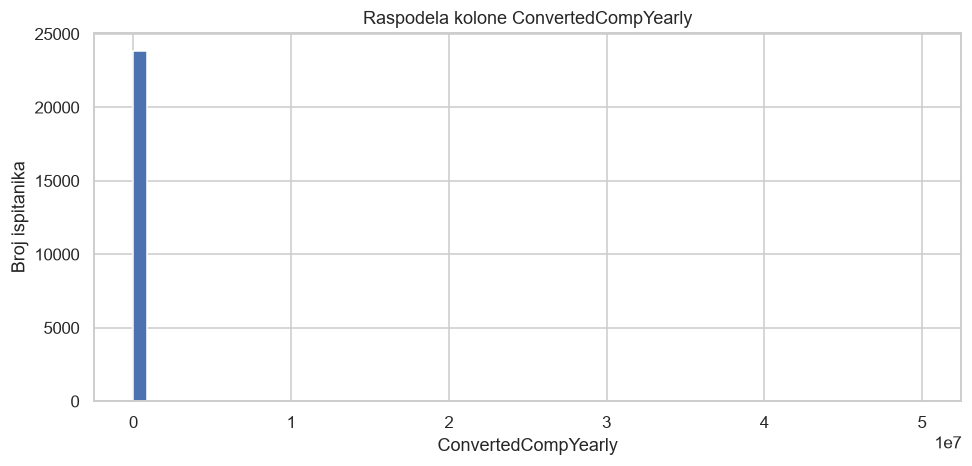

ispitanika sa prijavljenom vrednošću: 23,928
širina jednog stubića: 833,333
ispitanika u prvom stubiću:           23,858 (99.7%)
ispitanika u svim ostalim stubićima:  70

count       23928.0
mean       101792.0
std        461934.0
min             1.0
1%             65.0
25%         38171.0
50%         75384.0
75%        120630.0
99%        440856.0
max      50000000.0

odnos maksimuma i medijane:                663 puta
odnos 99. i 1. percentila:                6782 puta
odnos aritmetičke sredine i medijane:     1.35

ispitanika sa iznosom ispod 100:         304
ispitanika sa iznosom preko milion:       46


In [8]:
numeric_columns = [c for c in responses.columns if not is_text(responses[c])]
numeric_distinct = pd.Series({c: responses[c].nunique() for c in numeric_columns})
numeric_distinct = numeric_distinct.sort_values(ascending=False)

print("brojčane kolone sa najviše različitih vrednosti:")
for name, count in numeric_distinct.head(7).items():
    text = clean_text(questions.loc[name, "question"])[:40] if name in questions.index else "—"
    print(f"  {name:<22} {count:>6} razl.   popunjeno {100 - missing_share[name]:>5.1f}%   {text}")
print()

# The two columns whose names point at compensation, kept apart from the
# identifier, which has one value per respondent and predicts nothing.
CANDIDATES = ["CompTotal", "ConvertedCompYearly"]
for name in CANDIDATES:
    column = responses[name].dropna()
    print(f"{name}:")
    print(f"  popunjeno {len(column):,} ({100 * len(column) / len(responses):.1f}%)")
    print(f"  medijana  {column.median():,.0f}")
    print(f"  maksimum  {column.max():.3g}   (dakle reda 10^{int(np.log10(column.max()))})")
print(f"kolona Currency: {responses['Currency'].nunique()} različitih valuta")
print()

candidate = "ConvertedCompYearly"
values = responses[candidate].dropna()
# Sixty bars, so one bar covers a sixtieth of the range.
BINS = 60

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.hist(values, bins=BINS, color="#4C72B0")
ax.set_xlabel(candidate)
ax.set_ylabel("Broj ispitanika")
ax.set_title(f"Raspodela kolone {candidate}")
plt.tight_layout()
plt.show()

# How much of the data lands in the leftmost bar: one bin is max/BINS wide.
first_bin = values.max() / BINS
print(f"ispitanika sa prijavljenom vrednošću: {len(values):,}")
print(f"širina jednog stubića: {first_bin:,.0f}")
print(f"ispitanika u prvom stubiću:           {int((values <= first_bin).sum()):,} "
      f"({100 * (values <= first_bin).mean():.1f}%)")
print(f"ispitanika u svim ostalim stubićima:  {int((values > first_bin).sum()):,}")
print()

# What the picture cannot show has to be said in numbers instead.
print(values.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(0).to_string())
print()
print(f"odnos maksimuma i medijane:           {values.max() / values.median():>8.0f} puta")
print(f"odnos 99. i 1. percentila:            {values.quantile(0.99) / values.quantile(0.01):>8.0f} puta")
print(f"odnos aritmetičke sredine i medijane: {values.mean() / values.median():>8.2f}")
print()
print(f"ispitanika sa iznosom ispod 100:      {int((values < 100).sum()):>6}")
print(f"ispitanika sa iznosom preko milion:   {int((values > 1e6).sum()):>6}")

**Zapažanje:** posle `ResponseId`, koji je redni broj ispitanika i ne predviđa ništa, dve brojčane kolone
sa najviše različitih vrednosti su **`ConvertedCompYearly` (6.234)** i **`CompTotal` (2.676)** — obe se po
imenu tiču kompenzacije. Slede `ToolCountWork` (114), `ToolCountPersonal` (87), `YearsCode` (78) i
`WorkExp` (72), dakle red veličine manje različitih vrednosti.

Popunjenost te dve kolone je skoro ista, **50,6%** i **48,7%**, ali su im ostale mere različite. Medijana
je **105.000** kod `CompTotal` i **75.384** kod `ConvertedCompYearly`, a maksimum **reda 10⁷⁴** kod prve
i **reda 10⁷** kod druge. Kolona `Currency` ima **142** različite valute.

**Grafik je nečitljiv.** Vidi se jedan stubić uz nulu i ništa više. Ispis to i meri: jedan stubić je
širok **833.333**, i u prvom stubiću je **23.858 od 23.928 ispitanika, dakle 99,7%** — u svim ostalim
stubićima zajedno ostaje **70** ljudi.

Pošto se sa slike ne vidi ništa, oblik opisujemo brojevima iz ispisa. Medijana je **75.384**, kvartili
**38.171** i **120.630**, a prvi i devedeset deveti percentil **65** i **440.856**. Maksimum je **663
puta** veći od medijane, devedeset deveti percentil **6.782 puta** veći od prvog, a aritmetička sredina
**1,35 puta** veća od medijane. Na krajevima su vrednosti koje ne izgledaju kao godišnja plata: **304**
ispitanika prijavila su iznos manji od sto, a **46** veći od milion.

**Tumačenje:** histogram na običnoj osi ovde ne pokazuje ništa, i to samo po sebi jeste nalaz. Da bi
99,7% vrednosti palo u jedan od šezdeset stubića, najveće vrednosti moraju biti **mnogo puta** veće od
onih oko kojih se gomila većina. Isto govore i brojevi: kad je devedeset deveti percentil skoro sedam
hiljada puta veći od prvog, vrednosti se protežu preko nekoliko redova veličine.

Isto potvrđuje i maksimum `CompTotal`-a: broj reda 10⁷⁴ nije nijedan iznos plate ni u jednoj valuti, pa
u toj koloni sigurno ima vrednosti koje su greška u unosu. Kod `ConvertedCompYearly` je maksimum reda
10⁷ — takođe sumnjivo, ali reda veličine koji je moguć.

**Kandidata, dakle, ima dva i oba se tiču kompenzacije**, ali im se medijane razlikuju za trideset
hiljada uz skoro istu popunjenost, pa nisu izražene u istoj jedinici. Kolona `Currency` sa 142 valute
nagoveštava odakle razlika, ali **kako su te dve kolone povezane i koja je od njih upotrebljiva, iz
ovoga se ne vidi.**

Ni oblik raspodele ovde ne rešavamo. Da bi se on uopšte razradio, trebalo bi prvo znati **koju** od dve
kolone koristimo, a to se iz opisa skupa ne može utvrditi. Oboje ostaje za sledeći korak.

## 7. Plan daljih koraka

Skup je opisan, a iz opisa je izašlo pet stvari koje traže odluku, i nijedna se ne može doneti bez
merenja:

1. **Dve kolone o kompenzaciji**, sa različitim medijanama i maksimumima, i 142 valute u igri. Treba
   utvrditi u kakvom su odnosu i koja je upotrebljiva kao ciljna promenljiva.
2. **Uzorak nisu samo programeri po zanimanju.** Treba odlučiti čije plate uopšte modelujemo.
3. **Praznine u polovini svih ćelija**, neravnomerno raspoređene, sa jednim delom ispitanika koji anketu
   nije prošao. Sa predavanja znamo da se čišćenje radi u četiri koraka — duplikati, strukturne greške,
   netipične vrednosti, nedostajuće vrednosti — i da se za nedostajuće vrednosti prvo utvrđuje mehanizam,
   pa tek onda bira između brisanja i imputacije.
4. **Krajnje iskošena raspodela kandidata**, sa vrednostima na obe strane koje ne izgledaju kao plate.
5. **Četrdeset sedam kolona u kojima je vrednost ceo spisak**, i još četrdeset sedam rang-pitanja. Iz njih
   se promenljive tek moraju izvesti, jer u ovom obliku ne mogu u model.

Redosled kojim to radimo prati korake sa predavanja: prvo se odredi ciljna promenljiva, pa se skup očisti
i podeli na trening i test, pa se iz preostalih kolona izvedu nove promenljive, i na kraju se grade i
porede modeli — uz metrike na test skupu i unakrsnu validaciju.

Svaki od tih koraka je zaseban deo ovog rada, i u svakom uz odluku stoji obrazloženje, kod, rezultat i
tumačenje. Ovo je raspored celog rada po sekcijama, računajući i deo koji se ovde završava:

| deo | sekcije | šta obrađuje |
| --- | --- | --- |
| Opis skupa podataka | 1–7 | izvor, struktura ankete, ko je odgovorio, praznine, kandidati za ciljnu promenljivu |
| Ciljna promenljiva | 8–13 | odnos dve kolone o kompenzaciji i izbor ciljne promenljive |
| Čišćenje i priprema podataka | 14–23 | populacija, duplikati, strukturne greške, netipične vrednosti, nedostajuće vrednosti, podela na trening i test |
| Feature engineering | 24–33 | izvođenje promenljivih iz kolona sa spiskovima i rang-pitanja |
| Modelovanje | 34–43 | linearna regresija i regularizovani modeli, izbor modela i merenje na test skupu |

# Ciljna promenljiva: definicija i provera

Pre bilo kakvog čišćenja podataka moramo da odlučimo **šta tačno predviđamo**. Ta odluka
određuje sve što sledi: koji redovi su upotrebljivi, šta je outlier i kako se ophodimo prema
ispitanicima koji nisu prijavili platu.

Iz opisa skupa znamo da anketa kompenzaciju beleži kroz **dve kolone** i da im se medijane razlikuju
uz skoro istu popunjenost. Koja se od njih modeluje, tamo nije odlučeno. Ovaj deo to rešava, kroz
četiri pitanja:

1. Šta je tačno u svakoj od te dve kolone?
2. Koju biramo za ciljnu promenljivu i zašto?
3. Kako izgleda njena raspodela i da li je možemo modelovati u sirovom obliku?
4. Da li je ta kolona pouzdana, odnosno da li je izvedena onako kako tvrdimo?

In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_raw, question_text

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Relative deviation a row may show from its currency median and still count
# as the same exchange rate.
THRESHOLD = 0.01

df, schema = load_raw()

print(f"redova: {len(df):,}   kolona: {len(df.columns)}")
print(f"različitih zemalja: {df['Country'].nunique()}")
print(f"različitih valuta:  {df['Currency'].nunique()}")

redova: 49,123   kolona: 170
različitih zemalja: 177
različitih valuta:  142


## 8. Šta beleže `CompTotal` i `ConvertedCompYearly`

Tekst pitanja čitamo direktno iz `survey_results_schema.csv`, da se ne oslanjamo na pretpostavke.

In [10]:
questions = question_text(schema)

for column in ["CompTotal", "ConvertedCompYearly", "Currency"]:
    text = questions.get(column, np.nan)
    print(f"--- {column} ---")
    print("nema teksta pitanja u šemi" if pd.isna(text) else text)
    print()

--- CompTotal ---
What is your current total <b>annual</b> compensation (salary, bonuses, and perks, before taxes and deductions) in terms of your day-to-day currency?  Please enter a whole number in the box below, without any punctuation.  If you are paid hourly, please estimate an equivalent yearly salary. If you prefer not to answer, please leave the box empty. 

--- ConvertedCompYearly ---
nema teksta pitanja u šemi

--- Currency ---
Which currency do you use day-to-day? If your answer is complicated, please pick the one you're most comfortable estimating in.



Iz ovoga slede dva zaključka.

**`CompTotal` je godišnji iznos**, ne mesečni: pitanje traži ukupnu godišnju kompenzaciju
(plata, bonusi i beneficije, pre poreza), u valuti koju ispitanik svakodnevno koristi, uz
uputstvo da oni plaćeni po satu procene godišnji ekvivalent. U anketi za 2025. ne postoji
kolona `CompFreq` (u ranijim godinama je postojala i beležila periodiku odgovora), pa oko
periodike nema dvosmislenosti.

**`ConvertedCompYearly` nema tekst pitanja** — vrednost u šemi je prazna. To nije previd nego
znak da ta kolona **nije anketno pitanje** nego vrednost koju je Stack Overflow izveo. Ime, uz to,
sugeriše da je izvedena iz `CompTotal`-a preračunavanjem u dolare.

Odsustvo teksta pitanja, međutim, kaže samo da kolona nije pitanje — ne i **kako** je dobijena. Da je
zaista `CompTotal` preveden u dolare je za sada pretpostavka, i proverava se u sekciji 11.

## 9. Koju kolonu biramo za ciljnu promenljivu

Uzorak je globalan — u celom skupu ima 177 zemalja i 142 valute.
Zbog toga `CompTotal` **nije uporediv između zemalja**: iznos od 3.000.000 znači nešto sasvim
drugo u dinarima nego u evrima. Regresija nad takvom kolonom ne bi modelovala platu nego uglavnom
izbor valute.

Zato je ciljna promenljiva **`ConvertedCompYearly`**.

Alternativa bi bila da konverziju uradimo sami, iz `CompTotal`-a i kolone `Currency`. To ne radimo:
tražilo bi istorijske kurseve za sve valute na datum ankete, dakle spoljni izvor podataka, i dalo bi
istu veličinu koju Stack Overflow već nudi, samo sa dodatnom greškom koju bismo sami uveli.

Ono što ima smisla nije da konverziju ponovimo, nego da je **proverimo**.

Odluku donosimo pre eksplorativne analize, što na prvi pogled deluje prerano. Ovde je ipak u redu:
`CompTotal` i `ConvertedCompYearly` nisu dva različita kandidata između kojih biramo po tome kako se
ponašaju, nego **ista veličina u različitim jedinicama**. Da iznosi u različitim valutama nisu
međusobno uporedivi, znamo i bez ijednog grafika.

## 10. Kako izgleda ciljna promenljiva

Pre nego što proverimo pouzdanost kolone, pogledajmo njen oblik — to određuje da li je uopšte možemo
modelovati u sirovom obliku.

Ispis ispod pokazuje i koliko ispitanika uopšte ima prijavljenu kompenzaciju. Taj udeo je nizak, ali
ga ovde samo konstatujemo: pitanje ko prijavljuje platu a ko ne, i sme li se taj deo uzorka jednostavno
izbaciti, zahteva zasebnu analizu i obrađuje se u delu o čišćenju.

In [11]:
target = df["ConvertedCompYearly"].dropna()

print(f"ispitanika sa prijavljenom kompenzacijom: {len(target):,} od {len(df):,} "
      f"({100 * len(target) / len(df):.1f}%)")
print()
print(target.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(0).to_string())
print()
print(f"odnos aritmetičke sredine i medijane:    {target.mean() / target.median():>7.2f}")
print(f"odnos maksimuma i medijane:              {target.max() / target.median():>7.0f}")
print(f"koeficijent asimetrije, sirova vrednost: {target.skew():>7.2f}")
print(f"koeficijent asimetrije, log vrednost:    {np.log(target).skew():>7.2f}")

ispitanika sa prijavljenom kompenzacijom: 23,928 od 49,123 (48.7%)

count       23928.0
mean       101792.0
std        461934.0
min             1.0
1%             65.0
25%         38171.0
50%         75384.0
75%        120630.0
99%        440856.0
max      50000000.0

odnos aritmetičke sredine i medijane:       1.35
odnos maksimuma i medijane:                  663
koeficijent asimetrije, sirova vrednost:   75.47
koeficijent asimetrije, log vrednost:      -2.58


### Grafik 5 — raspodela kompenzacije, bez ikakvih izmena

**Motivacija:** prvo hoćemo prosto da vidimo kako izgleda raspodela ciljne promenljive u dolarima,
bez transformacija i bez podešavanja prikaza.

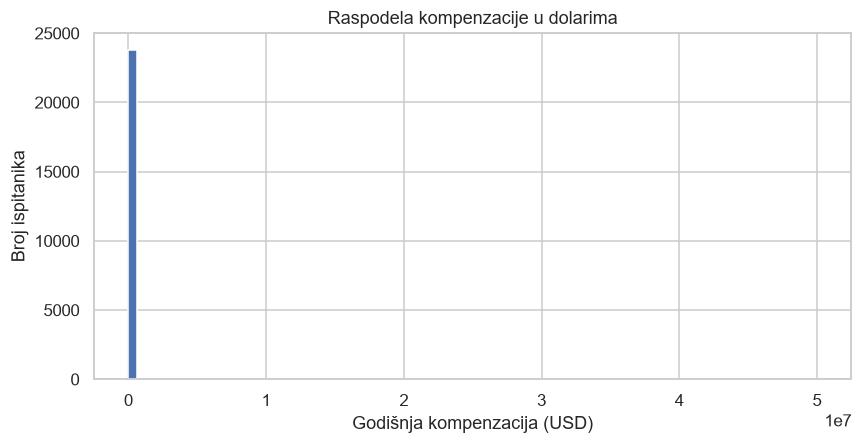

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.2))

ax.hist(target, bins=80, color="#4C72B0")
ax.set_xlabel("Godišnja kompenzacija (USD)")
ax.set_ylabel("Broj ispitanika")
ax.set_title("Raspodela kompenzacije u dolarima")
plt.tight_layout()
plt.show()

**Zapažanje:** grafik je praktično prazan. Vidi se jedan jedini stubić uz levu ivicu, dok se X-osa
proteže sve do 50 miliona dolara. Ostali stubići postoje, ali su toliko niski da se ne razlikuju od
nule.

**Tumačenje:** ovo nije greška u crtanju nego osobina podataka. Skoro svi ispitanici su zbijeni u
uskom pojasu na dnu skale, a nekolicina razvlači osu preko celog grafika. Iz ovakve slike ne možemo
pročitati ništa o obliku raspodele.

Prvi pokušaj da to popravimo je najblaži mogući: **ne diramo podatke, menjamo samo prikaz.**
Logaritamska Y-osa čini vidljivim i stubiće sa po nekoliko ispitanika, pored onih sa desetinama
hiljada.

### Grafik 6 — ista raspodela, sa logaritamskom Y-osom

**Motivacija:** hoćemo da vidimo šta se nalazi izvan onog prvog stubića — dokle se raspodela zapravo
proteže i kako opada.

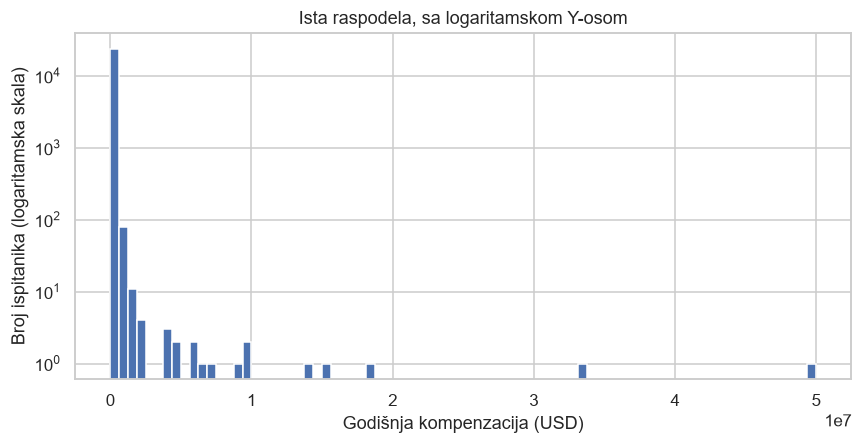

širina jednog stubića:           625,000 USD
ispitanika u prvom stubiću:       23,816 (99.5%)
stubića sa bar jednim redom:          16 od 80


In [13]:
fig, ax = plt.subplots(figsize=(8, 4.2))

ax.hist(target, bins=80, color="#4C72B0")
ax.set_yscale("log")
ax.set_xlabel("Godišnja kompenzacija (USD)")
ax.set_ylabel("Broj ispitanika (logaritamska skala)")
ax.set_title("Ista raspodela, sa logaritamskom Y-osom")
plt.tight_layout()
plt.show()

# The same binning matplotlib used above, so we can describe the picture in numbers.
counts, edges = np.histogram(target, bins=80)
print(f"širina jednog stubića:        {edges[1] - edges[0]:>10,.0f} USD")
print(f"ispitanika u prvom stubiću:   {counts[0]:>10,} ({100 * counts[0] / len(target):.1f}%)")
print(f"stubića sa bar jednim redom:  {(counts > 0).sum():>10} od {len(counts)}")

**Zapažanje:** sada se vidi da raspodela nije prazna nego izuzetno neravnomerna. Uz levu ivicu stoji
jedan ogroman stubić, a zatim se preko cele ose, sve do 50 miliona dolara, proteže vrlo redak rep od
svega nekoliko stubića sa po nekoliko ljudi.

Ispis ispod grafika daje tačne brojke: širina jednog stubića je **625.000 dolara**, u prvi stubić
pada **23.816 ispitanika, odnosno 99,5%** njih, a od 80 stubića samo **16** uopšte sadrži nekoga.

**Tumačenje:** promena prikaza nam je pomogla da podatke vidimo, ali problem nije rešila — samo ga je
jasno pokazala. Rep je stvaran i vrlo dugačak, pa bi u regresiji nekoliko takvih ispitanika imalo
veću težinu od svih ostalih zajedno.

Opisna statistika iz ranije ćelije to potvrđuje: sredina je **101.792** a medijana **75.384 dolara** —
kod simetrične raspodele te dve vrednosti se poklapaju. Najveća vrednost je **663 puta veća od
medijane**, a standardna devijacija (**461.934**) preko četiri puta veća od same sredine. Isto sažeto
govori i koeficijent asimetrije od **75,47**, koji za simetričnu raspodelu iznosi nulu.

Pošto podešavanje prikaza nije dovoljno, sledeći korak je da promenimo **samu promenljivu**.

### Grafik 7 — posle logaritamske transformacije

**Motivacija:** hoćemo da vidimo da li transformisana promenljiva ima oblik pogodan za regresiju.
Razlog da baš logaritam probamo je merna skala: razlika od 10.000 dolara znači nešto sasvim drugo kod
plate od 20.000 nego kod plate od 500.000. Logaritam relativne razlike pretvara u apsolutne, pa je
udvostručenje plate isti pomak i na dnu i na vrhu skale.

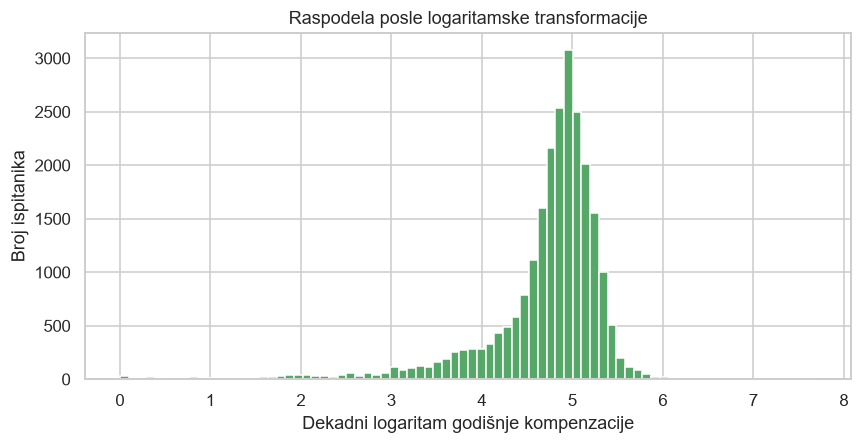

najviši stubić: log opseg 4.91–5.00, što je 80,927–101,002 USD
ispitanika u njemu: 3,081


In [14]:
fig, ax = plt.subplots(figsize=(8, 4.2))

ax.hist(np.log10(target), bins=80, color="#55A868")
ax.set_xlabel("Dekadni logaritam godišnje kompenzacije")
ax.set_ylabel("Broj ispitanika")
ax.set_title("Raspodela posle logaritamske transformacije")
plt.tight_layout()
plt.show()

counts, edges = np.histogram(np.log10(target), bins=80)
peak = counts.argmax()
print(f"najviši stubić: log opseg {edges[peak]:.2f}–{edges[peak + 1]:.2f}, "
      f"što je {10 ** edges[peak]:,.0f}–{10 ** edges[peak + 1]:,.0f} USD")
print(f"ispitanika u njemu: {counts[peak]:,}")

**Zapažanje:** raspodela je sada zvonasta i čitljiva na običnoj Y-osi. Ispis ispod grafika kaže da je
najviši stubić u logaritamskom opsegu **4,91–5,00**, što odgovara kompenzaciji između **80.927 i
101.002 dolara**, i da se u njemu nalazi **3.081 ispitanik**. Levo se, međutim, izdvaja izdužen rep
koji se spušta sve do nule.

**Tumačenje:** transformacija je uspela u onome zbog čega je i probana. Desni rep je nestao,
raspodela ima upotrebljiv oblik, i ciljnu promenljivu ćemo modelovati u logaritamskom obliku.

Otkrila je, međutim, drugi problem. Koeficijent asimetrije je posle transformacije **−2,58**, dakle
rep je sada na levoj strani. Uzrok su neuverljivo male prijavljene vrednosti: prvi procenat
ispitanika prijavljuje 65 dolara godišnje ili manje, a najmanja vrednost je **1 dolar**. Logaritam
takve vrednosti ne popravlja — čini ih uočljivijim.

Zaključak sekcije: ciljnu promenljivu modelujemo u logaritamskom obliku, ali ekstremne vrednosti na
oba kraja ostaju otvoreno pitanje i rešavaju se u fazi čišćenja podataka.

Da li je transformacijom zadovoljena i pretpostavka o ujednačenom rasipanju grešaka
(homoscedastičnost) ovde ne možemo utvrditi, jer je to svojstvo grešaka modela a ne same kolone. Sa
predavanja znamo da se ona proverava Scale-Location dijagnostičkim grafikom nad rezidualima, pa to
ostavljamo za fazu modelovanja.

## 11. Hipoteza 1 — konzistentnost konverzije

> **Hipoteza:** `ConvertedCompYearly` je nastao isključivo množenjem `CompTotal`-a fiksnim kursom
> valute ispitanika. Formalno: količnik `ConvertedCompYearly / CompTotal` je konstantan unutar svake
> vrednosti kolone `Currency`.
>
> **Kriterijum, postavljen unapred:** hipoteza je potvrđena ako u **svakoj** valuti bar **99% redova**
> odstupa manje od **1%** od medijane količnika za tu valutu. Prag nije nula zbog očekivanog
> zaokruživanja na cele dolare.

Ako se hipoteza potvrdi, dobijamo dve stvari odjednom: potvrdu da je ciljna promenljiva čista
konverzija, i dokaz da je veza između `CompTotal`-a i cilja deterministička — što ima direktnu
posledicu po izbor feature-a, o čemu na kraju ovog dela.

In [15]:
# Only rows where both columns exist and CompTotal can be divided by.
comp = df[["Currency", "Country", "CompTotal", "ConvertedCompYearly"]].dropna(
    subset=["Currency", "CompTotal", "ConvertedCompYearly"]
)
comp = comp[comp["CompTotal"] > 0].copy()

# The exchange rate each row implies.
comp["implied_rate"] = comp["ConvertedCompYearly"] / comp["CompTotal"]

median_rate = comp.groupby("Currency")["implied_rate"].transform("median")
comp["deviation"] = (comp["implied_rate"] / median_rate - 1).abs()

within = comp["deviation"] < THRESHOLD
print(f"redova sa obe vrednosti:  {len(comp):>7,}")
print(f"različitih valuta:        {comp['Currency'].nunique():>7,}")
print(f"redova u pragu od 1%:     {within.sum():>7,} ({100 * within.mean():.2f}%)")

redova sa obe vrednosti:   23,928
različitih valuta:            124
redova u pragu od 1%:      23,801 (99.47%)


In [16]:
def in_band(s):
    """Rates that sit within THRESHOLD of their own currency median."""
    return s[(s / s.median() - 1).abs() < THRESHOLD]


def rate_summary_by_currency(comp):
    """Per-currency summary of the implied exchange rate."""
    grouped = comp.groupby("Currency")["implied_rate"]
    summary = pd.DataFrame({
        "n": grouped.size(),
        "median_rate": grouped.median(),
        "pct_within": grouped.apply(lambda s: 100 * len(in_band(s)) / len(s)),
        # How many different rates the currency carries, and how far apart the
        # lowest and the highest of them are, ignoring the outlying rows.
        "distinct_in_band": grouped.apply(lambda s: in_band(s).nunique()),
        "spread_in_band_pct": grouped.apply(
            lambda s: 100 * (in_band(s).max() / in_band(s).min() - 1)
        ),
    })
    return summary.sort_values("n", ascending=False)


summary = rate_summary_by_currency(comp)
summary.head(12).round(4)

,n,median_rate,pct_within,distinct_in_band,spread_in_band_pct
Currency,,,,,
EUR European Euro,6884,1.1601,99.7966,556,1.4493
USD United States dollar,6315,1.0000,100.0000,1,0.0000
GBP Pound sterling,1495,1.3614,99.7324,208,1.2270
INR Indian rupee,1067,0.0116,99.1565,158,0.5747
CAD Canadian dollar,905,0.7296,99.8895,157,1.0204
BRL Brazilian real,592,0.1820,99.1554,156,0.8018
AUD\tAustralian dollar,564,0.6501,99.8227,121,0.0171
PLN Polish zloty,538,0.2729,99.4424,132,0.1955
SEK\tSwedish krona,459,0.1048,99.7821,138,0.1908


Prvi red tabele već pokazuje da nešto ne stoji: kod evra postoji **više stotina različitih
kurseva**, a ne jedan. Kod dolara je, očekivano, kurs tačno 1 i jedinstven — to je usput i dobra
kontrola da račun radi ispravno.

Pitanje je onda kolika su ta odstupanja i kako izgledaju.

### Grafik 8 — sva odstupanja, ceo opseg

**Motivacija:** hoćemo da vidimo koliko su velika odstupanja implicitnog kursa od medijane za
sopstvenu valutu i dokle se uopšte protežu. Y-osu odmah postavljamo na logaritamsku, pošto smo u
prethodnoj sekciji videli šta se dešava kad se to ne uradi kod raspodele sa dugačkim repom.

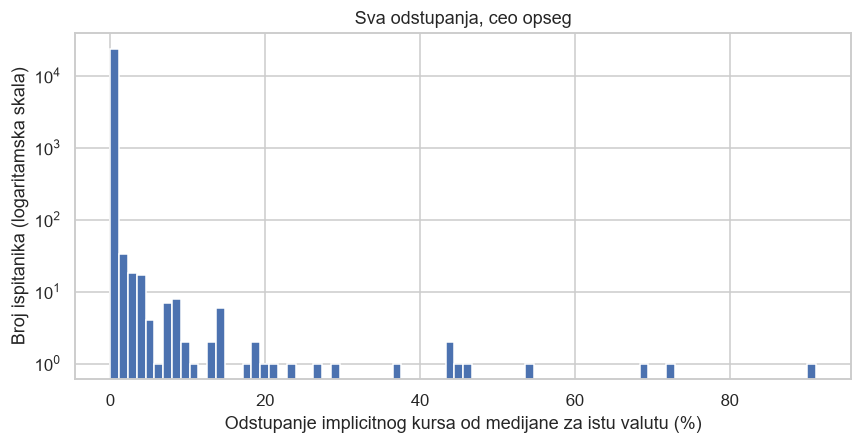

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.2))

ax.hist(comp["deviation"] * 100, bins=80, color="#4C72B0")
ax.set_yscale("log")
ax.set_xlabel("Odstupanje implicitnog kursa od medijane za istu valutu (%)")
ax.set_ylabel("Broj ispitanika (logaritamska skala)")
ax.set_title("Sva odstupanja, ceo opseg")
plt.tight_layout()
plt.show()

**Zapažanje:** gotovo svi ispitanici su u prvom stubiću, uz nulu. Ostatak je vrlo redak, a osa se
završava na oko 91% — dalje od toga nema nijednog ispitanika.

**Tumačenje:** iz toga dokle se osa proteže sledi jedan zaključak koji vredi izvući. U ranijim
godinama ankete postojala je kolona `CompFreq`, koja je beležila periodiku prijavljenog iznosa, pa je
Stack Overflow deo odgovora sam svodio na godišnji nivo. Da je isto radio i ovde, redovi svedeni sa
mesečnog iznosa nosili bi kurs dvanaest puta veći od uobičajenog za svoju valutu — količnik prema
medijani bio bi 12, pa odstupanje `|12 − 1| = 11`, odnosno **1.100%**. Grafik se završava na oko 91%,
dakle tako velikih odstupanja nema.

Sa slike se, međutim, vidi samo dokle osa seže, a ne i da baš u okolini vrednosti 12 nema nikoga.
Zato to proveravamo računom.

In [18]:
# A monthly amount annualised would be twelve times its currency median.
MONTHLY_FACTOR = 12

# How far each row's rate sits from its currency median, as a plain ratio.
rate_ratio = comp["implied_rate"] / median_rate

print(f"odstupanje koje bi red sveden sa mesečnog nosio: "
      f"{100 * (MONTHLY_FACTOR - 1):.0f}%")
print(f"redova u okolini faktora {MONTHLY_FACTOR}:        "
      f"{rate_ratio.between(0.9 * MONTHLY_FACTOR, 1.1 * MONTHLY_FACTOR).sum():>8}")
print()
print(f"najmanji zabeleženi količnik prema medijani: {rate_ratio.min():>8.3f}")
print(f"najveći zabeleženi količnik prema medijani:  {rate_ratio.max():>8.3f}")
print(f"najveće odstupanje u celom skupu:           {100 * comp['deviation'].max():>7.1f}%")

odstupanje koje bi red sveden sa mesečnog nosio: 1100%
redova u okolini faktora 12:               0

najmanji zabeleženi količnik prema medijani:    0.705
najveći zabeleženi količnik prema medijani:     1.912
najveće odstupanje u celom skupu:              91.2%


**Nalaz:** u okolini faktora dvanaest nema nijednog reda, a najveći zabeleženi količnik prema medijani
je 1,91. **Stack Overflow, dakle, nije primenio nikakvu transformaciju osim konverzije valute.**

Vredi naglasiti šta ovo *ne* znači. Provera ne može da otkrije ispitanika koji je sam pogrešio i
uneo mesečnu platu. Pošto se `ConvertedCompYearly` računa iz `CompTotal`-a, takva greška ulazi u obe
kolone, one se u količniku skrate, i red izgleda potpuno uredno. Ovde tražimo transformaciju koju je
uveo Stack Overflow, ne grešku ispitanika — ta druga je zaseban problem i rešava se u fazi čišćenja
outliera.

### Grafik 9 — uvećan prikaz malih odstupanja

**Motivacija:** ostaje da vidimo kako izgledaju ona odstupanja koja jesu tu, u pojasu od nekoliko
procenata oko nule. Na prethodnom grafiku se taj pojas svodio na jedan stubić, pa sve preko 3%
sabijamo u poslednji stubić da bismo ga videli izbliza.

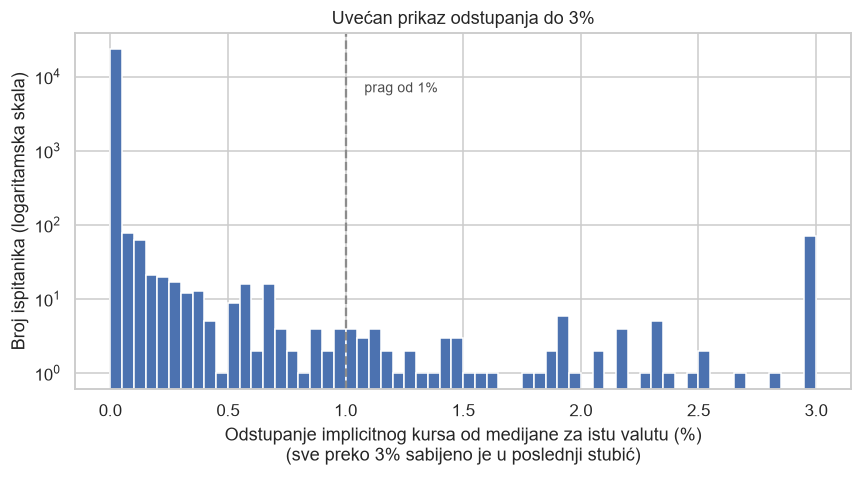

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# Deviations above 3% go into the last bin, so the bulk of the data stays legible.
ax.hist(np.clip(comp["deviation"] * 100, 0, 3), bins=60, color="#4C72B0")
ax.axvline(THRESHOLD * 100, color="#8C8C8C", linestyle="--", linewidth=1.5)
ax.text(1.08, ax.get_ylim()[1] * 0.25, "prag od 1%", color="#4C4C4C", fontsize=9)

ax.set_yscale("log")
ax.set_xlabel("Odstupanje implicitnog kursa od medijane za istu valutu (%)\n"
              "(sve preko 3% sabijeno je u poslednji stubić)")
ax.set_ylabel("Broj ispitanika (logaritamska skala)")
ax.set_title("Uvećan prikaz odstupanja do 3%")
plt.tight_layout()
plt.show()

**Zapažanje:** odstupanja opadaju glatko i neprekidno, bez ijedne izdvojene grupe. Prag od 1%, koji
smo postavili unapred, seče taj niz na proizvoljnom mestu — na samoj toj vrednosti se u podacima ne
dešava ništa posebno.

**Tumačenje:** takav oblik odgovara veličini koja se menja neprekidno, dakle kursu koji se pomerao
tokom trajanja ankete. Da je posredi bila neka sistematska intervencija nad delom podataka,
očekivali bismo zgusnuće na određenoj vrednosti, a ne ravnomerno proređivanje.

### Grafik 10 — da li kriterijum prolazi u svakoj valuti

**Motivacija:** kriterijum smo postavili po valuti, a ne na celom skupu, pa ga tako treba i
proveriti — ukupan procenat od 99,47% bi sakrio valute sa malo ispitanika. Gledamo dvadeset valuta
sa najviše ispitanika.

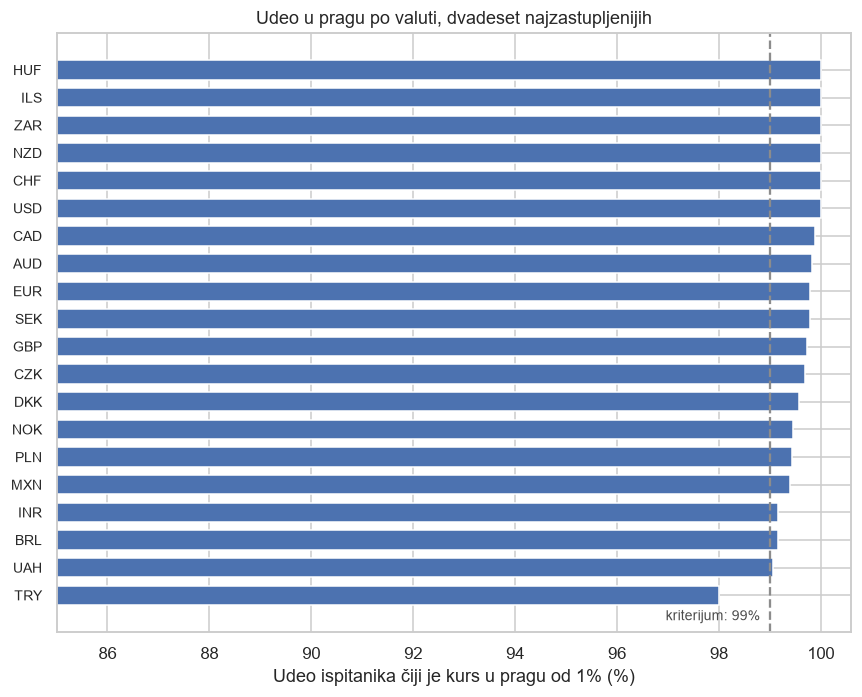

In [20]:
top20 = summary.head(20).sort_values("pct_within")

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(range(len(top20)), top20["pct_within"], color="#4C72B0", height=0.7)
ax.axvline(99, color="#8C8C8C", linestyle="--", linewidth=1.5)

ax.set_yticks(range(len(top20)))
ax.set_yticklabels([v.split()[0] for v in top20.index], fontsize=9)
ax.set_xlim(85, 100.6)
ax.set_xlabel("Udeo ispitanika čiji je kurs u pragu od 1% (%)")
ax.set_ylabel("")
ax.set_title("Udeo u pragu po valuti, dvadeset najzastupljenijih")
ax.text(98.8, -0.9, "kriterijum: 99%", color="#4C4C4C", fontsize=9, ha="right")
plt.tight_layout()
plt.show()

In [21]:
failing = summary[summary["pct_within"] < 99]

print(f"valuta koje ne zadovoljavaju kriterijum: {len(failing)} od {len(summary)}")
print(f"ispitanika u njima: {int(failing['n'].sum()):,} od {len(comp):,}")
print()
print(failing.sort_values("n", ascending=False).head(15)[["n", "pct_within"]].round(2).to_string())

valuta koje ne zadovoljavaju kriterijum: 24 od 124
ispitanika u njima: 1,368 od 23,928

                              n  pct_within
Currency                                   
TRY\tTurkish lira           150       98.00
BGN\tBulgarian lev          133       98.50
JPY\tJapanese yen           123       96.75
CNY\tChinese Yuan Renminbi  111       91.89
COP\tColombian peso         102       83.33
ARS\tArgentine peso          90       95.56
NGN\tNigerian naira          85       89.41
IDR\tIndonesian rupiah       79       96.20
PHP\tPhilippine peso         74       98.65
KES\tKenyan shilling         64       96.88
TWD New Taiwan dollar        63       92.06
RSD\tSerbian dinar           55       98.18
VND\tVietnamese dong         52       92.31
THB\tThai baht               45       97.78
KRW\tSouth Korean won        37       94.59


**Zapažanje:** kod većine prikazanih valuta udeo je preko 99%, kod dolara tačno 100%, a kod jednog
dela valuta pada ispod praga. Ispis iznad pokazuje da je takvih **24 od 124 valute**, i da one
zajedno nose svega **1.368 od 23.928 ispitanika**.

**Tumačenje:** te valute nisu nasumičan skup. Najvećim delom su to valute tržišta u razvoju, čiji je
kurs tokom perioda ankete izraženije oscilovao — kolumbijski pezo, nigerijska naira, argentinski
pezo, turska lira, vijetnamski dong. Među njima ima i stabilnijih valuta, poput japanskog jena i
bugarskog leva, gde je odstupanje manje ali i dalje iznad praga. Obrazac, dakle, prati kretanje
kursa, a ne grešku u podacima.

## 12. Nalaz i verdikt

**Verdikt: hipoteza je opovrgnuta** — ali na način koji je koristan, pa vredi precizno reći šta je
oboreno, a šta nije.

Oboren je deo o **konstantnosti**: kurs nije jedna vrednost po valuti. To se vidi u koloni
`distinct_in_band` — kod evra 556 različitih kurseva, kod funte 208, kod kanadskog dolara 157.
Kolona `spread_in_band_pct` govori koliko su najniži i najviši od njih udaljeni: 1,45% kod evra,
1,23% kod funte. Jedini izuzetak je dolar, sa tačno jednim kursom i rasponom nula — što je očekivano,
pošto je ciljna promenljiva izražena baš u dolarima.

Taj raspon je po načinu računanja ograničen na oko 2%, jer se računa samo nad redovima unutar praga.
Kod valuta koje su tokom ankete jače oscilovale višak kretanja se zato ne vidi kao širi raspon, nego
tako što redovi **ispadaju iz praga** — a to je upravo ono što meri Grafik 10.

Nije oboren deo o **determinisanosti**: u svakom pojedinačnom redu veza
`ConvertedCompYearly = CompTotal * kurs` važi tačno. Menja se samo kurs između redova.

Najuverljivije objašnjenje je da je konverzija rađena po kursu na dan odgovora, a ne jednim kursom za
celu anketu. To se slaže sa svime što vidimo: neprekidna raspodela odstupanja, raspon reda veličine
procenta kod stabilnih valuta i mnogo veći raspon kod valuta koje su tokom perioda ankete stvarno
oscilovale. **Ovo objašnjenje, međutim, ne možemo da dokažemo** — dataset ne sadrži nijednu kolonu sa
datumom odgovora, pa nemamo čime da povežemo kurs sa vremenom. Ostaje kao najverovatnije tumačenje,
ne kao utvrđena činjenica.

Uz ovu proveru namerno ne ide statistički test. Tvrdnja koju ispitujemo je deterministička — da li
jedna kolona nastaje množenjem druge — a ne tvrdnja o slučajnoj promenljivoj. Test značajnosti ovde
ne bi imao šta da testira; odgovor daju udeli i krajnje vrednosti. Statistički testovi dolaze u
narednim fazama, gde se porede grupe ispitanika.

**Posledica po dalji rad:** `ConvertedCompYearly` prihvatamo kao ciljnu promenljivu. Konverzija je
dosledna, bez tragova sistematske greške, a varijacija od oko procenta je zanemarljiva u odnosu na
raspon plata koji modelujemo (od hiljada do stotina hiljada dolara).

Ono što ova provera **ne** može da utvrdi jeste da li su ispitanici tačno odgovorili. Pošto Stack
Overflow `ConvertedCompYearly` računa iz `CompTotal`-a, svaka greška ispitanika ulazi u obe kolone i
količnik ostaje netaknut. Ispitanik koji je uneo mesečnu platu ovde je nevidljiv. To je zasebno
pitanje i traži drugu metodu — poređenje sa tipičnom platom za istu zemlju — i biće obrađeno u fazi
čišćenja outliera.

## 13. Posledica po izbor feature-a: `CompTotal` se isključuje

Provera je usput dokazala nešto važnije od same pouzdanosti kolone.

Pošto u svakom redu važi `ConvertedCompYearly = CompTotal * kurs(Currency)`, `CompTotal` **nije
prediktor plate — on jeste plata**, samo zapisana u drugoj valuti. Model koji bi na ulazu dobio
`CompTotal` i `Currency` mogao bi da rekonstruiše ciljnu promenljivu skoro savršeno, jednostavno tako
što bi naučio kurseve. Dobili bismo model sa gotovo idealnim rezultatom koji o platama nije naučio
ništa, jer bi koeficijenti uz iskustvo, obrazovanje i sve ostalo pali na nulu — uz `CompTotal` ništa
drugo ne doprinosi.

To je **curenje podataka** (engl. *data leakage*): situacija u kojoj model na ulazu dobije informaciju
izvedenu iz onoga što treba da predvidi. Rezultat izgleda odlično, a model je bezvredan, jer pitanje
na koje treba da odgovori — šta određuje visinu kompenzacije — ostaje neodgovoreno.

**Odluka: `CompTotal` ne ulazi u skup feature-a.** Veza je simetrična, pa bi isto važilo i obrnuto:
da smo za cilj uzeli `CompTotal`, `ConvertedCompYearly` bi bio curenje. Ne smemo koristiti obe strane
iste jednačine.

`Currency` i `Country` ostaju legitimni feature-i — oni nose informaciju o tržištu rada i kupovnoj
moći, a ne o samoj vrednosti plate koju predviđamo.

# Čišćenje i priprema podataka

U prethodnom delu utvrdili smo da je ciljna promenljiva `ConvertedCompYearly` i proverili da je
Stack Overflow izveo doslednom konverzijom valuta. Usput smo videli i da je ima samo **23.928 od
49.123 ispitanika**, dakle nešto manje od polovine.

Ovaj deo prati četiri koraka čišćenja podataka — uklanjanje duplikata, ispravljanje strukturnih
grešaka, obradu netipičnih vrednosti i rešavanje nedostajućih vrednosti — i završava se podelom na
trening i test skup i čuvanjem očišćenog skupa.

Pre svega toga treba da odgovorimo na pitanje koje određuje sve ostalo: **na kojim redovima uopšte
radimo.**

In [22]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_raw

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df, schema = load_raw()

reported_overall = df["ConvertedCompYearly"].notna()
print(f"redova: {len(df):,}   kolona: {len(df.columns)}")
print(f"prijavilo kompenzaciju: {reported_overall.sum():,} "
      f"({100 * reported_overall.mean():.1f}%)")

redova: 49,123   kolona: 170
prijavilo kompenzaciju: 23,928 (48.7%)


## 14. Hipoteza 2 — koje redove modelujemo

Nedostajuću vrednost u ciljnoj promenljivoj ne možemo da imputiramo. Popuniti platu značilo bi
izmisliti tačan odgovor pa naučiti model na sopstvenoj izmišljotini — model bi tada naučio naše
pravilo popunjavanja umesto stvarne veze u podacima. Ostaje nam da takve redove izbacimo, postupak
koji smo na predavanjima zvali **listwise brisanje**.

Problem je što je takvo brisanje bezbedno samo ako vrednosti nedostaju potpuno slučajno (MCAR). Ako
nedostaju zbog neke druge promenljive (MAR) ili zbog same vrednosti koja nedostaje (MNAR), brisanjem
uvodimo pristrasnost u uzorak.

Pre nego što se time pozabavimo, treba da suzimo skup na ljude o kojima uopšte govorimo.

> **Hipoteza:** ispitanici koji nisu programeri po zanimanju, kao i oni koji trenutno ne rade, ne
> pripadaju istoj populaciji — iznos koji prijavljuju ne meri istu veličinu kao plata zaposlenog
> programera.
>
> **Kriterijum, postavljen unapred:** za svaku kategoriju gledamo da li joj se međukvartilni raspon
> zarade preklapa sa onim kod developera po profesiji. Kategorija čija se raspodela **ne preklapa**
> meri nešto drugo i izostavlja se. Preklapanje samo po sebi nije dokaz da kategorija pripada istoj
> populaciji — o njoj se tada odlučuje po tome čije tržište rada modelujemo, a ne po visini iznosa.

Prvo pitanje je zato jednostavno: **da li nedostajanje pogađa sve ispitanike podjednako?** Anketu ne
popunjavaju samo zaposleni programeri, pa počinjemo od toga šta je ispitanik po zanimanju.

In [23]:
def response_rate(data, column):
    """Share of respondents that reported compensation, per category of a column."""
    grouped = data.groupby(column, dropna=False)["ConvertedCompYearly"]
    table = pd.DataFrame({
        "ukupno": grouped.size(),
        "prijavilo": grouped.count(),
    })
    table["udeo_%"] = (100 * table["prijavilo"] / table["ukupno"]).round(1)
    return table.sort_values("ukupno", ascending=False)


response_rate(df, "MainBranch")

,ukupno,prijavilo,udeo_%
MainBranch,,,
I am a developer by profession,37418,20184,53.9
"I am not primarily a developer, but I write code sometimes as part of my work/studies",4888,2183,44.7
I am learning to code,2580,362,14.0
I code primarily as a hobby,1920,313,16.3
"I used to be a developer by profession, but no longer am",1322,498,37.7
I work with developers or my work supports developers but am not a developer by profession,995,388,39.0


### Grafik 11 — udeo prijavljivanja po zanimanju

**Motivacija:** tabela daje tačne brojeve, ali se iz nje teško vidi koliko su razlike velike jedna u
odnosu na drugu. Crtamo ih da se odnos odmah uoči.

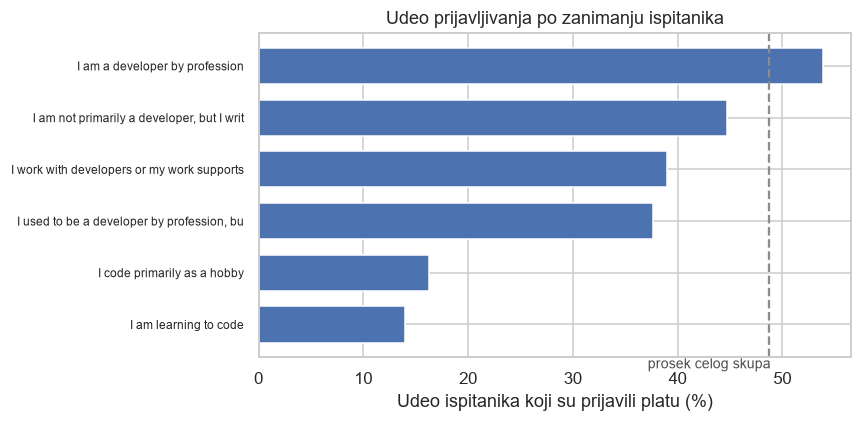

In [24]:
by_branch = response_rate(df, "MainBranch").sort_values("udeo_%")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(range(len(by_branch)), by_branch["udeo_%"], color="#4C72B0", height=0.7)
ax.axvline(100 * df["ConvertedCompYearly"].notna().mean(), color="#8C8C8C",
           linestyle="--", linewidth=1.5)

ax.set_yticks(range(len(by_branch)))
ax.set_yticklabels([label[:42] for label in by_branch.index], fontsize=8)
ax.set_xlabel("Udeo ispitanika koji su prijavili platu (%)")
ax.set_title("Udeo prijavljivanja po zanimanju ispitanika")
ax.text(48.9, -0.85, "prosek celog skupa", color="#4C4C4C", fontsize=9, ha="right")
plt.tight_layout()
plt.show()

**Zapažanje:** udeo je vrlo neravnomeran. Kod onih koji su se izjasnili kao developeri po profesiji
platu je prijavilo **53,9%**, a kod onih koji uče da programiraju svega **14,0%** i kod onih koji
kodiraju iz hobija **16,3%**. Između tih krajnosti su bivši developeri sa 37,7% i oni koji programiraju
uzgred kao deo posla sa 44,7%.

**Tumačenje:** jedan deo nedostajanja nije pravo nedostajanje nego posledica toga što pitanje toj
osobi ne stoji. Student koji uči da programira najčešće nema platu programera koju bi prijavio, pa
prazno polje kod njega ne znači da nešto krije — znači da pitanje nije primenljivo.

To je važno jer nam govori da onih 48,7% sa početka nije jedan problem nego dva pomešana: ljudi kojima
pitanje ne stoji, i ljudi kojima stoji ali nisu odgovorili. Prvi se rešavaju sužavanjem populacije,
drugi ne.

Pošto zanimanje očigledno igra ulogu, sledeće pitanje je da li i radni status igra istu takvu.

In [25]:
response_rate(df, "Employment")

,ukupno,prijavilo,udeo_%
Employment,,,
Employed,33709,19485,57.8
"Independent contractor, freelancer, or self-employed",6700,3049,45.5
Student,4420,701,15.9
Not employed,2222,503,22.6
NaN,846,0,0.0
Retired,708,133,18.8
I prefer not to say,518,57,11.0


**Zapažanje:** i ovde je razlika velika. Zaposleni prijavljuju platu u **57,8%** slučajeva,
samostalni i frilenseri u **45,5%**, studenti u **15,9%**, a penzioneri u **18,8%**.

Dva reda su zanimljivija od ostalih. Kod 846 ispitanika kolona `Employment` je i sama prazna, i **od
njih nijedan nije prijavio platu** — udeo je tačno 0%. Kod onih koji su na pitanje o radnom statusu
odgovorili sa „I prefer not to say" udeo je **11,0%**, najniži u celoj tabeli.

**Tumačenje:** prvi slučaj deluje kao ljudi koji su prekinuli popunjavanje ankete negde na početku,
pa im od tada nadalje sve nedostaje. To nije odbijanje da se odgovori nego napuštanje ankete.

Drugi slučaj je druge prirode i vredi ga zapamtiti. Ljudi koji ne žele da kažu ni kakav im je radni
status najređe kažu i koliku platu imaju. Tu se ne radi o tome da pitanje ne stoji — ono stoji, ali
osoba ne želi da odgovori. To je prvi nagoveštaj da deo nedostajanja nije slučajan, ali za sada je
samo nagoveštaj: reč je o 518 ljudi, i ne znamo da li se isti obrazac vidi i kod ostalih.

Zasad možemo da zaključimo koliko-toliko sigurno samo jedno: populacija na kojoj ima smisla modelovati
platu su ljudi koji rade kao programeri i koji trenutno imaju posao.

### Koga tačno zadržavamo

Rečenica „programeri koji imaju posao" zvuči jasno dok se ne pokuša napisati kao uslov nad kolonama.
Tada se otvaraju dva pitanja na koja prethodne dve tabele ne odgovaraju.

Prvo, `MainBranch` ima šest kategorija, a mi smo do sada gledali samo koliko njih odgovara na pitanje o
plati. To što neka grupa retko prijavljuje platu ne znači samo po sebi da ne pripada istoj populaciji.

Drugo, među profesionalcima nisu svi klasično zaposleni — ima i samostalnih i frilensera, koji od
programiranja žive kao i zaposleni. Njihovo izbacivanje bi nas koštalo dela uzorka, a zadržavanje ima
smisla samo ako im je zarada uporediva sa platom zaposlenih. Prvo da vidimo koliko ih uopšte ima.

In [26]:
by_profession = df[df["MainBranch"] == "I am a developer by profession"]

response_rate(by_profession, "Employment")

,ukupno,prijavilo,udeo_%
Employment,,,
Employed,28741,16881,58.7
"Independent contractor, freelancer, or self-employed",5365,2580,48.1
Student,1232,309,25.1
Not employed,1174,358,30.5
NaN,566,0,0.0
I prefer not to say,206,30,14.6
Retired,134,26,19.4


**Zapažanje:** među developerima po profesiji zaposlenih je **28.741**, a samostalnih i frilensera
**5.365**. Nisu, dakle, zanemarljivi — čine oko sedminu profesionalaca.

Da bismo odlučili šta sa njima i sa ostalim kategorijama, prestajemo da gledamo ko je odgovorio i
gledamo **koliko su prijavili oni koji jesu odgovorili**. Ako se neka grupa po visini zarade jasno
izdvaja, ne pripada istoj populaciji.

In [27]:
reported = df.dropna(subset=["ConvertedCompYearly"])


def compensation_by(data, column):
    """Compensation level and spread per category, for respondents who reported it."""
    grouped = data.groupby(column, dropna=False)["ConvertedCompYearly"]
    table = pd.DataFrame({
        "n": grouped.size(),
        "medijana": grouped.median().round(0),
        "IQR": (grouped.quantile(0.75) - grouped.quantile(0.25)).round(0),
        "p10": grouped.quantile(0.10).round(0),
        "p90": grouped.quantile(0.90).round(0),
    })
    return table.sort_values("n", ascending=False)


compensation_by(reported, "MainBranch")

,n,medijana,IQR,p10,p90
MainBranch,,,,,
I am a developer by profession,20184,77864.0,82243.0,11624.0,185000.0
"I am not primarily a developer, but I write code sometimes as part of my work/studies",2183,65348.0,82202.0,6000.0,175000.0
"I used to be a developer by profession, but no longer am",498,92812.0,105984.0,11121.0,227122.0
I work with developers or my work supports developers but am not a developer by profession,388,64748.0,92542.0,2140.0,188740.0
I am learning to code,362,4650.0,18000.0,61.0,54014.0
I code primarily as a hobby,313,34804.0,73039.0,1160.0,139046.0


**Zapažanje:** dve kategorije očigledno odudaraju. Oni koji uče da programiraju imaju medijanu od
**4.650 dolara**, a hobisti **34.804** — naspram **77.864** kod developera po profesiji. Kod onih koji
uče, deseti percentil je **61 dolar** godišnje.

Ostale tri kategorije su međusobno mnogo bliže. Oni koji nisu primarno developeri imaju medijanu
65.348, oni koji rade sa developerima 64.748, a bivši developeri **92.812** — dakle više od aktivnih
profesionalaca.

**Tumačenje:** kod onih koji uče i kod hobista prijavljena vrednost očigledno ne meri istu stvar.
Godišnji iznos od 61 dolara nije plata programera nego verovatno neki honorar, ili ispitanik uopšte
nije razumeo pitanje. Te dve grupe ne pripadaju populaciji koju modelujemo.

Nalaz kod bivših developera je iznenađenje i vredi ga zabeležiti: oni prijavljuju **veću** platu od
aktivnih. Objašnjenje je verovatno da je reč o ljudima koji su prešli u rukovođenje ili osnovali
firmu, pa i dalje rade u struci ali sebe više ne zovu developerom. Njih ipak izostavljamo, jer nam
kolone ne dozvoljavaju da tu pretpostavku proverimo, a grupa je mala — 498 ispitanika sa platom.

Brojevi u tabeli su korisni, ali ne pokazuju koliko se raspodele **preklapaju**. Dve grupe mogu imati
različite medijane a da im se najveći deo vrednosti poklapa, i tada razdvajanje ne bi ni bilo vredno.

### Grafik 12 — raspodela zarade po zanimanju

**Motivacija:** hoćemo da vidimo koliko se raspodele zarade po kategorijama zanimanja preklapaju, a ne
samo gde su im medijane. Crtamo boxplot, pošto on prikazuje medijanu i kvartile — iste veličine koje
koristimo i za prepoznavanje netipičnih vrednosti. Zaradu prikazujemo u logaritamskom obliku, jer smo
u prethodnom delu videli da je u sirovim dolarima grafik nečitljiv.

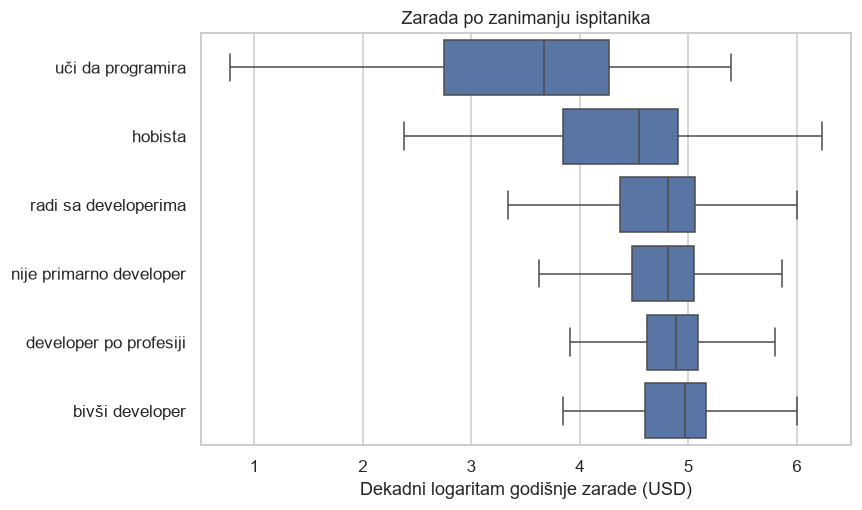

In [28]:
# Short labels, so the category names fit on the axis.
BRANCH_LABELS = {
    "I am a developer by profession": "developer po profesiji",
    "I am not primarily a developer, but I write code sometimes as part of my work/studies":
        "nije primarno developer",
    "I used to be a developer by profession, but no longer am": "bivši developer",
    "I work with developers or my work supports developers but am not a developer by profession":
        "radi sa developerima",
    "I code primarily as a hobby": "hobista",
    "I am learning to code": "uči da programira",
}

plot_data = reported.assign(
    grana=reported["MainBranch"].map(BRANCH_LABELS),
    log_comp=np.log10(reported["ConvertedCompYearly"]),
)
order = plot_data.groupby("grana")["log_comp"].median().sort_values().index

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.boxplot(data=plot_data, y="grana", x="log_comp", order=order,
            color="#4C72B0", showfliers=False, ax=ax)

ax.set_xlabel("Dekadni logaritam godišnje zarade (USD)")
ax.set_ylabel("")
ax.set_title("Zarada po zanimanju ispitanika")
plt.tight_layout()
plt.show()

In [29]:
# The box edges the plot draws, written out in dollars so we can cite them.
box_edges = plot_data.groupby("grana")["ConvertedCompYearly"].agg(
    n="size",
    donja_ivica=lambda s: s.quantile(0.25),
    medijana="median",
    gornja_ivica=lambda s: s.quantile(0.75),
).round(0)

box_edges.loc[order]

,n,donja_ivica,medijana,gornja_ivica
grana,,,,
uči da programira,362,562.0,4650.0,18562.0
hobista,313,6961.0,34804.0,80000.0
radi sa developerima,388,23473.0,64748.0,116015.0
nije primarno developer,2183,30164.0,65348.0,112366.0
developer po profesiji,20184,41786.0,77864.0,124029.0
bivši developer,498,40000.0,92812.0,145984.0


**Zapažanje:** kutije četiri gornje kategorije stoje gotovo jedna preko druge. Tabela sa ivicama kutija
to daje u dolarima: kod developera po profesiji kutija ide od **41.786 do 124.029**, kod onih koji
nisu primarno developeri od **30.164 do 112.366**, a kod onih koji rade sa developerima od **23.473 do
116.015**. Bivši developeri su pomereni naviše (40.000 do 145.984), ali im se kutija i dalje najvećim
delom poklapa sa ostalima.

Dve donje kategorije su druga priča. Kod onih koji uče da programiraju kutija se završava na **18.562
dolara**, dakle pre nego što kod developera po profesiji uopšte počne (41.786). Hobisti su između, sa
kutijom od 6.961 do 80.000.

**Tumačenje:** grafik potvrđuje ono što je tabela nagovestila, i dodaje jednu stvar koju tabela nije
mogla. Kod onih koji uče, raspodela se **ne preklapa** sa profesionalcima — to je zaista druga
populacija i njeno uključivanje bi u model unelo ljude čija zarada nastaje na sasvim drugi način.

Kod hobista je preklapanje delimično, što je i očekivano: neki od njih verovatno imaju stalan posao u
drugoj struci pa su prijavili tu platu, a neki honorare od programiranja. Pošto ne možemo da
razlikujemo ta dva slučaja, i njih izostavljamo.

Za tri kategorije u sredini grafik ne daje osnov da ih razdvajamo po visini zarade. Njih ipak
izostavljamo iz drugog razloga — nisu programeri po zanimanju, pa plata koju prijavljuju pripada
drugom tržištu rada, čak i kada je iznos sličan. Model koji predviđa platu programera treniramo na
programerima.

In [30]:
professionals = reported[reported["MainBranch"] == "I am a developer by profession"]

compensation_by(professionals, "Employment")

,n,medijana,IQR,p10,p90
Employment,,,,,
Employed,16881,80000.0,80073.0,13922.0,185623.0
"Independent contractor, freelancer, or self-employed",2580,76545.0,87000.0,8000.0,185623.0
Not employed,358,69822.0,89495.0,3891.0,182396.0
Student,309,16706.0,22507.0,809.0,50208.0
I prefer not to say,30,84110.0,150758.0,3539.0,295500.0
Retired,26,60544.0,81058.0,5779.0,177808.0


**Zapažanje:** zaposleni i samostalni su po visini zarade vrlo blizu — medijana **80.000** naspram
**76.545 dolara**. Ali IQR je kod samostalnih veći, **87.000** naspram 80.073.

Studenti koji se izjašnjavaju kao developeri po profesiji imaju medijanu od svega 16.706, a
nezaposleni 69.822.

**Tumačenje:** kod samostalnih zarada je na sličnom nivou ali **razuđenija**, što ima smisla — prihod
frilensera zavisi od broja poslova u godini, dok je plata zaposlenog ugovorena.

Poređenje na celom skupu, međutim, meša i sastav po zemljama. Ako samostalnih ima proporcionalno više
u zemljama sa nižim platama, razlika koju vidimo bila bi posledica geografije, a ne oblika
zaposlenja. Zato isto poređenje ponavljamo unutar dve pojedinačne zemlje sa najviše ispitanika.

In [31]:
# The two employment states that mean the person currently earns from work.
WORKING = ["Employed", "Independent contractor, freelancer, or self-employed"]

for country in ["United States of America", "Germany"]:
    subset = professionals[
        (professionals["Country"] == country) & professionals["Employment"].isin(WORKING)
    ]
    print(country)
    print(compensation_by(subset, "Employment")[["n", "medijana", "IQR"]].to_string())
    print()

United States of America
                                                         n  medijana       IQR
Employment                                                                    
Employed                                              3897  154765.0   85000.0
Independent contractor, freelancer, or self-employed   320  129000.0  122000.0

Germany
                                                         n  medijana      IQR
Employment                                                                   
Employed                                              1540   83531.0  40373.0
Independent contractor, freelancer, or self-employed   133  104413.0  81210.0



**Zapažanje:** unutar iste zemlje razlika ne ide na istu stranu. U Sjedinjenim Državama samostalni
zarađuju **manje** od zaposlenih (medijana 129.000 naspram 154.765), a u Nemačkoj **više** (104.413
naspram 83.531). Ono što jeste dosledno je rasipanje: IQR je kod samostalnih veći u obe zemlje —
122.000 naspram 85.000 u SAD, i 81.210 naspram 40.373 u Nemačkoj.

**Tumačenje:** pošto smer razlike zavisi od zemlje, samostalni nisu grupa koja sistematski zarađuje
više ili manje. Nemaju drugačiji nivo zarade, nego **manje predvidiv** nivo zarade.

To je argument da ih zadržimo. Oni od programiranja žive, njihova zarada je na istom nivou kao kod
zaposlenih, i donose nam 2.580 dodatnih ispitanika sa prijavljenom platom. Veće rasipanje znači da će
model kod njih grešiti više, ali to nije razlog da ih izbacimo — to je nešto što model može da uzme u
obzir ako mu oblik zaposlenja damo kao promenljivu.

Nezaposlene, studente, penzionere i one koji nisu hteli da odgovore izostavljamo. Kod njih prijavljena
vrednost ili se odnosi na neki raniji posao, ili nije uporediva sa platom iz aktuelnog radnog odnosa.

### Verdikt i odluka o populaciji

**Hipoteza je potvrđena za one koji uče da programiraju i za hobiste, a opovrgnuta za samostalne i
frilensere.** Kod onih koji uče kutija se završava na **18.562 dolara**, pre nego što kod developera
po profesiji uopšte počne (**41.786**) — raspodele se ne preklapaju, pa je reč o drugoj populaciji.
Kod samostalnih se, nasuprot tome, smer razlike menja od zemlje do zemlje: u Sjedinjenim Državama
zarađuju manje (129.000 naspram 154.765), a u Nemačkoj više (104.413 naspram 83.531). Nemaju,
dakle, drugačiji nivo zarade nego samo razuđeniji, pa ostaju u uzorku.

Modelujemo ispitanike koji ispunjavaju oba uslova:

- `MainBranch` je **„I am a developer by profession"** — programiranje im je zanimanje, pa je plata
  koju prijavljuju plata sa tržišta rada koje modelujemo;
- `Employment` je **„Employed"** ili **„Independent contractor, freelancer, or self-employed"** —
  trenutno rade i imaju tekuću zaradu.

`Employment` zadržavamo kao promenljivu, da model može da razlikuje ta dva oblika rada.

Ova odluka ne rešava problem nedostajućih plata — ona samo iz njega uklanja onaj deo koji potiče od
ljudi kojima pitanje uopšte ne stoji. Koliko je od početnog nedostajanja time objašnjeno, a koliko
ostaje, vidimo u sledećoj ćeliji.

In [32]:
population = df[
    (df["MainBranch"] == "I am a developer by profession")
    & df["Employment"].isin(WORKING)
].copy()

reported_in_population = population["ConvertedCompYearly"].notna()

print(f"ceo dataset:                    {len(df):>7,}")
print(f"populacija koju modelujemo:     {len(population):>7,}")
print(f"  od toga prijavilo platu:      {reported_in_population.sum():>7,} "
      f"({100 * reported_in_population.mean():.1f}%)")
print(f"  i dalje nedostaje:            {(~reported_in_population).sum():>7,} "
      f"({100 * reported_in_population.eq(False).mean():.1f}%)")
print()
print(f"nedostajanje pre sužavanja:     {100 * df['ConvertedCompYearly'].isna().mean():>6.1f}%")
print(f"nedostajanje posle sužavanja:   {100 * (~reported_in_population).mean():>6.1f}%")
print()
print("provera da filter daje ono što smo opisali:")
print(f"  vrednosti u MainBranch: {population['MainBranch'].unique().tolist()}")
print(f"  vrednosti u Employment: {sorted(population['Employment'].unique().tolist())}")

ceo dataset:                     49,123
populacija koju modelujemo:      34,106
  od toga prijavilo platu:       19,461 (57.1%)
  i dalje nedostaje:             14,645 (42.9%)

nedostajanje pre sužavanja:       51.3%
nedostajanje posle sužavanja:     42.9%

provera da filter daje ono što smo opisali:
  vrednosti u MainBranch: ['I am a developer by profession']
  vrednosti u Employment: ['Employed', 'Independent contractor, freelancer, or self-employed']


**Zapažanje:** populacija ima **34.106 ispitanika**, od kojih je platu prijavilo **19.461 (57,1%)**.
Nedostajanje je sa 51,3% palo na **42,9%** — dakle sužavanjem je objašnjeno svega oko osam procentnih
poena.

**Tumačenje:** ovo je najvažniji nalaz sekcije, i nije onaj koji smo očekivali kad smo krenuli.
Pretpostavka da veliki deo praznih polja potiče od ljudi kojima pitanje ne stoji **pokazala se
uglavnom netačnom**. Studenti i hobisti jesu obarali ukupan prosek, ali ih ima premalo da bi objasnili
razmere problema.

Ostaje **14.645 ljudi koji rade kao programeri, imaju platu, i nisu je prijavili**. Kod njih pitanje
nije neprimenljivo — oni su jednostavno preskočili odgovor. To je odbijanje, ne nepostojanje podatka, i
prethodna analiza nam je već dala nagoveštaj kuda to vodi: ispitanici koji nisu hteli da otkriju ni
radni status najređe su otkrivali i platu.

Ako je razlog za ćutanje povezan sa samom visinom plate, reč je o MNAR-u. Na predavanjima smo taj tip
nedostajanja učili kao najopasniji, i to baš na primeru da bogati ne otkrivaju platu. U tom slučaju
brisanje tih redova ne bi bilo bezbedno, nego bi nam iskrivilo uzorak.

Da li je tako, ne možemo da tvrdimo na osnovu jednog nagoveštaja iz tabele. To je pitanje za sledeću
sekciju.

## 15. Hipoteza 3 — da li je nedostajanje plate slučajno

Pre nego što postavimo hipotezu, treba da budemo iskreni oko toga šta uopšte možemo da proverimo.

MNAR znači da nedostajanje zavisi od **same vrednosti koja nedostaje** — da neko ćuti baš zato što mu
je plata visoka ili niska. To se iz ovih podataka **ne može dokazati ni oboriti**, jer bismo za proveru
morali da znamo plate onih koji ih nisu prijavili. Da ih znamo, ne bismo ni imali problem.

Ono što možemo da proverimo jeste da li nedostajanje zavisi od obeležja koja o ispitaniku **ipak
imamo** — zemlje, godina iskustva, obrazovanja, veličine firme. Ta provera razdvaja MCAR od ostalog:

- ako nedostajanje ne zavisi ni od čega što posmatramo, to je u skladu sa MCAR i brisanje je bezbedno;
- ako zavisi, nedostajanje sigurno **nije** MCAR, pa brisanje menja sastav uzorka.

> **Hipoteza:** verovatnoća da ispitanik prijavi platu zavisi od njegovih posmatranih obeležja.
>
> **Kriterijum, postavljen unapred:** hipoteza je potvrđena ako se udeo prijavljivanja između
> kategorija bar jednog obeležja razlikuje za **više od 10 procentnih poena**, uz statističku
> značajnost na pragu **0,05**. Uz p-vrednost obavezno gledamo i veličinu efekta, jer pri 34.106
> ispitanika u populaciji i beznačajne razlike ispadaju značajne.

### Prvo da razdvojimo dve različite stvari

Ranije smo videli da 846 ispitanika kojima je i `Employment` prazan nije prijavilo platu — nijedan.
To liči na ljude koji su prekinuli anketu, a ne na one koji su odbili baš pitanje o plati. Ako takvih
ima mnogo, oni bi zamaglili svaku dalju analizu: kod njih nedostaje sve, pa bi svako obeležje delovalo
povezano sa nedostajanjem plate.

Da bismo ih odvojili, treba nam grupa pitanja koja u upitniku stoje **oko** pitanja o plati. Ko nije
odgovorio ni na jedno od njih, do tog dela ankete najverovatnije nije ni stigao.

Redosled pitanja ne čitamo iz redosleda kolona u fajlu, nego iz `survey_results_schema.csv`, gde svaka
kolona nosi oznaku pitanja iz kog je nastala. Ispis ispod pokazuje i zašto ta razlika nije sitnica.

In [33]:
# The schema records which questionnaire item each column came from, so the order
# of the questions is read from there and not from the order of the columns.
question_number = (schema.drop_duplicates(subset="qname")
                   .set_index("qname")["qid"].str.extract(r"(\d+)")[0].astype(float))

for column in ["Age", "Employment", "OrgSize", "Country", "CompTotal",
               "ICorPM", "RemoteWork", "ConvertedCompYearly"]:
    number = question_number.get(column, np.nan)
    place = "nije anketno pitanje" if pd.isna(number) else f"pitanje {int(number):>3}"
    print(f"{column:<21} {place:<20}   (kolona {list(df.columns).index(column):>3} u fajlu)")

Age                   pitanje   4            (kolona   2 u fajlu)
Employment            pitanje   7            (kolona   4 u fajlu)
OrgSize               pitanje  16            (kolona  13 u fajlu)
Country               pitanje  20            (kolona  59 u fajlu)
CompTotal             pitanje  22            (kolona  61 u fajlu)
ICorPM                pitanje  23            (kolona  14 u fajlu)
RemoteWork            pitanje  24            (kolona  15 u fajlu)
ConvertedCompYearly   nije anketno pitanje   (kolona 168 u fajlu)


**Zapažanje:** pitanje o plati (`CompTotal`) je **22. po redu** u upitniku. `OrgSize` mu neposredno
prethodi, kao pitanje **16**, a `ICorPM` i `RemoteWork` dolaze odmah posle njega, kao pitanja **23** i
**24**. `ConvertedCompYearly` nema svoj broj, jer nije anketno pitanje nego kolona koju je Stack
Overflow izveo naknadno.

Redosled kolona u fajlu je nešto sasvim drugo: te tri kolone stoje na pozicijama 13, 14 i 15, a
`Country` i `CompTotal` tek na 59 i 61.

**Tumačenje:** sva tri pitanja pripadaju istom delu upitnika kao i pitanje o plati — jedno neposredno
pre njega, dva neposredno posle. Ispitanik koji je odgovorio na bilo koje od njih bio je u tom delu
ankete i pitanje o plati je morao da vidi. Prazne sve tri kolone su zato dobar znak da anketu nije
prošao do tog mesta, a ne da je odbio baš pitanje o plati.

Da smo se oslonili na redosled kolona u fajlu, zaključili bismo da sva tri pitanja dolaze mnogo pre
plate — što, kako ispis pokazuje, nije tačno ni za dva od njih.

In [34]:
population["prijavio_platu"] = population["ConvertedCompYearly"].notna()

# The three questions that sit around the pay question in the questionnaire; all
# three empty suggests the respondent never reached that part of the survey.
PAY_SECTION_COLUMNS = ["RemoteWork", "OrgSize", "ICorPM"]
population["prekinuo_anketu"] = population[PAY_SECTION_COLUMNS].isna().all(axis=1)

quit_early = population["prekinuo_anketu"]
print(f"nisu stigli do tog dela:     {quit_early.sum():>7,} "
      f"({100 * quit_early.mean():.1f}% populacije)")
print(f"  od njih prijavilo platu:   {population.loc[quit_early, 'prijavio_platu'].sum():>7,} "
      f"({100 * population.loc[quit_early, 'prijavio_platu'].mean():.1f}%)")
print()

completed = population[~quit_early]
print(f"stigli do tog dela ankete:   {len(completed):>7,}")
print(f"  od njih prijavilo platu:   {completed['prijavio_platu'].sum():>7,} "
      f"({100 * completed['prijavio_platu'].mean():.1f}%)")

nisu stigli do tog dela:       6,189 (18.1% populacije)
  od njih prijavilo platu:     1,627 (26.3%)

stigli do tog dela ankete:    27,917
  od njih prijavilo platu:    17,834 (63.9%)


**Zapažanje:** do dela ankete u kom stoji pitanje o plati nije stiglo **6.189 ispitanika**, dakle
18,1% populacije, i od njih je platu prijavilo svega 26,3%. Među onima koji jesu stigli — njih
**27.917** — udeo skače na **63,9%**.

**Tumačenje:** napuštanje ankete objašnjava osetan deo problema, ali ni izbliza ceo. I među onima koji
su bili u tom delu upitnika, **preko trećine je preskočilo baš pitanje o plati**, iako su odgovorili na
pitanja koja stoje neposredno uz njega. Kod njih to nije nedostatak prilike nego odluka.

Dalju analizu radimo samo nad tom grupom. Kod onih koji nisu stigli dotle nedostaje sve, pa bi nam
svako obeležje izgledalo povezano sa nedostajanjem plate — a to bi bio zaključak o tome ko dovršava
ankete, ne o tome ko krije platu.

### Koja obeležja uopšte da gledamo

Hipoteza govori o „posmatranim obeležjima", a njih u anketi ima mnogo. Ako bismo unapred izabrali dva
ili tri i našli razliku, opravdano bi se moglo prigovoriti da smo birali ona koja nam odgovaraju.

Zato prvo prolazimo **kroz sve kategorijske kolone odjednom** i za svaku merimo koliko se udeo
prijavljivanja razlikuje između njenih kategorija. To je gruba mera — samo razmak između najnižeg i
najvišeg udela — ali dovoljna da vidimo gde uopšte ima šta da se traži. Uzimamo samo kategorije sa bar
150 ispitanika, da razmak ne bi pravila neka šačica ljudi.

In [35]:
# A category needs enough respondents for its percentage to mean anything: with
# fewer than 150, a handful of people moves it by more than a percentage point.
MIN_GROUP = 150

# Left out: the target itself and the column it is derived from; the two columns
# that define the population, which are constant here; the identifier; the two
# columns we derived ourselves; and Currency, which carries the same information
# as Country and would only repeat that finding.
EXCLUDE = {"ConvertedCompYearly", "CompTotal", "Currency", "MainBranch",
           "Employment", "ResponseId", "prijavio_platu", "prekinuo_anketu"}


def response_spread(data, column):
    """Gap between the lowest and highest response rate across a column's categories."""
    table = data.groupby(column, dropna=True)["prijavio_platu"].agg(
        n="size", udeo=lambda s: 100 * s.mean()
    )
    table = table[table["n"] >= MIN_GROUP]
    if len(table) < 2:
        return None
    return {
        "kolona": column,
        "kategorija": len(table),
        "min_%": table["udeo"].min(),
        "max_%": table["udeo"].max(),
        "raspon_pp": table["udeo"].max() - table["udeo"].min(),
    }


results = []
for column in completed.columns:
    values = completed[column]
    if column in EXCLUDE or values.dtype.kind in "fi":
        continue
    # Multi-select answers are stored as one string with ";" separators; those
    # need their own treatment and are not simple categories. The bar is low on
    # purpose, because here we only want them out of the way: skipping a
    # borderline column costs less than counting a multi-select as a category.
    # Where they are later picked out deliberately, a stricter 0.3 is used.
    if values.dropna().astype(str).str.contains(";").mean() > 0.1:
        continue
    if not 2 <= values.nunique(dropna=True) <= 200:
        continue
    row = response_spread(completed, column)
    if row:
        results.append(row)

spread = pd.DataFrame(results).sort_values("raspon_pp", ascending=False).round(1)

print(f"provereno kolona: {len(spread)}")
print()
print(spread.head(8).to_string(index=False))

provereno kolona: 32

         kolona  kategorija  min_%  max_%  raspon_pp
        Country          31   54.0   88.5       34.5
        OrgSize           9   40.0   67.5       27.5
     SODuration           7   56.0   82.7       26.7
LearnCodeChoose           3   43.8   64.9       21.1
        DevType          20   50.0   69.6       19.6
 LanguageChoice           2   65.0   80.2       15.2
     RemoteWork           5   53.8   68.2       14.4
            Age           6   54.1   67.3       13.2


**Zapažanje:** provereno je **32 kolone**, i razmak nije mali ni kod jedne od prvih nekoliko.
Ubedljivo najveći je kod **zemlje — 34,5 procentnih poena** (54,0% do 88,5%), zatim kod **veličine
firme, 27,5** (40,0% do 67,5%) i kod `SODuration`, 26,7. Slede `LearnCodeChoose` sa 21,1 i `DevType`
sa 19,6, a prag od 10 poena prelaze i `LanguageChoice` (15,2), `RemoteWork` (14,4) i starost (13,2).

**Tumačenje:** hipoteza je time praktično već potvrđena, i to na više obeležja odjednom, ne na jednom
srećno izabranom. Formalno je dovoljno i jedno — tvrdnja glasi da nedostajanje zavisi od nečega što
posmatramo, pa jedan slučaj obara MCAR — ali ovako znamo i **koja** obeležja su u igri, što nam treba
za odluku o modelu.

Dalje razrađujemo **zemlju**, iz dva razloga. Ima najveći razmak, i jedina je od ovih koja je
istovremeno jak prediktor same plate — pa ako baš od nje zavisi ko odgovara, posledice po uzorak su
najozbiljnije. Veličinu firme zadržavamo na umu za kasnije.

Ono što ova tabela ne pokazuje jeste da li su razmaci statistički značajni i koliko su zapravo veliki.
Razmak najniže i najviše kategorije je osetljiv na krajnosti, pa ga treba proveriti pravim testom.

### Grafik 13 — udeo prijavljivanja po zemljama

**Motivacija:** iz prethodne tabele znamo da je razmak kod zemlje najveći, ali ne i kako je
raspoređen — da li ga pravi nekoliko izuzetaka ili se udeo menja postepeno. Gledamo zemlje sa bar 150
ispitanika, da udeo ne bi bio računat na šačici ljudi.

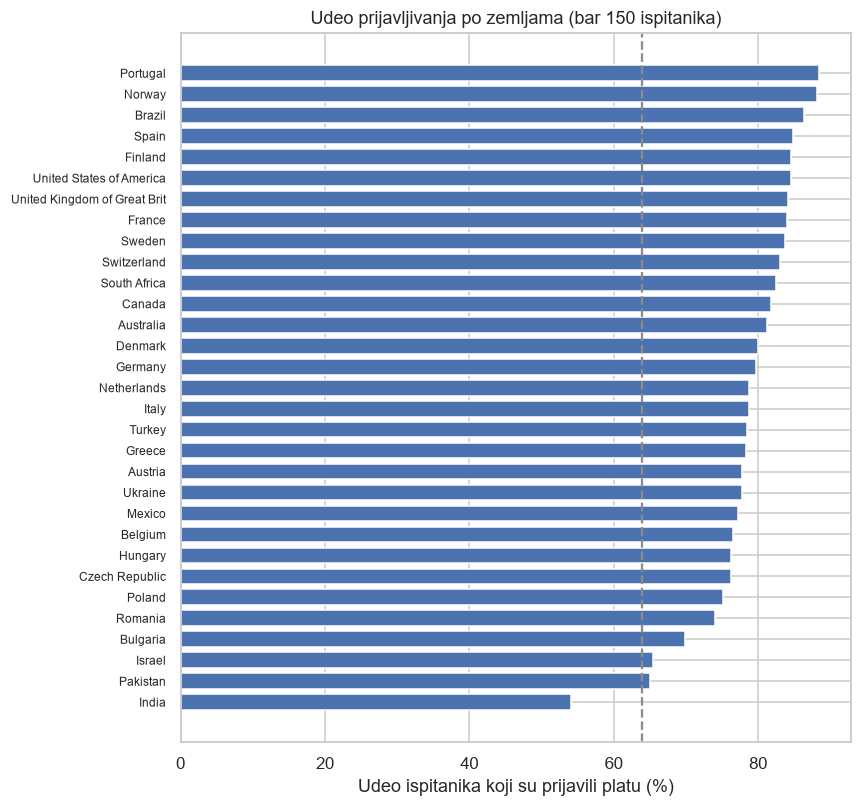

zemalja u prikazu: 31
najniži udeo:  54.0%  (India)
najviši udeo:  88.5%  (Portugal)
raspon:        34.5 procentnih poena
prosek grupe:  63.9%


In [36]:
by_country = completed.groupby("Country")["prijavio_platu"].agg(
    n="size", udeo=lambda s: 100 * s.mean()
)
by_country = by_country[by_country["n"] >= MIN_GROUP].sort_values("udeo")

fig, ax = plt.subplots(figsize=(8, 7.5))
ax.barh(range(len(by_country)), by_country["udeo"], color="#4C72B0", height=0.75)
ax.axvline(100 * completed["prijavio_platu"].mean(), color="#8C8C8C",
           linestyle="--", linewidth=1.5)

ax.set_yticks(range(len(by_country)))
ax.set_yticklabels([c[:28] for c in by_country.index], fontsize=8)
ax.set_xlabel("Udeo ispitanika koji su prijavili platu (%)")
ax.set_ylabel("")
ax.set_title(f"Udeo prijavljivanja po zemljama (bar {MIN_GROUP} ispitanika)")
plt.tight_layout()
plt.show()

print(f"zemalja u prikazu: {len(by_country)}")
print(f"najniži udeo:  {by_country['udeo'].min():.1f}%  ({by_country.index[0]})")
print(f"najviši udeo:  {by_country['udeo'].max():.1f}%  ({by_country.index[-1]})")
print(f"raspon:        {by_country['udeo'].max() - by_country['udeo'].min():.1f} procentnih poena")
print(f"prosek grupe:  {100 * completed['prijavio_platu'].mean():.1f}%")

**Zapažanje:** razlika je velika. Udeo ide od **54,0% u Indiji do 88,5% u Portugalu** — raspon od
**34,5 procentnih poena**, uz prosek grupe od 63,9%. Indija je i ubedljivo najbrojnija među zemljama
sa niskim udelom.

**Tumačenje:** ovo daleko prevazilazi prag od 10 procentnih poena koji smo postavili. Spremnost da se
plata prijavi očigledno zavisi od zemlje, i to snažno.

Zašto je tako, iz ovih podataka ne možemo da zaključimo — verovatno se meša nekoliko stvari, od toga
koliko se u nekoj sredini smatra pristojnim govoriti o plati, do toga koliko ispitanik veruje da će
podatak ostati anoniman. Za nas je bitna posledica, ne uzrok.

Ostaje da proverimo da li je razlika statistički značajna i kolika je zapravo, pa da vidimo da li se
isto ponaša i neko obeležje koje nije kategorijsko.

In [37]:
from scipy import stats

# Chi-square tests whether two categorical variables are independent; here,
# country and whether the salary was reported. Cramer's V rescales it to 0-1
# so the size of the association does not depend on the sample size.
country_subset = completed[completed["Country"].isin(by_country.index)]
contingency = pd.crosstab(country_subset["Country"], country_subset["prijavio_platu"])

chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
n_test = contingency.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n_test * (min(contingency.shape) - 1)))

print(f"ispitanika u testu: {n_test:,}   zemalja: {len(contingency)}")
print(f"hi-kvadrat: {chi2:.1f}   stepeni slobode: {dof}   p = {p_value:.3g}")
print(f"Cramerovo V: {cramers_v:.3f}")

ispitanika u testu: 19,258   zemalja: 31
hi-kvadrat: 867.2   stepeni slobode: 30   p = 4.82e-163
Cramerovo V: 0.212


**Zapažanje:** p-vrednost je reda **10⁻¹⁶³**, dakle daleko ispod praga od 0,05. Cramerovo V iznosi
**0,212**.

**Tumačenje:** hi-kvadrat test proverava da li su dve kategorijske promenljive nezavisne. Nismo ga
radili na predavanjima — koristimo ga jer nam je ovde poređenje između trideset i jedne zemlje, pa
t-test, koji poredi dve grupe, nije primenljiv. Cramerovo V uz njega služi da izmerimo **koliko je
veza jaka**, jer p-vrednost to ne govori.

Ta razlika je ovde ključna. Pri 19.258 ispitanika i najsitnija razlika bi ispala „statistički
značajna", pa nam p-vrednost sama po sebi ne znači mnogo. Vrednost V od 0,212 na skali od 0 do 1 je
umerena, i uz raspon od 34,5 procentnih poena potvrđuje da je veza i praktično bitna, ne samo
statistički.

Sve dosad gledano bilo je kategorijsko. Da vidimo ponaša li se isto i neprekidno obeležje.

In [38]:
with_exp = completed.dropna(subset=["WorkExp"])
reported_exp = with_exp.loc[with_exp["prijavio_platu"], "WorkExp"]
silent_exp = with_exp.loc[~with_exp["prijavio_platu"], "WorkExp"]

t_stat, p_exp = stats.ttest_ind(reported_exp, silent_exp, equal_var=False)

# Cohen's d expresses the gap in standard deviations, so it does not grow with n.
pooled_sd = np.sqrt(
    ((len(reported_exp) - 1) * reported_exp.var() + (len(silent_exp) - 1) * silent_exp.var())
    / (len(reported_exp) + len(silent_exp) - 2)
)
cohens_d = (reported_exp.mean() - silent_exp.mean()) / pooled_sd

print(f"ispitanika u testu: {len(with_exp):,}")
print(f"  prijavili platu:  n={len(reported_exp):>6,}  sredina={reported_exp.mean():.2f} god.")
print(f"  nisu prijavili:   n={len(silent_exp):>6,}  sredina={silent_exp.mean():.2f} god.")
print()
print(f"razlika sredina: {reported_exp.mean() - silent_exp.mean():.2f} godine")
print(f"t-test:          t={t_stat:.2f}   p={p_exp:.3g}")
print(f"Cohenovo d:      {cohens_d:.3f}")

ispitanika u testu: 27,408
  prijavili platu:  n=17,683  sredina=12.98 god.
  nisu prijavili:   n= 9,725  sredina=12.43 god.

razlika sredina: 0.55 godine
t-test:          t=4.55   p=5.45e-06
Cohenovo d:      0.058


**Zapažanje:** oni koji su prijavili platu imaju u proseku **12,98 godina** radnog staža, a oni koji
nisu **12,43** — razlika je **0,55 godine**. T-test daje p od **5,45 × 10⁻⁶**, dakle jasno ispod praga
od 0,05. Cohenovo d iznosi **0,058**.

**Tumačenje:** ovo je primer koji vredi zapamtiti. Razlika **jeste statistički značajna**, ali je
**praktično zanemarljiva**. Pola godine staža na proseku od trinaest godina ne govori ništa korisno ni
o jednom ispitaniku, a Cohenovo d od 0,058 znači da su dve raspodele gotovo potpuno iste — kao mera
veličine efekta, sve ispod 0,2 se smatra malim.

Do značajnosti je došlo isključivo zato što imamo 27.408 ispitanika. Sa dovoljno velikim uzorkom p-
vrednost postaje mala i kod razlika koje nikoga ne zanimaju, i baš zato smo uz nju od početka tražili
i veličinu efekta.

Za samu hipotezu ovo znači da **godine staža nisu izvor problema**. Problem je zemlja.

### Šta brisanje konkretno radi uzorku

Znamo da udeo prijavljivanja zavisi od zemlje. Ako sad izbacimo sve koji nisu prijavili platu, iz
uzorka će nesrazmerno više nestati ljudi iz zemalja sa niskim udelom. Da vidimo koliko se time menja
sastav uzorka po zemljama.

In [39]:
share_before = population["Country"].value_counts(normalize=True) * 100
share_after = population.loc[population["prijavio_platu"], "Country"].value_counts(
    normalize=True) * 100

composition = pd.DataFrame({
    "n_pre": population["Country"].value_counts(),
    "udeo_pre_%": share_before,
    "udeo_posle_%": share_after,
}).dropna()
composition["promena_pp"] = composition["udeo_posle_%"] - composition["udeo_pre_%"]
composition = composition[composition["n_pre"] >= MIN_GROUP].sort_values("promena_pp")

print("najveći pad i najveći rast udela u uzorku:")
print(pd.concat([composition.head(3), composition.tail(3)]).round(2).to_string())

najveći pad i najveći rast udela u uzorku:
                                                      n_pre  udeo_pre_%  udeo_posle_%  promena_pp
Country                                                                                          
India                                                  1690        6.68          4.62       -2.06
Israel                                                  236        0.93          0.78       -0.15
Pakistan                                                174        0.69          0.58       -0.11
Brazil                                                  604        2.39          2.68        0.29
United Kingdom of Great Britain and Northern Ireland   1520        6.01          6.38        0.37
United States of America                               5107       20.20         21.67        1.47


**Zapažanje:** Indija sa **6,68% pada na 4,62%** udela u uzorku, dakle gubi 2,06 procentnih poena.
Sjedinjene Države istovremeno rastu sa **20,20% na 21,67%**.

**Tumačenje:** brisanje nam pomera uzorak ka bogatijim zemljama. Pošto je zemlja jedan od najjačih
prediktora plate, to nije sporedna posledica — uzorak na kome ćemo trenirati model sistematski
precenjuje udeo dobro plaćenih tržišta u odnosu na populaciju ispitanika sa kojom smo krenuli.

## Verdikt

**Hipoteza je potvrđena.** Nedostajanje plate zavisi od posmatranih obeležja, i to ne samo od jednog:

- pregled svih 32 kategorijske kolone pokazao je razmak preko praga od 10 procentnih poena kod
  **zemlje (34,5), veličine firme (27,5), `SODuration` (26,7), `LearnCodeChoose` (21,1), `DevType`
  (19,6), `LanguageChoice` (15,2), načina rada (14,4) i starosti (13,2)**;
- kod zemlje, koju smo razradili do kraja, hi-kvadrat test daje p reda **10⁻¹⁶³** uz Cramerovo V od
  **0,212**, dakle veza je i statistički značajna i praktično umerena;
- godine staža, nasuprot tome, razlikuju se za svega **0,55 godine**, sa Cohenovim d od **0,058** —
  značajno, ali zanemarljivo. Nije, dakle, sve povezano sa nedostajanjem.

**Nedostajanje sigurno nije MCAR.** Brisanje redova bez prijavljene plate nije bezbedno u smislu u kom
smo to učili na predavanjima — ono menja sastav uzorka.

Da li je posredi MAR ili MNAR, **ne možemo da utvrdimo**, i to nije nedostatak analize nego granica
onoga što se iz ovakvih podataka može znati. Da bismo dokazali MNAR, trebalo bi da uporedimo plate
onih koji su ih prijavili sa platama onih koji nisu — a upravo te druge nemamo.

**Posledica po dalji rad.** Ipak nastavljamo sa brisanjem, iz razloga koji smo naveli na početku
sekcije: ciljna promenljiva se ne sme izmišljati, pa druge mogućnosti nemamo. Ali uz to idu dve
obaveze:

1. **Obeležja od kojih nedostajanje zavisi moraju da uđu u model** — pre svega zemlja, ali i veličina
   firme i način rada. Ako model zna iz koje je zemlje ispitanik i u kakvoj firmi radi, deo
   pristrasnosti koju brisanje unosi se time nadoknađuje. To je razlika između MAR-a koji je uzet u
   obzir i MAR-a koji je prećutan.
2. **U zaključku rada ovo se navodi kao ograničenje.** Model je treniran na uzorku u kome su
   ispitanici iz Indije potcenjeni, a iz Sjedinjenih Država precenjeni u odnosu na polazni skup.

## 16. Duplikati

Sada prelazimo na četiri koraka čišćenja onim redom kojim smo ih učili: duplikati, strukturne greške,
netipične vrednosti, nedostajuće vrednosti.

Kod ankete duplikat bi značio da je isti ispitanik popunio upitnik dva puta. To se ne bi videlo kroz
`ResponseId`, jer se on dodeljuje svakom slanju posebno — pa gledamo i da li postoje redovi koji se
poklapaju u **svim odgovorima**, a razlikuju se samo po tom identifikatoru.

In [40]:
# Everything except the identifier and the two flags we derived ourselves.
ANSWER_COLUMNS = [c for c in population.columns
                  if c not in ("ResponseId", "prijavio_platu", "prekinuo_anketu")]

print(f"redova u populaciji:              {len(population):>7,}")
print(f"potpuno identičnih redova:        {population.duplicated().sum():>7,}")
print(f"ponovljenih ResponseId:           {population['ResponseId'].duplicated().sum():>7,}")
print(f"identičnih po svim odgovorima:    "
      f"{population.duplicated(subset=ANSWER_COLUMNS).sum():>7,}")

redova u populaciji:               34,106


potpuno identičnih redova:              0
ponovljenih ResponseId:                 0
identičnih po svim odgovorima:        565


**Zapažanje:** potpuno identičnih redova nema, niti ima ponovljenih `ResponseId`. Ali kada
identifikator izuzmemo, **565 redova se poklapa sa nekim drugim redom u svim odgovorima**.

**Tumačenje:** to na prvi pogled izgleda kao da je 565 ljudi poslalo anketu dvaput. Pre nego što ih
izbacimo, gledamo o kakvim je redovima reč — jer ako neko odgovori na svega nekoliko pitanja,
poklapanje sa nekim drugim takvim ispitanikom nije nikakvo iznenađenje.

In [41]:
# keep=False marks every row that takes part in a duplicate group, not just the repeats.
in_duplicate_group = population.duplicated(subset=ANSWER_COLUMNS, keep=False)
duplicates = population[in_duplicate_group].copy()
duplicates["popunjenih_odgovora"] = duplicates[ANSWER_COLUMNS].notna().sum(axis=1)

print(f"redova u duplikat-grupama: {len(duplicates):,}   od ukupno {len(ANSWER_COLUMNS)} kolona")
print()
print("koliko su ti redovi popunjeni:")
print(duplicates["popunjenih_odgovora"].describe()[["min", "50%", "max"]].round(1).to_string())
print()
print(f"od njih prijavilo platu: {duplicates['prijavio_platu'].sum()}")
print(f"prosečna popunjenost ostalih redova: "
      f"{population.loc[~in_duplicate_group, ANSWER_COLUMNS].notna().sum(axis=1).mean():.1f}")

redova u duplikat-grupama: 741   od ukupno 169 kolona

koliko su ti redovi popunjeni:
min    3.0
50%    5.0
max    9.0

od njih prijavilo platu: 0
prosečna popunjenost ostalih redova: 88.1


**Zapažanje:** u duplikat-grupama je **741 red**, i svi su gotovo prazni — imaju između **3 i 9
popunjenih odgovora od 169 kolona**, sa medijanom od 5. Ostali redovi u populaciji imaju u proseku
**88,1** popunjenih odgovora. **Nijedan od njih nema prijavljenu platu.**

**Tumačenje:** to nisu ljudi koji su anketu poslali dvaput, nego ljudi koji su je napustili posle
nekoliko prvih pitanja. Kad su popunjena samo tri do devet polja, i to uglavnom osnovna demografija,
poklapanje sa nekim drugim ispitanikom je očekivano — nema dovoljno odgovora da bi se dva čoveka
razlikovala.

Za nas to znači da **pravih duplikata nema**, i da ništa po ovom osnovu ne izbacujemo. Ovi redovi
ionako ispadaju iz uzorka jer nemaju ciljnu promenljivu, a to je odluka koju smo doneli u prethodnoj
sekciji, iz drugog razloga.

Vredi ipak zabeležiti da se ista grupa ljudi — oni koji su prekinuli anketu na početku — pojavljuje
već treći put: kod praznog `Employment`, kod prekinute ankete, i sada ovde. Pri obradi nedostajućih
vrednosti treba imati na umu da je jedan deo praznina u podacima posledica napuštanja upitnika, a ne
odbijanja pojedinačnog pitanja.

## 17. Strukturne greške

Strukturna greška je vrednost koja **postoji, ali je neispravna** — bilo zato što je pogrešno
zapisana, bilo zato što je logički nemoguća. Razlikuje se od druga dva problema koja obrađujemo:

| | Šta je | Po čemu se prepoznaje |
| --- | --- | --- |
| Nedostajuća vrednost | polje je prazno | vrednost je `NaN` |
| **Strukturna greška** | vrednost postoji ali je neispravna | pravilo koje znamo o toj koloni |
| Netipična vrednost | vrednost je ispravna ali ekstremna | raspodela — kvartili i IQR |

Zato strukturne greške idu **pre** netipičnih vrednosti. Ako ih ostavimo, one ulaze u račun kvartila i
pomeraju granicu po kojoj kasnije sudimo šta je ekstremno.

Kolona ima 169 i ne možemo ih sve pregledati ručno. Ali svaka provera koju možemo da smislimo spada u
jednu od dve grupe, i to nam rešava problem izbora:

- **provere koje ne traže da znamo šta kolona znači** — kontrolni karakteri, prazan string umesto
  `NA`, kolona sa jednom jedinom vrednošću. Njih puštamo nad svim kolonama odjednom.
- **provere koje traže poznavanje kolone** — da li je staž od sto godina moguć. Njih radimo samo tamo
  gde imamo pravilo po kom sudimo.

Svaki problem obrađujemo do kraja pre nego što pređemo na sledeći: prvo ga izmerimo, pa ispravimo, pa
proverimo da ga više nema. Sve ispravke upisujemo u kopiju `cleaned`, da polazni skup ostane netaknut
za poređenje.

In [42]:
cleaned = population.copy()
text_columns = cleaned.select_dtypes(include="str").columns

print(f"kolona ukupno: {len(cleaned.columns)}   od toga tekstualnih: {len(text_columns)}")

kolona ukupno: 172   od toga tekstualnih: 119


### 17.1 Zapis u tekstualnim kolonama

Prva provera ne zahteva nikakvo znanje o kolonama: tražimo kontrolne karaktere (tab, prelom reda),
višak razmaka na krajevima, i prazne stringove koji su zapravo nedostajuće vrednosti.

In [43]:
def count_where(columns, predicate):
    """Per column, how many values satisfy the predicate; only non-zero counts."""
    counts = {c: int(predicate(cleaned[c].dropna().astype(str))) for c in columns}
    return {c: n for c, n in counts.items() if n > 0}


control_chars = count_where(text_columns, lambda s: s.str.contains("\t|\n|\r").sum())
stray_spaces = count_where(text_columns, lambda s: (s != s.str.strip()).sum())
empty_strings = count_where(text_columns, lambda s: (s.str.strip() == "").sum())

print(f"kolone sa kontrolnim karakterom: {control_chars}")
print(f"kolone sa viškom razmaka:        {stray_spaces}")
print(f"kolone sa praznim stringom:      {empty_strings}")

kolone sa kontrolnim karakterom: {'Currency': 6111, 'AIExplain': 323, 'AIOpen': 1000}
kolone sa viškom razmaka:        {'AIExplain': 88, 'AIOpen': 196}
kolone sa praznim stringom:      {'AIOpen': 1}


**Zapažanje:** pogođene su tri kolone. **`Currency` sadrži tab karakter u 6.111 vrednosti** — vrednost
izgleda kao `'AUD\tAustralian dollar'` umesto `'AUD Australian dollar'`, kako je zapisano kod ostalih
valuta. `AIExplain` i `AIOpen` imaju prelome reda i višak razmaka.

**Tumačenje:** kod `Currency` je to nedoslednost u zapisu koju moramo da ispravimo, jer bismo inače
istu valutu mogli tretirati kao dve različite kategorije. `AIExplain` i `AIOpen` su kolone sa
slobodnim tekstom, gde su prelomi očekivani jer ljudi kucaju rečenice — njih normalizujemo iz istog
razloga, mada te kolone verovatno nećemo ni koristiti.

Ispravka je jednostavna: svaki niz belina svodimo na jedan razmak, a ono što posle toga ostane prazno
postaje `NA`.

In [44]:
for column in text_columns:
    # A regex replace keeps the string dtype, which .str.split().str.join() would
    # silently turn into a generic object column.
    normalised = cleaned[column].str.replace(r"\s+", " ", regex=True).str.strip()
    cleaned[column] = normalised.mask(normalised == "")

print("posle ispravke:")
print(f"  kolone sa kontrolnim karakterom: "
      f"{count_where(text_columns, lambda s: s.str.contains(chr(9) + '|' + chr(10)).sum())}")
print(f"  kolone sa viškom razmaka:        "
      f"{count_where(text_columns, lambda s: (s != s.str.strip()).sum())}")
print(f"  kolone sa praznim stringom:      "
      f"{count_where(text_columns, lambda s: (s.str.strip() == '').sum())}")
print()
print(f"primer vrednosti iz Currency: {cleaned['Currency'].dropna().iloc[0]!r}")
print(f"tip kolone Currency je i dalje: {cleaned['Currency'].dtype}")

posle ispravke:


  kolone sa kontrolnim karakterom: {}


  kolone sa viškom razmaka:        {}


  kolone sa praznim stringom:      {}

primer vrednosti iz Currency: 'EUR European Euro'
tip kolone Currency je i dalje: str


Sve tri provere sada vraćaju prazne rečnike, a vrednost u `Currency` je uredna.

### 17.2 Odgovori koji ne govore ništa o ispitaniku

Anketa na nekim pitanjima nudi odgovor tipa „radije ne bih rekao". To formalno jeste odgovor, ali ako
nam ne govori ništa o samom ispitaniku, ponaša se kao nedostajuća vrednost — a ako ga ostavimo kao
kategoriju, model bi mu dodelio koeficijent kao da je to neka vrsta uzrasta ili veličine firme.

Problem je što ne znamo unapred kako su takvi odgovori tačno formulisani. Nagađanje bi nas skupo
koštalo: dovoljno je da anketa koristi drugačiji apostrof ili malo drugačiju formulaciju pa da nam
stotine vrednosti promaknu. Zato **ne pišemo listu iz glave**, nego pretražujemo sve kategorijske
kolone i tražimo vrednosti koje liče na odbijanje odgovora.

In [45]:
import re

# Deliberately broad: we would rather look at a few false positives than miss a
# phrasing we did not think of.
NON_ANSWER_PATTERN = r"prefer not|rather not|don.t know|do not know|not sure|unsure"

candidates = []
for column in text_columns:
    values = cleaned[column]
    # Free-text columns have thousands of distinct answers and are not categories.
    if values.nunique(dropna=True) > 200:
        continue
    for value in values.dropna().unique():
        if len(value) < 60 and re.search(NON_ANSWER_PATTERN, value, re.IGNORECASE):
            candidates.append({
                "kolona": column,
                "vrednost": value,
                "pojavljivanja": int((values == value).sum()),
            })

found = pd.DataFrame(candidates).sort_values("pojavljivanja", ascending=False)
print(found[found["pojavljivanja"] >= 50].to_string(index=False))

   kolona                                              vrednost  pojavljivanja
 AIThreat                                          I'm not sure           5473
AIComplex I don't use AI tools for complex tasks / I don't know           3629
SOAccount                               Not sure/can't remember           1428
  OrgSize                                          I don’t know            535
   AISent                                                Unsure            399
   SOComm                                              Not sure            161
      Age                                     Prefer not to say             92


**Zapažanje:** pronađeno je sedam vrednosti sa preko pedeset pojavljivanja, svaka u drugoj koloni.
Ubedljivo najbrojnija je `„I'm not sure"` u koloni `AIThreat`, sa **5.473 ispitanika**, zatim
`„I don't use AI tools for complex tasks / I don't know"` u `AIComplex` sa **3.629**,
`„Not sure/can't remember"` u `SOAccount` sa **1.428**, pa `„I don't know"` u `OrgSize` sa **535**.

**Tumačenje:** lista pokazuje da se tu kriju **dve različite stvari**, i da ih ne smemo tretirati isto.

Kod nekih pitanja odgovor prikriva osobinu koju ispitanik sigurno ima. Svako ima godine, i svaka firma
ima neki broj zaposlenih — kada neko na to odgovori sa „radije ne bih rekao" ili „ne znam", osobina
postoji, mi je samo ne saznajemo. To je nedostajuća vrednost i tako je i tretiramo.

Kod drugih pitanja nesigurnost **jeste odgovor**. Na pitanje da li veruje da mu AI ugrožava posao,
`„I'm not sure"` stoji kao ravnopravna mogućnost pored „da" i „ne" — to je stav ispitanika, a ne
podatak koji nam nedostaje. Isto važi za `AISent`, gde je `„Unsure"` jedna od kategorija stava, za
`AIComplex`, gde odgovor počinje rečima „ne koristim AI alate za složene zadatke", i za `SOComm`, gde
uz „Not sure" postoji i zasebna kategorija „Neutral".

Da smo listu napisali napamet, ovu razliku ne bismo ni videli. Usput bismo promašili i `OrgSize`, gde
je apostrof u „I don't know" tipografski, a ne onaj sa tastature — 535 vrednosti koje bi ostale
neprimećene.

In [46]:
# Only where the answer hides an attribute the respondent certainly has.
HIDDEN_ATTRIBUTE = {
    "Age": ["Prefer not to say"],
    "OrgSize": ["I don’t know"],
}

for column, values in HIDDEN_ATTRIBUTE.items():
    affected = cleaned[column].isin(values)
    missing_before = 100 * cleaned[column].isna().mean()
    cleaned.loc[affected, column] = np.nan
    print(f"{column:<9} poništeno {int(affected.sum()):>4} vrednosti   "
          f"nedostaje {missing_before:.1f}% -> {100 * cleaned[column].isna().mean():.1f}%")

print()
still_there = {c: int(cleaned[c].isin(v).sum()) for c, v in HIDDEN_ATTRIBUTE.items()}
print(f"preostalo posle ispravke: {still_there}")
print(f"AIThreat i dalje ima kategoriju \"I'm not sure\": "
      f"{int((cleaned['AIThreat'] == chr(73) + chr(39) + 'm not sure').sum()):,} ispitanika")

Age       poništeno   92 vrednosti   nedostaje 0.0% -> 0.3%
OrgSize   poništeno  535 vrednosti   nedostaje 18.2% -> 19.8%

preostalo posle ispravke: {'Age': 0, 'OrgSize': 0}
AIThreat i dalje ima kategoriju "I'm not sure": 5,473 ispitanika


**Zapažanje:** poništene su 92 vrednosti u `Age` i 535 u `OrgSize`. Kategorija `„I'm not sure"` u
`AIThreat` je netaknuta.

**Tumačenje:** `Age` nam je posebno bitna jer ćemo je u odeljku 17.4 koristiti da postavimo granicu
koliko je neko uopšte mogao da radi. Ako je uzrast nepoznat, ta granica se ne može izračunati — a to je
ispravno, jer za takvog ispitanika zaista ne znamo da li mu je staž moguć ili nije. Da smo „Prefer not
to say" ostavili kao kategoriju, granica bi se računala nad besmislenom vrednošću.

### 17.3 Kolone bez ijedne varijacije

Kolona koja u celom skupu ima samo jednu vrednost ne razlikuje nijednog ispitanika od drugog, pa u
modelu ne može ništa da doprinese.

In [47]:
constant = [c for c in cleaned.columns if cleaned[c].nunique(dropna=True) <= 1]
print(f"konstantne kolone: {constant}")
print(f"jedina vrednost u MainBranch: {cleaned['MainBranch'].dropna().unique()}")

konstantne kolone: ['MainBranch']
jedina vrednost u MainBranch: <StringArray>
['I am a developer by profession']
Length: 1, dtype: str


**Zapažanje:** konstantna je jedna jedina kolona — **`MainBranch`**, sa jedinom vrednošću „I am a
developer by profession".

**Tumačenje:** to je posledica našeg sopstvenog rada. Populaciju smo u sekciji 14 suzili baš po toj
koloni, pa ona sada nema nikakvu varijaciju.

Kolonu ovde ne brišemo — brisanje kolona radimo na jednom mestu, u sekciji 19, po jedinstvenom skupu
kriterijuma. Ovde je samo beležimo.

### 17.4 Nemoguće vrednosti u kolonama koje razumemo

Sada prelazimo na drugu vrstu provera, one koje traže da znamo šta kolona meri. Numeričkih kolona ima
51, ali one nisu iste vrste:

- **sedam kolona** meri veličine sa jasnim značenjem — dve o iskustvu, dve o kompenzaciji, jedna o
  zadovoljstvu poslom i dve o broju alata. Za njih možemo da postavimo pravilo šta je moguće.
- **preostale 43** su odgovori na pitanja tipa „poređaj po važnosti", koje ćemo obraditi zasebno u
  odeljku 17.5, jer se kod njih pravilo ispravnosti postavlja drugačije.
- `ResponseId` je identifikator i ne meri ništa.

Počinjemo od opsega kod prvih sedam.

In [48]:
# Numeric columns whose meaning we know well enough to state a rule for.
CHECKED_NUMERIC = ["WorkExp", "YearsCode", "CompTotal", "ConvertedCompYearly",
                   "JobSat", "ToolCountWork", "ToolCountPersonal"]

ranges = cleaned[CHECKED_NUMERIC].agg(["min", "max"]).T
ranges["nedostaje_%"] = (100 * cleaned[CHECKED_NUMERIC].isna().mean()).round(1)
print(ranges.to_string())

                     min           max  nedostaje_%
WorkExp              1.0  1.000000e+02          3.8
YearsCode            1.0  1.000000e+02          9.1
CompTotal            0.0  1.000000e+23         42.4
ConvertedCompYearly  1.0  3.355272e+07         42.9
JobSat               0.0  1.000000e+01         26.9
ToolCountWork        0.0  1.000000e+04         40.0
ToolCountPersonal    0.0  1.000000e+03         47.0


**Zapažanje:** `WorkExp` i `YearsCode` idu **do 100**. `CompTotal` ima maksimum od **10²³**, a
minimum **0**. `ToolCountWork` ide do **10.000**, `ToolCountPersonal` do **1.000**. `JobSat` je u
opsegu 0 do 10, što je uredno.

**Tumačenje:** sto godina radnog staža nije moguće, iznos od 10²³ dolara nije ni iznos, a deset hiljada
različitih programa koje neko redovno koristi na poslu nije realno.

Kod staža sam maksimum ne govori koliko je vrednosti sporno. Umesto da izmislimo granicu, koristimo
podatak koji već imamo — **uzrast ispitanika**. Za svaku starosnu kategoriju znamo gornju granicu, pa
oduzimanjem dobijamo koliko je neko najviše mogao da radi ili programira.

Granice moraju biti različite za dve kolone: profesionalni rad realno počinje oko osamnaeste, dok
`YearsCode` broji programiranje „uključujući obrazovanje", što može da počne i u detinjstvu.

In [49]:
# The upper bound of an age band is read out of its own label. Only the open
# ended top band needs a number of our own, and 80 is deliberately generous, so
# that it flags nobody who could plausibly have worked that long.
OPEN_BAND_CEILING = 80


def age_ceiling(label):
    """Highest age a respondent in this band can have."""
    numbers = [int(n) for n in re.findall(r"\d+", label)]
    if len(numbers) > 1:                      # closed band, e.g. "25-34 years old"
        return max(numbers)
    if label.lower().startswith("under"):     # "Under 18 years old"
        return numbers[0]
    return OPEN_BAND_CEILING                  # "65 years or older"


# One ceiling per age band that actually occurs in the data.
AGE_CEILING = {band: age_ceiling(band) for band in sorted(cleaned["Age"].dropna().unique())}
print(f"starosnih kategorija u podacima: {len(AGE_CEILING)}")
for band, ceiling in AGE_CEILING.items():
    print(f"  {band:<20} najviše {ceiling} godina")
print()

oldest_age = cleaned["Age"].map(AGE_CEILING)
impossible_work = cleaned["WorkExp"] > (oldest_age - 18)
impossible_code = cleaned["YearsCode"] > (oldest_age - 8)

print(f"WorkExp iznad granice za uzrast:   {impossible_work.sum():>4}")
print(f"YearsCode iznad granice za uzrast: {impossible_code.sum():>4}")
print()
print("WorkExp, po starosnim kategorijama:")
print(cleaned[impossible_work].groupby("Age", observed=True)["WorkExp"]
      .agg(redova="size", najveca="max").to_string())
print()
print(f"vrednost tačno 100 kod WorkExp:   {(cleaned['WorkExp'] == 100).sum():>4}")
print(f"vrednost tačno 100 kod YearsCode: {(cleaned['YearsCode'] == 100).sum():>4}")

# The two starting ages are a judgement call, so we check how much the result
# depends on them.
for work_start, code_start in [(16, 6), (18, 8), (20, 10)]:
    n_work = (cleaned["WorkExp"] > (oldest_age - work_start)).sum()
    n_code = (cleaned["YearsCode"] > (oldest_age - code_start)).sum()
    print(f"  početak rada sa {work_start}, programiranja sa {code_start}: "
          f"WorkExp {n_work:>4}, YearsCode {n_code:>4}")

starosnih kategorija u podacima: 6
  18-24 years old      najviše 24 godina
  25-34 years old      najviše 34 godina
  35-44 years old      najviše 44 godina
  45-54 years old      najviše 54 godina
  55-64 years old      najviše 64 godina
  65 years or older    najviše 80 godina

WorkExp iznad granice za uzrast:    324
YearsCode iznad granice za uzrast:   61

WorkExp, po starosnim kategorijama:
                   redova  najveca
Age                               
18-24 years old       133    100.0
25-34 years old        79    100.0
35-44 years old        65    100.0
45-54 years old        34    100.0
55-64 years old        12    100.0
65 years or older       1     65.0

vrednost tačno 100 kod WorkExp:      9
vrednost tačno 100 kod YearsCode:   11
  početak rada sa 16, programiranja sa 6: WorkExp  138, YearsCode   28
  početak rada sa 18, programiranja sa 8: WorkExp  324, YearsCode   61
  početak rada sa 20, programiranja sa 10: WorkExp 1363, YearsCode  301


**Zapažanje:** granice prema uzrastu izdvajaju **324 reda kod `WorkExp`** i **61 kod `YearsCode`**.
Najbrojnija je kategorija 18–24 godine, sa 133 reda. U pet od šest starosnih kategorija najveća
prijavljena vrednost je **tačno 100**; izuzetak je kategorija 65 i više, u kojoj je izdvojen samo
jedan red, sa 65 godina staža. Vrednost tačno 100 javlja se 9 puta kod `WorkExp` i 11 puta kod
`YearsCode`.

Poslednja tri reda ispisa pokazuju koliko rezultat zavisi od toga koje smo početne godine izabrali.
Ako rad pomerimo na šesnaestu, broj spornih redova pada na 138; ako ga pomerimo na dvadesetu, skoči na
1.363.

**Tumačenje:** to što se maksimum u gotovo svakoj kategoriji zaustavlja baš na okrugloj stotini nije
slučajnost. Ili je 100 gornja granica polja u anketi, ili tako popunjavaju oni koji ne odgovaraju
ozbiljno. U svakom slučaju, osoba od 22 godine sa sto godina staža nije netipičan ispitanik nego
neispravan podatak.

Provera osetljivosti pokazuje da izbor početnih godina **nije nebitan** — sa dvadesetom kao početkom
rada dobili bismo četiri puta više spornih redova. Zato biramo osamnaestu, koja je najbliža stvarnom
početku radnog veka, i time namerno grešimo u korist ispitanika: označavamo samo one slučajeve koji su
nemogući i pod najblažom pretpostavkom. Isto važi za osmu godinu kod programiranja.

Ostali izdvojeni redovi nisu tako drastični, ali su i dalje nemogući — trideset godina staža kod
osobe iz kategorije 18–24 ne postoji. Sve njih tretiramo isto.

In [50]:
cleaned.loc[impossible_work, "WorkExp"] = np.nan
cleaned.loc[impossible_code, "YearsCode"] = np.nan

print("posle ispravke:")
print(f"  WorkExp maksimum:   {cleaned['WorkExp'].max():>5.0f}   "
      f"nedostaje {100 * cleaned['WorkExp'].isna().mean():.1f}% "
      f"(pre: {100 * population['WorkExp'].isna().mean():.1f}%)")
print(f"  YearsCode maksimum: {cleaned['YearsCode'].max():>5.0f}   "
      f"nedostaje {100 * cleaned['YearsCode'].isna().mean():.1f}% "
      f"(pre: {100 * population['YearsCode'].isna().mean():.1f}%)")
print()
print(f"redova pre ispravke:  {len(population):,}")
print(f"redova posle:         {len(cleaned):,}")

posle ispravke:
  WorkExp maksimum:      60   nedostaje 4.7% (pre: 3.8%)
  YearsCode maksimum:    65   nedostaje 9.3% (pre: 9.1%)

redova pre ispravke:  34,106
redova posle:         34,106


**Zapažanje:** maksimumi su sada 60 i 65 godina, a broj redova je nepromenjen — **34.106 pre i
posle**. Udeo nedostajućih vrednosti je porastao za oko procenat kod obe kolone.

**Tumačenje:** nemoguće vrednosti **ne brišu ceo red**, nego samo tu jednu ćeliju. Ispitanik sa
pogrešno unetim stažom i dalje ima ispravnu platu, zemlju i sve ostalo; jedino njegov staž ne znamo.
Brisanjem celog reda bacili bismo ispravne podatke zbog jednog polja.

Zbog toga nedostajućih vrednosti sada ima više nego pre — i to je iskreniji zapis stanja. Staž od sto
godina tvrdio bi nešto što nije tačno, dok `NA` pošteno kaže da vrednost ne znamo.

**Ove `NA` vrednosti ovde ne popunjavamo.** Popunjavanje se radi imputacijom, u sekciji 22, i tek posle
podele na trening i test skup — jer svako popunjavanje koje računa prosek ili medijanu po grupi mora
da koristi isključivo trening podatke, inače bi test skup nosio informaciju o sebi.

Kod broja alata nemamo pravilo kao kod staža — ne postoji spoljni podatak iz kog bismo izveli
granicu. Zato prvo gledamo kako raspodela izgleda, pa granicu biramo prema onome što vidimo.

In [51]:
for column in ["ToolCountWork", "ToolCountPersonal"]:
    values = cleaned[column].dropna()
    print(column)
    print(values.describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_string())
    large = values[values > 50].value_counts().sort_index()
    print(f"  vrednosti preko 50: {int(large.sum())}, "
          f"od toga na okruglim brojevima: "
          f"{int(large[large.index.isin([100, 500, 999, 1000, 9999, 10000])].sum())}")
    print(f"  deset najvećih vrednosti: {[int(v) for v in sorted(values.unique())[-10:]]}")
    print()

ToolCountWork
count    20461.0
mean        15.0
std        218.2
min          0.0
50%          6.0
90%         15.0
99%         50.0
max      10000.0
  vrednosti preko 50: 149, od toga na okruglim brojevima: 83
  deset najvećih vrednosti: [999, 1000, 1337, 1871, 2000, 2100, 4500, 5000, 9999, 10000]

ToolCountPersonal
count    18080.0
mean         7.9
std         39.0
min          0.0
50%          5.0
90%         11.0
99%         42.0
max       1000.0
  vrednosti preko 50: 110, od toga na okruglim brojevima: 61
  deset najvećih vrednosti: [223, 250, 255, 300, 400, 500, 512, 982, 999, 1000]



**Zapažanje:** kod `ToolCountWork` je medijana **6**, deveti decil **15**, a 99. percentil **50** —
posle čega raspodela puca sve do **10.000**. Preko pedeset ima **149 vrednosti, od kojih su 83 na
okruglim brojevima** poput 100, 1.000 ili 10.000. Kod `ToolCountPersonal` je slika ista: 99. percentil
je **42**, a od **110** vrednosti preko pedeset njih **61** je okruglo.

**Tumačenje:** raspodela je glatka do pedesetak alata, a posle toga se sastoji uglavnom od okruglih
brojeva. To nisu ljudi koji zaista koriste hiljadu programa, nego odgovori dati odoka ili u šali —
među njima ima i vrednosti poput 1337, 9999 i 10.000.

Granicu zato ne biramo napamet nego je uzimamo sa **99. percentila kolone `ToolCountWork`, dakle 50**.
Istu granicu primenjujemo i na `ToolCountPersonal`, iako je njen 99. percentil niži (42) — od dve
mogućnosti biramo blažu, da bismo poništili samo ono što je sporno po obe. Time gubimo oko procenat
najviših vrednosti, ali su to baš one koje raspodela ne podržava.

Pre nego što granicu primenimo, da vidimo kako taj prelom izgleda.

### Grafik 14 — raspodela broja alata

**Motivacija:** percentili pokazuju gde je masa, ali ne i kako izgleda ono što je iznad nje. Crtamo
raspodelu da vidimo da li se visoke vrednosti postepeno proređuju ili se gomilaju na određenim
brojevima.

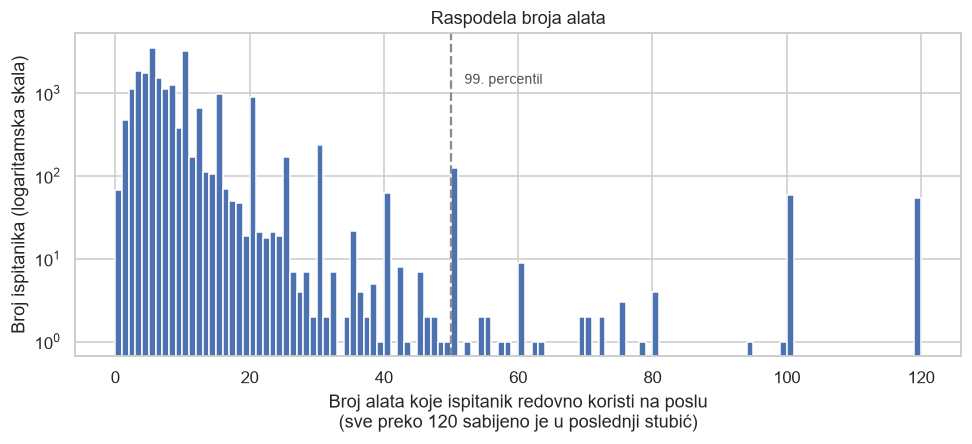

  vrednost tačno  50:  125 ispitanika
  vrednost tačno  60:    9 ispitanika
  vrednost tačno  80:    4 ispitanika
  vrednost tačno 100:   60 ispitanika
  vrednost tačno 120:    1 ispitanika


In [52]:
fig, ax = plt.subplots(figsize=(9, 4.2))

values = cleaned["ToolCountWork"].dropna()
ax.hist(np.clip(values, 0, 120), bins=120, color="#4C72B0")
ax.axvline(values.quantile(0.99), color="#8C8C8C", linestyle="--", linewidth=1.5)
ax.text(values.quantile(0.99) + 2, ax.get_ylim()[1] * 0.35,
        "99. percentil", color="#4C4C4C", fontsize=9)

ax.set_yscale("log")
ax.set_xlabel("Broj alata koje ispitanik redovno koristi na poslu\n"
              "(sve preko 120 sabijeno je u poslednji stubić)")
ax.set_ylabel("Broj ispitanika (logaritamska skala)")
ax.set_title("Raspodela broja alata")
plt.tight_layout()
plt.show()

for value in [50, 60, 80, 100, 120]:
    print(f"  vrednost tačno {value:>3}: {int((values == value).sum()):>4} ispitanika")

**Zapažanje:** do pedesetak alata raspodela glatko opada. Posle toga se ne proređuje ravnomerno nego
skače na okruglim brojevima. Na vrednosti tačno **50** stoji **125 ispitanika**, a na tačno **100**
njih **60** — znatno više nego na susednim vrednostima, gde ih je po nekoliko.

**Tumačenje:** taj oblik je potpis odgovora datog odoka. Ko stvarno broji alate ne završi baš na
okruglih sto, a ko ne broji nego procenjuje, bira okruglu vrednost. Granica sa 99. percentila pada
tačno tamo gde glatki deo raspodele prestaje, pa je grafik podržava.

In [53]:
# The 99th percentile of ToolCountWork, above which the distribution consists of
# round numbers only; the same, looser bound is applied to ToolCountPersonal.
TOOL_LIMIT = 50

for column in ["ToolCountWork", "ToolCountPersonal"]:
    suspicious = cleaned[column] > TOOL_LIMIT
    cleaned.loc[suspicious, column] = np.nan
    print(f"{column:<18} poništeno {int(suspicious.sum()):>4}   "
          f"novi maksimum: {cleaned[column].max():.0f}   "
          f"nedostaje {100 * cleaned[column].isna().mean():.1f}%")

print()
zero_or_less = cleaned["CompTotal"] <= 0
print(f"CompTotal <= 0: {int(zero_or_less.sum())},  od njih sa vrednošću u "
      f"ConvertedCompYearly: {int(cleaned.loc[zero_or_less, 'ConvertedCompYearly'].notna().sum())}")

ToolCountWork      poništeno  149   novi maksimum: 50   nedostaje 40.4%
ToolCountPersonal  poništeno  110   novi maksimum: 50   nedostaje 47.3%

CompTotal <= 0: 77,  od njih sa vrednošću u ConvertedCompYearly: 0


**Zapažanje:** poništeno je **149 vrednosti kod `ToolCountWork` i 110 kod `ToolCountPersonal`**, i kod
obe je maksimum sada 50. Kod `CompTotal` je 77 redova sa nulom ili manje, i **nijedan od njih nema
vrednost u `ConvertedCompYearly`**.

**Tumačenje:** poslednji nalaz je zanimljiv — Stack Overflow te iznose **već tretira kao neispravne**,
pa im nije ni izračunao dolarsku vrednost. To se slaže sa onim što smo utvrdili u prethodnom delu, da je konverzija dosledna. Pošto `CompTotal` ionako izbacujemo zbog curenja podataka, tu
ništa ne moramo da radimo.

### 17.5 Kolone sa rangiranjem

Preostale 43 numeričke kolone dolaze iz pitanja oblika „poređaj sledeće po važnosti" — `TechEndorse`,
`TechOppose`, `JobSatPoints` i `SO_Actions`. Svaka kolona nosi rang koji je ispitanik dodelio jednoj
stavci.

Kod njih nema smisla pitati da li je vrednost prevelika, jer ne znamo koliko je stavki ponuđeno. Ali
postoji drugo pravilo, koje sledi iz same prirode rangiranja: **isti ispitanik ne može dvema stavkama
dati isti rang.** Ako se to dogodi, odgovor je neispravan.

In [54]:
# Ranking questions export one column per item, named "<question>_<number>".
# We find those groups instead of listing them by hand.
numeric_columns = cleaned.select_dtypes(include="number").columns
groups = {}
for column in numeric_columns:
    match = re.fullmatch(r"(.+?)_(\d+)", column)
    if match:
        groups.setdefault(match.group(1), []).append(column)

rank_groups = {name: cols for name, cols in groups.items() if len(cols) >= 5}
print(f"pronađeno grupa sa rangiranjem: {len(rank_groups)}")
print()

for name, group in rank_groups.items():
    answers = cleaned[group]
    answered = answers.notna().any(axis=1)
    filled = answers[answered].notna().sum(axis=1)
    distinct = answers[answered].apply(lambda row: row.dropna().nunique(), axis=1)
    repeated = (filled != distinct)
    print(f"{name:<13} kolona={len(group):>2}   odgovorilo={int(answered.sum()):>6,}   "
          f"ponovljen rang kod {int(repeated.sum())} ispitanika")

pronađeno grupa sa rangiranjem: 4



TechEndorse   kolona=10   odgovorilo=25,845   ponovljen rang kod 0 ispitanika


TechOppose    kolona=10   odgovorilo=24,600   ponovljen rang kod 0 ispitanika


JobSatPoints  kolona=13   odgovorilo=23,364   ponovljen rang kod 0 ispitanika


SO_Actions    kolona=10   odgovorilo=18,945   ponovljen rang kod 0 ispitanika


**Zapažanje:** ni u jednoj od četiri grupe **nema nijednog ispitanika koji je dva puta dodelio isti
rang**. Sve četiri provere vraćaju nulu.

**Tumačenje:** te kolone su interno ispravne i nemamo šta da čistimo. To je i očekivano, jer anketni
softver obično sam ne dozvoljava dva ista ranga — ali dok se ne proveri, to je pretpostavka, a ne
podatak.

Ovim je i njih pokrilo isto pravilo kao i ostale kolone: proverili smo ih onom proverom koja za njihov
tip ima smisla. Da li ćemo ih koristiti kao promenljive je zasebno pitanje i rešava se u sekciji 19,
zajedno sa svim ostalim kolonama.

### Šta je sekcija promenila

Nijedan red nije izbačen — populacija je i dalje **34.106 ispitanika**. Promenjene su pojedinačne
vrednosti:

- beline i kontrolni karakteri normalizovani u svim tekstualnim kolonama, čime je `Currency` dobila
  dosledan zapis;
- odgovori koji prikrivaju postojeću osobinu pretvoreni u `NA` — 92 vrednosti u `Age` i 535 u
  `OrgSize`; nesigurnost koja je i sama odgovor, kao u `AIThreat` i `AISent`, zadržana je kao
  kategorija;
- nemoguć staž poništen u 324 reda kod `WorkExp` i 61 kod `YearsCode`;
- broj alata iznad 99. percentila poništen — 149 vrednosti kod `ToolCountWork` i 110 kod
  `ToolCountPersonal`;
- `MainBranch` zabeležena kao konstantna, `CompTotal` kao kolona sa besmislenim unosima — obe ispadaju
  u sekciji 19, iz drugih razloga;
- četiri grupe kolona sa rangiranjem proverene i ispravne.

Sada kada nemogućih vrednosti nema, kvartili i IQR računaju se nad ispravnim podacima, pa možemo da
pređemo na netipične vrednosti.

## 18. Hipoteza 4 — netipične vrednosti u ciljnoj promenljivoj

Do sada smo sklanjali vrednosti koje su **nemoguće**. Sada dolaze one koje su moguće ali ekstremne, i
tu se pravilo ne izvodi iz značenja kolone nego iz raspodele.

U prethodnom delu smo videli da su problematična **oba kraja**: najmanja prijavljena kompenzacija
je jedan dolar, a najveća pedeset miliona. Logaritamska transformacija je sredila desni rep ali je
otkrila levi, pa ekstremi ostaju otvoreno pitanje.

Sa predavanja imamo dva postupka za traženje netipičnih vrednosti. Pravilo tri sigme i z-skor su
**parametarski** — pretpostavljaju normalnu raspodelu. Boxplot i IQR su **neparametarski** i ne
pretpostavljaju ništa o obliku. Pošto smo već pokazali da raspodela kompenzacije nije ni blizu
normalne, parametarski postupci otpadaju i radimo sa IQR-om.

Granice su uobičajene: sve ispod `Q1 − 1,5 × IQR` i iznad `Q3 + 1,5 × IQR`.

Otvoreno je, međutim, **nad kojim skupom** te granice računamo — nad celim svetom odjednom ili unutar
svake zemlje posebno.

> **Hipoteza:** granice se moraju računati unutar zemlje. Globalno pravilo, primenjeno na ceo uzorak
> odjednom, ne razlikuje neispravan podatak od uobičajene plate u siromašnijoj zemlji.
>
> **Kriterijum, postavljen unapred:** hipoteza je potvrđena ako globalno pravilo pogađa zemlje krajnje
> neravnomerno — ako se udeo označenih u najpogođenijoj zemlji višestruko razlikuje od udela u
> najmanje pogođenoj. Ako je taj udeo približno isti svuda, pravilo hvata greške a ne siromašnija
> tržišta, i deljenje po zemljama nije potrebno.

In [55]:
target_rows = cleaned.dropna(subset=["ConvertedCompYearly"]).copy()
target_rows["log_comp"] = np.log10(target_rows["ConvertedCompYearly"])

print(f"ispitanika sa prijavljenom platom: {len(target_rows):,}")


def iqr_bounds(values):
    """Classic boxplot fences: 1.5 IQR below Q1 and above Q3."""
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    spread = q3 - q1
    return q1 - 1.5 * spread, q3 + 1.5 * spread


low, high = iqr_bounds(target_rows["ConvertedCompYearly"])
below = (target_rows["ConvertedCompYearly"] < low).sum()
above = (target_rows["ConvertedCompYearly"] > high).sum()

print()
print("IQR nad sirovim vrednostima:")
print(f"  donja granica: {low:>12,.0f} USD")
print(f"  gornja granica:{high:>12,.0f} USD")
print(f"  označeno ispod: {below:>5}    iznad: {above:>5}    "
      f"ukupno {100 * (below + above) / len(target_rows):.1f}%")

ispitanika sa prijavljenom platom: 19,461

IQR nad sirovim vrednostima:
  donja granica:      -77,370 USD
  gornja granica:     246,422 USD
  označeno ispod:     0    iznad:   853    ukupno 4.4%


**Zapažanje:** donja granica ispada **negativna**, −**77.370** dolara. Zbog toga ispod nje ne pada
**nijedan** ispitanik, dok je iznad gornje granice označeno **853 njih**.

**Tumačenje:** postupak je ovde beskoristan za polovinu problema. Raspodela je toliko iskošena udesno
da je razmak između kvartila veliki, pa donja granica sklizne ispod nule — a plata ne može biti
negativna. Ispitanik koji je prijavio jedan dolar godišnje prolazi kao sasvim uredan.

To nije mana IQR-a nego posledica toga što ga primenjujemo na pogrešnoj skali. Već smo odlučili da
ciljnu promenljivu modelujemo u logaritamskom obliku, pa je prirodno da i granice tražimo tamo — na
logaritamskoj skali raspodela je približno simetrična, što je ono na šta se boxplot i oslanja.

In [56]:
log_low, log_high = iqr_bounds(target_rows["log_comp"])
target_rows["globalno_netipican"] = (
    (target_rows["log_comp"] < log_low) | (target_rows["log_comp"] > log_high)
)

print("IQR nad logaritmovanim vrednostima:")
print(f"  donja granica: {10 ** log_low:>12,.0f} USD")
print(f"  gornja granica:{10 ** log_high:>12,.0f} USD")
print(f"  označeno ispod: {(target_rows['log_comp'] < log_low).sum():>5}    "
      f"iznad: {(target_rows['log_comp'] > log_high).sum():>5}    "
      f"ukupno {100 * target_rows['globalno_netipican'].mean():.1f}%")

IQR nad logaritmovanim vrednostima:
  donja granica:        9,216 USD
  gornja granica:     597,484 USD
  označeno ispod:  1581    iznad:   106    ukupno 8.7%


**Zapažanje:** granice su sada **9.216 i 597.484 dolara**, i obe strane su u igri — ispod je označen
**1.581 ispitanik**, iznad **106**, ukupno **8,7%**.

**Tumačenje:** postupak sada vidi i donji kraj, što je bio ceo problem sa sirovom skalom. Ali pre nego
što bilo šta izbacimo, vredi pogledati **ko** je time označen. Granica od 9.216 dolara je za nekoga u
Švajcarskoj nezamisliva, a za nekoga u Indiji sasvim uobičajena plata.

In [57]:
# For every country, how many of its respondents the global rule just marked.
flagged_by_country = target_rows.groupby("Country").agg(
    ispitanika=("log_comp", "size"),
    oznaceno_globalnim=("globalno_netipican", "sum"),
)
flagged_by_country["udeo_%"] = (
    100 * flagged_by_country["oznaceno_globalnim"] / flagged_by_country["ispitanika"]).round(1)
flagged_by_country = flagged_by_country[flagged_by_country["ispitanika"] >= 100]
flagged_by_country = flagged_by_country.sort_values("udeo_%", ascending=False)

print(f"globalno pravilo označilo ukupno: {int(target_rows['globalno_netipican'].sum()):,} ispitanika")
print()
print("zemlje sa najvećim udelom označenih:")
print(flagged_by_country.head(5).to_string())
print()
print("zemlje sa najmanjim udelom označenih:")
print(flagged_by_country.tail(4).to_string())

globalno pravilo označilo ukupno: 1,687 ispitanika

zemlje sa najvećim udelom označenih:
          ispitanika  oznaceno_globalnim  udeo_%
Country                                         
Pakistan         112                  65    58.0
Ukraine          592                 201    34.0
India            900                 249    27.7
Turkey           158                  42    26.6
Colombia         100                  24    24.0

zemlje sa najmanjim udelom označenih:
                                                      ispitanika  oznaceno_globalnim  udeo_%
Country                                                                                     
Canada                                                       752                  10     1.3
Switzerland                                                  326                   4     1.2
Australia                                                    461                   5     1.1
United Kingdom of Great Britain and Northern Ireland        1242

**Zapažanje:** tabela pokazuje kako se onih 1.687 ispitanika, koje je maločas označilo globalno
pravilo, raspoređuje po zemljama. Raspored je krajnje neravnomeran: u Pakistanu je označeno **58,0%**
svih ispitanika iz te zemlje, u Ukrajini **34,0%**, u Indiji **27,7%**. Na drugom kraju su Ujedinjeno
Kraljevstvo sa **1,0%**, Australija sa 1,1% i Švajcarska sa 1,2%.

**Tumačenje:** ovo je jasan pokazatelj da pravilo ne radi ono što mislimo da radi. Nemoguće je da je
svaki drugi programer u Pakistanu netipičan slučaj — a upravo to bi značilo da ih izbacimo.

Ono što globalno pravilo zapravo prepoznaje nije neispravan podatak nego **siromašniju zemlju**. Kada
bismo tako očistili podatke, izbacili bismo dobar deo tržišta u razvoju i time dodatno pogoršali
pristrasnost uzorka koju smo utvrdili u sekciji 15, gde je brisanje već potisnulo Indiju sa 6,68% na
4,62%.

Zaključak se sam nameće: **netipičnost mora da se meri u odnosu na sredinu iz koje ispitanik dolazi**,
a ne u odnosu na ceo svet. Granice zato računamo unutar svake zemlje posebno.

In [58]:
# Fewer respondents than this cannot support their own quartiles, so for such
# countries we fall back to the global rule.
MIN_FOR_COUNTRY = 30

by_country = target_rows.groupby("Country")["log_comp"]
country_size = by_country.transform("size")
country_low = by_country.transform(lambda s: iqr_bounds(s)[0])
country_high = by_country.transform(lambda s: iqr_bounds(s)[1])

small_country = country_size < MIN_FOR_COUNTRY
within_country = (target_rows["log_comp"] < country_low) | (target_rows["log_comp"] > country_high)

target_rows["netipican"] = np.where(
    small_country, target_rows["globalno_netipican"], within_country)

country_sizes = target_rows.groupby("Country").size()
print(f"zemalja ukupno: {len(country_sizes)}   "
      f"sa bar {MIN_FOR_COUNTRY} ispitanika: {int((country_sizes >= MIN_FOR_COUNTRY).sum())}   "
      f"manjih: {int((country_sizes < MIN_FOR_COUNTRY).sum())}")
print(f"ispitanika u manjim zemljama, gde vredi globalno pravilo: {int(small_country.sum()):,}")
print()
print(f"globalno pravilo označilo:      {target_rows['globalno_netipican'].sum():>6,} "
      f"({100 * target_rows['globalno_netipican'].mean():.1f}%)")
print(f"pravilo po zemlji označilo:     {target_rows['netipican'].sum():>6,} "
      f"({100 * target_rows['netipican'].mean():.1f}%)")
print(f"označeno i po jednom i po drugom:{int((target_rows['globalno_netipican'] & target_rows['netipican']).sum()):>6,}")

zemalja ukupno: 155   sa bar 30 ispitanika: 63   manjih: 92


ispitanika u manjim zemljama, gde vredi globalno pravilo: 668

globalno pravilo označilo:       1,687 (8.7%)
pravilo po zemlji označilo:      1,201 (6.2%)
označeno i po jednom i po drugom:   775


**Zapažanje:** pravilo po zemlji označava **1.201 ispitanika (6,2%)**, naspram 1.687 (8,7%) koliko ih
je označilo globalno pravilo. Preklapanje je delimično — samo **775** ispitanika je označeno na oba
načina.

Zemalja sa bar trideset ispitanika ima **63**, a u preostalih 92 zemlje nalazi se **668 ispitanika**,
za koje i dalje važi globalno pravilo.

**Tumačenje:** to što se dve liste razilaze u skoro polovini slučajeva pokazuje da razlika nije
kozmetička. Globalno pravilo je označavalo ljude čija je plata sasvim obična za njihovu zemlju, a
propuštalo one koji odudaraju unutar bogatih tržišta.

Za zemlje sa malo ispitanika nemamo izbora — kvartili nad deset ljudi nisu pouzdani, pa tamo
zadržavamo globalno pravilo, uz svest da je ono za njih grublje.

### Grafik 15 — šta ostaje posle uklanjanja

**Motivacija:** hoćemo da vidimo kako izgleda raspodela kada se označene vrednosti izbace, i da li je
levi rep koji nas je mučio u prethodnom delu time nestao.

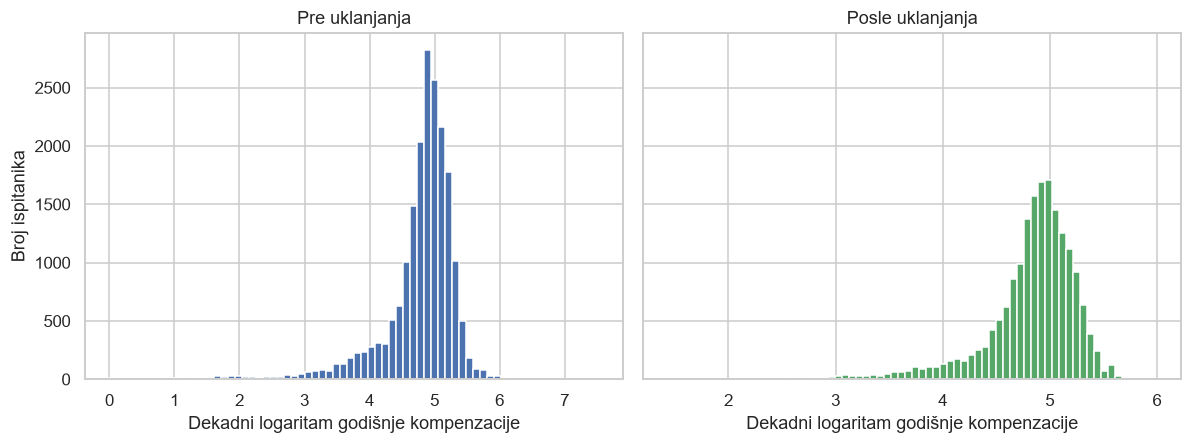

pre uklanjanja:   n=19,461   min=         1   max=  33,552,715   asimetrija= -2.67
posle uklanjanja: n=18,260   min=        27   max=   1,000,000   asimetrija= -1.84

  preostalo ispod   100 USD:    6
  preostalo ispod   500 USD:   44
  preostalo ispod 1,000 USD:  106
  preostalo ispod 2,000 USD:  234

najniža preživela vrednost: 27 USD   Viet Nam, staž 19 god.


In [59]:
kept = target_rows[~target_rows["netipican"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)

axes[0].hist(target_rows["log_comp"], bins=70, color="#4C72B0")
axes[0].set_title("Pre uklanjanja")
axes[1].hist(np.log10(kept["ConvertedCompYearly"]), bins=70, color="#55A868")
axes[1].set_title("Posle uklanjanja")

for ax in axes:
    ax.set_xlabel("Dekadni logaritam godišnje kompenzacije")
axes[0].set_ylabel("Broj ispitanika")
plt.tight_layout()
plt.show()

print(f"pre uklanjanja:   n={len(target_rows):>6,}   min={target_rows['ConvertedCompYearly'].min():>10,.0f}   "
      f"max={target_rows['ConvertedCompYearly'].max():>12,.0f}   "
      f"asimetrija={target_rows['log_comp'].skew():>6.2f}")
print(f"posle uklanjanja: n={len(kept):>6,}   min={kept['ConvertedCompYearly'].min():>10,.0f}   "
      f"max={kept['ConvertedCompYearly'].max():>12,.0f}   "
      f"asimetrija={np.log10(kept['ConvertedCompYearly']).skew():>6.2f}")
print()
for limit in [100, 500, 1000, 2000]:
    print(f"  preostalo ispod {limit:>5,} USD: {int((kept['ConvertedCompYearly'] < limit).sum()):>4}")

# Who the lowest surviving value belongs to, so the example in the text is not
# read off the chart.
lowest = kept.nsmallest(1, "ConvertedCompYearly").iloc[0]
print()
print(f"najniža preživela vrednost: {lowest['ConvertedCompYearly']:,.0f} USD   "
      f"{lowest['Country']}, staž {lowest['WorkExp']:.0f} god.")

**Zapažanje:** ostaje **18.260 ispitanika**. Levi rep je vidno kraći, a koeficijent asimetrije se
popravio sa **−2,67 na −1,84**. Najveća vrednost je pala sa 33,5 miliona na milion dolara.

Ali donji kraj nije potpuno očišćen: preostalo je **6 ispitanika ispod 100 dolara** godišnje i
**106 ispod hiljadu**.

**Tumačenje:** pravilo po zemlji je uklonilo najveći deo problema i, što je važnije, uklonilo ga je
**bez izbacivanja celih tržišta**. Ali u zemljama sa veoma širokim rasponom plata granica je široka, pa
kroz nju prođe i po koja neuverljivo mala vrednost — najniža preživela je, kako ispis pokazuje,
ispitanik iz Vijetnama sa devetnaest godina staža i prijavljenih dvadeset sedam dolara godišnje.

Mogli bismo da dodamo i donju granicu u apsolutnom iznosu, ali bi to bio broj koji bismo izmislili, a
ne izveli iz podataka — a videli smo koliko takvi pragovi umeju da promaše. Sto šest ispitanika je
0,6% skupa, pa ih ostavljamo i to navodimo kao poznato ograničenje.

Pre nego što odluku prihvatimo, vredi videti koliko zavisi od množioca u ogradi. Vrednost 1,5 je
uobičajena granica boxplota, ali ništa nas ne sprečava da je pomerimo — pa da vidimo šta bi se
dobilo.

In [60]:
for multiplier in [1.0, 1.5, 2.0, 3.0]:
    q1, q3 = target_rows["log_comp"].quantile([0.25, 0.75])
    spread = q3 - q1
    global_flag = ((target_rows["log_comp"] < q1 - multiplier * spread)
                   | (target_rows["log_comp"] > q3 + multiplier * spread))
    country_lo = by_country.transform(lambda s: s.quantile(0.25) - multiplier * (s.quantile(0.75) - s.quantile(0.25)))
    country_hi = by_country.transform(lambda s: s.quantile(0.75) + multiplier * (s.quantile(0.75) - s.quantile(0.25)))
    flag = np.where(small_country, global_flag,
                    (target_rows["log_comp"] < country_lo) | (target_rows["log_comp"] > country_hi))
    remaining = target_rows[~flag]["ConvertedCompYearly"]
    print(f"  množilac {multiplier:>3}:  označeno {int(flag.sum()):>5,} ({100 * flag.mean():>4.1f}%)   "
          f"ostaje {len(remaining):>6,}   minimum {remaining.min():>7,.0f}   "
          f"ispod 1.000 USD: {int((remaining < 1000).sum()):>4}")

  množilac 1.0:  označeno 1,980 (10.2%)   ostaje 17,481   minimum     267   ispod 1.000 USD:   64


  množilac 1.5:  označeno 1,201 ( 6.2%)   ostaje 18,260   minimum      27   ispod 1.000 USD:  106


  množilac 2.0:  označeno   814 ( 4.2%)   ostaje 18,647   minimum      11   ispod 1.000 USD:  141


  množilac 3.0:  označeno   485 ( 2.5%)   ostaje 18,976   minimum       1   ispod 1.000 USD:  171


**Zapažanje:** stezanje ograde na 1,0 uklonilo bi 1.980 ispitanika umesto 1.201 i podiglo minimum sa
27 na 267 dolara, ali bi i dalje ostavilo 64 vrednosti ispod hiljadu. Popuštanje na 2,0 ili 3,0 ostavlja
sve više neuverljivih iznosa.

**Tumačenje:** nijedna vrednost množioca ne rešava problem do kraja, pa izbor ne pravimo prema tome
koja daje najlepši rep. Zadržavamo **1,5**, standardnu granicu boxplota koju smo učili na predavanjima,
upravo zato što bi svaka druga bila birana prema željenom ishodu — a to je isti postupak kao kada
bismo prag izmislili.

**Verdikt: hipoteza je potvrđena.** Globalno pravilo je označilo **58,0% svih Pakistanaca i 27,7%
Indijaca, naspram 1,0% ispitanika iz Ujedinjenog Kraljevstva** — raspon koji je daleko iznad
kriterijuma koji smo postavili. Pravilo po zemlji označava 1.201 ispitanika umesto 1.687, a sa
globalnim se poklapa u samo 775 slučajeva, pa razlika između njih nije kozmetička.

**Odluka:** iz skupa za modelovanje uklanjamo 1.201 ispitanika označenog kao netipičnog, po granicama
računatim unutar zemlje, uz globalno pravilo kao rezervu za 92 zemlje sa manje od trideset ispitanika.
Kod ciljne promenljive uklanjanje reda je jedino što možemo — vrednost se ne sme imputirati, pa red bez
upotrebljive plate nema šta da radi u treningu.

In [61]:
cleaned = cleaned.loc[kept.index].copy()

print(f"populacija posle sekcije 14:     {len(population):>7,}")
print(f"od toga sa prijavljenom platom:  {len(target_rows):>7,}")
print(f"posle uklanjanja netipičnih:     {len(cleaned):>7,}")
print()
print(f"provera: redova bez ciljne promenljive: "
      f"{int(cleaned['ConvertedCompYearly'].isna().sum())}")
print(f"raspon ciljne promenljive: {cleaned['ConvertedCompYearly'].min():,.0f} "
      f"do {cleaned['ConvertedCompYearly'].max():,.0f} USD")

populacija posle sekcije 14:      34,106
od toga sa prijavljenom platom:   19,461
posle uklanjanja netipičnih:      18,260

provera: redova bez ciljne promenljive: 0
raspon ciljne promenljive: 27 do 1,000,000 USD


### Šta je sekcija promenila

Skup za modelovanje je sada **18.260 ispitanika** — od 34.106 iz populacije, kroz izostavljanje onih
bez prijavljene plate i uklanjanje netipičnih vrednosti.

Za razliku od sekcije 17, ovde **jesmo brisali redove**. Razlog je što se radi o ciljnoj promenljivoj:
kod prediktora se pogrešna vrednost može poništiti pa kasnije imputirati, ali plata koju model treba da
nauči ne sme da se izmišlja.

Usput smo odbacili dva postupka pre nego što smo stigli do upotrebljivog: IQR nad sirovim vrednostima
nije video donji kraj, a IQR nad logaritmom je označavao siromašnije zemlje umesto grešaka. Oba
neuspeha su zapisana jer objašnjavaju zašto je konačno pravilo takvo kakvo jeste.

## 19. Izbor kolona

Do sada smo čistili vrednosti; sada odlučujemo koje kolone uopšte ostaju. Anketa ih ima preko sto
sedamdeset, a svaka je nečije pitanje, pa se lako upada u zamku da se sve zadrži „za svaki slučaj".

Zašto to ne valja, najlakše je videti na broju. Kategorijska kolona ne ulazi u model kao jedna
promenljiva nego kao onoliko njih koliko ima kategorija — to je one-hot enkodiranje koje smo učili na
predavanjima. Da vidimo koliko bi kolona time nastalo.

In [62]:
text_like = [c for c in cleaned.columns if cleaned[c].dtype.kind in "OU"
             or str(cleaned[c].dtype) in ("str", "string")]
naive_columns = sum(cleaned[c].nunique(dropna=True) for c in text_like)

print(f"tekstualnih kolona: {len(text_like)}")
print(f"kolona posle naivnog one-hot enkodiranja: ~{naive_columns:,}")
print(f"redova u skupu: {len(cleaned):,}")

tekstualnih kolona: 119
kolona posle naivnog one-hot enkodiranja: ~159,854
redova u skupu: 18,260


**Zapažanje:** naivno enkodiranje svih 119 tekstualnih kolona dalo bi oko **159.854 kolone** naspram
**18.260 redova** — skoro devet puta više prediktora nego ispitanika.

**Tumačenje:** najveći deo tog broja dolazi od multi-select kolona, gde je odgovor jedan string sa svim
izabranim stavkama, pa svaka različita kombinacija postaje sopstvena kategorija. To je usput i
najjasniji argument da se te kolone ne smeju enkodirati kao obične kategorije nego iz njih treba
izvesti nove promenljive — posao koji nas čeka u sledećem delu.

Ali i bez njih broj ostaje prevelik. Kada bi prediktora bilo koliko i opservacija, model bi savršeno
naučio trening skup a na testu ne bi vredeo ništa — kraj bias-variance krive na kom varijansa preuzima
sve.

Ovde ne biramo konačni skup promenljivih; to je posao feature engineeringa i formalne selekcije u
modelovanju. Ovde samo **izbacujemo ono što je neupotrebljivo iz razloga koji nema veze sa modelom**:
kolone koje bi curile, koje ništa ne razlikuju, ili kojih naprosto nema. Svaki kriterijum mora da bude
obrazložen, a granice koje se u njima pojavljuju izvedene iz podataka a ne izabrane.

In [63]:
# Helper flags we added ourselves; they describe our own work, not the respondent.
DERIVED = ["prijavio_platu", "prekinuo_anketu"]

candidates = cleaned.drop(columns=DERIVED)
print(f"kolona na početku: {len(candidates.columns)}")
print(f"redova:            {len(candidates):,}")

kolona na početku: 170
redova:            18,260


### 19.1 Kolone koje bi curile ili ništa ne razlikuju

Prva tri kriterijuma su neposredna i ne traže nikakav račun.

**Ciljna promenljiva i njen izvor.** `ConvertedCompYearly` je ono što predviđamo, pa nije prediktor.
`CompTotal` iz nje sledi deljenjem kursom, što smo u prethodnom delu i dokazali — model bi je
iskoristio da rekonstruiše odgovor umesto da išta nauči.

**Identifikator.** `ResponseId` je redni broj odgovora i ne meri nikakvu osobinu ispitanika.

**Konstantne kolone.** Kolona sa jednom jedinom vrednošću ne razlikuje nijednog ispitanika od drugog,
pa u modelu ne može ništa da doprinese.

In [64]:
drop_reasons = {}


def mark(columns, reason):
    """Record why a column leaves, keeping the first reason that applied."""
    for column in columns:
        drop_reasons.setdefault(column, reason)


mark(["ConvertedCompYearly", "CompTotal"], "ciljna promenljiva i njen izvor")
mark(["ResponseId"], "identifikator")
mark([c for c in candidates.columns if candidates[c].nunique(dropna=True) <= 1], "konstantna")

for reason in dict.fromkeys(drop_reasons.values()):
    columns = [c for c, r in drop_reasons.items() if r == reason]
    print(f"{reason:<32} {len(columns):>3}   {columns}")

ciljna promenljiva i njen izvor    2   ['ConvertedCompYearly', 'CompTotal']
identifikator                      1   ['ResponseId']
konstantna                         1   ['MainBranch']


**Zapažanje:** po ova tri kriterijuma izlaze četiri kolone. Konstantna je samo `MainBranch`, i to zato
što smo u sekciji 14 populaciju suzili baš po njoj.

**Tumačenje:** ovo je bilo očekivano i nije donelo iznenađenja. Prava odluka je u sledeća dva
kriterijuma, gde treba postaviti granicu.

### 19.2 Kolone kojih uglavnom nema

Kolona u kojoj nedostaje većina vrednosti ne može mnogo da doprinese, a imputacija nad njom bi značila
da veći deo kolone izmišljamo.

Pitanje je gde povući granicu. Umesto da izaberemo okrugao broj, poređaćemo kolone po udelu
nedostajućih vrednosti i potražiti mesto gde niz **sam pravi prekid**.

In [65]:
missing_share = (candidates.isna().mean() * 100).sort_values()
jumps = missing_share.diff()

print("najveći skokovi u poređanom nizu:")
for column in jumps.nlargest(4).index:
    print(f"  sa {missing_share[column] - jumps[column]:>5.1f}% na {missing_share[column]:>5.1f}%"
          f"   (skok {jumps[column]:.1f} pp, kod kolone {column})")

najveći skokovi u poređanom nizu:
  sa  48.4% na  57.7%   (skok 9.3 pp, kod kolone SOTagsWantToWorkWith)
  sa  74.0% na  79.7%   (skok 5.7 pp, kod kolone AIAgentImpactStrongly agree)
  sa  69.5% na  74.0%   (skok 4.4 pp, kod kolone AIAgentExternal)
  sa  83.1% na  87.2%   (skok 4.1 pp, kod kolone AIAgentImpactStrongly disagree)


### Grafik 16 — gde niz pravi prekid

**Motivacija:** hoćemo da vidimo kako izgleda poređani niz udela nedostajućih vrednosti i da li je
najveći skok zaista prirodna granica, ili je samo najveći među mnogo sličnih.

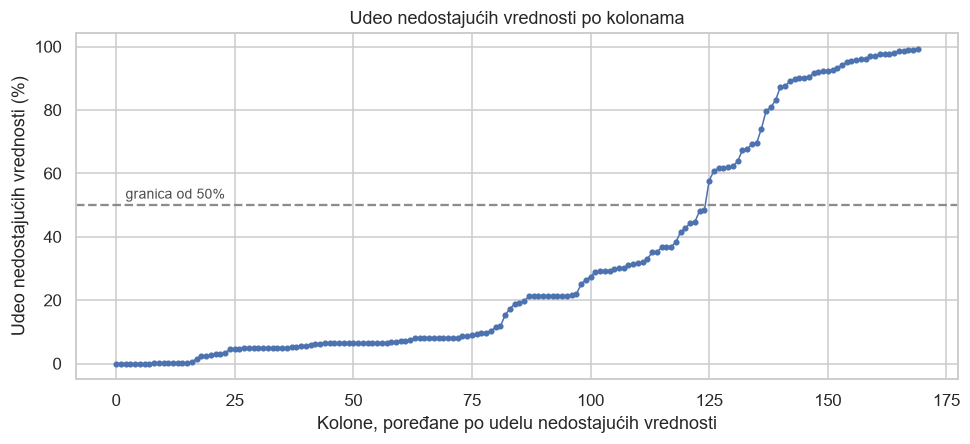

kolona ispod 50%: 125
kolona iznad 50%: 45


In [66]:
fig, ax = plt.subplots(figsize=(9, 4.2))

ax.plot(range(len(missing_share)), missing_share.values, marker="o",
        markersize=3, linewidth=1, color="#4C72B0")
ax.axhline(50, color="#8C8C8C", linestyle="--", linewidth=1.5)
ax.text(2, 52, "granica od 50%", color="#4C4C4C", fontsize=9)

ax.set_xlabel("Kolone, poređane po udelu nedostajućih vrednosti")
ax.set_ylabel("Udeo nedostajućih vrednosti (%)")
ax.set_title("Udeo nedostajućih vrednosti po kolonama")
plt.tight_layout()
plt.show()

print(f"kolona ispod 50%: {int((missing_share < 50).sum())}")
print(f"kolona iznad 50%: {int((missing_share > 50).sum())}")

**Zapažanje:** kriva raste postepeno do oko pedeset procenata, gde pravi **najveći skok u celom nizu —
sa 48,4% na 57,7%, dakle 9,3 procentna poena odjednom**. Posle toga se nastavlja glatko do vrha. Ispod
te granice je 125 kolona, iznad nje 45.

**Tumačenje:** prekid nije nešto što smo mi postavili nego nešto što u podacima postoji. Ispod njega su
pitanja koja je većina ispitanika videla, iznad njega pitanja koja su se pojavljivala samo pod
određenim uslovima — pretežno potpitanja o AI agentima, koja su postavljena samo onima koji su rekli da
ih koriste.

Granicu zato postavljamo na **50%**, ne zato što je okrugao broj, nego zato što se tu niz sam prelama.

Vredi napomenuti šta to znači za te kolone: one nisu bezvredne, ali su odgovor na drugačije pitanje.
Kolona koju je popunilo samo 30% ispitanika govori o toj trećini, a ne o celom uzorku, pa bi njeno
zadržavanje značilo da model uči na različitim skupovima ljudi za različite promenljive.

In [67]:
# Where the sorted sequence makes its largest jump, from 48.4% to 57.7%.
MISSING_LIMIT = 50

mark(missing_share[missing_share > MISSING_LIMIT].index, "preko 50% nedostaje")

print(f"izbačeno po ovom kriterijumu: "
      f"{sum(1 for r in drop_reasons.values() if r == 'preko 50% nedostaje')}")
print()
print("primeri:")
for column in list(missing_share[missing_share > MISSING_LIMIT].index)[:6]:
    print(f"  {column:<38} nedostaje {missing_share[column]:.1f}%")

izbačeno po ovom kriterijumu: 45

primeri:
  SOTagsWantToWorkWith                   nedostaje 57.7%
  AIAgentChallengesSomewhat disagree     nedostaje 60.8%
  AIToolPlan to mostly use AI            nedostaje 61.6%
  SOTagsAdmired                          nedostaje 61.8%
  AIAgent_Uses                           nedostaje 61.9%
  AIModelsWantToWorkWith                 nedostaje 62.2%


Među izbačenim kolonama vide se imena poput `AIAgentChallengesSomewhat disagree`, koja na prvi pogled
deluju kao greška. Nisu: šema to pitanje označava kao tip `Matrix`, a takva pitanja Stack Overflow
izvozi tako što ime kolone sastavi od naziva pitanja i teksta ponuđene opcije — pa je ovo opcija
„Somewhat disagree" na pitanju `AIAgentChallenges`. Da vidimo koliko takvih imena uopšte ima.

In [68]:
odd_names = [c for c in cleaned.columns if not re.fullmatch(r"[A-Za-z0-9_]+", c)]
print(f"kolona sa razmakom ili znakom van slova i cifara: {len(odd_names)}")
for name in odd_names[:5]:
    print(f"  {name!r}")
print()
print(f"od njih preživelo dosadašnje kriterijume: "
      f"{len([c for c in odd_names if c not in drop_reasons])}")
print()
question_types = schema.drop_duplicates(subset="qname").set_index("qname")["type"]
print(f"tip pitanja AIAgentChallenges u šemi: {question_types['AIAgentChallenges']}")

kolona sa razmakom ili znakom van slova i cifara: 16
  'SOTagsWant Entry'
  'OpSysPersonal use'
  'OpSysProfessional use'
  'AIToolCurrently partially AI'
  "AIToolDon't plan to use AI for this task"

od njih preživelo dosadašnje kriterijume: 7

tip pitanja AIAgentChallenges u šemi: Matrix


**Zapažanje:** takvih imena ima **šesnaest**, a dosadašnje kriterijume je preživelo **sedam** od njih.
Šema potvrđuje i objašnjenje: `AIAgentChallenges` je pitanje tipa **Matrix**.

**Tumačenje:** imena su neuredna ali nisu neispravna, pa ih ne diramo. Ono što je bitno je da ostalih
sedam i dalje moramo da obradimo kao obične kolone, jer kroz njih prolaze isti kriterijumi kao i kroz
sve druge.

### 19.3 Kolone sa slobodnim tekstom

Deo pitanja traži da ispitanik sam upiše odgovor — koji alat koristi ako ga nema na spisku, ili šta
misli o nekoj temi. Takve kolone su upotrebljive tek uz obradu prirodnog jezika, što je van onoga čime
se ovde bavimo.

Prepoznati ih po broju različitih vrednosti nije pouzdano: `Country` ima 177 različitih vrednosti a
sasvim je uredna kategorija. Bolji pokazatelj je **koliko se odgovora javlja samo jednom**. Kod prave
kategorije skoro svaki odgovor deli još neko; kod slobodnog teksta većina je jedinstvena.

In [69]:
# Selecting by dtype kind rather than by name, so the check does not depend on
# whether pandas stores the column as a dedicated string dtype or as object.
def is_text(series):
    return series.dtype.kind in "OU" or str(series.dtype) in ("str", "string")


text_columns_left = [c for c in candidates.columns
                     if c not in drop_reasons and is_text(candidates[c])]

# Multi-select answers are one string with ";" separators; they are handled in
# feature engineering, not here.
multi_select = [c for c in text_columns_left
                if candidates[c].dropna().astype(str).str.contains(";").mean() > 0.3]

uniqueness = {}
for column in text_columns_left:
    if column in multi_select:
        continue
    answers = candidates[column].dropna()
    if len(answers) == 0:
        continue
    counts = answers.value_counts()
    uniqueness[column] = 100 * (counts == 1).sum() / len(answers)

uniqueness = pd.Series(uniqueness).sort_values()
print(f"tekstualnih kolona za proveru: {len(uniqueness)}   "
      f"(multi-select odvojeno: {len(multi_select)})")
print()
print("udeo odgovora koji se javljaju samo jednom:")
for low, high in [(0, 1), (1, 10), (10, 20), (20, 50), (50, 101)]:
    print(f"  {low:>3}-{high:>3}%: {int(((uniqueness >= low) & (uniqueness < high)).sum()):>3} kolona")
print()
print(f"najviši među kategorijama: {uniqueness[uniqueness < 20].max():.2f}%  "
      f"({uniqueness[uniqueness < 20].idxmax()})")
print(f"najniži među slobodnim tekstom: {uniqueness[uniqueness > 20].min():.1f}%  "
      f"({uniqueness[uniqueness > 20].idxmin()})")

tekstualnih kolona za proveru: 37   (multi-select odvojeno: 36)

udeo odgovora koji se javljaju samo jednom:
    0-  1%:  35 kolona
    1- 10%:   0 kolona
   10- 20%:   0 kolona
   20- 50%:   1 kolona
   50-101%:   1 kolona

najviši među kategorijama: 0.13%  (EmploymentAddl)
najniži među slobodnim tekstom: 41.4%  (AIExplain)


**Zapažanje:** razdvajanje je potpuno, ali kolona za proveru je ostalo manje nego što smo očekivali —
svega **37**, jer je prethodni kriterijum već uklonio većinu. Od njih **35 ima ispod jednog procenta**
jedinstvenih odgovora, a **dve preko dvadeset**. Između jednog i dvadeset procenata **nema nijedne**.

Najviša vrednost među kategorijama je **0,13%** (`EmploymentAddl`), a najniža među kolonama sa slobodnim
tekstom **41,4%** (`AIExplain`). Između te dve vrednosti nema nijedne kolone.

**Tumačenje:** prag ne moramo da biramo, jer ga podaci sami postavljaju: kolona je ili kategorija u
kojoj se odgovori ponavljaju, ili slobodan tekst u kome skoro svako piše svoje. Stavljamo ga na 20%,
ali bilo gde u praznini dalo bi isti rezultat.

Zanimljivo je da ovaj kriterijum na kraju izbacuje samo dve kolone. Sva ona polja tipa „upišite ako
vašeg alata nema na spisku" već su ispala zbog nedostajućih vrednosti — i to ima smisla, jer ih po
prirodi popunjava mali broj ispitanika. Dva kriterijuma se, dakle, delimično preklapaju, ali svaki
hvata i nešto što onaj drugi ne bi.

`Country` je dobra kontrola — sa 177 različitih vrednosti bi po broju kategorija delovala sumnjivo, ali
po ovom merilu ima svega **0,09%** jedinstvenih odgovora i pada duboko među obične kategorije, gde i
pripada.

In [70]:
# Anywhere inside the empty band between 0.13% and 41.4% gives the same split.
UNIQUE_LIMIT = 20

mark(uniqueness[uniqueness > UNIQUE_LIMIT].index, "slobodan tekst")

free_text = [c for c, r in drop_reasons.items() if r == "slobodan tekst"]
print(f"izbačeno kao slobodan tekst: {len(free_text)}")
print(f"  primeri: {free_text[:5]}")
print()
print(f"provera: Country je zadržan? {'Country' not in drop_reasons}   "
      f"udeo jedinstvenih kod njega: {uniqueness['Country']:.2f}%")

izbačeno kao slobodan tekst: 2
  primeri: ['AIExplain', 'AIOpen']

provera: Country je zadržan? True   udeo jedinstvenih kod njega: 0.09%


### Šta ostaje

In [71]:
kept_columns = [c for c in candidates.columns if c not in drop_reasons]
model_data = candidates[kept_columns].copy()

summary = pd.Series(drop_reasons).value_counts()
print("izbačeno po kriterijumu:")
print(summary.to_string())
print(f"{'ukupno izbačeno':<32} {len(drop_reasons)}")
print()
print(f"kolona pre izbora:  {len(candidates.columns):>4}")
print(f"kolona posle:       {len(model_data.columns):>4}")
print()

numeric_left = model_data.select_dtypes(include="number").columns
still_multi = [c for c in model_data.columns
               if c not in numeric_left
               and model_data[c].dropna().astype(str).str.contains(";").mean() > 0.3]
print("šta je ostalo:")
print(f"  numeričkih:              {len(numeric_left):>4}")
print(f"  multi-select:            {len(still_multi):>4}")
print(f"  običnih kategorijskih:   "
      f"{len(model_data.columns) - len(numeric_left) - len(still_multi):>4}")

izbačeno po kriterijumu:
preko 50% nedostaje                45
ciljna promenljiva i njen izvor     2
slobodan tekst                      2
identifikator                       1
konstantna                          1
ukupno izbačeno                  51

kolona pre izbora:   170
kolona posle:        119



šta je ostalo:
  numeričkih:                48
  multi-select:              36
  običnih kategorijskih:     35


**Zapažanje:** od 170 kolona izbačena je 51, ostaje ih **119**: 48 numeričkih, 36 multi-select i 35
običnih kategorijskih.

**Tumačenje:** broj je i dalje velik, i to je u redu — ovaj korak nije trebalo da da konačan skup
promenljivih. On je uklonio ono što je neupotrebljivo bez obzira na model: kolone koje bi curile,
kolone kojih uglavnom nema, i kolone koje su zapravo tekst.

Ono što ostaje nije spremno za model onakvo kakvo jeste. Trideset šest multi-select kolona su i dalje
stringovi sa tačka-zarezom, a četrdeset tri numeričke kolone su rangiranja koja tek treba osmisliti kako
koristiti. To je posao feature engineeringa u sledećem delu, gde se iz njih izvode nove
promenljive, i formalne selekcije u modelovanju, gde se meri koja od njih zaista nosi signal.

## 20. Nedostajuće vrednosti u preostalim kolonama

Nedostajanje ciljne promenljive rešili smo u sekciji 14 — izbacivanjem, jer se plata ne sme izmišljati.
Sada dolaze prediktori, gde je situacija drugačija: red se ne baca zbog jednog praznog polja, nego se
polje popunjava.

Ali pre nego što bilo šta popunimo, treba da razumemo **zašto** vrednost nedostaje. Na predavanjima smo
učili da izbor između brisanja i imputacije zavisi od toga da li je nedostajanje slučajno, i da
imputacija uvek unosi neku pristrasnost. Prazno polje kod nekoga ko je pitanje video i preskočio nije
isto što i prazno polje kod nekoga kome pitanje nije ni prikazano.

In [72]:
features = model_data
missing_share_left = (features.isna().mean() * 100).sort_values(ascending=False)

print(f"kolona u skupu: {len(features.columns)}")
print(f"  bez ijedne nedostajuće vrednosti: {int((missing_share_left == 0).sum())}")
print(f"  sa nedostajućim vrednostima:      {int((missing_share_left > 0).sum())}")
print()
print("kolone bez ijedne nedostajuće vrednosti:")
print(f"  {list(missing_share_left[missing_share_left == 0].index)}")
print()
print("deset sa najviše nedostajućih:")
print(missing_share_left.head(10).round(1).to_string())

kolona u skupu: 119
  bez ijedne nedostajuće vrednosti: 4
  sa nedostajućim vrednostima:      115

kolone bez ijedne nedostajuće vrednosti:
  ['Country', 'DevType', 'Employment', 'Currency']

deset sa najviše nedostajućih:
WebframeAdmired             48.4
AIModelsHaveWorkedWith      48.2
SOTagsHaveWorkedWith        44.7
DatabaseAdmired             44.3
WebframeWantToWorkWith      42.7
PlatformAdmired             41.6
DevEnvsAdmired              38.3
DatabaseWantToWorkWith      36.8
PlatformWantToWorkWith      36.8
AIAgentChallengesNeutral    36.7


**Zapažanje:** samo **četiri kolone** nemaju nijednu nedostajuću vrednost — `Country`, `DevType`,
`Employment` i `Currency`. To su pitanja sa početka ankete, koja su svi videli. `Age` im je bila peta
dok joj u sekciji 17.2 nismo poništili 92 odgovora „radije ne bih rekao“.

Na drugom kraju su kolone kojima nedostaje između trideset i pedeset posto, uglavnom pitanja o
tehnologijama koje bi ispitanik voleo da koristi.

**Tumačenje:** ovo je previše kolona da bismo o svakoj odlučivali posebno. Treba nam način da ih
razvrstamo u nekoliko grupa sa istim tretmanom.

Jedan trag imamo od ranije: u sekciji 16 smo videli da se ista grupa ljudi — oni koji su napustili
anketu — pojavljuje u više različitih provera. To sugeriše da nedostajanje nije razbacano po
pojedinačnim poljima nego dolazi u **celim blokovima**, kada neko preskoči čitavo pitanje.

In [73]:
missing_mask = features.isna()

# Columns that are empty for exactly the same respondents belong to one question
# that was skipped as a whole.
patterns = {}
for column in features.columns:
    key = missing_mask[column].values.tobytes()
    patterns.setdefault(key, []).append(column)

blocks = sorted(patterns.values(), key=len, reverse=True)

print(f"kolona: {len(features.columns)}   različitih obrazaca nedostajanja: {len(patterns)}")
print()
print("najveći blokovi kolona koje nedostaju kod istih ispitanika:")
for block in blocks[:5]:
    share = 100 * missing_mask[block[0]].mean()
    print(f"  {len(block):>2} kolona, nedostaje {share:>5.1f}%   {block[:3]}")

kolona: 119   različitih obrazaca nedostajanja: 78

najveći blokovi kolona koje nedostaju kod istih ispitanika:
  13 kolona, nedostaje   6.5%   ['JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5']
  10 kolona, nedostaje   4.9%   ['TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3']
  10 kolona, nedostaje   8.1%   ['TechOppose_1', 'TechOppose_2', 'TechOppose_3']
   9 kolona, nedostaje  21.2%   ['SO_Actions_1', 'SO_Actions_3', 'SO_Actions_4']
   4 kolona, nedostaje   0.0%   ['Employment', 'DevType', 'Country']


**Zapažanje:** 119 kolona ima svega **78 različitih obrazaca** nedostajanja, a četiri najveća bloka
obuhvataju po devet do trinaest kolona.

Najveći od njih dobro pokazuje o čemu je reč. Pitanje „poređaj po važnosti šta ti doprinosi zadovoljstvu
poslom" ima trinaest ponuđenih stavki, pa se u fajlu pojavljuje kao **trinaest kolona** —
`JobSatPoints_1`, `JobSatPoints_4` i tako dalje — od kojih svaka nosi rang jedne stavke. Ispitanik to
pitanje ili poređa u celini ili ga preskoči; nema srednjeg slučaja. Zato su tih trinaest kolona prazne
kod **tačno istih ljudi**, i zajedno čine jedan blok.

**Tumačenje:** nedostajanje ovde nije pojedinačno nego blokovsko — ne izostaje jedan odgovor, nego celo
pitanje. Brojevi to kažu za najveće blokove, ali se iz njih ne vidi koliko je pojava raširena: da li je
reč o nekoliko pitanja ili o celoj tabeli.

### Grafik 17 — blokovi nedostajanja

**Motivacija:** brojevi kažu da obrazaca ima 78, ali ne pokazuju kako izgledaju. Crtamo mapu u kojoj je
svaki red ispitanik a svaka kolona jedno pitanje, pa se tamna polja poklapaju sa nedostajućim
vrednostima. Kolone su poređane po sličnosti obrasca, da se vidi da li se grupišu.

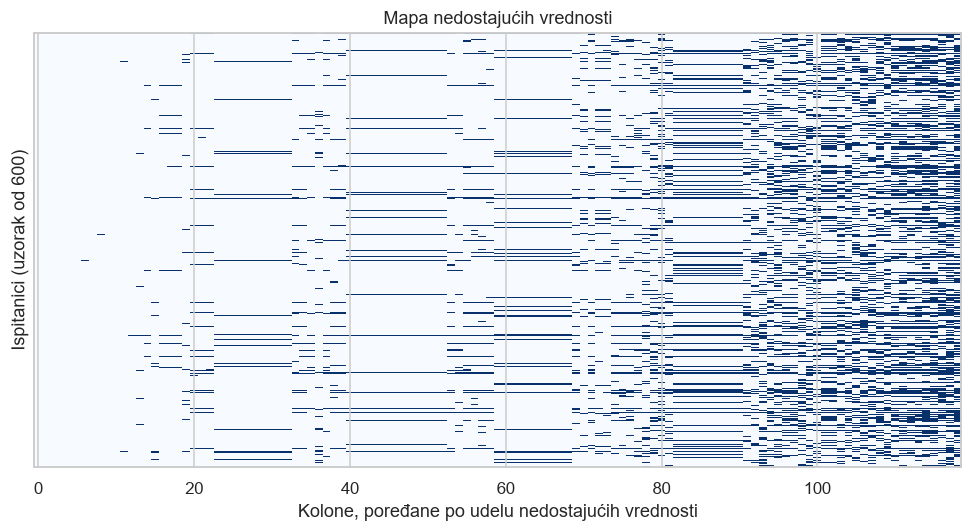

prikazano 600 od 18,260 ispitanika


In [74]:
# One row per respondent, one column per question; dark means the value is missing.
sample = missing_mask.sample(n=600, random_state=7)
column_order_by_pattern = sorted(
    missing_mask.columns, key=lambda c: (missing_mask[c].mean(), c))

fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(sample[column_order_by_pattern].to_numpy(), aspect="auto",
          cmap="Blues", interpolation="nearest")

ax.set_xlabel("Kolone, poređane po udelu nedostajućih vrednosti")
ax.set_ylabel("Ispitanici (uzorak od 600)")
ax.set_title("Mapa nedostajućih vrednosti")
ax.set_yticks([])
plt.tight_layout()
plt.show()

print(f"prikazano {len(sample)} od {len(missing_mask):,} ispitanika")

**Zapažanje:** mapa je sastavljena od uspravnih traka. Tamna polja se ne pojavljuju razbacano nego u
širokim pojasevima koji obuhvataju više susednih kolona odjednom, i tamo gde je pojas taman, taman je
kroz čitav niz ispitanika.

**Tumačenje:** blokovska struktura nije svojstvo samo najvećih pitanja nego se vidi preko cele mape.
Zbog toga je dovoljan jedan indikator po bloku, umesto po jedan za svaku kolonu — što ćemo iskoristiti
u sekciji 22.

Kada neko preskoči celo pitanje, to nije slučajan gubitak podatka nego odluka koja o toj osobi nešto
govori; u sekciji 15 smo i pokazali da je nedostajanje povezano sa posmatranim obeležjima. Zbog toga
imputacija nije jedini put. Kod kategorijskih kolona možemo prazno polje da tretiramo kao **sopstvenu
kategoriju** — „Not answered" — i time zadržimo tu informaciju umesto da je zamenimo najčešćom
vrednošću i tako izbrišemo.

### Šta se sme popuniti a šta ne

Kolone delimo po tome čime bi se popunjavale.

**Kategorijske kolone.** Ovde ne imputiramo. Prazno polje postaje nova kategorija, jer je za kategoriju
to prirodno — model dobija još jednu mogućnost umesto da mu podmetnemo najčešći odgovor. Time
izbegavamo i pristrasnost koju bi popunjavanje modom unelo: najčešća vrednost bi postala još češća.

**Multi-select kolone.** One su i dalje stringovi sa tačka-zarezom i nisu upotrebljive u ovom obliku, pa
se njihovo nedostajanje rešava tek kada se iz njih izvedu nove promenljive, u sledećem delu. Ovde
ih ostavljamo kakve jesu.

**Numeričke kolone.** Ovde imputacija ima smisla, jer nova kategorija ne postoji — broj mora da bude
broj. Popunjavamo medijanom, a ne aritmetičkom sredinom, jer smo videli koliko su raspodele iskošene.

Ali to popunjavanje **ovde ne izvodimo.** Medijana se računa iz podataka, pa ako je izračunamo nad celim
skupom, u nju ulaze i redovi koji će kasnije završiti u test skupu — a test skup bi tada nosio deo
informacije o sebi. Zato prvo delimo podatke, pa tek onda popunjavamo, i to isključivo iz trening
dela.

In [75]:
numeric_features = features.select_dtypes(include="number").columns
multi_select_features = [c for c in features.columns
                         if c not in numeric_features
                         and features[c].dropna().astype(str).str.contains(";").mean() > 0.3]
categorical_features = [c for c in features.columns
                        if c not in numeric_features and c not in multi_select_features]

plan = pd.DataFrame([
    {"grupa": "numeričke", "kolona": len(numeric_features),
     "sa nedostajućim": int((features[numeric_features].isna().sum() > 0).sum()),
     "postupak": "medijana, posle podele"},
    {"grupa": "kategorijske", "kolona": len(categorical_features),
     "sa nedostajućim": int((features[categorical_features].isna().sum() > 0).sum()),
     "postupak": "nova kategorija"},
    {"grupa": "multi-select", "kolona": len(multi_select_features),
     "sa nedostajućim": int((features[multi_select_features].isna().sum() > 0).sum()),
     "postupak": "u feature engineeringu"},
])
print(plan.to_string(index=False))
print()
print(f"ukupno praznih polja u skupu: {int(missing_mask.sum().sum()):,} "
      f"({100 * missing_mask.to_numpy().mean():.1f}% svih ćelija)")

       grupa  kolona  sa nedostajućim               postupak
   numeričke      48               48 medijana, posle podele
kategorijske      35               31        nova kategorija
multi-select      36               36 u feature engineeringu

ukupno praznih polja u skupu: 297,493 (13.7% svih ćelija)


**Zapažanje:** od 119 kolona, **48 je numeričkih, 36 multi-select i 35 kategorijskih**. Praznih polja
ima **297.493**, što je 13,7% svih ćelija u tabeli.

**Tumačenje:** raspodela posla je time jasna. Kategorijske kolone rešavamo odmah, novom kategorijom.
Numeričke čekaju podelu na trening i test. Multi-select kolone ne diramo dok se iz njih ne izvedu
promenljive.

Ovde ćemo primeniti samo prvi deo, jer on ne zavisi ni od kakvog računa nad podacima — nova kategorija
je pravilo, ne statistika, pa sme i pre podele.

In [76]:
# Kept in English so it sits alongside the survey's own answer labels.
NOT_ANSWERED = "Not answered"

prepared = features.copy()
affected = [c for c in categorical_features if prepared[c].isna().any()]

for column in affected:
    prepared[column] = prepared[column].astype("object").fillna(NOT_ANSWERED)

print(f"kategorijskih kolona sa nedostajućim: {len(affected)}")
print(f"popunjeno polja: {int(features[affected].isna().sum().sum()):,}")
print()
print("provera na tri kolone:")
for column in affected[:3]:
    share = 100 * (prepared[column] == NOT_ANSWERED).mean()
    print(f"  {column:<22} kategorija „{NOT_ANSWERED}\" nosi {share:>5.1f}% ispitanika")
print()
print(f"preostalo praznih polja u kategorijskim kolonama: "
      f"{int(prepared[categorical_features].isna().sum().sum())}")
print(f"preostalo praznih polja ukupno: {int(prepared.isna().sum().sum()):,}")

kategorijskih kolona sa nedostajućim: 31
popunjeno polja: 24,707

provera na tri kolone:
  Age                    kategorija „Not answered" nosi   0.1% ispitanika
  EdLevel                kategorija „Not answered" nosi   0.0% ispitanika
  EmploymentAddl         kategorija „Not answered" nosi   5.5% ispitanika

preostalo praznih polja u kategorijskim kolonama: 0
preostalo praznih polja ukupno: 272,786


### Šta je sekcija odlučila

Nedostajanje u prediktorima nije razbacano po pojedinačnim poljima nego dolazi u blokovima — 119 kolona
ima svega 78 obrazaca, a najveći blokovi su cela pitanja sa rangiranjem koja je ispitanik preskočio u
celini.

Zato smo za **kategorijske kolone** izabrali novu kategoriju umesto imputacije. Podatak da neko nije
odgovorio time ostaje sačuvan, a u sekciji 15 smo pokazali da taj podatak nije bezvredan.

Za **numeričke kolone** odluka je medijana, ali se izvršava tek u sekciji 22, posle podele na trening i
test. Za **multi-select kolone** ništa se ne radi dok se iz njih ne izvedu promenljive.

Time je sve što se sme uraditi pre podele obavljeno, pa sledi podela.

## 21. Podela na trening i test skup

Sve što smo do sada radili bilo je ili pravilo (nemoguća vrednost, prazan string) ili odluka o tome
koga modelujemo. Ni jedno ni drugo ne zavisi od pojedinačnih brojeva u podacima.

Od ovog trenutka to prestaje da važi. Popunjavanje nedostajućih vrednosti medijanom znači da tu
medijanu **računamo iz podataka**. Ako je izračunamo nad celim skupom, u nju ulaze i redovi koji će
kasnije završiti u test skupu — a test skup tada više nije nezavisna provera, jer je deo informacije o
njemu već ušao u model preko te medijane.

Zato prvo delimo, pa tek onda računamo. Uzimamo uobičajen odnos 80:20 i fiksiramo seme slučajnog
generatora, da podela bude ista pri svakom pokretanju.

In [77]:
from sklearn.model_selection import train_test_split

# The target left the table in section 6, where we were choosing predictors. It
# is not a feature, but it has to travel with the rows into both files.
modelling_set = prepared.join(cleaned["ConvertedCompYearly"])

# Fixed so that re-running the notebook always produces the same split.
RANDOM_STATE = 42
# One fifth held out; the usual split when the sample is this large.
TEST_SHARE = 0.2

train_set, test_set = train_test_split(
    modelling_set, test_size=TEST_SHARE, random_state=RANDOM_STATE)

print(f"kolona u skupu: {len(modelling_set.columns)}   "
      f"({len(modelling_set.columns) - 1} prediktora + ciljna promenljiva)")
print()
print(f"ukupno:  {len(modelling_set):>7,}")
print(f"trening: {len(train_set):>7,}  ({100 * len(train_set) / len(modelling_set):.1f}%)")
print(f"test:    {len(test_set):>7,}  ({100 * len(test_set) / len(modelling_set):.1f}%)")

kolona u skupu: 120   (119 prediktora + ciljna promenljiva)

ukupno:   18,260
trening:  14,608  (80.0%)
test:      3,652  (20.0%)


Podela je nasumična, pa nema garancije da su dva skupa slična po sastavu. Kod velikih uzoraka to
obično jeste tako, ali „obično jeste" nije provera — pa da uporedimo ono što nam je najvažnije: ciljnu
promenljivu i raspodelu po zemljama.

In [78]:
comparison = pd.DataFrame({
    "trening": train_set["ConvertedCompYearly"].describe(percentiles=[0.25, 0.5, 0.75]),
    "test": test_set["ConvertedCompYearly"].describe(percentiles=[0.25, 0.5, 0.75]),
}).round(0)
print(comparison.to_string())
print()

share_train = train_set["Country"].value_counts(normalize=True) * 100
share_test = test_set["Country"].value_counts(normalize=True) * 100
countries = pd.DataFrame({"trening_%": share_train, "test_%": share_test}).dropna()
countries["razlika_pp"] = (countries["test_%"] - countries["trening_%"]).abs()

print("najveće razlike u udelu zemalja:")
print(countries.sort_values("razlika_pp", ascending=False).head(5).round(2).to_string())

         trening      test
count    14608.0    3652.0
mean     94499.0   93765.0
std      67862.0   66418.0
min         27.0      96.0
25%      48726.0   47886.0
50%      81210.0   81210.0
75%     125000.0  125000.0
max    1000000.0  580073.0

najveće razlike u udelu zemalja:
                          trening_%  test_%  razlika_pp
Country                                                
United States of America      21.94   20.76        1.18
Switzerland                    1.46    2.14        0.67
Australia                      2.53    1.89        0.64
France                         4.42    3.97        0.44
Romania                        0.86    1.26        0.40


**Zapažanje:** medijana kompenzacije je u oba skupa gotovo ista, a razlike u udelu zemalja su ispod
jednog procentnog poena i kod najveće.

**Tumačenje:** nasumična podela je pri ovoj veličini uzorka dala uravnotežene skupove, pa nema potrebe
za stratifikacijom. Da su razlike bile veće, morali bismo da delimo tako da se sastav po zemljama
zadrži — jer smo u sekciji 15 pokazali koliko zemlja utiče na sve.

Od ovog trenutka **test skup ne diramo.** Sve što sledi računa se isključivo iz trening skupa, a na
test se samo primenjuje.

## 22. Imputacija numeričkih kolona

Ostale su numeričke kolone sa nedostajućim vrednostima. Kategorijske smo rešili u sekciji 20 novom
kategorijom, ali kod broja to ne ide — broj mora da bude broj.

Numeričkih prediktora ima 48, ali nisu iste prirode. Pet njih meri veličine sa jasnim značenjem, a
preostale 43 su rangiranja iz četiri pitanja. Krećemo od prvih pet.

In [79]:
# The four ranking questions found in section 4.5.
RANK_PREFIXES_KNOWN = ["TechEndorse", "TechOppose", "JobSatPoints", "SO_Actions"]

# The target rejoined the table before the split, but it is not a predictor and
# is never imputed, so it stays out of everything this section does.
numeric_columns = [c for c in train_set.select_dtypes(include="number").columns
                   if c != "ConvertedCompYearly"]
rank_columns = [c for c in numeric_columns
                if any(c.startswith(p) for p in RANK_PREFIXES_KNOWN)]
plain_numeric = [c for c in numeric_columns if c not in rank_columns]

print(f"numeričkih prediktora: {len(numeric_columns)}   "
      f"od toga rangiranja: {len(rank_columns)}   ostalih: {len(plain_numeric)}")
print()
print("nedostajuće vrednosti u trening skupu:")
print((train_set[plain_numeric].isna().mean() * 100).round(1).to_string())

numeričkih prediktora: 48   od toga rangiranja: 43   ostalih: 5

nedostajuće vrednosti u trening skupu:
WorkExp               1.5
YearsCode             0.4
ToolCountWork        15.1
ToolCountPersonal    24.9
JobSat                3.4


**Zapažanje:** kod staža nedostaje ispod procenta, kod zadovoljstva poslom oko tri, a kod broja alata
znatno više — petnaest i dvadeset pet posto.

**Tumačenje:** najjednostavnije rešenje je da svima upišemo istu vrednost, **medijanu te kolone
izračunatu nad svim ispitanicima**. Nazivaćemo je opštom medijanom.

Ali možemo i bolje. Ispitanike umemo da razvrstamo u grupe po nekom obeležju koje već imamo — recimo
po starosnoj kategoriji — pa da **medijanu iste te kolone izračunamo posebno unutar svake grupe**, i
svakome upišemo medijanu njegove grupe. Kod staža to deluje razumno, jer je staž očigledno povezan sa
uzrastom.

Da ne bude zabune oko toga šta se čime računa: medijana se uvek uzima od **kolone koju popunjavamo**,
recimo od `WorkExp`. Obeležje po kom grupišemo, recimo `Age`, služi samo da ispitanike razvrsta u
grupe; ono samo ne mora ni da bude broj, a `Age` i nije — to su kategorije poput „25-34 years old".
Grupisanje po `Country` znači da medijanu staža računamo posebno za svaku zemlju.

Umesto da pretpostavimo koje grupisanje pomaže, izmerićemo. Uzimamo redove u kojima vrednost
**postoji**, nasumično sakrijemo petinu njih, popunimo je svakim od postupaka, i uporedimo koliko su
predviđanja promašila. Sve se računa isključivo nad trening skupom.

In [80]:
def compare_imputations(data, column, groupings, hidden_share=0.2, seed=0):
    """Hide part of the known values and see which fill comes closest.

    The median is always taken of `column`; each entry in `groupings` is only
    used to split respondents into groups first.
    """
    frame = data[[column] + list(dict.fromkeys(groupings))].dropna()
    rng = np.random.default_rng(seed)
    hidden = rng.random(len(frame)) < hidden_share
    known, checked = frame[~hidden], frame[hidden]

    overall_median = known[column].median()
    errors = {"jedna medijana za sve": np.abs(overall_median - checked[column]).mean()}
    for grouping in groupings:
        group_median = known.groupby(grouping)[column].median()
        # Groups unseen among the known values fall back to the overall median.
        filled = checked[grouping].map(group_median).fillna(overall_median)
        errors[f"medijana unutar grupa po {grouping}"] = np.abs(filled - checked[column]).mean()

    return pd.Series(errors).round(3), len(frame)


for column, groupings in [("WorkExp", ["Age", "Country", "EdLevel"]),
                          ("YearsCode", ["Age", "Country"]),
                          ("JobSat", ["Country", "Age"]),
                          ("ToolCountWork", ["DevType", "Age"]),
                          ("ToolCountPersonal", ["DevType", "Age"])]:
    errors, size = compare_imputations(train_set, column, groupings)
    best = errors.idxmin()
    print(f"popunjavamo {column}  (n={size:,})")
    for name, value in errors.items():
        marker = "  <- najbolje" if name == best else ""
        print(f"    {name:<34} prosečna greška {value:>7.3f}{marker}")
    print()

popunjavamo WorkExp  (n=14,386)
    jedna medijana za sve              prosečna greška   7.276
    medijana unutar grupa po Age       prosečna greška   3.373  <- najbolje
    medijana unutar grupa po Country   prosečna greška   7.016
    medijana unutar grupa po EdLevel   prosečna greška   7.213

popunjavamo YearsCode  (n=14,543)
    jedna medijana za sve              prosečna greška   8.298
    medijana unutar grupa po Age       prosečna greška   4.571  <- najbolje
    medijana unutar grupa po Country   prosečna greška   7.933

popunjavamo JobSat  (n=14,109)
    jedna medijana za sve              prosečna greška   1.447
    medijana unutar grupa po Country   prosečna greška   1.427  <- najbolje
    medijana unutar grupa po Age       prosečna greška   1.444

popunjavamo ToolCountWork  (n=12,400)
    jedna medijana za sve              prosečna greška   4.417
    medijana unutar grupa po DevType   prosečna greška   4.380
    medijana unutar grupa po Age       prosečna greška   4.376  <- 

**Zapažanje:** kod **`WorkExp` grupisanje po uzrastu više nego prepolovljuje grešku** — sa 7,276 na
3,373 godine. Kod `YearsCode` je slično, sa 8,298 na 4,571.

Kod ostale tri kolone razlika je zanemarljiva: `JobSat` ide sa 1,447 na 1,427, `ToolCountWork` sa 4,417
na 4,376, `ToolCountPersonal` sa 3,250 na 3,235. Formalno je i tu grupisanje „najbolje", ali dobitak je
u trećoj decimali.

Zanimljivo je i da kod staža grupisanje **po zemlji** ne pomaže skoro ništa (7,016 naspram 7,276), iako
je zemlja inače najjači prediktor plate.

**Tumačenje:** rezultat je lako objasniti. Staž je vezan za uzrast — ko ima trideset godina ne može
imati trideset godina staža — pa poznavanje starosne kategorije stvarno sužava opseg mogućih vrednosti.
Zemlja o stažu ne govori ništa, i merenje to potvrđuje, iako bi se po njenom značaju u ostatku rada
moglo pomisliti drugačije.

Kod broja alata i zadovoljstva poslom nijedno grupisanje ne donosi stvarnu razliku, pa uzimamo jednu
medijanu za sve — nema razloga za složeniji postupak koji ne daje bolji rezultat.

**Odluka:** `WorkExp` i `YearsCode` popunjavamo medijanom unutar starosne kategorije, ostale jednom
medijanom za sve. Sve medijane računaju se na trening skupu i istim vrednostima se popunjava i test.

### Šta gubimo popunjavanjem

Čim vrednost popunimo, podatak o tome da je nedostajala nestaje. Svi ispitanici dobiju broj, pa se više
ne vidi ko je zaista odgovorio a ko nije. A u sekciji 15 smo pokazali da to nije nevažna informacija —
ko je nešto preskočio sistematski se razlikuje od onoga ko nije.

Kod kategorijskih kolona to smo sačuvali samom kategorijom „Not answered". Kod numeričkih moramo
posebno, i to **pre** popunjavanja, jer posle više nema šta da se zabeleži.

Rešenje je nova kolona koja pamti stanje pre popunjavanja: **1 ako je vrednost nedostajala, 0 ako
nije.** Takvu kolonu zovemo indikatorom.

Ne pravimo je za svaku od 48 kolona. Pošto svih trinaest `JobSatPoints` kolona nedostaje kod istih
ljudi, trinaest indikatora bilo bi trinaest istovetnih kolona — dovoljan je **jedan po bloku**.
Preskačemo i blokove kod kojih nedostaje manje od procenta ispitanika, jer tamo indikator praktično
nema šta da razlikuje.

In [81]:
# Below one percent an indicator would have almost nothing to separate.
INDICATOR_LIMIT = 1.0

# Columns missing for exactly the same respondents come from one question, so a
# single indicator describes the whole block.
missing_numeric = train_set[numeric_columns].isna()
numeric_blocks = {}
for column in numeric_columns:
    key = missing_numeric[column].values.tobytes()
    numeric_blocks.setdefault(key, []).append(column)

indicator_for = {}
for block in numeric_blocks.values():
    share = 100 * missing_numeric[block[0]].mean()
    if share >= INDICATOR_LIMIT:
        indicator_for[f"NotAnswered_{block[0]}"] = block

print(f"blokova među numeričkim kolonama: {len(numeric_blocks)}")
print(f"indikatora koje dodajemo:         {len(indicator_for)}")
print()
for name, block in indicator_for.items():
    share = 100 * missing_numeric[block[0]].mean()
    print(f"  {name:<32} pokriva {len(block):>2} kolona, nedostaje {share:>5.1f}%")


def add_indicators(frame):
    marked = frame.copy()
    for name, block in indicator_for.items():
        marked[name] = frame[block[0]].isna().astype(int)
    return marked


train_set = add_indicators(train_set)
test_set = add_indicators(test_set)

print()
print(f"kolona posle dodavanja indikatora: {len(train_set.columns)}")
print()

# Two respondents, before the filling happens, to show what the indicator holds.
example_block = indicator_for["NotAnswered_JobSatPoints_1"][:6]
answered = train_set[train_set["NotAnswered_JobSatPoints_1"] == 0].iloc[0]
skipped = train_set[train_set["NotAnswered_JobSatPoints_1"] == 1].iloc[0]

print("ispitanik koji JESTE rangirao:")
print(f"  {[None if pd.isna(answered[c]) else int(answered[c]) for c in example_block]} ..."
      f"   indikator = {int(answered['NotAnswered_JobSatPoints_1'])}")
print("ispitanik koji NIJE rangirao (vrednosti još nisu popunjene):")
print(f"  {[None if pd.isna(skipped[c]) else int(skipped[c]) for c in example_block]} ..."
      f"   indikator = {int(skipped['NotAnswered_JobSatPoints_1'])}")

blokova među numeričkim kolonama: 10
indikatora koje dodajemo:         9

  NotAnswered_WorkExp              pokriva  1 kolona, nedostaje   1.5%
  NotAnswered_TechEndorse_1        pokriva 10 kolona, nedostaje   5.1%
  NotAnswered_TechOppose_1         pokriva 10 kolona, nedostaje   8.1%
  NotAnswered_JobSatPoints_1       pokriva 13 kolona, nedostaje   6.5%
  NotAnswered_ToolCountWork        pokriva  1 kolona, nedostaje  15.1%
  NotAnswered_ToolCountPersonal    pokriva  1 kolona, nedostaje  24.9%
  NotAnswered_SO_Actions_1         pokriva  9 kolona, nedostaje  21.0%
  NotAnswered_SO_Actions_16        pokriva  1 kolona, nedostaje  27.3%
  NotAnswered_JobSat               pokriva  1 kolona, nedostaje   3.4%

kolona posle dodavanja indikatora: 129

ispitanik koji JESTE rangirao:
  [12, 10, 11, 13, 4, 2] ...   indikator = 0
ispitanik koji NIJE rangirao (vrednosti još nisu popunjene):
  [None, None, None, None, None, None] ...   indikator = 1


In [82]:
# Columns where grouping by age band measurably beat the overall median.
BY_AGE = ["WorkExp", "YearsCode"]
# Columns where no grouping helped, so the plain median is enough.
BY_OVERALL = ["JobSat", "ToolCountWork", "ToolCountPersonal"]

# Every fill value is computed on the training set only, then applied to both.
age_medians = {c: train_set.groupby("Age")[c].median() for c in BY_AGE}
overall_medians = {c: train_set[c].median() for c in BY_OVERALL + BY_AGE}
rank_medians = {c: train_set[c].median() for c in rank_columns}


def impute(frame):
    filled = frame.copy()
    for column in BY_AGE:
        by_age = filled["Age"].map(age_medians[column])
        filled[column] = filled[column].fillna(by_age).fillna(overall_medians[column])
    for column in BY_OVERALL:
        filled[column] = filled[column].fillna(overall_medians[column])
    for column in rank_columns:
        filled[column] = filled[column].fillna(rank_medians[column])
    return filled


train_filled = impute(train_set)
test_filled = impute(test_set)

multi_select_left = [c for c in train_filled.columns
                     if train_filled[c].dtype.kind in "OU"
                     and train_filled[c].dropna().astype(str).str.contains(";").mean() > 0.3]

for name, before, after in [("trening", train_set, train_filled),
                            ("test", test_set, test_filled)]:
    numeric_left = int(after[numeric_columns].isna().sum().sum())
    multi_left = int(after[multi_select_left].isna().sum().sum())
    print(f"{name}:")
    print(f"  praznih polja pre imputacije:      {int(before.isna().sum().sum()):>8,}")
    print(f"  posle, u numeričkim kolonama:      {numeric_left:>8,}")
    print(f"  posle, u multi-select kolonama:    {multi_left:>8,}   (namerno ostavljeno)")
print()
print("medijana staža po starosnoj kategoriji, izračunata na treningu:")
print(age_medians["WorkExp"].to_string())

trening:
  praznih polja pre imputacije:       217,948
  posle, u numeričkim kolonama:             0
  posle, u multi-select kolonama:     148,085   (namerno ostavljeno)
test:
  praznih polja pre imputacije:        54,838
  posle, u numeričkim kolonama:             0
  posle, u multi-select kolonama:      37,171   (namerno ostavljeno)

medijana staža po starosnoj kategoriji, izračunata na treningu:
Age
18-24 years old       2.0
25-34 years old       7.0
35-44 years old      15.0
45-54 years old      25.0
55-64 years old      34.0
65 years or older    44.0
Not answered         18.0


**Zapažanje:** u numeričkim kolonama više nema nijedne prazne vrednosti. Ostalo je oko 148 hiljada
praznih polja u trening skupu, ali sva su u **multi-select kolonama**, koje smo namerno ostavili
netaknute. Medijane staža po starosnoj kategoriji rastu onako kako se i očekuje, od dve godine kod
najmlađih do četrdeset četiri kod najstarijih.

**Tumačenje:** multi-select kolona je i dalje jedan string sa svim izabranim stavkama, pa popunjavanje
nema smisla dok se iz nje ne izvedu prave promenljive — a tada prazna vrednost prirodno postaje nula
izabranih stavki. To je posao sledećeg dela.

Rangiranja smo popunili jednom medijanom bez posebne provere, jer je kod njih nedostajanje blokovsko —
ispitanik nije preskočio jednu stavku nego celo pitanje, pa nema susedne vrednosti iz koje bi se izvelo
nešto pametnije. Medijanski rang je u tom slučaju najneutralniji izbor.

Podatak o tome ko nije odgovorio nije izgubljen: sačuvan je u devet indikatorskih kolona koje smo
dodali pre popunjavanja. Ispis iznad pokazuje i zašto su nam trebale — ispitanik koji je pitanje
preskočio sada ima iste takve brojeve kao i onaj koji je odgovorio, pa je indikator jedino mesto na kom
ta razlika i dalje postoji. Da li one nose signal, proverava se tek u modelovanju — ovde smo samo obezbedili da
informacija ostane dostupna.

## 23. Čuvanje očišćenog skupa

Ostaje da očišćene podatke sačuvamo, jer su oni jedan od isporučivih rezultata rada. Trening i test
čuvamo odvojeno, da podela ostane fiksirana i da se u kasnijim koracima ne može slučajno promeniti.

Fajlove zapisujemo kao **CSV sažet gzip-om**. Nesažet CSV bi bio višestruko veći, uglavnom zbog
multi-select kolona u kojima se iste duge liste tehnologija ponavljaju kroz hiljade redova — a upravo
takav sadržaj se izvrsno sažima. Koliko se time dobija, vidi se u ispisu ispod. Format ostaje običan
CSV, pa se čita jednim pozivom `pd.read_csv` bez ikakvih dodatnih biblioteka.

In [83]:
PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_path = PROCESSED_DIR / "train.csv.gz"
test_path = PROCESSED_DIR / "test.csv.gz"

train_filled.to_csv(train_path, index=False, encoding="utf-8", compression="gzip")
test_filled.to_csv(test_path, index=False, encoding="utf-8", compression="gzip")

MB = 1024 ** 2
for path, frame in ((train_path, train_filled), (test_path, test_filled)):
    # Size of the same CSV without compression, so the gain is a measured number
    # rather than an estimate.
    plain = len(frame.to_csv(index=False).encode("utf-8"))
    packed = path.stat().st_size
    print(f"{path.name:<14} {packed / MB:>5.1f} MB sažeto   {plain / MB:>5.1f} MB nesažeto   "
          f"({plain / packed:.0f} puta manje)")

train.csv.gz     4.3 MB sažeto    42.3 MB nesažeto   (10 puta manje)


test.csv.gz      1.1 MB sažeto    10.5 MB nesažeto   (10 puta manje)


In [84]:
# Reading the files back is the only way to be sure they hold what we think.
train_check = pd.read_csv(train_path, low_memory=False)
test_check = pd.read_csv(test_path, low_memory=False)

print(f"trening: {train_check.shape[0]:>6,} redova x {train_check.shape[1]} kolona")
print(f"test:    {test_check.shape[0]:>6,} redova x {test_check.shape[1]} kolona")
print()
target_present = (train_check["ConvertedCompYearly"].notna().all()
                  and test_check["ConvertedCompYearly"].notna().all())
print(f"ciljna promenljiva prisutna u svim redovima: {target_present}")
print(f"medijana kompenzacije: trening {train_check['ConvertedCompYearly'].median():,.0f} USD, "
      f"test {test_check['ConvertedCompYearly'].median():,.0f} USD")
print()
numeric_after = train_check.select_dtypes(include="number").columns
print(f"praznih polja u numeričkim kolonama posle čitanja: "
      f"{int(train_check[numeric_after].isna().sum().sum()):,}")
print(f"ukupno praznih polja posle čitanja: {int(train_check.isna().sum().sum()):,} "
      f"(sve u multi-select kolonama)")

trening: 14,608 redova x 129 kolona
test:     3,652 redova x 129 kolona

ciljna promenljiva prisutna u svim redovima: True
medijana kompenzacije: trening 81,210 USD, test 81,210 USD

praznih polja u numeričkim kolonama posle čitanja: 0
ukupno praznih polja posle čitanja: 148,085 (sve u multi-select kolonama)


**Zapažanje:** oba fajla se čitaju bez greške, imaju očekivan broj redova i kolona, ciljna promenljiva
je prisutna u svakom redu, a medijane kompenzacije se poklapaju sa onima pre čuvanja. U numeričkim
kolonama nema praznih polja; ona koja ostaju su u multi-select kolonama, kako smo i ostavili.

**Tumačenje:** provera čitanjem nije suvišna. Zapis u CSV i čitanje nazad mogu da promene tipove
kolona ili da unesu prazne vrednosti tamo gde ih nije bilo, pa je jedini način da se u sadržaj fajla
bude siguran taj da se on stvarno pročita.

## Zaključak dela

Pošli smo od **49.123 ispitanika i 170 kolona**, a završavamo sa **18.260 ispitanika i 129 kolona**, od kojih je jedna
ciljna promenljiva a ostalo prediktori, podeljenih na trening i test skup. Od tih prediktora je devet
indikatora koje smo sami dodali, da se ne izgubi podatak o tome ko na neko pitanje nije odgovorio.

Redosled odluka bio je sledeći:

1. **Populacija** — zadržali smo programere po profesiji koji trenutno rade, kao zaposleni ili
   samostalni. Odluka je doneta poređenjem raspodela zarade, a ne po osećaju.
2. **Nedostajanje ciljne promenljive** — pokazali smo da nije slučajno, jer udeo prijavljivanja po
   zemljama ide od 54% do 88%. Brisanje smo ipak zadržali, jer se plata ne sme izmišljati, ali uz
   obavezu da zemlja uđe u model i da se pristrasnost navede kao ograničenje.
3. **Duplikati** — pravih nema; 741 red koji je izgledao kao duplikat pripada ljudima koji su napustili
   anketu posle nekoliko pitanja.
4. **Strukturne greške** — ispravljen zapis u tekstualnim kolonama, poništene nemoguće vrednosti staža
   i broja alata, bez brisanja ijednog reda.
5. **Netipične vrednosti** — merene unutar zemlje, jer je globalno pravilo označavalo siromašnije
   zemlje umesto grešaka.
6. **Izbor kolona** — izbačena 51 kolona po pet kriterijuma, sa granicama izvedenim iz podataka.
7. **Nedostajanje kod prediktora** — kategorijske kolone dobile su kategoriju „Not answered", jer sama
   činjenica da neko nije odgovorio nosi informaciju.
8. **Podela** — 80:20, uz proveru da su skupovi uravnoteženi.
9. **Imputacija** — medijana, po starosnoj kategoriji tamo gde merenje pokazuje da to pomaže, uz devet
   indikatora dodatih pre popunjavanja.
10. **Čuvanje** — u `data/processed/`, uz proveru čitanjem.

Ono što ostaje otvoreno i prenosi se dalje: pristrasnost uzorka prema bogatijim zemljama, stotinak
neuverljivo malih iznosa koje pravilo po zemlji nije uhvatilo, i trideset šest multi-select kolona koje su i dalje neobrađene.

Sledeći deo bavi se izvođenjem novih promenljivih iz kolona koje su ovde samo raščišćene.

# Feature engineering: izvođenje novih promenljivih

Iz prethodnog dela izlazimo sa očišćenim skupom od 18.260 ispitanika, podeljenim na trening i
test. Taj skup je čist, ali još nije upotrebljiv za model. Trideset šest kolona su i dalje stringovi u
kojima je više odgovora spojeno tačka-zarezom, četrdeset tri su rangiranja čije značenje tek treba
osmisliti, a `Country` ima toliko kategorija da bi ga one-hot enkodiranje razbilo na stotine kolona.

Ovaj deo iz tih kolona izvodi nove promenljive. Za svaku od njih proveravamo da li stvarno nosi
signal za platu — dodavanje promenljive koja je šum ne pomaže modelu, nego mu daje još jednu priliku da
se prilagodi slučajnosti u trening skupu.

Redosled sekcija:

1. šta smo nasledili iz čišćenja i u kakvom je stanju;
2. čime merimo da li izvedena promenljiva nosi signal;
3. kako izgledaju multi-select kolone iznutra;
4. broj izabranih stavki kao promenljiva;
5. pojedinačne stavke kao indikatori;
6. kolone sa rangiranjem;
7. zemlja, kao „prvih N i ostalo";
8. ordinalne kategorije i promenljive izvedene iz onih koje već imamo;
9. koliko se nove promenljive međusobno preklapaju;
10. čuvanje proširenog skupa.

Jedno pravilo važi kroz ceo ovaj deo, i posledica je odluke iz prethodnog: **sve što se računa iz
podataka računa se isključivo na trening skupu.** Test skup se do same isporuke ne dira.

In [85]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"

TARGET = "ConvertedCompYearly"
# The logged target, added in section 1.3; it is not a predictor either.
TARGET_LOG = "log_comp"

train = pd.read_csv(PROCESSED_DIR / "train.csv.gz", low_memory=False)
test = pd.read_csv(PROCESSED_DIR / "test.csv.gz", low_memory=False)

print(f"trening: {train.shape[0]:>6,} redova x {train.shape[1]} kolona")
print(f"test:    {test.shape[0]:>6,} redova x {test.shape[1]} kolona")
print(f"ukupno:  {len(train) + len(test):>6,} ispitanika")

trening: 14,608 redova x 129 kolona
test:     3,652 redova x 129 kolona
ukupno:  18,260 ispitanika


## 24. Šta smo nasledili iz čišćenja

### 24.1 Da li je stiglo ono što je poslato

Skup čitamo iz fajla, a ne iz promenljive koja je ostala u memoriji, pa nemamo garanciju da je u njemu
baš ono što smo mislili da čuvamo. Zapis u CSV i čitanje nazad umeju da promene tip kolone ili da unesu
prazna polja tamo gde ih nije bilo.

Zato prvo proveravamo četiri stvari koje je prethodni deo obećao: da je podela 80:20, da oba skupa
imaju iste kolone, da je ciljna promenljiva svuda popunjena, i da praznih polja ima **samo** u
multi-select kolonama, koje smo namerno ostavili nedirnute.

In [86]:
def is_text(series):
    """True for columns pandas stores as strings, whichever string dtype it uses."""
    return series.dtype.kind in "OU" or str(series.dtype) in ("str", "string")


# Answers to "pick all that apply" are one string with ";" between the chosen
# items; the same test as in the cleaning notebook picks those columns out.
MULTI_SELECT_SHARE = 0.3


def is_multi_select(series):
    """True for a column that holds several answers joined by semicolons."""
    return is_text(series) and series.dropna().astype(str).str.contains(";").mean() > MULTI_SELECT_SHARE


numeric_columns = train.select_dtypes(include="number").columns
missing_per_column = train.isna().sum()
with_missing = list(missing_per_column[missing_per_column > 0].index)

print(f"odnos trening : test           {100 * len(train) / (len(train) + len(test)):.0f} : "
      f"{100 * len(test) / (len(train) + len(test)):.0f}")
print(f"iste kolone u oba skupa        {list(train.columns) == list(test.columns)}")
print(f"ciljna promenljiva popunjena   "
      f"{train[TARGET].notna().all() and test[TARGET].notna().all()}")
print(f"praznih polja u numeričkim     {int(train[numeric_columns].isna().sum().sum())}")
print()
print(f"kolona sa praznim poljima      {len(with_missing)}")
print(f"  od toga multi-select         {sum(is_multi_select(train[c]) for c in with_missing)}")
print(f"praznih polja ukupno           {int(train.isna().sum().sum()):,} "
      f"({100 * train.isna().to_numpy().mean():.1f}% svih ćelija)")

odnos trening : test           80 : 20
iste kolone u oba skupa        True
ciljna promenljiva popunjena   True
praznih polja u numeričkim     0

kolona sa praznim poljima      36
  od toga multi-select         36
praznih polja ukupno           148,085 (7.9% svih ćelija)


**Zapažanje:** sve četiri provere prolaze. Podela je **80 : 20**, kolone su iste u oba skupa, ciljna
promenljiva je popunjena svuda, a u numeričkim kolonama nema **nijednog** praznog polja. Praznih polja
ima **148.085, odnosno 7,9% svih ćelija**, ali su sva na jednom mestu: kolona sa prazninama ima **36**, i
svih **36** su multi-select.

**Tumačenje:** skup je u stanju u kom smo ga ostavili, pa možemo da nastavimo. Ono što je ostalo prazno
nije propust nego odluka: dok je multi-select kolona jedan dugačak string, popunjavanje nema smisla. Kada
iz nje izvedemo prave promenljive, prazna vrednost prirodno postaje nula izabranih stavki — i to je jedan
od poslova ovog dela.

### 24.2 Od čega se skup sastoji

Prediktora ima 128 i o njima ne možemo da govorimo kolonu po kolonu. Ali oni nisu raznorodni koliko taj
broj sugeriše — dolaze iz svega nekoliko oblika pitanja, a oblik pitanja određuje i šta se sa kolonom
može uraditi.

Grupe pravimo po tome, a ne po imenu kolone: rangiranja prepoznajemo po četiri poznata pitanja iz
prethodnog dela, multi-select po tačka-zarezu u odgovoru, indikatore po prefiksu koji smo im sami
dali, a ostatak razdvajamo po tipu kolone.

In [87]:
# The four ranking questions. Each is exported as one column per offered item,
# named "<question>_<number>" — the intro text of a question carries the same
# prefix without that suffix, so the prefix alone is not enough to tell them apart.
RANK_PREFIXES = ["TechEndorse", "TechOppose", "JobSatPoints", "SO_Actions"]
RANK_NAME = re.compile("(?:" + "|".join(RANK_PREFIXES) + r")_\d+")

# The flags we added ourselves before imputing, one per block of columns that
# went missing together.
INDICATOR_PREFIX = "NotAnswered_"

predictors = [c for c in train.columns if c not in (TARGET, TARGET_LOG)]

indicators = [c for c in predictors if c.startswith(INDICATOR_PREFIX)]
rankings = [c for c in predictors
            if RANK_NAME.fullmatch(c) and train[c].dtype.kind in "if"]
multi_select = [c for c in predictors if is_multi_select(train[c])]
taken = set(indicators) | set(rankings) | set(multi_select)
numeric_plain = [c for c in predictors if c not in taken and train[c].dtype.kind in "if"]
categorical = [c for c in predictors if c not in taken and c not in numeric_plain]

groups = {
    "rangiranja": rankings,
    "multi-select": multi_select,
    "obične kategorijske": categorical,
    "indikatori": indicators,
    "obične numeričke": numeric_plain,
}

print(f"prediktora ukupno: {len(predictors)}")
print()
for name, columns in groups.items():
    print(f"  {name:<22} {len(columns):>3}   {', '.join(columns[:3])} ...")
print()
print(f"provera da se grupe ne preklapaju i pokrivaju sve: "
      f"{sum(len(c) for c in groups.values()) == len(predictors)}")
print()
print("od čega se tih 43 rangiranja sastoji — po jedna kolona za svaku ponuđenu stavku:")
for prefix in RANK_PREFIXES:
    print(f"  {prefix:<14} {len([c for c in rankings if c.startswith(prefix)]):>2} kolona")
print()
print(f"kolone sa prefiksom rangiranja koje nisu rangiranje: "
      f"{[c for c in predictors if any(c.startswith(p) for p in RANK_PREFIXES) and c not in rankings]}")

prediktora ukupno: 128

  rangiranja              43   TechEndorse_1, TechEndorse_2, TechEndorse_3 ...
  multi-select            36   LearnCode, AILearnHow, LanguageHaveWorkedWith ...
  obične kategorijske     35   Age, EdLevel, Employment ...
  indikatori               9   NotAnswered_WorkExp, NotAnswered_TechEndorse_1, NotAnswered_TechOppose_1 ...
  obične numeričke         5   WorkExp, YearsCode, ToolCountWork ...

provera da se grupe ne preklapaju i pokrivaju sve: True

od čega se tih 43 rangiranja sastoji — po jedna kolona za svaku ponuđenu stavku:
  TechEndorse    10 kolona
  TechOppose     10 kolona
  JobSatPoints   13 kolona
  SO_Actions     10 kolona

kolone sa prefiksom rangiranja koje nisu rangiranje: ['TechEndorseIntro']


**Zapažanje:** pet grupa pokriva svih 128 prediktora, bez preklapanja: **43 rangiranja, 36 multi-select,
35 običnih kategorijskih, 9 indikatora i 5 običnih numeričkih** kolona.

Tih 43 rangiranja nisu jedno pitanje nego **četiri**, i drugi deo ispisa pokazuje kako se dele:
`TechEndorse` **10**, `TechOppose` **10**, `JobSatPoints` **13** i `SO_Actions` **10** kolona. Svaka
kolona nosi rang koji je ispitanik dodelio jednoj ponuđenoj stavci tog pitanja.

Poslednji red ispisa izdvaja jednu kolonu koja nosi prefiks rangiranja a nije rangiranje —
**`TechEndorseIntro`**. Ona počinje istim prefiksom kao onih deset kolona pitanja `TechEndorse`, ali je
uvodni tekst tog pitanja, a ne rang neke stavke.

**Zašto to uopšte pominjemo.** Grupe smo prvo podelili po prefiksu imena, pa je `TechEndorseIntro` završio
među rangiranjima i njih je ispalo **44 umesto 43**. Da 43 treba da bude tačan broj znali smo iz
prethodnog dela: on je pri izboru kolona prebrojao kolone sa rangiranjem i našao ta četiri pitanja
sa ukupno 43 kolone. Razlika se, dakle, videla tek poređenjem sa ranije prebrojanim, ne sama od sebe.

Popravka je bila da se rangiranje ne prepoznaje po prefiksu nego po **obliku imena `<pitanje>_<broj>` i
po tome što je kolona numerička**. Uvodni tekst nema broj na kraju i nije broj, pa ispada sam od sebe, a
poslednji red ispisa ostaje u kodu da se vidi da nijedna druga kolona nije u sličnom položaju.

**Tumačenje:** brojevi odmah pokazuju gde je posao. Kolona koje model može da uzme onakve kakve jesu ima
malo — pet numeričkih i devet indikatora, dakle četrnaest od 128. Sve ostalo traži neku odluku pre nego
što uđe u model.

Dve najveće grupe traže i najviše. Kod multi-select kolona odgovor uopšte nije jedna vrednost nego
spisak, pa se iz njega tek mora nešto izvesti. Kod rangiranja vrednost jeste broj, ali broj koji označava
mesto na listi, a ne količinu — rang 1 nije „duplo manji" od ranga 2, pa se takva kolona ne sme koristiti
kao obična numerička bez razmišljanja.

Obične kategorijske kolone su najbliže upotrebljivom obliku, ali je među njima i `Country`, koji ima
previše kategorija da bi se enkodirao naivno. Njime se bavimo u sekciji 30.

### 24.3 Prema čemu merimo

Sve što u ovom delu radimo meri se prema jednoj veličini — plati. U delu o ciljnoj promenljivoj smo pokazali
da je u sirovim dolarima ne možemo koristiti, jer je nekolicina ekstremnih iznosa razvlačila celu
raspodelu, i odlučili da je modelujemo logaritmovanu. To isto važi i ovde, kad merimo koliko je neka
promenljiva sa njom povezana.

Posle čišćenja skup više nije isti, pa vredi videti kako ciljna promenljiva sada izgleda — i to na
trening skupu, jer je test od ovog trenutka van igre.

In [88]:
train[TARGET_LOG] = np.log10(train[TARGET])
test[TARGET_LOG] = np.log10(test[TARGET])

print("ciljna promenljiva na trening skupu:")
print(train[TARGET].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(0).to_string())
print()
print(f"koeficijent asimetrije, sirova vrednost: {train[TARGET].skew():>7.2f}")
print(f"koeficijent asimetrije, log vrednost:    {train[TARGET_LOG].skew():>7.2f}")
print()
print(f"odnos aritmetičke sredine i medijane:    {train[TARGET].mean() / train[TARGET].median():>7.2f}")
print(f"odnos maksimuma i medijane:              {train[TARGET].max() / train[TARGET].median():>7.1f}")
print(f"ispitanika ispod 1.000 USD:              {int((train[TARGET] < 1000).sum()):>7} "
      f"({100 * (train[TARGET] < 1000).mean():.1f}%)")
print()

# Why the logarithm is the right scale here: the same relative change is the
# same distance, wherever on the salary scale it happens.
print("udvostručenje plate, mereno u logaritmu:")
for low in [40_000, 80_000, 160_000]:
    print(f"  {low:>7,} -> {2 * low:>7,} USD   razlika u log10 = "
          f"{np.log10(2 * low) - np.log10(low):.3f}")
print(f"  u dolarima ista ta tri koraka iznose {40_000:,}, {80_000:,} i {160_000:,}")

ciljna promenljiva na trening skupu:
count      14608.0
mean       94499.0
std        67862.0
min           27.0
10%        20923.0
25%        48726.0
50%        81210.0
75%       125000.0
90%       180000.0
max      1000000.0

koeficijent asimetrije, sirova vrednost:    1.62
koeficijent asimetrije, log vrednost:      -1.86

odnos aritmetičke sredine i medijane:       1.16
odnos maksimuma i medijane:                 12.3
ispitanika ispod 1.000 USD:                   89 (0.6%)

udvostručenje plate, mereno u logaritmu:
   40,000 ->  80,000 USD   razlika u log10 = 0.301
   80,000 -> 160,000 USD   razlika u log10 = 0.301
  160,000 -> 320,000 USD   razlika u log10 = 0.301
  u dolarima ista ta tri koraka iznose 40,000, 80,000 i 160,000


**Zapažanje:** medijana je **81.210 dolara**, kvartili **48.726** i **125.000**, a raspon ide od **27 do
1.000.000**. Koeficijent asimetrije sirove vrednosti je **1,62**, a najveća vrednost je **12,3 puta veća
od medijane** — obe vrednosti su neuporedivo manje nego pre čišćenja.

Logaritmovana vrednost ima asimetriju **−1,86**, dakle u apsolutnom iznosu **veću** nego sirova.

**Tumačenje:** prvi deo je očekivan. Uklanjanje netipičnih vrednosti je sredilo desni rep, pa sirova
raspodela više nije ono što je bila na početku.

Drugi deo je iznenađenje i vredi ga reći naglas: posle čišćenja je sirova raspodela po asimetriji bliža
simetričnoj nego logaritmovana. Uzrok je levi rep koji smo zadržali svesno — **89 ispitanika, 0,6%
trening skupa, ima prijavljen iznos ispod hiljadu dolara**. U logaritmu se ta šačica malih vrednosti
razvlači daleko ulevo i sama pravi asimetriju, dok u dolarima stoji zbijena uz nulu i jedva se primećuje.

Odluku da modelujemo logaritam ipak ne menjamo, ali joj se razlog pomerio. Ne držimo je više zato što je
sirova raspodela neupotrebljiva, nego zbog merne skale: kod plate je udvostručenje iznosa ista vrsta
promene i na dnu i na vrhu skale, pa logaritam relativne razlike pretvara u apsolutne. Da li je taj izbor
bolji i za samu regresiju, ne odlučuje asimetrija ciljne kolone nego rasipanje grešaka modela — a to se
vidi tek na dijagnostičkim graficima, u fazi modelovanja.

Time je sekcija završena. Znamo šta imamo i da je stiglo celo, i imamo veličinu prema kojoj sve merimo:
sve veze u nastavku mere se prema `log_comp`, računaju se **isključivo na trening skupu**, a test ostaje
netaknut do isporuke. Ostaje da se dogovorimo *kako* merimo — čime se odlučuje da li izvedena promenljiva
zaslužuje mesto u modelu — što je posao sledeće sekcije.

## 25. Čime merimo da li promenljiva nosi signal

U narednim sekcijama napravićemo desetine novih promenljivih. Ako svaku budemo ocenjivali onim što se
kod nje slučajno lepo vidi — kod jedne korelacijom, kod druge razlikom medijana, kod treće grafikom —
na kraju nećemo moći da kažemo koja je bolja od koje, a ni sami sebi nećemo umeti da objasnimo zašto je
neka ušla a neka nije. Zato merilo postavljamo sada, pre nego što napravimo ijednu promenljivu.

Merilo mora da radi tri stvari. Prvo, da daje **istu vrstu broja** za neprekidnu promenljivu (broj
jezika koje neko koristi), za binarnu (da li koristi Python) i za kategorijsku (zemlja) — inače se
rezultati ne mogu porediti. Drugo, da uz sebe ima **test značajnosti**, jer to uputstvo i traži. Treće,
da bude čitljivo, dakle da se iz njega vidi ne samo *da li* veza postoji nego i **koliko je velika**.

Uzimamo **regresiju logaritmovane plate na tu jednu promenljivu** i gledamo pet brojeva:

- **R²** — deo varijanse plate koji ta promenljiva objašnjava. Ovo je veličina sa predavanja i ima
  smisla za sva tri tipa: kategorijska promenljiva u regresiju ulazi kao dummy promenljive, po jedna
  manje nego što ima kategorija, pa je postupak isti. Kod **brojčane** promenljive treba imati na umu šta
  se tačno meri: ona u regresiju ulazi kao jedna kolona, pa model kroz podatke provlači **pravu liniju**,
  a R² kaže koliko dobro ta prava opisuje vezu. Ako je veza zakrivljena, R² će je potceniti — na to
  nailazimo u sekciji 27.
- **R**, koren iz R². Za prostu regresiju sa jednim neprekidnim prediktorom to je tačno koeficijent
  korelacije, `R² = Cor(X,Y)²`, pa je ovo skala na kojoj imamo osećaj šta je jaka a šta slaba veza. Kod
  promenljive sa više kategorija to više nije obična korelacija dve kolone nego **višestruki koeficijent
  korelacije**, ali se čita isto — koliko je veza jaka, od 0 do 1.
- **Prilagođeni R²** — R² kažnjen brojem kolona koje je promenljiva tražila. Bez njega bi promenljiva sa
  sto kategorija uvek pobeđivala onu sa dve, jer se R² povećava sa svakom dodatom kolonom bez obzira na
  to da li ona nešto znači. Koliko je ta zamka stvarna, izmerićemo u 2.1.
- **p-vrednost F-testa**, na pragu 0,05. F-test, a ne pojedinačni t-testovi, jer nas zanima da li
  promenljiva **kao celina** nešto objašnjava; kod zemlje bi t-testovi dali sto četrdeset p-vrednosti i
  nijedan odgovor na to pitanje.
- **Raspon predviđene plate** — koliko se puta razlikuje plata koju model predviđa na najpovoljnijoj i
  najnepovoljnijoj vrednosti te promenljive.

Poslednji broj traži objašnjenje, jer nije standardna metrika nego naš prevod nazad u dolare. Pošto je
ciljna promenljiva logaritam, razlika dva predviđanja nije razlika u dolarima nego **odnos**: ako se
predviđanja razlikuju za `d` u logaritmu, odnos plata je `10^d`. Kod radnog staža, u ispisu ispod, taj
odnos ispada 9,5 — dakle model za najiskusnijeg predviđa 9,5 puta veću platu nego za najmanje iskusnog.

R² i raspon govore različite stvari i lako se pomešaju. **R² kaže kod koliko ljudi promenljiva objašnjava
razlike, a raspon koliko je razlika velika kod onih koje pogađa.** Promenljiva može imati ogroman raspon
a sitan R², ako se krajnosti tiču šačice ljudi dok je ogromna većina u sredini.

Ovo merenje ima jedno ograničenje. Ovo je merenje **jedne promenljive u izolaciji**, pa ne govori
koliko će ona doprineti kada uz nju u modelu stoji još stotinu drugih. Promenljiva sa slabim samostalnim
R² može biti korisna u društvu, a dve jake mogu nositi istu informaciju pa druga ne doda ništa. Koliko je
ta razlika velika, izmerićemo u 2.3. Zbog toga ovo koristimo kao **sito**, a ne kao konačan izbor
promenljivih — konačan izbor se radi u fazi modelovanja, merilima za izbor modela sa predavanja (Cp,
AIC, BIC, prilagođeni R², greška unakrsne validacije).

In [89]:
import statsmodels.api as sm


def design_matrix(values):
    """One column turned into the columns a regression can take.

    A numeric column enters as itself. A categorical one enters as dummy
    variables — the one-hot encoding from the lectures — with one category left
    out, so the columns are not linearly dependent.
    """
    if values.dtype.kind in "if":
        design = pd.DataFrame({"x": values.astype(float)})
    else:
        design = pd.get_dummies(values.astype(str), drop_first=True, dtype=float)
    return sm.add_constant(design, has_constant="add")


def signal(values, target=None):
    """How much of the target one variable explains on its own."""
    target = train[TARGET_LOG] if target is None else target
    usable = values.notna() & target.notna()
    model = sm.OLS(target[usable].to_numpy(),
                   design_matrix(values[usable]).to_numpy()).fit()
    fitted = model.fittedvalues
    return {
        "n": int(usable.sum()),
        "kolona": int(model.df_model),
        "R": float(np.sqrt(model.rsquared)),
        "R2": model.rsquared,
        "R2_prilag": model.rsquared_adj,
        "p": model.f_pvalue,
        # The target is a base-10 logarithm, so a difference in fitted values is
        # a ratio in dollars.
        "raspon_puta": float(10 ** (fitted.max() - fitted.min())),
    }


def signal_table(columns):
    """The same measure for several columns at once, strongest first."""
    return pd.DataFrame({name: signal(series) for name, series in columns.items()}).T \
             .sort_values("R2_prilag", ascending=False)


def format_p(value):
    """A p-value too small for a float prints as a bound, not as a plain zero."""
    return "< 1e-300" if value == 0 else f"{value:.2g}"


def show(table):
    """Print a measure table, each column formatted the way it reads best."""
    out = pd.DataFrame(index=table.index)
    out["n"] = table["n"].map(lambda v: f"{int(v):,}")
    out["kolona"] = table["kolona"].map(lambda v: f"{int(v)}")
    out["R"] = table["R"].map(lambda v: f"{v:.3f}")
    out["R2"] = table["R2"].map(lambda v: f"{v:.4f}")
    out["R2_prilag"] = table["R2_prilag"].map(lambda v: f"{v:.4f}")
    out["p"] = table["p"].map(format_p)
    out["raspon_puta"] = table["raspon_puta"].map(lambda v: f"{v:.1f}")
    print(out.to_string())


example = signal(train["WorkExp"])
print("primer — koliko radni staž sam za sebe objašnjava:")
print(f"  ispitanika u računu:              {example['n']:,}")
print(f"  kolona koje promenljiva traži:    {example['kolona']}")
print(f"  jačina veze (R):                  {example['R']:.3f}")
print(f"  objašnjeni deo varijanse (R²):    {example['R2']:.4f}")
print(f"  prilagođeni R²:                   {example['R2_prilag']:.4f}")
print(f"  p-vrednost F-testa:               {format_p(example['p'])}")
print(f"  raspon predviđene plate:          {example['raspon_puta']:.1f} puta")

primer — koliko radni staž sam za sebe objašnjava:
  ispitanika u računu:              14,608
  kolona koje promenljiva traži:    1
  jačina veze (R):                  0.358
  objašnjeni deo varijanse (R²):    0.1282
  prilagođeni R²:                   0.1281
  p-vrednost F-testa:               < 1e-300
  raspon predviđene plate:          9.5 puta


**Zapažanje:** radni staž sam za sebe objašnjava **12,82%** varijanse logaritmovane plate, što na skali
korelacije znači **R = 0,358**. Pošto je neprekidna promenljiva, u model ulazi kao **jedna** kolona, pa se
prilagođeni R² (0,1281) od običnog razlikuje tek na četvrtoj decimali. Veza je **statistički značajna**,
a raspon predviđene plate između najkraćeg i najdužeg staža u uzorku je **9,5 puta**.

**Tumačenje:** ovako izgleda potpuni zapis o jednoj promenljivoj i tako ćemo ga čitati u nastavku.

Ovih pet brojeva govore pet različitih stvari i nijedan sam nije
dovoljan. Posebno se lako pomeša „statistički značajno" sa „jako": veza staža i plate **jeste** značajna
u statističkom smislu, ali je po jačini umerena — R od 0,358 znači da staž objašnjava osmi deo razlika u
platama, a sedam osmina ostaje na svemu ostalom.

Isto važi i za odnos R² i raspona. Raspon od 9,5 puta zvuči ogromno, ali se tiče krajnosti: poređenje
nekoga bez ijedne godine staža sa nekim ko ima najviše u uzorku. Kod ogromne većine ispitanika, koji su
negde u sredini, razlika je mnogo manja — i baš to R² kaže, a raspon ne.

Poslednja napomena, o zapisu: p-vrednost je ispisana kao `< 1e-300` zato što je F-statistika toliko
velika da izračunata p-vrednost **potkorači** najmanji broj koji se u ovom zapisu može predstaviti, pa
funkcija vrati tačnu nulu. To nije nula nego „manje od najmanjeg što možemo da zapišemo".

### 25.1 Šta dobije čista slučajnost

Sada znamo šta merimo, ali ne i **odakle počinje „nešto"**. R² od 0,01 zvuči malo, ali da li je to malo
ili je to koliko se u ovakvim podacima uopšte može dobiti, iz samog broja se ne vidi.

Granicu zato ne izmišljamo nego je izmerimo. Napravimo četiri nove kolone, popunimo ih slučajnim
brojevima, pa ih pustimo kroz isto merilo kojim merimo i prave promenljive.

Svaka od te četiri kolone ima po jednu vrednost za svakog od 14.608 ispitanika, izvučenu iz generatora
slučajnih brojeva:

| kolona | čime je popunjena | broj različitih vrednosti |
| --- | --- | --- |
| slučajan broj | brojevi iz normalne raspodele | neprekidna, ulazi kao jedna kolona |
| slučajne 2 grupe | ceo broj 0 ili 1 | 2 |
| slučajnih 10 grupa | ceo broj od 0 do 9 | 10 |
| slučajnih 150 grupa | ceo broj od 0 do 149 | 150 |

Poslednje tri tretiramo kao kategorijske promenljive, isto kao `Country` — svaka različita vrednost je
jedna kategorija, pa u regresiju ulaze kao dummy kolone.

Nijedna od njih nema veze sa podacima: broj koji ispitanik dobije ne zavisi ni od njegove zemlje, ni od
staža, ni od plate. Zato je sve što takva kolona „objasni" čista slučajnost, i to je pod ispod kog prava
promenljiva ne sme da padne.

Pravimo četiri a ne jednu zato što nas zanima i **da li se pod pomera sa oblikom promenljive**. Broj grupa
biramo tako da pokrije raspon koji stvarno srećemo u podacima: od dve kategorije, koliko ima `Employment`,
do sto pedeset, koliko je otprilike zemalja u uzorku.

In [90]:
# A fixed seed, so the floor we measure here does not move between runs.
rng = np.random.default_rng(0)
n_rows = len(train)

noise_examples = {
    "slučajan broj": pd.Series(rng.normal(size=n_rows)),
    "slučajne 2 grupe": pd.Series(rng.integers(0, 2, size=n_rows).astype(str)),
    "slučajnih 10 grupa": pd.Series(rng.integers(0, 10, size=n_rows).astype(str)),
    "slučajnih 150 grupa": pd.Series(rng.integers(0, 150, size=n_rows).astype(str)),
}

noise_table = signal_table(noise_examples)
show(noise_table)

                          n kolona      R      R2 R2_prilag     p raspon_puta
slučajnih 10 grupa   14,608      9  0.026  0.0007    0.0001  0.36         1.1
slučajne 2 grupe     14,608      1  0.007  0.0001   -0.0000  0.36         1.0
slučajan broj        14,608      1  0.001  0.0000   -0.0001  0.92         1.0
slučajnih 150 grupa  14,608    149  0.097  0.0094   -0.0008  0.74         1.7


**Zapažanje:** nijedna od četiri slučajne kolone nije značajna — p-vrednosti su **0,36**, **0,36**,
**0,74** i **0,92**, sve daleko iznad praga od 0,05. Prilagođeni R² im je **0,0001 ili negativan**.

Ali obični R² **nije** kod svih blizu nule. Slučajna podela na **150 grupa** dobija **R² = 0,0094**,
odnosno **R = 0,097**, iako sa platom nema nikakve veze. Podela na 10 grupa dobija R² = 0,0007, a slučajan
broj i podela na dve grupe 0,0000 i 0,0001.

**Tumačenje:** ovo je razlog zbog kog prilagođeni R² nije formalnost nego neophodnost. Obični R² raste sa
svakom dodatom kolonom, pa promenljiva sa 150 kategorija dobija 149 kolona i sa njima priliku da se
prilagodi slučajnim razlikama među grupama. Sa 14.608 redova i 149 kolona to je dovoljno za skoro procenat
„objašnjene" varijanse ni iz čega. Prilagođeni R² tu cenu odbija i vraća vrednost na nulu, čak i ispod nje
— jedina od naših mera koja slučajnosti pravilno dodeli negativnu vrednost.

Dobili smo dakle dva poda, i oni nisu isti:

- po **prilagođenom R²**, sve do **0,0001** je u opsegu koji dostiže i čista slučajnost;
- po **običnom R²**, pod zavisi od broja kategorija i kod promenljive sa mnogo grupa penje se do
  **0,0094** — pa se obični R² ne sme koristiti za poređenje promenljivih različitog oblika.

To što nijedna slučajna kolona nije prošla test značajnosti jeste uteha, ali slaba: p-vrednost pri ovoj
veličini uzorka lako propušta i sasvim beznačajne veze, što ćemo videti već u sledećoj tabeli.

### 25.2 Šta dobije obeležje koje stvarno nosi signal

Pod znamo. Ostaje gornji kraj: koliko uopšte dobije promenljiva za koju već znamo da je važna.

Uzimamo deset obeležja koja su u anketu ušla kao pitanja i koja nismo mi izveli — zemlju, tip posla,
veličinu firme, obrazovanje, uzrast, način rada, oblik zaposlenja, radni staž, godine programiranja i
zadovoljstvo poslom. Za neka od njih iz prethodnog dela znamo da su povezana sa platom, za neka
ne znamo ništa. To i jeste smisao: hoćemo raspon, od najjačeg do najslabijeg, da bismo znali gde na toj
skali stoje promenljive koje tek napravimo.

In [91]:
# Questions the survey asked, not columns we derived; they set the upper end of
# the scale the new variables will be read against.
REFERENCE = ["Country", "DevType", "OrgSize", "EdLevel", "Age", "RemoteWork",
             "Employment", "WorkExp", "YearsCode", "JobSat"]

reference_table = signal_table({name: train[name] for name in REFERENCE})
show(reference_table)

                 n kolona      R      R2 R2_prilag         p raspon_puta
Country     14,608    141  0.747  0.5587    0.5544  < 1e-300       136.8
Age         14,608      6  0.396  0.1568    0.1564  < 1e-300         4.6
YearsCode   14,608      1  0.385  0.1481    0.1481  < 1e-300         9.3
WorkExp     14,608      1  0.358  0.1282    0.1281  < 1e-300         9.5
OrgSize     14,608      8  0.212  0.0448    0.0442  3.9e-139         2.3
DevType     14,608     31  0.182  0.0333    0.0312     8e-85         4.4
RemoteWork  14,608      5  0.170  0.0289    0.0286   2.2e-90         1.7
EdLevel     14,608      8  0.086  0.0073    0.0068   1.4e-19         1.7
JobSat      14,608      1  0.081  0.0066    0.0066   6.6e-23         1.6
Employment  14,608      1  0.019  0.0004    0.0003     0.021         1.1


**Zapažanje:** raspon je ogroman. **`Country` ima R = 0,747**, dakle objašnjava **55,87%** varijanse
logaritmovane plate, uz raspon predviđene plate od **136,8 puta** između najbogatije i najsiromašnije
zemlje. Slede uzrast (R = 0,396), godine programiranja (0,385) i radni staž (0,358).

Na drugom kraju su obrazovanje (R = 0,086), zadovoljstvo poslom (0,081) i **`Employment` sa R = 0,019**.

**Tumačenje:** tri stvari se izdvajaju.

Prva je koliko `Country` nadmašuje sve ostalo — sam objašnjava više nego svih devet ostalih obeležja
zajedno. To potvrđuje ono zbog čega smo u prethodnom delu insistirali da zemlja mora ući u model:
bez nje bi model uglavnom predviđao svetski prosek.

Druga je da se, osim zemlje, nijedno pojedinačno pitanje iz ankete ne približava jakoj vezi. Najbolja su
oko R = 0,4, dakle objašnjavaju sedminu do šestine razlika u platama. To nije znak da su podaci loši nego
posledica prirode problema: plata zavisi od mnogo stvari odjednom, pa nijedno jedno pitanje ne može samo
da je odredi. Šta se dešava kad rade zajedno, gledamo u 2.3.

Treća je `Employment`. Njegova p-vrednost je **0,021**, dakle **jeste** značajan na pragu 0,05 — a
objašnjava četiri desethiljadita dela varijanse i menja predviđenu platu za 1,1 puta. To je isti obrazac
koji smo sreli u prethodnom delu kod razlike u stažu između onih koji jesu i nisu prijavili platu:
pri ovolikom uzorku značajnost se dobija i za veze koje praktično ne postoje. Zato p-vrednost kod nas
nikada neće biti jedini kriterijum.

### Grafik 18 — šta dobija slučajnost, a šta stvarno obeležje

**Motivacija:** dve tabele daju tačne brojeve, ali stoje odvojeno, a nas zanima odnos između njih —
koliko je zapravo daleko najslabije pravo obeležje od najjače slučajne kolone. Crtamo ih zajedno.

Na grafiku prikazujemo **R**, a ne R², iz dva razloga. To je skala na kojoj se veza obično opisuje kao
jaka ili slaba, pa se grafik čita bez prevođenja. I praktično: R² se ovde kreće od desethiljaditih delova
do preko pola, pa bi na običnoj osi sve osim najjačih bilo priljubljeno uz nulu, dok su vrednosti R
dovoljno razmaknute da se vide sve odjednom.

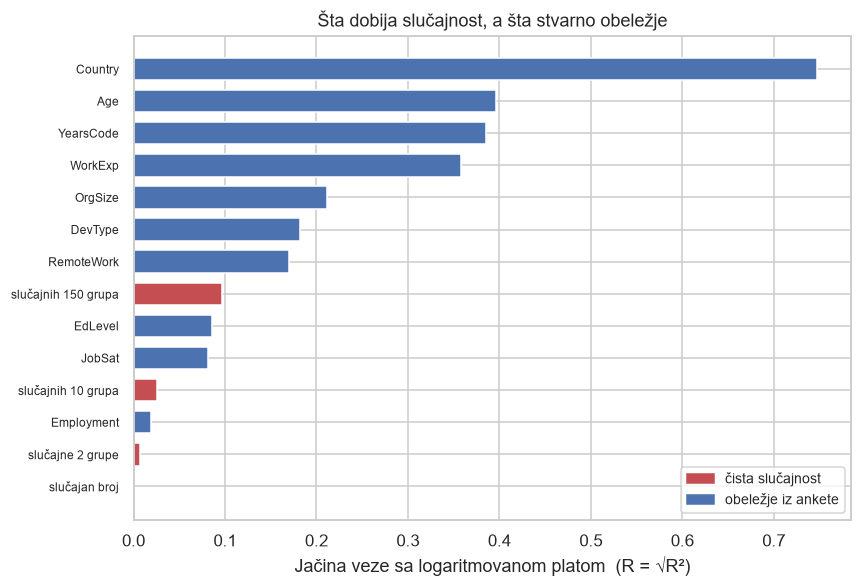

najjača slučajna kolona:    R = 0.097  (slučajnih 150 grupa)
najslabije pravo obeležje:  R = 0.019  (Employment)

prava obeležja koja su slabija od najjače slučajne kolone:
  ['EdLevel', 'JobSat', 'Employment']

najveći prilagođeni R² među slučajnim kolonama: 0.0001
najmanji prilagođeni R² među obeležjima ankete: 0.0003
slučajnih kolona značajnih na pragu 0,05:       0 od 4


In [92]:
comparison = pd.concat([
    noise_table.assign(vrsta="čista slučajnost"),
    reference_table.assign(vrsta="obeležje iz ankete"),
]).sort_values("R")

NOISE_COLOR, REAL_COLOR = "#C44E52", "#4C72B0"
colors = [NOISE_COLOR if v == "čista slučajnost" else REAL_COLOR
          for v in comparison["vrsta"]]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(range(len(comparison)), comparison["R"], color=colors, height=0.7)
ax.set_yticks(range(len(comparison)))
ax.set_yticklabels(comparison.index, fontsize=8)
ax.set_xlabel("Jačina veze sa logaritmovanom platom  (R = √R²)")
ax.set_ylabel("")
ax.set_title("Šta dobija slučajnost, a šta stvarno obeležje")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (NOISE_COLOR, REAL_COLOR)]
ax.legend(handles, ["čista slučajnost", "obeležje iz ankete"], loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

print(f"najjača slučajna kolona:    R = {noise_table['R'].max():.3f}  "
      f"({noise_table['R'].idxmax()})")
print(f"najslabije pravo obeležje:  R = {reference_table['R'].min():.3f}  "
      f"({reference_table['R'].idxmin()})")
print()
print("prava obeležja koja su slabija od najjače slučajne kolone:")
weaker = reference_table[reference_table["R"] < noise_table["R"].max()]
print(f"  {list(weaker.index)}")
print()
print(f"najveći prilagođeni R² među slučajnim kolonama: {noise_table['R2_prilag'].max():.4f}")
print(f"najmanji prilagođeni R² među obeležjima ankete: {reference_table['R2_prilag'].min():.4f}")
print(f"slučajnih kolona značajnih na pragu 0,05:       "
      f"{int((noise_table['p'] < 0.05).sum())} od {len(noise_table)}")

**Zapažanje:** crvene trake nisu sve na levom kraju. Slučajna podela na 150 grupa dobija **R = 0,097**, a
ispis ispod grafika imenuje tri prava obeležja koja su **slabija** od nje: `EdLevel` (0,086), `JobSat`
(0,081) i `Employment` (0,019). Tek od `RemoteWork` (0,170) naviše nema više nijedne crvene trake.

Grafik je crtan na skali R. Ako pređemo na **prilagođeni R²** — druga skala, koja nije na grafiku nego u
ispisu ispod njega — poredak se ispravlja: slučajnost stiže najviše do **0,0001**, a najslabije pravo
obeležje je na **0,0003**. Nijedna slučajna kolona nije značajna na pragu 0,05.

**Tumačenje:** grafik pokazuje ono što se iz dve odvojene tabele nije videlo — da se dva skupa
**preklapaju**, i to na donjoj trećini skale. Da smo promenljive ocenjivali običnim R² ili R i uzimali sve
iznad nekog okruglog broja, primili bismo čist šum a odbacili obrazovanje.

Prilagođeni R² to preklapanje uklanja, i zato pravilo gradimo na njemu, a ne na skali sa grafika. Grafik
je tu da pokaže **zašto** je taj korak potreban.

Za nas iz ovoga slede dve granice koje nismo izmislili nego izmerili: **pod**, ispod kog se promenljiva ne
razlikuje od slučajnosti, i **mesto gde prestaje preklapanje**, iznad kog je promenljiva sigurno u rangu
pravih anketnih obeležja.

### 25.3 Šta se dešava kad obeležja rade zajedno

Iz prethodne tabele lako se izvuče pogrešan zaključak: da je `Country` jedino što vredi, a da su ostala
obeležja skoro bezvredna jer im je R² mali. Pre nego što na tom merilu zasnujemo bilo kakvo pravilo,
moramo da proverimo da li ono uopšte meri ono što nas zanima.

Merenje iz 25.2 je **samostalno** — svaka promenljiva se meri sama, kao da je jedina u modelu. Model,
međutim, koristi sve odjednom, a obeležja se međusobno dopunjuju: zadovoljstvo poslom samo ne govori
mnogo, ali uz zemlju i veličinu firme može da razdvoji slučajeve koje ta dva ne razdvajaju.

Zato pravimo tri modela — samo zemlja, devet ostalih bez zemlje, i svih deset zajedno — pa upoređujemo.
Ako se R² zajedničkog modela ne razlikuje bitno od najboljeg pojedinačnog, onda su ostala obeležja zaista
suvišna. Ako se razlikuje, samostalno merenje potcenjuje njihovu vrednost i sme da služi samo kao sito.

In [93]:
def fit_together(names):
    """One regression on several columns at once, so their joint effect shows."""
    blocks = []
    for name in names:
        values = train[name]
        if values.dtype.kind in "if":
            blocks.append(pd.DataFrame({name: values.astype(float)}))
        else:
            blocks.append(pd.get_dummies(values.astype(str), prefix=name,
                                         drop_first=True, dtype=float))
    design = sm.add_constant(pd.concat(blocks, axis=1), has_constant="add")
    model = sm.OLS(train[TARGET_LOG].to_numpy(), design.to_numpy()).fit()
    return model, design.shape[1] - 1


others = [c for c in REFERENCE if c != "Country"]
for names, label in [(["Country"], "samo Country"),
                     (others, "devet ostalih, bez Country"),
                     (REFERENCE, "svih deset zajedno")]:
    model, columns = fit_together(names)
    print(f"{label:<28} R={np.sqrt(model.rsquared):.3f}   R2={model.rsquared:.4f}   "
          f"prilagođeni={model.rsquared_adj:.4f}   kolona={columns:>3}")

together, _ = fit_together(REFERENCE)
best_alone = reference_table["R2"].max()
print()
print(f"najbolje pojedinačno obeležje samo:  R2 = {best_alone:.4f}")
print(f"svih deset zajedno:                  R2 = {together.rsquared:.4f}")
print(f"dobitak od zajedničkog rada:         {together.rsquared - best_alone:+.4f}")

samo Country                 R=0.747   R2=0.5587   prilagođeni=0.5544   kolona=141
devet ostalih, bez Country   R=0.516   R2=0.2658   prilagođeni=0.2627   kolona= 62


svih deset zajedno           R=0.806   R2=0.6491   prilagođeni=0.6442   kolona=203

najbolje pojedinačno obeležje samo:  R2 = 0.5587
svih deset zajedno:                  R2 = 0.6491
dobitak od zajedničkog rada:         +0.0904


**Zapažanje:** zajednički model svih deset obeležja ima **R² = 0,6491** (R = 0,806), naspram **0,5587**
koliko dobija sama zemlja — dobitak je **+0,0904**. Onih devet obeležja bez zemlje, od kojih nijedno samo
ne prelazi R² od 0,1568, **zajedno dobijaju 0,2658**, dakle R = 0,516.

**Tumačenje:** ovo je odgovor na sumnju koju tabela iz 25.2 sama po sebi izaziva. Obeležja koja
pojedinačno izgledaju slabo **nisu bezvredna** — devet njih zajedno objašnjava preko četvrtine varijanse,
a dodata uz zemlju podižu model za skoro deset procentnih poena. Pojedinačno merenje ih, dakle,
sistematski potcenjuje.

Razlog je što se obeležja dopunjuju. Zemlja kaže na kom je tržištu ispitanik, ali ne razlikuje početnika
od seniora u istoj zemlji; staž to razdvaja, ali ne razlikuje Nemačku od Indije. Tek zajedno pokrivaju obe
vrste razlike.

Iz ovoga slede dve stvari za sve što dalje radimo. Prva: samostalno merenje ostaje **sito za odbacivanje**,
ne merilo za konačan izbor — njime izbacujemo ono što ne razlikuje ništa, a ne rangiramo ono što prolazi.
Druga: ne treba očekivati da će izvedene promenljive imati velike samostalne R². Ako je i najjače anketno
pitanje posle zemlje na 0,1568, izvedena promenljiva koja dobije 0,03 nije razočaranje nego uobičajen
doprinos.

### 25.4 Pravilo koje primenjujemo dalje

Sve je izmereno, pa pravilo možemo da zapišemo pre nego što napravimo ijednu novu promenljivu.
Postavljamo ga sada baš zato da kasnije ne bismo prag birali prema tome kako je ispalo.

Za svaku izvedenu promenljivu računamo isto što i gore i svrstavamo je u jednu od tri grupe, po granicama
koje smo maločas izmerili. Obe granice čitamo sa **prilagođenog** R², jer smo videli da se obični ne sme
porediti između promenljivih različitog oblika; uz svaku je u zagradi ista granica na skali R, radi
osećaja:

1. **Šum.** Promenljiva koja padne na p-vrednosti (≥ 0,05) ili čiji je prilagođeni R² **0,0001 ili niži**
   (R ≈ 0,01) ne razlikuje se od slučajno napravljene kolone — toliko je, naime, dobila najbolja od naše
   četiri slučajne. Takva se ne pravi, bez obzira na to koliko izgleda smisleno.
2. **Slaba.** Prilagođeni R² iznad tog poda, ali **ispod 0,0286** (R ≈ 0,17) — koliko dobija `RemoteWork`,
   najslabije od tri obeležja za koja smo u prethodnom delu utvrdili da **moraju** ući u model.
   Takvu promenljivu zadržavamo samo ako je jeftina, dakle ako traži jednu ili dve kolone, i ako ne
   ponavlja informaciju koju već imamo. Uz nju upisujemo da je slaba.
3. **Nosi signal.** Prilagođeni R² **0,0286 ili više**, dakle u rangu obeležja koja su u anketu ušla kao
   pitanja. Takva promenljiva ulazi bez posebnog obrazloženja.

Tri napomene uz pravilo, da se ne bi čitalo strože nego što jeste.

Gornja granica nije zakon prirode nego **tačka na skali koju smo izmerili** — mesto iznad kog se, na
Grafiku 18, prava obeležja i slučajnost više ne preklapaju. Ako neka promenljiva padne tik ispod nje, to
nije razlog da se odbaci nego da se o njoj odluči po kriterijumu iz tačke 2.

Brojevi deluju mali i to je u redu. Kao što smo videli u 2.3, ni prava anketna pitanja osim zemlje ne idu
preko 0,1568 samostalno, a zajedno stižu do 0,6491. Prag se zato postavlja prema tome šta se u **ovim**
podacima dobija, a ne prema nekoj opštoj predstavi o tome koliki R² treba da bude.

I dalje važi ono što smo rekli na početku sekcije: ovo je sito, ne konačan izbor. Promenljiva koja prođe
nije time zaslužila mesto u konačnom modelu, nego samo pravo da se o njoj dalje razmišlja. Šta zaista
ostaje, odlučuje se u fazi modelovanja, gde se meri doprinos promenljive **uz sve ostale**, a ne
samostalno.

## 26. Multi-select kolone iznutra

Trideset šest kolona je i dalje u obliku u kom ih model ne može primiti: u svakoj ćeliji stoji jedan
string u kome je više odgovora spojeno tačka-zarezom, na primer `Python;JavaScript;SQL`. Enkodiranje
takve kolone kao obične kategorijske nema smisla — u prethodnom delu smo videli da bi svaka
različita **kombinacija** postala sopstvena kategorija, pa bi enkodiranje tekstualnih kolona dalo
višestruko više kolona nego što skup ima redova.

Iz njih zato treba izvesti nove promenljive. Pre nego što to uradimo, moramo da znamo šta je unutra, a to
ne pretpostavljamo nego čitamo iz podataka: koje kolone dolaze iz istog pitanja, koliko odgovora svako
pitanje nudi, koliko ih ispitanik zapravo bira, šta znači kad je ćelija prazna, i da li su nam sve tri
kolone jednog pitanja uopšte potrebne.

### 26.1 Koje kolone dolaze iz istog pitanja

Anketa jedno pitanje ume da izveze kroz više kolona, pa `LanguageHaveWorkedWith` i `LanguageAdmired` nisu
dva pitanja nego dva izvoda iz jednog. Da bismo videli koje kolone idu zajedno, radimo u dva koraka.

**Prvo grupišemo iz samih podataka.** Kolone koje nude **isti spisak ponuđenih odgovora** verovatno dolaze
iz istog pitanja; taj spisak dobijamo tako što razdvojimo sve odgovore po tačka-zarezu i pogledamo koje se
stavke javljaju. Uz to tražimo i zajednički početak imena, jer anketa ume isti spisak da ponudi na dva
različita pitanja.

**Zatim to proveravamo u `survey_results_schema.csv`.** Tamo za svako pitanje stoji njegova oznaka, tip i
pun tekst. Ako je naše grupisanje ispravno, ime svake grupe mora da odgovara jednom pitanju iz šeme — a
tekst tog pitanja nam usput kaže i **kako je pitanje postavljeno**, što će nam trebati u odeljku 26.3.

In [94]:
import sys

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_raw

# What we still need from the raw download: the schema, which carries the
# question each column came from, its type and its full text, and the raw column
# list, so we can see which columns a question had before the cleaning notebook
# dropped some of them.
raw, schema = load_raw()
question_info = schema.drop_duplicates(subset="qname").set_index("qname")

# The answers a question offers, read out of the data itself.
vocabulary = {column: frozenset(train[column].dropna().astype(str).str.split(";").explode())
              for column in multi_select}

by_vocabulary = {}
for column, items in vocabulary.items():
    by_vocabulary.setdefault(items, []).append(column)


def common_prefix(names):
    """The longest beginning all these column names share, cut at a word boundary.

    Without the trimming the prefix can end in the middle of a word: "Personal
    use" and "Professional use" share the leading "P", which is not a name.
    """
    first, last = min(names), max(names)
    length = 0
    while length < min(len(first), len(last)) and first[length] == last[length]:
        length += 1
    while length > 0 and any(name[length:length + 1].islower() for name in names):
        length -= 1
    return first[:length]


def question_name(columns):
    """The schema entry these columns came from, if the schema knows one.

    A group keeps the longest name from the schema that starts every one of its
    columns; where the schema has no such entry we fall back on the shared prefix.
    """
    candidates = [q for q in question_info.index.astype(str)
                  if all(column.startswith(q) for column in columns)]
    return max(candidates, key=len) if candidates else common_prefix(columns)


questions = {}
for columns in by_vocabulary.values():
    if common_prefix(columns):
        questions[question_name(columns)] = columns
    else:
        for column in columns:
            questions[question_name([column])] = [column]

print(f"multi-select kolona:            {len(multi_select)}")
print(f"različitih spiskova odgovora:   {len(by_vocabulary)}")
print(f"pitanja iz kojih dolaze:        {len(questions)}")
print(f"svaka kolona u tačno jednom pitanju: "
      f"{sum(len(c) for c in questions.values()) == len(multi_select)}")
print()
print(f"{'pitanje':<20} {'kol':>3}  {'stavki':>6}  {'tip':<7} tekst pitanja")
for name, columns in sorted(questions.items(), key=lambda kv: (-len(kv[1]), kv[0])):
    known = name in question_info.index
    kind = question_info.loc[name, "type"] if known else "—"
    text = str(question_info.loc[name, "question"]) if known else "(nema u šemi)"
    text = re.sub(r"<[^>]+>|\s+", " ", text).strip()
    print(f"{name:<20} {len(columns):>3}  {len(vocabulary[columns[0]]):>6}  {kind:<7} {text[:64]}")

print()
print(f"grupa čije ime postoji u šemi: "
      f"{sum(name in question_info.index for name in questions)} od {len(questions)}")
print()
# A technology question is exported as up to these three views of one grid.
TRIPLE_VIEWS = ("HaveWorkedWith", "WantToWorkWith", "Admired")
print("pitanja koja su deo svojih kolona izgubila u prethodnom delu:")
for name, columns in sorted(questions.items()):
    views = [c for c in raw.columns if c.startswith(name) and c[len(name):] in TRIPLE_VIEWS]
    lost = sorted(set(views) - set(columns))
    if lost:
        print(f"  {name:<10} u sirovom fajlu {len(views)} kolone, ovde {len(columns)}   ispalo: {lost}")

shared = [columns for columns in by_vocabulary.values()
          if len(columns) > 1 and not common_prefix(columns)]
print()
print(f"različita pitanja koja dele isti spisak odgovora: {shared}")

multi-select kolona:            36
različitih spiskova odgovora:   16
pitanja iz kojih dolaze:        17
svaka kolona u tačno jednom pitanju: True

pitanje              kol  stavki  tip     tekst pitanja
AIAgentChallenges      3       7  Matrix  To what extent do you agree with the following statements regard
AITool                 3      14  Matrix  Which parts of your development workflow are you currently integ
CommPlatform           3      18  Matrix  Which  community platforms  have you utilized considerably or co
Database               3      30  Matrix  Which  database environments  have you done extensive developmen
DevEnvs                3      27  Matrix  Which  development environments and AI-enabled code editing tool
Language               3      42  Matrix  Which  programming, scripting, and markup languages  have you do
OfficeStackAsync       3      25  Matrix  Which  collaborative work management and/or code documentation t
Platform               3      42  Matrix  Which

**Zapažanje:** grupisanje izvedeno iz podataka poklapa se sa šemom u potpunosti — **svih 17 imena grupa
postoji u šemi kao pitanje**, i nijedna kolona nije ostala izvan grupe ili u dve.

Iz kolone `tip` vidi se odakle razlika u broju kolona. Pitanja tipa **`MC`** su ona sa uputstvom „Select
all that apply": ispitanik iz jednog spiska čekira šta hoće, i to se izvozi kao **jedna** kolona. Takvih
je pet: `LearnCode`, `AILearnHow`, `AIFrustration`, `AIHuman` i `SO_Dev_Content`.

Pitanja tipa **`Matrix`** su tabela: redovi su ponuđene stavke, a kolone su nešto što se za svaku stavku
bira. Takvo pitanje se izvozi kao **više kolona, po jedna za svaku kolonu tabele**. Kod `Language` te
kolone su „koristio sam", „želim da koristim" i „divim se"; kod `OpSys` su „privatno" i „poslovno"; kod
`AIAgentChallenges` su stepeni slaganja.

Dva pitanja tipa `Matrix` ovde imaju **samo po jednu kolonu**, i poslednji deo ispisa pokazuje zašto:
`AIModels` i `SOTags` su u sirovom fajlu imali po tri kolone, ali su im `WantToWorkWith` i `Admired`
ispali u prethodnom delu, jer su prelazili granicu od 50% nedostajućih vrednosti.

**Tumačenje:** to što spiskove čitamo iz podataka pa proveravamo šemom, a ne obrnuto, isplatilo se na dva
mesta.

Prvo, poslednji red ispisa izdvaja slučaj koji bi nas prevario: **`LearnCode` i `AILearnHow` dele
identičan spisak od 13 stavki**, jer anketa istu ponudu koristi i za pitanje kako je neko naučio da
programira i za pitanje kako je naučio da programira za AI. To su dva različita `MC` pitanja sa jednim
spiskom, pa smo uz poklapanje spiska tražili i zajednički početak imena — bez toga bi se spojila u jedno.

Drugo, sada znamo da tri kolone jednog tehnološkog pitanja **nisu tri nezavisna pitanja** nego tri kolone
iste tabele. To menja način na koji o njima razmišljamo: iz njih se mogu izvesti i poređenja koja nijedna
kolona sama ne nosi, a otvara se i pitanje da li su nam sve tri uopšte potrebne — čime se bavi odeljak 26.4.

### 26.2 Koliko se nudi, a koliko se bira

Sada kada znamo koje kolone dolaze iz kog pitanja, gledamo šta je u njima. Zanimaju nas tri broja po
koloni: koliko stavki pitanje uopšte nudi, koliko ih ispitanik izabere, i koliko je ćelija prazno.

Broj izabranih stavki računamo **samo nad ispitanicima koji su nešto izabrali**. Prazne ćelije za sada
zaobilazimo, jer još ne znamo znače li „nisam odgovorio" ili „nisam izabrao ništa" — to je pitanje kojim
se bavi odeljak 26.3.

In [95]:
question_of = {column: name for name, columns in questions.items() for column in columns}


def chosen_counts(column):
    """How many items each respondent picked, among those who picked any."""
    answered = train[column].dropna().astype(str)
    return answered.str.split(";").str.len()


records = []
for column in multi_select:
    counts = chosen_counts(column)
    records.append({
        "pitanje": question_of[column],
        "kolona": column,
        "nudi": len(vocabulary[column]),
        "nedostaje_%": round(100 * train[column].isna().mean(), 1),
        "izabrano_medijana": counts.median(),
        "izabrano_prosek": round(counts.mean(), 1),
        "izabrano_max": counts.max(),
    })

inventory = pd.DataFrame(records).sort_values(["pitanje", "kolona"])
print(inventory.to_string(index=False))

          pitanje                                   kolona  nudi  nedostaje_%  izabrano_medijana  izabrano_prosek  izabrano_max
AIAgentChallenges                 AIAgentChallengesNeutral     7         36.4                2.0              2.0             7
AIAgentChallenges          AIAgentChallengesSomewhat agree     7         31.5                2.0              2.0             7
AIAgentChallenges          AIAgentChallengesStrongly agree     7         29.8                2.0              2.3             7
    AIFrustration                            AIFrustration     7          6.6                2.0              1.9             6
          AIHuman                                  AIHuman    10         11.7                4.0              4.5            10
       AILearnHow                               AILearnHow    13         31.9                3.0              2.9            13
         AIModels                   AIModelsHaveWorkedWith    17         48.5                3.0        

**Zapažanje:** tri stvari se vide iz tabele.

**Bira se mnogo manje nego što se nudi.** `Language` nudi 42 jezika, a medijana izabranih je **6**;
`Platform` nudi 42, medijana je **7**. Kod dugih spiskova je taj odnos najmanji — šestina do sedmine
ponuđenog; kod kratkih pitanja je osetno veći, pa `AIHuman` nudi **10** stavki a medijana je **4**.

**Unutar tehnološkog pitanja nedostajanje raste od kolone do kolone.** Kod jezika je `HaveWorkedWith`
prazan kod **6,2%** ispitanika, `WantToWorkWith` kod **19,1%**, a `Admired` kod **29,2%**. Isti redosled
je i kod `Webframe` (26,4% → 42,5% → 48,3%) i kod ostalih.

**Ima kolona u kojima je neko izabrao baš sve što se nudi.** `LanguageHaveWorkedWith` i `PlatformHaveWorkedWith` imaju
maksimum **42**, koliko i nude; `DatabaseHaveWorkedWith` ima 30 od 30, `LearnCode` 13 od 13.

**Tumačenje:** prvi nalaz je očekivan i dobar — spiskovi su dugi, a ljudi biraju nekoliko stavki, pa
„koliko ih je izabrao" ima izgleda da bude korisna promenljiva.

Drugi nalaz ima jasno objašnjenje: tri kolone su tri uzastopna potpitanja, i što je pitanje kasnije, to ga
više ljudi preskoči. To je isti obrazac zamora koji smo videli u prethodnom delu — nedostajanje
raste kako se ide dublje u anketu.

Treći nalaz treba zapamtiti kao upozorenje. Neko ko je označio svih 42 jezika najverovatnije nije redom
razmišljao o svakom, nego je označio sve. To je isti potpis neozbiljnog odgovora koji smo u prethodnom delu sreli kod broja alata, gde su se javljale okrugle i očigledno izmišljene vrednosti. Ovde ga ne ispravljamo, jer za
razliku od sto godina staža izbor svih stavki **nije nemoguć**, ali ćemo na njega paziti kada budemo pravili
promenljivu od broja izabranih stavki.

### Grafik 19 — koliko stavki ispitanik bira

**Motivacija:** iz tabele se vidi prosek i medijana, ali ne i koliko se ispitanici međusobno razlikuju.
To je za nas ključno, jer sledeća sekcija hoće da od „broja izabranih stavki" napravi promenljivu — a ona
ima smisla samo ako se taj broj razlikuje od čoveka do čoveka. Ako svi biraju otprilike isto, promenljiva
ne razlikuje nikoga i nema šta da objasni. Crtamo raspodelu za svaku kolonu, boxplot-om, jer prikazuje
medijanu i rasipanje odjednom.

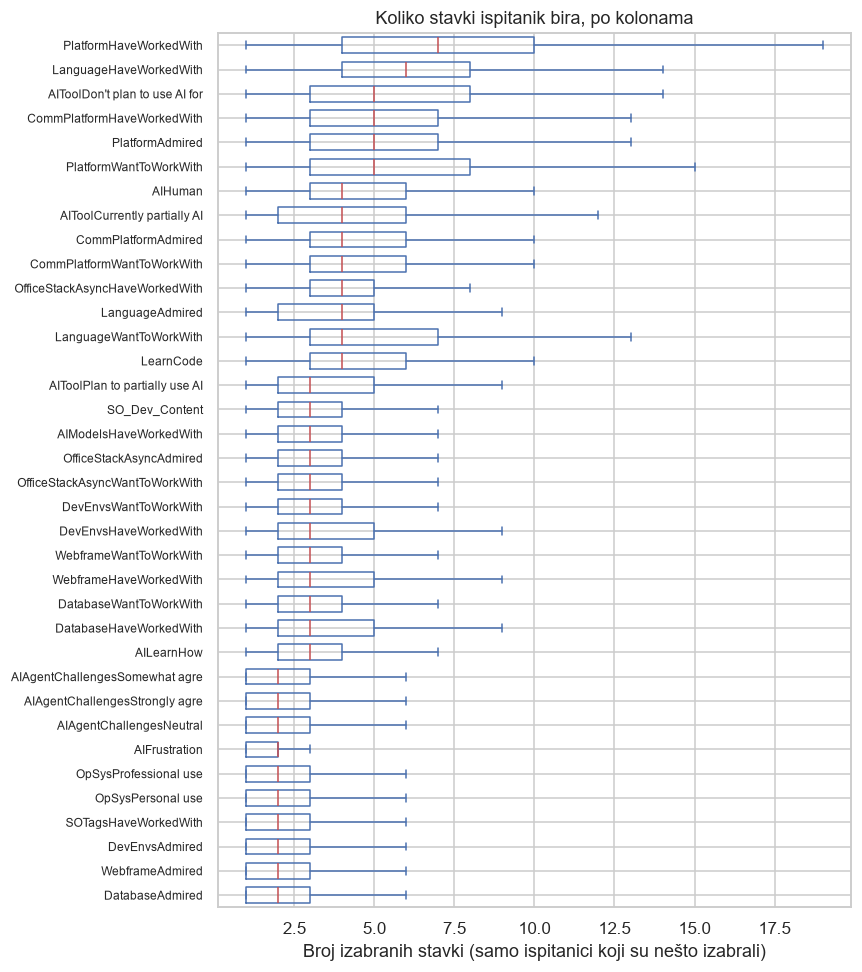

kolona kod kojih je IQR nula (tri četvrtine bira isti broj): 0 od 36

najmanje rasipanja:
         kolona  q1  medijana  q3  IQR
  AIFrustration 1.0       2.0 2.0  1.0
DatabaseAdmired 1.0       2.0 3.0  2.0
WebframeAdmired 1.0       2.0 3.0  2.0
 DevEnvsAdmired 1.0       2.0 3.0  2.0

najviše rasipanja:
                                  kolona  q1  medijana   q3  IQR
                  PlatformHaveWorkedWith 4.0       7.0 10.0  6.0
                  PlatformWantToWorkWith 3.0       5.0  8.0  5.0
AIToolDon't plan to use AI for this task 3.0       5.0  8.0  5.0
                  LanguageWantToWorkWith 3.0       4.0  7.0  4.0


In [96]:
order = sorted(multi_select, key=lambda c: chosen_counts(c).median())
data = [chosen_counts(column).to_numpy() for column in order]

fig, ax = plt.subplots(figsize=(8, 9))
ax.boxplot(data, orientation="horizontal", widths=0.65, showfliers=False,
           medianprops={"color": "#C44E52"},
           boxprops={"color": "#4C72B0"},
           whiskerprops={"color": "#4C72B0"},
           capprops={"color": "#4C72B0"})

ax.set_yticks(range(1, len(order) + 1))
ax.set_yticklabels([c[:30] for c in order], fontsize=8)
ax.set_xlabel("Broj izabranih stavki (samo ispitanici koji su nešto izabrali)")
ax.set_ylabel("")
ax.set_title("Koliko stavki ispitanik bira, po kolonama")
plt.tight_layout()
plt.show()

spread = pd.DataFrame({
    "kolona": order,
    "q1": [np.percentile(d, 25) for d in data],
    "medijana": [np.median(d) for d in data],
    "q3": [np.percentile(d, 75) for d in data],
})
spread["IQR"] = spread["q3"] - spread["q1"]
print(f"kolona kod kojih je IQR nula (tri četvrtine bira isti broj): "
      f"{int((spread['IQR'] == 0).sum())} od {len(spread)}")
print()
print("najmanje rasipanja:")
print(spread.nsmallest(4, "IQR").to_string(index=False))
print()
print("najviše rasipanja:")
print(spread.nlargest(4, "IQR").to_string(index=False))

**Zapažanje:** nijedna kolona nema IQR jednak nuli — **0 od 36** — dakle nigde tri četvrtine ispitanika ne
bira isti broj stavki. Najmanje rasipanja ima `AIFrustration`, gde kutija ide od 1 do 2 stavke, a najviše
`PlatformHaveWorkedWith`, sa kutijom od 4 do 10 i **IQR od 6**.

Na grafiku se vidi i da su kutije pomerene ulevo, uz nulu, sa dugim repom udesno: većina bira nekoliko
stavki, a manjina mnogo.

**Tumačenje:** ovo je odgovor na pitanje zbog kog je grafik i nacrtan. Broj izabranih stavki **se razlikuje
između ispitanika u svakoj koloni**, pa promenljiva napravljena od njega ima šta da razlikuje. Da je
negde IQR bio nula, ta kolona bi za takvu promenljivu bila beskorisna i to bismo saznali pre nego što je
napravimo.

Razlika u rasipanju između kolona je usput i sama po sebi informacija: kod `PlatformHaveWorkedWith` ljudi
se razlikuju mnogo više nego kod `AIFrustration`, pa se od prve može očekivati jača promenljiva. Da li je
tako, meriće se u sledećoj sekciji, ne pretpostavljati odavde.

### 26.3 Šta znači prazna ćelija

Ovo je pitanje koje određuje sve što sledi, a odgovor nije isti za sve kolone.

Kod pitanja izvezenog kroz **jednu** kolonu prazno polje znači da ispitanik na pitanje nije odgovorio. Kod
pitanja izvezenog kroz **više** kolona prazna kolona može da znači nešto sasvim drugo: da je ispitanik
odgovorio, ali da u tom delu pitanja nije izabrao nijednu stavku.

Da to ne bismo pretpostavljali, pogledaćemo **kako je pitanje zaista postavljeno** — tekst iz šeme stoji u
ispisu ispod. Zatim, za svako pitanje sa više kolona, brojimo da li su prazne **sve** njegove kolone ili
samo neke. Ako su prazne sve, ispitanik pitanje nije video ili ga je preskočio. Ako su prazne neke a druge
popunjene, pitanje je odgovoreno i praznina znači nulu.

In [97]:
# The wording decides how an empty cell should be read, so we print it in full.
for name in ["AIAgentChallenges", "Language"]:
    text = re.sub(r"<[^>]+>|\s+", " ", str(question_info.loc[name, "question"])).strip()
    print(f"{name} ({question_info.loc[name, 'type']}), kolone {questions[name]}:")
    print(f"  {text}")
    print()

multi_column_questions = {name: columns for name, columns in questions.items() if len(columns) > 1}

records = []
means_zero = pd.Series(False, index=train.index)
for name, columns in multi_column_questions.items():
    empty = train[columns].isna()
    some_empty = empty.any(axis=1) & ~empty.all(axis=1)
    means_zero |= some_empty
    records.append({
        "pitanje": name,
        "kolona": len(columns),
        "prazne_sve": int(empty.all(axis=1).sum()),
        "prazne_neke": int(some_empty.sum()),
        "prazna_nijedna": int((~empty.any(axis=1)).sum()),
    })

emptiness = pd.DataFrame(records).sort_values("prazne_neke", ascending=False)
emptiness["udeo_nula_%"] = (100 * emptiness["prazne_neke"]
                            / (emptiness["prazne_neke"] + emptiness["prazna_nijedna"])).round(1)
print(emptiness.to_string(index=False))
print()
single_column_questions = [name for name, columns in questions.items() if len(columns) == 1]
print(f"pitanja izvezenih kroz jednu kolonu: {len(single_column_questions)}   "
      f"kroz više kolona: {len(multi_column_questions)}")
print(f"ispitanika kod kojih bar jedno pitanje ima prazninu koja znači nulu: "
      f"{int(means_zero.sum()):,} ({100 * means_zero.mean():.1f}%)")

AIAgentChallenges (Matrix), kolone ['AIAgentChallengesNeutral', 'AIAgentChallengesStrongly agree', 'AIAgentChallengesSomewhat agree']:
  To what extent do you agree with the following statements regarding AI agents?

Language (Matrix), kolone ['LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired']:
  Which  programming, scripting, and markup languages  have you done extensive development work in over the past year, and which do you want to work in over the next year? (If you both worked with the language and want to continue to do so, please check both boxes in that row.)

          pitanje  kolona  prazne_sve  prazne_neke  prazna_nijedna  udeo_nula_%
AIAgentChallenges       3        1860         7234            5514         56.7
           AITool       3        1230         7174            6204         53.6
         Database       3        2866         3594            8148         30.6
         Language       3         909         3350           10349         24.5
 Off

**Zapažanje:** tekst pitanja, ispisan iznad tabele, rešava dilemu.

`Language` je **jedno** pitanje, i njegov tekst izričito kaže: *„...and which do you want to work in over
the next year? (If you both worked with the language and want to continue to do so, please check both
boxes in that row.)"* Dakle jedna tabela, u svakom redu jedan jezik, a u redu dva polja za čekiranje.
`AIAgentChallenges` je takođe jedna tabela, gde se za svaku tvrdnju bira stepen slaganja.

Brojevi zatim pokazuju koliko je praznina te vrste. Kod svih deset pitanja sa više kolona postoji velika
grupa ispitanika kojima su neke kolone prazne a druge popunjene: kod `AIAgentChallenges` **7.234**,
odnosno **56,7%** onih koji su na pitanje uopšte odgovorili, kod `AITool` **53,6%**, a kod `OpSys` svega
**5,9%**. Ukupno **12.059 ispitanika, odnosno 82,6% trening skupa**, ima bar jedno pitanje sa takvom
prazninom.

**Tumačenje:** pošto je reč o jednoj tabeli, a ne o tri uzastopna pitanja, prazna kolona ne znači da je
ispitanik nešto preskočio — znači da u toj koloni tabele **nije čekirao nijedan red**. To je nula
izabranih stavki, dakle vrednost, a ne nedostajući podatak. Kod `AIAgentChallenges` je zaključak još
čvršći, jer se stepeni slaganja međusobno isključuju: stavka ocenjena sa „Strongly agree" ne može biti i
u koloni „Neutral", pa ko je bilo šta svrstao, pitanje je odgovorio.

Da smo prazninu tretirali kao nedostajanje, izmislili bismo je kod više od polovine ispitanika kod dva
pitanja, i kod 82,6% njih bar negde.

Ostaje jedna ograda koju ne možemo da uklonimo. To što neko nije čekirao nijedno polje u koloni „want" ne
razlikuje onoga ko zaista ne želi nijednu tehnologiju od onoga ko se tim delom tabele nije bavio. Iz
podataka se ta dva slučaja ne razdvajaju, jer bismo morali da znamo šta je ispitanik mislio.

Zato u sledećoj sekciji radimo ovako: praznu kolonu tumačimo kao **nulu izabranih stavki kada je ispitanik
na to pitanje odgovorio bar u jednoj koloni**, a kao **nedostajanje kada su mu prazne sve kolone tog
pitanja**. Uz izvedene promenljive ide i indikator koji pamti da li je pitanje uopšte odgovoreno, po istom
principu po kom smo u prethodnom delu uveli kolone `NotAnswered_*`.

### 26.4 Hipoteza 5 — da li su nam potrebne sve tri kolone

Sedam tehnoloških pitanja izvezeno je kroz tri kolone: `HaveWorkedWith`, `WantToWorkWith` i `Admired`.
Prve dve odgovaraju na ono što tekst pitanja i traži — šta si koristio i šta bi želeo da koristiš. Treća
se u tekstu pitanja **ne pominje nigde**, pa nije jasno odakle dolazi.

Najverovatnije objašnjenje je da je Stack Overflow nije ni pitao nego izračunao, kao presek prve dve:
tehnologija kojoj se ispitanik „divi" bila bi ona koju je koristio i želi da nastavi da koristi. Ako je
tako, ta kolona ne nosi nijedan podatak koji već nemamo, i promenljive izvedene iz nje ponavljale bi
informaciju — što je problem o kome smo učili kao o kolinearnosti.

> **Hipoteza:** kolona `Admired` nije zaseban odgovor nego je izvedena iz druge dve. Formalno: za svakog
> ispitanika skup stavki u `Admired` jednak je preseku skupova iz `HaveWorkedWith` i `WantToWorkWith`.
>
> **Kriterijum, postavljen unapred:** hipoteza je potvrđena samo ako jednakost važi kod **svakog**
> ispitanika koji je na pitanje odgovorio, u **svih sedam** tehnoloških pitanja. Reč je o tvrdnji o
> pravilu, a ne o vezi među promenljivama, pa je jedan protivprimer dovoljan da je obori.

In [98]:
def item_sets(column):
    """Each respondent's chosen items, as a set."""
    return train[column].fillna("").astype(str).map(lambda value: set(value.split(";")) - {""})


# The seven questions exported through exactly these three views.
TRIPLE_SUFFIXES = ("HaveWorkedWith", "WantToWorkWith", "Admired")
technology_questions = [name for name, columns in questions.items()
                        if sorted(columns) == sorted(name + s for s in TRIPLE_SUFFIXES)]

records = []
for name in technology_questions:
    have, want, admired = (item_sets(name + suffix) for suffix in TRIPLE_SUFFIXES)
    answered = (have.map(len) + want.map(len) + admired.map(len)) > 0
    equal = pd.Series([a == (h & w) for h, w, a in zip(have, want, admired)], index=train.index)
    records.append({
        "pitanje": name,
        "odgovorilo": int(answered.sum()),
        "Admired == Have∩Want": int((equal & answered).sum()),
        "izuzetaka": int((~equal & answered).sum()),
    })

identity = pd.DataFrame(records).sort_values("odgovorilo", ascending=False)
print(identity.to_string(index=False))
print()
print(f"ukupno izuzetaka u svih sedam pitanja: {int(identity['izuzetaka'].sum())}")
print()

# If the set is fixed by the other two, is its size fixed as well? Among people
# who chose the same number of languages and want the same number, how much does
# the size of the intersection still move?
have, want, admired = (item_sets("Language" + suffix) for suffix in TRIPLE_SUFFIXES)
sizes = pd.DataFrame({"koristi": have.map(len), "zeli": want.map(len), "oba": admired.map(len)})
fixed = sizes[(sizes["koristi"] == 5) & (sizes["zeli"] == 5)]
print(f"ispitanika koji koriste tačno 5 i žele tačno 5 jezika: {len(fixed)}")
print(f"  koliko od njih je u preseku: od {int(fixed['oba'].min())} do {int(fixed['oba'].max())}, "
      f"medijana {fixed['oba'].median():.0f}")

         pitanje  odgovorilo  Admired == Have∩Want  izuzetaka
        Language       13699                 13699          0
OfficeStackAsync       13291                 13291          0
    CommPlatform       13114                 13114          0
         DevEnvs       11862                 11862          0
        Database       11742                 11742          0
        Platform       11450                 11450          0
        Webframe       10747                 10747          0

ukupno izuzetaka u svih sedam pitanja: 0

ispitanika koji koriste tačno 5 i žele tačno 5 jezika: 439
  koliko od njih je u preseku: od 0 do 5, medijana 5


**Zapažanje:** jednakost važi **kod svakog ispitanika, u svakom od sedam pitanja** — ukupno **nula
izuzetaka**. Kod jezika je proverena na 13.699 ispitanika, kod okruženja za rad na 13.291, i tako redom.

**Verdikt: hipoteza je potvrđena.** Kolona `Admired` nije zaseban odgovor nego presek druge dve.

**Tumačenje:** iz ovoga slede dve stvari, i vredi ih razdvojiti jer vode na različite strane.

**Skup stavki iz `Admired` ne nosi ništa novo.** Ako za nekog ispitanika znamo koje je tehnologije
koristio i koje želi, znamo i kojima se „divi" — to je presek ta dva skupa. Zato indikator oblika „divi se
Pythonu" ne bi bio nova promenljiva nego proizvod dve koje već imamo. Takva promenljiva ne bi bila samo
suvišna nego štetna, jer bi u model unela kolinearnost o kojoj smo učili — treću kolonu koja je tačno
određena prve dve.

**Broj stavki iz `Admired` ipak nosi nešto novo.** Ovo je važna razlika i lako se previdi. To što je skup
određen ne znači da je i njegova veličina određena veličinama druga dva. Ispis to i pokazuje: među
**439 ispitanika koji koriste tačno pet jezika i žele tačno pet**, u preseku ih ima **od 0 do 5**. Dakle
dva čoveka sa istim brojem korišćenih i istim brojem željenih jezika mogu imati potpuno različit presek —
jedan želi da nastavi sa svim jezicima koje već zna, drugi ni sa jednim.

To je zapravo zanimljiva veličina: koliko je neko **zadovoljan onim čime već radi**. Broj korišćenih i broj
željenih jezika to ne mere.

**Posledica po dalji rad.** U sekciji 28, gde od pojedinačnih stavki pravimo indikatore, kolone `Admired`
se **izostavljaju** — sve što bi dale već daju druge dve. U sekciji 27, gde brojimo izabrane stavke, one
**ostaju**, i iz njih pravimo promenljivu koja meri poklapanje između korišćenog i željenog.

### Šta sekcija ostavlja sledećoj

Sada znamo od čega pravimo promenljive:

- 36 kolona dolazi iz **17 pitanja**, i to je provereno šemom, ne pretpostavljeno. Pet pitanja je tipa
  `MC` i daje po jednu kolonu; dvanaest je tipa `Matrix`, tabela u kojoj su redovi ponuđene stavke a
  kolone ono što se za svaku bira;
- spiskovi su dugi (do 42 stavke) a bira se malo (medijana od dve do sedam), i broj izabranih stavki se
  razlikuje između ispitanika u **svakoj** koloni, jer nigde IQR nije nula;
- prazna ćelija **ne znači svuda isto**: kod pitanja sa više kolona znači nulu izabranih stavki, a
  nedostajanje samo kada su prazne sve kolone tog pitanja;
- kolona `Admired` je **presek** druge dve, bez ijednog izuzetka, pa se iz nje smeju praviti promenljive
  koje mere veličinu preseka, ali ne i indikatori pojedinačnih stavki.

Iz svega toga slede dva pravca za izvođenje promenljivih, i njima se bave naredne dve sekcije: **koliko je
stavki izabrano** (sekcija 27) i **koje su stavke izabrane** (sekcija 28). Nijedna se ne uzima zdravo za
gotovo — obe se mere merilom postavljenim u sekciji 25.

## 27. Broj izabranih stavki kao promenljiva

Prvi način da se iz multi-select kolone izvuče broj je najjednostavniji: prebrojati koliko je stavki
ispitanik izabrao. Iz `Python;JavaScript;SQL` postaje **3**.

Time se gubi *koje* su stavke izabrane — time se bavi sledeća sekcija — ali ostaje nešto što bi moglo da
bude povezano sa platom: koliko je nečiji posao širok. Neko ko radi sa deset tehnologija verovatno radi
drugačiji posao od nekoga ko radi sa dve.

### 27.1 Tri vrste promenljivih i na kom se nivou prave

Pravimo tri vrste promenljivih, i **svaka se pravi na drugom nivou**, pa to odmah razdvajamo:

| prefiks | šta meri | pravi se za | koliko ih ima |
| --- | --- | --- | --- |
| `Count_` | koliko je stavki izabrano | **svaku kolonu** | 36 |
| `NotAnswered_` | da li je pitanje uopšte odgovoreno | **svako pitanje** | 17 |
| `KeptShare_` | koliki deo korišćenog želi da zadrži | **svako tehnološko pitanje** | 7 |

Ukupno **36 + 17 + 7 = 60** novih kolona. Indikatora ima 17 a ne 36 zato što se odgovara na pitanje, ne
na kolonu: ko je preskočio pitanje `Language`, preskočio je sve tri njegove kolone odjednom, pa je jedan
indikator dovoljan. Odnos zadržanog postoji samo tamo gde su sve tri kolone prisutne, a to je kod sedam
tehnoloških pitanja.

Zašto uz brojeve idu i druge dve:

- **indikator neodgovaranja** je potreban zato što po odeljku 26.3 prazna kolona znači nulu samo ako je
  ispitanik pitanje odgovorio bar negde; ako su mu prazne sve kolone tog pitanja, broj ne postoji i mora
  se popuniti, pa se pamti da je popunjen;
- **odnos zadržanog** je jedina promenljiva koju Hipoteza 5 dozvoljava da se izvede iz kolone `Admired`,
  jer se veličina preseka ne može izračunati iz druga dva broja.

Imena su na engleskom, kao i sva ostala u isporučenim podacima.

In [99]:
COUNT_PREFIX = "Count_"
KEPT_PREFIX = "KeptShare_"
ANSWERED_PREFIX = "NotAnswered_"


def multi_select_features(frame):
    """Counts, indicators and ratios derived from the multi-select columns.

    An empty cell counts as zero chosen items when the respondent answered the
    question in some other column, and is left missing only when every column of
    that question is empty — the rule established in 3.3.
    """
    out = pd.DataFrame(index=frame.index)
    for name, columns in questions.items():
        answered = frame[columns].notna().any(axis=1)
        out[ANSWERED_PREFIX + name] = (~answered).astype(int)
        for column in columns:
            chosen = frame[column].fillna("").astype(str).map(
                lambda value: len(set(value.split(";")) - {""}))
            out[COUNT_PREFIX + column] = chosen.where(answered)

    # The share of what a respondent uses that they also want to keep. Undefined
    # for someone who uses nothing, and the count column already says who that is.
    for name in technology_questions:
        used = out[COUNT_PREFIX + name + "HaveWorkedWith"]
        kept = out[COUNT_PREFIX + name + "Admired"]
        out[KEPT_PREFIX + name] = (kept / used).where(used > 0)
    return out


new_features = multi_select_features(train)

columns_before = train.shape[1]
print("koliko je čega napravljeno i na kom nivou:")
for prefix, label, level in [
        (COUNT_PREFIX, "broj izabranih stavki", f"{len(multi_select)} kolona"),
        (ANSWERED_PREFIX, "indikator neodgovaranja", f"{len(questions)} pitanja"),
        (KEPT_PREFIX, "odnos zadržanog", f"{len(technology_questions)} tehnoloških pitanja")]:
    made = sum(c.startswith(prefix) for c in new_features.columns)
    print(f"  {label:<24} {made:>3}   (jedna na svaku jedinicu od: {level})")
print(f"  {'ukupno novih kolona':<24} {new_features.shape[1]:>3}")
print()
print(f"praznih polja pre popunjavanja: {int(new_features.isna().sum().sum()):,}")

# Every fill value is the training median, as in the previous notebook.
fill_values = new_features.median()
new_features = new_features.fillna(fill_values)
train = pd.concat([train, new_features], axis=1)

print(f"praznih polja posle popunjavanja: {int(new_features.isna().sum().sum())}")
print()
print(f"kolona u skupu pre ove sekcije:  {columns_before}")
print(f"kolona posle:                    {train.shape[1]}   "
      f"(+{train.shape[1] - columns_before})")
print()
print("primer, pitanje Language kod prvih šest ispitanika:")
print(train[["Count_LanguageHaveWorkedWith", "Count_LanguageWantToWorkWith",
             "Count_LanguageAdmired", "KeptShare_Language",
             "NotAnswered_Language"]].head(6).round(3).to_string())

koliko je čega napravljeno i na kom nivou:
  broj izabranih stavki     36   (jedna na svaku jedinicu od: 36 kolona)
  indikator neodgovaranja   17   (jedna na svaku jedinicu od: 17 pitanja)
  odnos zadržanog            7   (jedna na svaku jedinicu od: 7 tehnoloških pitanja)
  ukupno novih kolona       60

praznih polja pre popunjavanja: 106,628
praznih polja posle popunjavanja: 0

kolona u skupu pre ove sekcije:  130
kolona posle:                    190   (+60)

primer, pitanje Language kod prvih šest ispitanika:
   Count_LanguageHaveWorkedWith  Count_LanguageWantToWorkWith  Count_LanguageAdmired  KeptShare_Language  NotAnswered_Language
0                           4.0                           4.0                    3.0               0.750                     0
1                           4.0                           2.0                    1.0               0.250                     0
2                           5.0                           1.0                    0.0               0

**Zapažanje:** napravljeno je **60 novih kolona** — 36 brojačkih, 17 indikatora neodgovaranja i 7 odnosa
zadržanog. Pre popunjavanja u njima je bilo **106.628 praznih polja**, posle nijedno.

Primer za pitanje `Language` pokazuje da pravilo iz 26.3 radi kako treba. Treći ispitanik koristi pet
jezika, želi jedan, a u preseku nema nijedan — `Count_LanguageAdmired` mu je **0**, ne prazno, jer je
pitanje odgovorio. Šesti koristi šest jezika i svih šest želi da zadrži, pa mu je odnos zadržanog **1,0**.

**Tumačenje:** onih 106.628 praznih polja pre popunjavanja nisu ispitanici koji nisu odgovorili — to su
uglavnom kolone gde je broj nula i takvi su i upisani kao nula. Prazno je ostalo samo tamo gde je celo
pitanje preskočeno, i to je popunjeno medijanom trening skupa, uz indikator koji pamti da je popunjeno,
isto kao u prethodnom delu.

Odnos zadržanog je jedina promenljiva koja je izvedena iz kolone `Admired`, i to je ona koju Hipoteza 5
dozvoljava: veličina preseka se ne može izračunati iz druga dva broja, pa nije ponavljanje.

### 27.2 Koliko te promenljive same nose

Nove promenljive prolaze kroz merilo iz sekcije 25, isto kao i anketna obeležja. Ništa se ne zadržava zato
što je izgledalo smisleno kad smo ga pravili.

Merimo sve tri vrste odjednom, jer se međusobno takmiče za isto mesto: ako `KeptShare_` ne dobija ništa
više od pukog `Count_`, onda ga ni ne treba praviti.

In [100]:
measured = signal_table({column: train[column] for column in new_features.columns})

print("deset najjačih:")
show(measured.head(10))
print()
print("pet najslabijih:")
show(measured.tail(5))
print()

# The three bands set in 2.4, applied without changing anything.
NOISE_LIMIT = 0.0001
# Above this a variable counts as carrying signal, also from 2.4.
SIGNAL_LIMIT = 0.0286
band = pd.cut(measured["R2_prilag"], [-np.inf, NOISE_LIMIT, SIGNAL_LIMIT, np.inf],
              labels=["šum", "slaba", "nosi signal"])
insignificant = measured["p"] >= 0.05
band = band.mask(insignificant, "šum")

print("razvrstano po pravilu iz 25.4 (ništa se još ne izbacuje):")
for name, count in band.value_counts().reindex(["nosi signal", "slaba", "šum"]).items():
    print(f"  {name:<14} {int(count):>3} od {len(measured)}")
print()
for prefix, label in [(COUNT_PREFIX, "Count_"), (KEPT_PREFIX, "KeptShare_"),
                      (ANSWERED_PREFIX, "NotAnswered_")]:
    rows = [c for c in measured.index if c.startswith(prefix)]
    best = measured.loc[rows, "R2_prilag"].idxmax()
    print(f"  najjača među {label:<14} {best:<34} R2_prilag={measured.loc[best, 'R2_prilag']:.4f}")

deset najjačih:
                                                     n kolona      R      R2 R2_prilag        p raspon_puta
Count_WebframeWantToWorkWith                    14,608      1  0.156  0.0244    0.0243  1.7e-80         8.3
Count_AIToolDon't plan to use AI for this task  14,608      1  0.129  0.0167    0.0166  2.8e-55         1.6
NotAnswered_Platform                            14,608      1  0.112  0.0125    0.0125  5.8e-42         1.3
Count_WebframeAdmired                           14,608      1  0.107  0.0115    0.0114  1.1e-38         3.7
NotAnswered_AIAgentChallenges                   14,608      1  0.104  0.0108    0.0108  1.7e-36         1.4
NotAnswered_LearnCode                           14,608      1  0.101  0.0101    0.0101  3.2e-34         1.3
Count_DatabaseWantToWorkWith                    14,608      1  0.097  0.0094    0.0094  5.3e-32         3.4
Count_SO_Dev_Content                            14,608      1  0.096  0.0092    0.0092  2.4e-31         2.1
NotAnswered_

**Zapažanje:** rezultat je slabiji nego što se očekivalo. Po pravilu iz 2.4, od 60 novih promenljivih
**nijedna ne prelazi granicu od 0,0286**: 48 su slabe, 12 je šum. Najjača je
`Count_WebframeWantToWorkWith` sa prilagođenim R² od **0,0243** (R = 0,156), tik ispod granice od 0,0286.

Dva detalja iznenađuju.

Prvo, među deset najjačih je **pet indikatora neodgovaranja**, a najjači od njih,
`NotAnswered_Platform` sa **0,0125**, nadmašuje veliku većinu brojačkih promenljivih. Podatak da neko na
pitanje **nije odgovorio** predviđa platu bolje nego podatak koliko je stavki izabrao.

Drugo, odnos zadržanog je ispao slab — najjači je `KeptShare_Platform` sa svega **0,0045**.

**Tumačenje:** prvi nalaz nije nov nego potvrda. U prethodnom delu smo Hipotezom 3 pokazali da
nedostajanje nije slučajno nego zavisi od posmatranih obeležja; ovde vidimo istu stvar iz drugog ugla —
ko preskače pitanja razlikuje se i po plati. Zato indikatore i držimo.

Drugi nalaz je razočaranje za promenljivu koju smo pravili sa najviše nade. To što neko želi da zadrži
sve tehnologije koje koristi, ili nijednu, o njegovoj plati govori vrlo malo.

Nijedna promenljiva nije stigla do „nosi signal", ali to još ne znači da su beskorisne. Iz odeljka 25.3
znamo da samostalno merenje potcenjuje obeležja koja rade zajedno, a ovde ih ima šezdeset. Zato o njima
ne odlučujemo dok ih ne izmerimo i zajedno, u 4.3.

**Motivacija:** merilo iz sekcije 25 brojčanu promenljivu stavlja u regresiju kao **jednu kolonu**, pa kroz
podatke provlači **pravu liniju**. R² onda kaže koliko dobro ta prava opisuje vezu — a ne koliko veze
uopšte ima. Ako plata raste do nekog broja tehnologija pa stane, prava to ne može da isprati i R² bi bio
nisko iz pogrešnog razloga.

Zato pre nego što bilo šta odbacimo proveravamo oblik, i to na dva načina.

**Grafikom**, gde uz stvarne medijane crtamo i pravu koju merilo provlači, pa se vidi gde se razilaze.

**Računom**, gde istu promenljivu izmerimo dvaput: jednom kao broj, dakle pravom linijom, i jednom tako što
svaku njenu vrednost proglasimo zasebnom kategorijom. Ovo drugo je isto dummy enkodiranje kao kod
kategorijskih promenljivih — svaki broj izabranih stavki dobija svoju kolonu, pa model može da isprati
**bilo kakav** oblik, i uspon i zaravnjenje i pad. Poređenje radimo na **prilagođenom** R², da slobodni
oblik bude kažnjen za kolone koje troši; ako i tako dobije više, razlika nije posledica brojanja kolona
nego stvarne zakrivljenosti.

### Grafik 20 — stvarne medijane i prava koju merilo provlači

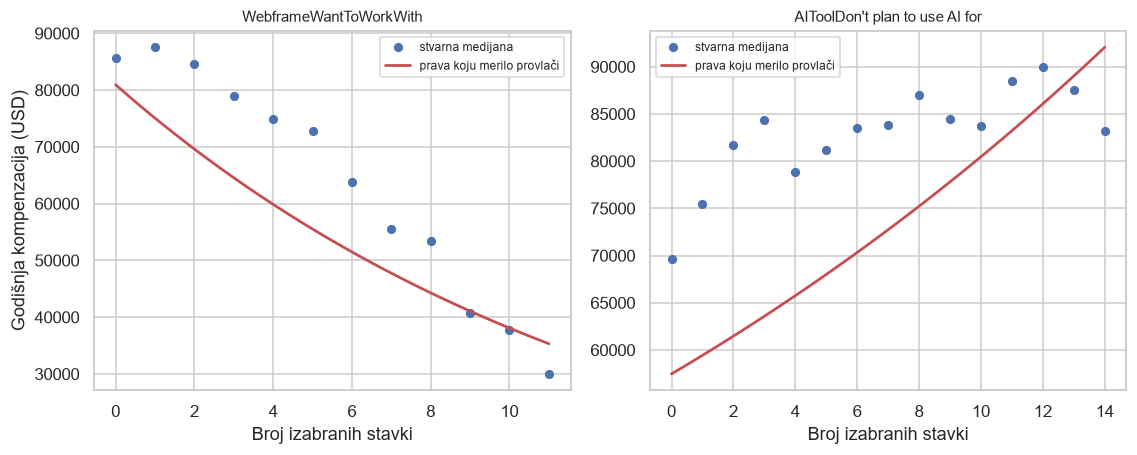

promenljiva                        opseg     prava  slobodno  medijana plate
WebframeWantToWorkWith             0-11     0.0243    0.0309    30,000 ->   87,550 USD
AIToolDon't plan to use AI for     0-14     0.0166    0.0208    69,609 ->   90,000 USD
WebframeAdmired                    0-8      0.0114    0.0184    51,071 ->   84,199 USD
DatabaseWantToWorkWith             0-10     0.0094    0.0104    48,554 ->   86,895 USD


In [101]:
strongest = [c for c in measured.index if c.startswith(COUNT_PREFIX)][:2]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
for ax, column in zip(axes, strongest):
    grouped = train.groupby(column)[TARGET_LOG].agg(["median", "size"])
    # A point standing on a handful of people would only add noise.
    grouped = grouped[grouped["size"] >= 30]
    ax.plot(grouped.index, 10 ** grouped["median"], marker="o", markersize=5,
            linewidth=0, color="#4C72B0", label="stvarna medijana")

    # The straight line the measure fits, brought back from logarithm to dollars.
    line = sm.OLS(train[TARGET_LOG].to_numpy(),
                  sm.add_constant(train[[column]].astype(float).to_numpy())).fit()
    grid = np.linspace(grouped.index.min(), grouped.index.max(), 60)
    ax.plot(grid, 10 ** (line.params[0] + line.params[1] * grid),
            color="#C44E52", linewidth=1.8, label="prava koju merilo provlači")

    ax.set_title(column.replace(COUNT_PREFIX, "")[:30], fontsize=10)
    ax.set_xlabel("Broj izabranih stavki")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Godišnja kompenzacija (USD)")
plt.tight_layout()
plt.show()

print(f"{'promenljiva':<32} {'opseg':>7}  {'prava':>8} {'slobodno':>9}  medijana plate")
for column in [c for c in measured.index if c.startswith(COUNT_PREFIX)][:4]:
    grouped = train.groupby(column)[TARGET].agg(["median", "size"])
    grouped = grouped[grouped["size"] >= 30]
    # Adjusted, so the free version is charged for the columns it uses.
    straight = signal(train[column])["R2_prilag"]
    free = signal(train[column].astype(int).astype(str))["R2_prilag"]
    print(f"{column.replace(COUNT_PREFIX, '')[:31]:<32} "
          f"{int(grouped.index.min()):>3}-{int(grouped.index.max()):<3}  "
          f"{straight:>8.4f} {free:>9.4f}  "
          f"{grouped['median'].min():>8,.0f} -> {grouped['median'].max():>8,.0f} USD")

**Zapažanje:** kod `WebframeWantToWorkWith` medijana plate ide od **30.000 do 87.550 dolara**, dakle
gotovo trostruko, dok se broj izabranih stavki kreće od 0 do 11. Kod `AITool` je razlika mnogo manja, od
69.609 do 90.000.

Brojevi pored grafika mere i nešto što se sa slike samo naslućuje. Ako broj stavki uđe u regresiju kao
**prava**, `WebframeWantToWorkWith` dobija prilagođeni R² od **0,0243**; ako se svakom broju dozvoli
sopstveni nivo, dakle ako se dopusti bilo kakav oblik, dobija **0,0309**. Kod `WebframeAdmired` je razlika
još veća, 0,0114 naspram 0,0184.

**Tumačenje:** veza postoji, ali **nije prava linija**. Slobodni oblik dobija osetno više i pošto je
poređenje na prilagođenom R², to nije posledica većeg broja kolona nego stvarne zakrivljenosti.

Za nas to znači dve stvari. Prva: naše merilo ove promenljive **potcenjuje**, jer meri koliko ih dobro
opisuje prava. Vrednosti iz 27.2 su zato donja granica, a ne tačna mera. Druga: u fazi modelovanja ovim
promenljivima treba pristupiti drugačije nego kao običnom broju — polinomskim članom ili grupisanjem u
kategorije, oba postupka sa predavanja. Ovde to ne radimo, jer bi značilo da za svaku od 36 promenljivih
biramo oblik prema tome kako ispadne.

### 27.3 Hipoteza 6 — nose li brojevi nešto što zemlja i staž već ne nose

Do sada smo merili šta promenljiva nosi **sama**. To nije dovoljno za odluku, i razlog je konkretan:
programer u Sjedinjenim Državama verovatno koristi više alata **i** zarađuje više od programera u
Pakistanu, ali ne zato što alati donose platu, nego zato što oboje prati zemlju. Ako je tako, brojačke
promenljive bi merile zemlju zaobilaznim putem, a zemlju već imamo.

Zato ih merimo i **pored** onoga što je najjače: zemlje i staža. Poređenje radimo F-testom, jer je manji
model sadržan u većem — isti test koji smo na predavanjima učili za poređenje modela.

**Prvo moramo da znamo šta je ovde „mnogo".** Granicu od 0,0286 iz odeljka 25.4 ovde **ne smemo** koristiti,
iako bi bilo primamljivo. Ona je izmerena kao prilagođeni R² koji `RemoteWork` dobija **sam**, a sada
merimo nešto drugo — koliko se model popravi kada se promenljiva **doda na već postojeći**. To su dve
različite veličine i ne porede se: obeležje može samo za sebe objašnjavati dosta, a pored zemlje ne dodati
skoro ništa, jer je zemlja to već objasnila.

Zato skalu kalibrišemo isto kao u 25.2 — merenjem onoga za šta znamo da vredi. Za svako anketno obeležje
gledamo koliko **dodaje** na istu osnovu, pa tek onda postavljamo kriterijum.

In [102]:
# The two strongest survey features from section 2, used as the model every
# new variable has to improve on.
BASE = ["Country", "WorkExp"]
base_model, _ = fit_together(BASE)
print(f"osnova ({' + '.join(BASE)}): R2={base_model.rsquared:.4f}   "
      f"prilagođeni={base_model.rsquared_adj:.4f}")
print()
print("koliko svako anketno obeležje DODAJE na tu osnovu:")
added = {}
for name in [c for c in REFERENCE if c not in BASE]:
    model, _ = fit_together(BASE + [name])
    added[name] = model.rsquared_adj - base_model.rsquared_adj
    print(f"  {name:<12} {added[name]:+.4f}"
          f"   (samo za sebe: {reference_table.loc[name, 'R2_prilag']:.4f})")

typical_gain = float(np.median(list(added.values())))
print()
print(f"tipičan prirast anketnog obeležja (medijana): {typical_gain:+.4f}")

osnova (Country + WorkExp): R2=0.5850   prilagođeni=0.5809

koliko svako anketno obeležje DODAJE na tu osnovu:


  DevType      +0.0131   (samo za sebe: 0.0312)


  OrgSize      +0.0140   (samo za sebe: 0.0442)


  EdLevel      +0.0048   (samo za sebe: 0.0068)


  Age          +0.0299   (samo za sebe: 0.1564)


  RemoteWork   +0.0097   (samo za sebe: 0.0286)


  Employment   +0.0008   (samo za sebe: 0.0003)


  YearsCode    +0.0018   (samo za sebe: 0.1481)


  JobSat       +0.0025   (samo za sebe: 0.0066)

tipičan prirast anketnog obeležja (medijana): +0.0072


**Zapažanje:** prirast je **mnogo manji** od samostalne vrednosti, kod svakog obeležja. `RemoteWork` sam
za sebe dobija prilagođeni R² od 0,0286, a **pored zemlje i staža dodaje svega +0,0097**. `OrgSize` sa
0,0442 dodaje +0,0140. Jedino `Age` dodaje više od svoje granice iz 2.4.

**Tumačenje:** ovo potvrđuje da granica iz 25.4 ovde ne bi bila samo stroga nego **pogrešna** — merila bi
jedno merilom drugog. Razlog je što zemlja objašnjava toliko da veći deo onoga što obeležja nose sama
bude već pokriven. `RemoteWork` sam za sebe hvata i to što se u bogatijim zemljama češće radi na daljinu;
pored zemlje mu od toga ne ostaje ništa.

Tipičan prirast anketnog obeležja na ovu osnovu je **+0,0072**, i to je skala na kojoj se meri i naš
dodatak. Kriterijum zato postavljamo ovako:

> **Hipoteza:** broj izabranih stavki nosi informaciju o plati koju zemlja i radni staž ne nose.
>
> **Kriterijum:** hipoteza je potvrđena ako dodavanje brojačkih promenljivih modelu koji već sadrži
> `Country` i `WorkExp` daje **značajno poboljšanje na pragu 0,05** po F-testu, **i** ako je prirast
> prilagođenog R² bar toliki koliki dodaje tipično anketno obeležje na istu osnovu. Značajnost sama nije
> dovoljna, jer pri 14.608 redova i beznačajno poboljšanje ispada značajno.

In [103]:
count_columns = [c for c in new_features.columns if c.startswith(COUNT_PREFIX)]
kept_columns = [c for c in new_features.columns if c.startswith(KEPT_PREFIX)]

for label, names in [("zemlja i staž", BASE),
                     ("+ svi brojevi", BASE + count_columns),
                     ("+ brojevi i odnosi", BASE + count_columns + kept_columns)]:
    model, columns = fit_together(names)
    print(f"{label:<22} R2={model.rsquared:.4f}   prilagođeni={model.rsquared_adj:.4f}   "
          f"kolona={columns:>3}")

with_counts, _ = fit_together(BASE + count_columns)
f_stat, p_value, df_diff = with_counts.compare_f_test(base_model)
gain = with_counts.rsquared_adj - base_model.rsquared_adj

print()
print(f"F-test za dodatih {int(df_diff)} kolona:  F = {f_stat:.2f}   p = {format_p(p_value)}")
print(f"prirast prilagođenog R²:        {gain:+.4f}")
print(f"tipičan prirast anketnog obeležja: {typical_gain:+.4f}")
print()
print(f"značajno na pragu 0,05:         {bool(p_value < 0.05)}")
print(f"prirast bar kao tipično obeležje: {bool(gain >= typical_gain)}")
with_ratios, _ = fit_together(BASE + count_columns + kept_columns)
print(f"odnosi zadržanog dodaju povrh brojeva:            "
      f"{with_ratios.rsquared_adj - with_counts.rsquared_adj:+.4f}")
print()
better = [name for name, value in added.items() if value < gain]
print(f"anketnih obeležja koja dodaju manje od brojeva: {len(better)} od {len(added)}  {sorted(better)}")

zemlja i staž          R2=0.5850   prilagođeni=0.5809   kolona=142


+ svi brojevi          R2=0.6027   prilagođeni=0.5978   kolona=178


+ brojevi i odnosi     R2=0.6043   prilagođeni=0.5992   kolona=185



F-test za dodatih 36 kolona:  F = 17.92   p = 5.7e-110
prirast prilagođenog R²:        +0.0169
tipičan prirast anketnog obeležja: +0.0072

značajno na pragu 0,05:         True
prirast bar kao tipično obeležje: True


odnosi zadržanog dodaju povrh brojeva:            +0.0014

anketnih obeležja koja dodaju manje od brojeva: 7 od 8  ['DevType', 'EdLevel', 'Employment', 'JobSat', 'OrgSize', 'RemoteWork', 'YearsCode']


**Zapažanje:** dodavanje 36 brojačkih promenljivih na model sa zemljom i stažom podiže prilagođeni R² sa
**0,5809 na 0,5978**, dakle za **+0,0169**. F-test daje **F = 17,92** uz p reda 10⁻¹¹⁰. Tipičan prirast
anketnog obeležja na istu osnovu je **+0,0072**, pa su oba dela kriterijuma ispunjena.

Poslednji red ispisa to stavlja u odnos: brojačke promenljive zajedno dodaju **više nego sedam od osam**
anketnih obeležja — više od veličine firme, tipa posla, načina rada, obrazovanja, zadovoljstva poslom,
oblika zaposlenja i godina programiranja. Jedino uzrast dodaje više.

Odnosi zadržanog, dodati povrh svega, podižu prilagođeni R² sa 0,5978 na **0,5992**, dakle za još 0,0014.

**Verdikt: hipoteza je potvrđena.** Broj izabranih stavki nosi informaciju koju zemlja i staž ne nose.

**Tumačenje:** rezultat je zanimljiv baš zato što se ne slaže sa onim iz 4.2. Tamo nijedna promenljiva
nije prešla granicu od 0,0286, a ovde ih 36 zajedno dodaje više nego skoro svako anketno pitanje.
Objašnjenje je isto ono iz 25.3 — promenljive se dopunjuju. Broj web-frejmvorka koje neko želi i broj baza
koje koristi ne govore o istoj stvari, pa se ono što svaka od njih nosi ne poništava nego sabira.

Ovo je usput i najuverljiviji primer zašto samostalno merenje ostaje **sito, a ne rangiranje**. Da smo posle
27.2 zaključili „nijedna ne prelazi granicu, pa nijednu ne uzimamo", izbacili bismo skup promenljivih koji
modelu daje više od šest anketnih pitanja zajedno.

**Odluka:** svih 36 brojačkih promenljivih i 17 indikatora ulazi dalje. Odnosi zadržanog se zadržavaju
uslovno — dodaju malo (0,0014), ali koštaju svega sedam kolona i mere nešto što nijedna druga promenljiva
ne meri, pa ostaju uz zabelešku da su slabi. Konačnu reč o svima njima ima formalna selekcija u fazi
modelovanja.

### 27.4 Šta od svega zadržavamo

Do sada smo pravili i merili. Sada popisujemo šta ostaje, jer se to iz prethodnih odeljaka ne vidi samo
po sebi.

Podelu poslova držimo doslednom kroz ceo ovaj deo: **ovde izbacujemo samo ono za šta smo izmerili da je
šum**, a konačan izbor promenljivih radi se u modelovanju, formalnom selekcijom sa predavanja. Razlog je
onaj iz 25.3 — samostalno merenje potcenjuje promenljive koje rade zajedno, pa nije merilo za rangiranje,
nego samo za odbacivanje najgoreg.

Ostaju dve odluke, i obe rešavamo merenjem, ne rečima.

**Prva: šta sa promenljivama koje su po pravilu iz 25.4 šum?** Pravilo kaže da se takve ne prave. Ali
pošto smo u 27.3 videli da zajedno rade više nego pojedinačno, ne izbacujemo ih dok ne izmerimo koliko
njihovo izbacivanje zaista košta.

**Druga: da li da ispravimo zakrivljenost koju smo videli u Grafiku 20?** Sa predavanja znamo polinomsku
regresiju — dodavanje kvadrata promenljive kao još jedne kolone. To bismo primenili **na sve brojačke
promenljive odjednom**, po istom pravilu, da ne bismo oblik birali promenljivoj po promenljivoj prema
tome kako ispadne. Da li se isplati, meri se istim kriterijumom kao u 27.3: prirast se poredi sa onim što
tipično anketno obeležje dodaje na istu osnovu.

In [104]:
noise_features = list(band[band == "šum"].index)
kept_new_columns = [c for c in new_features.columns if c not in noise_features]

print(f"po pravilu iz 25.4 kao šum je označeno {len(noise_features)} od {len(new_features.columns)}:")
for prefix in (COUNT_PREFIX, ANSWERED_PREFIX, KEPT_PREFIX):
    print(f"  {prefix:<14} {sum(c.startswith(prefix) for c in noise_features):>2}")
print()

with_all, _ = fit_together(BASE + list(new_features.columns))
with_kept, _ = fit_together(BASE + kept_new_columns)
print(f"model sa svih {len(new_features.columns)} novih:   prilagođeni={with_all.rsquared_adj:.4f}")
print(f"model bez {len(noise_features)} označenih kao šum: prilagođeni={with_kept.rsquared_adj:.4f}")
print(f"cena izbacivanja:                 {with_kept.rsquared_adj - with_all.rsquared_adj:+.5f}")
print()

# The same polynomial term for every count column, so the shape is not chosen
# variable by variable according to how it turns out.
squares = pd.DataFrame({c + "_sq": train[c].astype(float) ** 2 for c in count_columns},
                       index=train.index)
linear_only, _ = fit_together(BASE + count_columns)
design = pd.concat([pd.get_dummies(train["Country"].astype(str), prefix="Country",
                                   drop_first=True, dtype=float),
                    train[["WorkExp"] + count_columns].astype(float), squares], axis=1)
with_squares = sm.OLS(train[TARGET_LOG].to_numpy(),
                      sm.add_constant(design).to_numpy()).fit()
f_stat, p_value, df_diff = with_squares.compare_f_test(linear_only)

print(f"+ kvadratni član za svaku od {len(count_columns)}:  prilagođeni={with_squares.rsquared_adj:.4f}")
print(f"prirast preko linearnih:          {with_squares.rsquared_adj - linear_only.rsquared_adj:+.4f}")
print(f"F-test: F = {f_stat:.2f}   p = {format_p(p_value)}   (dodato {int(df_diff)} kolona)")
print(f"tipičan prirast anketnog obeležja: {typical_gain:+.4f}")
print(f"prirast bar kao tipično obeležje:  "
      f"{bool(with_squares.rsquared_adj - linear_only.rsquared_adj >= typical_gain)}")
print()

train = train.drop(columns=noise_features)
# The name lists follow the drop, so later sections work with what remains.
count_columns = [c for c in count_columns if c not in noise_features]
kept_columns = [c for c in kept_columns if c not in noise_features]
print(f"izbačeno kolona: {len(noise_features)}")
for prefix in (COUNT_PREFIX, ANSWERED_PREFIX, KEPT_PREFIX):
    made = sum(c.startswith(prefix) for c in new_features.columns)
    kept = sum(c.startswith(prefix) for c in kept_new_columns)
    print(f"  {prefix:<14} napravljeno {made:>2}, zadržano {kept:>2}")
print(f"kolona u skupu na kraju sekcije: {train.shape[1]}   "
      f"({train.shape[1] - 2} prediktora, ciljna promenljiva i njen logaritam)")

po pravilu iz 25.4 kao šum je označeno 12 od 60:
  Count_          9
  NotAnswered_    3
  KeptShare_      0



model sa svih 60 novih:   prilagođeni=0.6082
model bez 12 označenih kao šum: prilagođeni=0.6072
cena izbacivanja:                 -0.00104



+ kvadratni član za svaku od 36:  prilagođeni=0.6004
prirast preko linearnih:          +0.0026
F-test: F = 3.62   p = 1.5e-12   (dodato 36 kolona)
tipičan prirast anketnog obeležja: +0.0072
prirast bar kao tipično obeležje:  False

izbačeno kolona: 12
  Count_         napravljeno 36, zadržano 27
  NotAnswered_   napravljeno 17, zadržano 14
  KeptShare_     napravljeno  7, zadržano  7
kolona u skupu na kraju sekcije: 178   (176 prediktora, ciljna promenljiva i njen logaritam)


**Zapažanje:** po pravilu iz 25.4 kao šum je označeno **12 od 60** novih kolona — devet brojačkih i tri
indikatora, dok nijedan odnos zadržanog nije pao ispod poda.

Njihovo izbacivanje košta **0,00104** prilagođenog R², dakle model pada sa 0,6082 na 0,6072.

Kvadratni članovi, dodati za svih 36 brojačkih promenljivih odjednom, podižu prilagođeni R² sa 0,5978 na
**0,6004**, dakle za **+0,0026**. F-test je značajan (p reda 10⁻¹²), ali je prirast **manji od 0,0072**,
koliko tipično dodaje anketno obeležje.

**Tumačenje i odluke.**

**Dvanaest kolona izbacujemo.** Cena je hiljaditi deo prilagođenog R², a dobija se dvanaest kolona manje
u modelu koji ih ionako ima previše. Ovo je jedini korak u sekciji u kome nešto zaista uklanjamo, i
radimo ga po pravilu koje je postavljeno pre nego što smo išta izmerili.

**Kvadratne članove ne uzimamo.** Ovde je vredelo izmeriti umesto pretpostaviti: zakrivljenost koju smo
videli u Grafiku 20 je stvarna i F-test je potvrđuje, ali je ono što se time dobija manje od onoga što
donese jedno prosečno anketno pitanje — a plaća se sa 36 dodatnih kolona. Po istom kriterijumu po kom
smo u 27.3 prihvatili brojeve, ovde ga polinom ne prolazi.

To ne znači da je zakrivljenost nevažna, nego da je jednostavno kvadriranje pogrešan alat za nju. U fazi
modelovanja postoje bolji: Ridge i Lasso, koji cenu dodatnih kolona rešavaju regularizacijom umesto da je
plaćaju u prilagođenom R². Tamo se ovo može ponovo probati, sa merilom koje je za to napravljeno.

Ostaje **48 novih kolona**, pa skup ima 178 ukupno — 176 prediktora, ciljna promenljiva i njen logaritam.

### Šta sekcija ostavlja sledećoj

Skup je narastao sa 130 na **178 kolona**: napravljeno je 60 novih, a 12 izbačeno kao šum.

| prefiks | napravljeno | zadržano |
| --- | --- | --- |
| `Count_` | 36 | 27 |
| `NotAnswered_` | 17 | 14 |
| `KeptShare_` | 7 | 7 |
| **ukupno** | **60** | **48** |

Četiri nalaza se prenose dalje:

- **pojedinačno su slabe, zajedno nisu.** Nijedna ne prelazi granicu iz 25.4 sama, a zajedno dodaju
  +0,0169 na model sa zemljom i stažom — više od sedam od osam anketnih obeležja;
- **veza nije prava linija**, pa naše merilo ove promenljive potcenjuje. Kvadratni član to ne rešava
  dovoljno da bi se isplatio, ali Ridge i Lasso u modelovanju mogu;
- **indikatori neodgovaranja su jači od očekivanog**, jači i od većine brojeva, što potvrđuje nalaz iz
  prethodnog dela da preskakanje pitanja nije slučajno;
- **odnos zadržanog je slab ali čist** — nijedan nije pao u šum, i meri nešto što nijedna druga
  promenljiva ne meri.

Ono što ovde nije obuhvaćeno jeste **koje** su stavke izabrane. Dvoje ljudi sa po tri jezika ovde imaju
istu vrednost, bez obzira na to da li su to Python i SQL ili Cobol i Perl. Time se bavi sledeća sekcija.

## 28. Pojedinačne stavke kao kolone

Prethodna sekcija je merila **koliko** je stavki izabrano. Ovde merimo **koje**. Dvoje ljudi sa po tri
jezika u sekciji 27 imaju istu vrednost, bez obzira na to da li su to Python i SQL ili Cobol i Perl — a ta
razlika bi mogla da bude ono što plata zapravo prati.

Podsetnik odakle krećemo, jer je od toga prošlo dosta: skup ima **178 kolona**, a među njima je **36
multi-select kolona** — onih u kojima je više odgovora spojeno tačka-zarezom. To su iste one kolone iz
kojih je sekcija 27 izvela brojeve; njihov sadržaj je i dalje netaknut string.

Postupak je jednostavan: za svaku ponuđenu stavku pravimo kolonu koja je **1 ako ju je ispitanik izabrao,
inače 0**. To je isto dummy enkodiranje koje smo učili na predavanjima, samo primenjeno na odgovor koji
dozvoljava više izbora odjednom.

### 28.1 Od čega pravimo kolone po stavci

Tri odluke pre nego što počnemo.

**Iz kojih kolona.** Kolone `Admired` izostavljamo, jer je Hipoteza 5 pokazala da su presek druge dve —
kolona „divi se Pythonu" bila bi tačno određena kolonama „koristi Python" i „želi Python", pa bi u model
unela kolinearnost umesto informacije. Od 36 multi-select kolona ostaje **29**.

**Šta sa onima koji nisu odgovorili.** Kolona kaže da li je ispitanik izabrao tu stavku; ko na pitanje
nije odgovorio, nije je izabrao, pa upisujemo 0. Podatak da pitanje nije odgovoreno nije izgubljen — nose
ga indikatori `NotAnswered_` iz sekcije 27.

**Kako se kolone zovu.** Ime je `Chose_<izvorna kolona>__<stavka>`, na engleskom, sa razmakom i
interpunkcijom svedenim na donju crtu. Simbole koji bi se izgubili prevodimo u reč, jer bi inače `C`,
`C#` i `C++` dali isto ime; da se to zaista ne dešava, kod proverava i ispisuje.

Jedna stvar oko brojanja, da ne bi bilo zabune: nova kolona se pravi za **svaki par kolone i stavke**, ne
za svaku stavku. `Python` se javlja i u `LanguageHaveWorkedWith` i u `LanguageWantToWorkWith`, i to su dve
različite činjenice — koristi ga, odnosno želi da ga koristi — pa daje **dve** kolone.

In [105]:
# Symbols that would vanish in a plain clean-up and take a distinction with them:
# without this, C, C# and C++ all become the same column name.
SYMBOLS = {"#": "sharp", "+": "plus", "&": "and"}
ITEM_PREFIX = "Chose_"


def clean_name(text, limit=34):
    """A survey label turned into something usable as a column name."""
    for symbol, word in SYMBOLS.items():
        text = text.replace(symbol, word)
    return re.sub(r"_+", "_", re.sub(r"[^A-Za-z0-9]+", "_", text)).strip("_")[:limit].strip("_")


# Admired columns are the intersection of the other two (hypothesis 5), so an
# indicator built from them would be determined by indicators we already have.
item_sources = [c for c in multi_select if not c.endswith("Admired")]

item_columns = {}
for column in item_sources:
    chosen = train[column].fillna("").astype(str).map(lambda value: set(value.split(";")) - {""})
    for item in sorted(set().union(*chosen)):
        name = f"{ITEM_PREFIX}{clean_name(column, 40)}__{clean_name(item)}"
        item_columns[name] = chosen.map(lambda picked, i=item: float(i in picked))

items = pd.DataFrame(item_columns, index=train.index)

print(f"izvornih kolona: {len(item_sources)}   (od {len(multi_select)}, bez sedam `Admired`)")
print(f"kandidat-kolona po stavci: {items.shape[1]}")
print(f"sva imena jedinstvena: {items.shape[1] == len(set(items.columns))}")
print(f"vrednosti koje se javljaju: {sorted(pd.unique(items.to_numpy().ravel()))}")
print()
print("odakle taj broj — po jedna kolona za svaki par (izvorna kolona, stavka):")
for column in sorted(item_sources, key=lambda c: -len(vocabulary[c]))[:4]:
    print(f"  {column:<34} {len(vocabulary[column]):>3} stavki")
print(f"  ... zbir preko svih {len(item_sources)} kolona: {sum(len(vocabulary[c]) for c in item_sources)}")
print(f"različitih tekstova stavki, bez obzira na kolonu: "
      f"{len(set().union(*(vocabulary[c] for c in item_sources)))}")
print()
print(f"redova po jednoj kandidat-koloni: {len(train) / items.shape[1]:.0f}")
print()
print("primer, jezici jednog ispitanika:")
example = [c for c in items.columns if c.startswith("Chose_LanguageHaveWorkedWith")][:6]
print(items.loc[[4], example].T.to_string(header=["ispitanik 4"]))

izvornih kolona: 29   (od 36, bez sedam `Admired`)
kandidat-kolona po stavci: 609
sva imena jedinstvena: True
vrednosti koje se javljaju: [np.float64(0.0), np.float64(1.0)]

odakle taj broj — po jedna kolona za svaki par (izvorna kolona, stavka):
  LanguageHaveWorkedWith              42 stavki
  LanguageWantToWorkWith              42 stavki
  PlatformHaveWorkedWith              42 stavki
  PlatformWantToWorkWith              42 stavki
  ... zbir preko svih 29 kolona: 609
različitih tekstova stavki, bez obzira na kolonu: 323

redova po jednoj kandidat-koloni: 24

primer, jezici jednog ispitanika:
                                                    ispitanik 4
Chose_LanguageHaveWorkedWith__Ada                           0.0
Chose_LanguageHaveWorkedWith__Assembly                      0.0
Chose_LanguageHaveWorkedWith__Bash_Shell_all_shells         1.0
Chose_LanguageHaveWorkedWith__C                             0.0
Chose_LanguageHaveWorkedWith__Csharp                        0.0
Chose_Languag

**Zapažanje:** iz 29 izvornih kolona nastalo je **609 kandidat-kolona**, sve sa jedinstvenim imenom i sve
sa samo dve vrednosti, 0 i 1.

Drugi deo ispisa pokazuje odakle taj broj. Najveće doprinose daju `LanguageHaveWorkedWith` i
`LanguageWantToWorkWith`, sa po 42 stavke, pa `PlatformHaveWorkedWith` i `PlatformWantToWorkWith`, takođe
sa po 42. Zbir preko svih 29 kolona je 609 — a **različitih tekstova stavki, bez obzira na kolonu, ima
svega 323**. Razlika je u tome što se ista stavka javlja u više kolona: `Python` daje jednu kolonu za
„koristi" i drugu za „želi".

Primer pokazuje kako to izgleda kod jednog ispitanika: od prikazanih šest jezika ima jedinicu samo kod
`Bash_Shell_all_shells`, a nule svuda drugde.

**Tumačenje:** 609 kolona na 14.608 redova je odnos koji zabrinjava. Poslednji red ispisa ga daje u
brojkama: **na jednu kandidat-kolonu dolazi 24 reda**. Nije nemoguće raditi sa tim, ali je daleko od
udobnog — što je model bliži tome da ima koliko kolona koliko i redova, to lakše nauči slučajne razlike
umesto stvarnih, a to je kraj bias-variance krive na kom varijansa preuzima sve. Uz to ovih 609 dolazi
povrh 178 kolona koje već imamo.

Zato ih ne uzimamo sve. Ostatak sekcije je o tome kako se odlučuje koje ostaju, i taj postupak je važniji
od samog rezultata: svaki prag koji ovde postavimo mora da bude izmeren, jer ih ima previše da bi se o
svakoj koloni odlučivalo pojedinačno.

### 28.2 Prvi pokušaj: prag po zastupljenosti

609 kolona na 14.608 redova je mnogo, pa je prva pomisao da se odbace stavke koje bira malo ljudi.
Zastupljenost stavke je udeo ispitanika koji su je izabrali — `Python` u koloni „koristi" ima
zastupljenost od koliko procenata ispitanika ga je označilo. Kolona koja je jedinica kod dvadesetak ljudi
deluje kao nešto što ne može ništa da nauči.

Takav prag, međutim, ne smemo da izaberemo nego moramo da ga **izvedemo**. Tražimo isto što i u
prethodnom delu kod nedostajućih vrednosti: mesto gde poređani niz sam pravi prekid, pa granicu
postavljamo tu.

In [106]:
item_share = (items.mean() * 100).sort_values()
jumps = item_share.diff()

print("koliki udeo ispitanika je izabrao stavku, i koliko je takvih stavki:")
print(f"  {'udeo ispitanika':>18}   {'kolona':>6}")
bands = [(0, 0.5), (0.5, 1), (1, 2), (2, 5), (5, 10), (10, 101)]
for low, high in bands:
    inside = (item_share >= low) & (item_share < high)
    print(f"  {low:>7.1f} - {min(high, 100):>5.1f}%   {int(inside.sum()):>6}")
print()
print("najveći skokovi u poređanom nizu:")
for name in jumps.nlargest(4).index:
    place = list(item_share.index).index(name)
    print(f"  sa {item_share[name] - jumps[name]:>5.2f}% na {item_share[name]:>5.2f}%   "
          f"(skok {jumps[name]:.2f} pp, na {place}. mestu od {len(item_share)})")
print()
print("koliko bi kolona ostalo kad bismo prag postavili na razne vrednosti:")
for limit in [0.5, 1, 2, 5, 10]:
    print(f"  odbaci stavke ispod {limit:>4}% : ostaje {int((item_share >= limit).sum()):>4} od {len(item_share)}")

koliki udeo ispitanika je izabrao stavku, i koliko je takvih stavki:
     udeo ispitanika   kolona
      0.0 -   0.5%       11
      0.5 -   1.0%       37
      1.0 -   2.0%       52
      2.0 -   5.0%      134
      5.0 -  10.0%      112
     10.0 - 100.0%      263

najveći skokovi u poređanom nizu:
  sa 72.62% na 77.23%   (skok 4.61 pp, na 608. mestu od 609)
  sa 68.46% na 72.62%   (skok 4.16 pp, na 607. mestu od 609)
  sa 55.80% na 59.12%   (skok 3.32 pp, na 598. mestu od 609)
  sa 65.38% na 68.46%   (skok 3.08 pp, na 606. mestu od 609)

koliko bi kolona ostalo kad bismo prag postavili na razne vrednosti:
  odbaci stavke ispod  0.5% : ostaje  598 od 609
  odbaci stavke ispod    1% : ostaje  561 od 609
  odbaci stavke ispod    2% : ostaje  509 od 609
  odbaci stavke ispod    5% : ostaje  375 od 609
  odbaci stavke ispod   10% : ostaje  263 od 609


**Zapažanje:** raspodela je neravnomerna — **11 stavki bira manje od pola procenta** ispitanika, a 263
njih bira preko deset posto. Ali u poređanom nizu **prekida nema**: najveći skokovi su od tri do četiri i
po procentna poena, i svi su na samom **vrhu** niza, među stavkama koje bira preko 55% ispitanika.

Tamo gde bi prag imao smisla — među retkim stavkama, na dnu niza — skokova nema.

**Tumačenje:** ovo se razlikuje od onoga što smo videli u prethodnom delu kod nedostajućih
vrednosti, gde je niz imao jasan prelom pa se granica sama nametnula. Ovde niz raste glatko, pa **svaki
prag koji bismo postavili bio bi naš izbor, a ne nalaz iz podataka** — a razlika između praga od 2% i 5%
nije mala: 509 kolona naspram 375.

Pošto podaci granicu ne nude, ne smemo je izmisliti. Ostaje da proverimo da li nam je uopšte potrebna.

### Grafik 21 — poređani niz zastupljenosti

**Motivacija:** brojevi kažu koliko je stavki u kom opsegu, ali ne i da li niz negde pravi prelom. U
prethodnom delu je isti ovakav niz, kod nedostajućih vrednosti, imao jasan skok od 9,3 procentna
poena i granica se sama nametnula. Crtamo isti prikaz ovde da vidimo da li se to ponavlja.

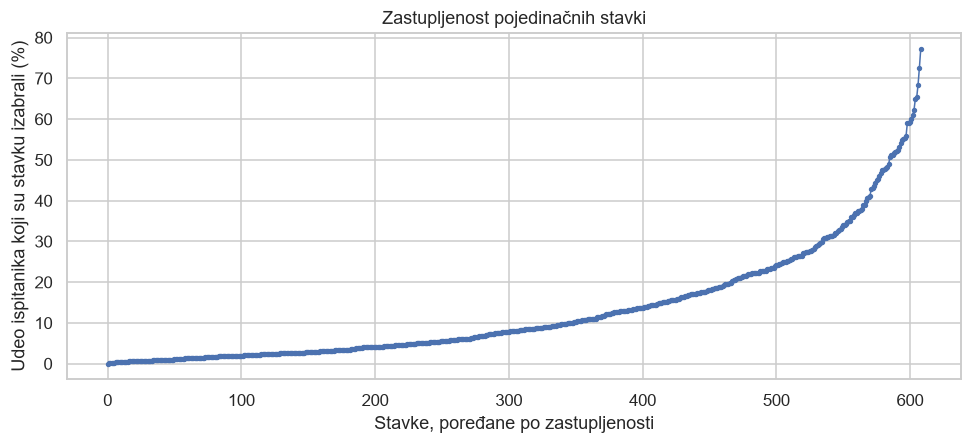

najveći skok u celom nizu: 4.61 procentna poena
i to na 608. mestu od 609, kod stavki koje bira 77% ispitanika


In [107]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(range(len(item_share)), item_share.values, marker="o", markersize=2.5,
        linewidth=1, color="#4C72B0")

ax.set_xlabel("Stavke, poređane po zastupljenosti")
ax.set_ylabel("Udeo ispitanika koji su stavku izabrali (%)")
ax.set_title("Zastupljenost pojedinačnih stavki")
plt.tight_layout()
plt.show()

print(f"najveći skok u celom nizu: {jumps.max():.2f} procentna poena")
print(f"i to na {list(item_share.index).index(jumps.idxmax())}. mestu od {len(item_share)}, "
      f"kod stavki koje bira {item_share[jumps.idxmax()]:.0f}% ispitanika")

**Zapažanje:** kriva raste glatko, bez preloma. Najveći skok u celom nizu iznosi **4,61 procentna poena**
i nalazi se pri samom vrhu, kod stavki koje bira preko sedamdeset posto ispitanika.

**Tumačenje:** grafik potvrđuje ono što je tabela nagovestila i zatvara taj put. Kad bismo prag postavili
na mestu najvećeg skoka, izbacili bismo **sve osim najčešćih stavki**, što je suprotno od onoga što smo
hteli. Prekid postoji, ali na pogrešnom kraju skale.

Zaključak je da granica po zastupljenosti u ovim podacima nema uporište. To ne znači da praga ne treba
da bude — znači da ga treba tražiti negde drugde.

### 28.3 Da li je retkost uopšte problem

Kad prekida nema, pravilo ne smemo da izmislimo. Ali vredi se vratiti korak nazad i pitati **zašto** smo
prag po zastupljenosti uopšte hteli.

Strah je bio da retka kolona lakše ispadne značajna slučajno — da se kod dvadeset jedinica lakše nađe
obrazac kog nema, nego kod hiljadu. Da li je to tako, ne treba pretpostavljati nego izmeriti, i to isto
kao u odeljku 25.1.

Postupak: za osam nivoa zastupljenosti, od četvrtine procenta do polovine uzorka, pravimo po **300
slučajnih kolona** sa tim udelom jedinica. Kolone su čista slučajnost i sa platom nemaju veze, pa je sve
što dobiju posledica slučaja. Za svaki nivo gledamo **dokle je najdalja od tih 300 stigla**. Ako slučajne
kolone sa malo jedinica stižu dalje od onih sa mnogo, retkost jeste problem i prag ima smisla.

In [108]:
from scipy import stats


def binary_signal(values):
    """Adjusted R² and F-test p for one binary column, without fitting a model.

    For a single predictor R² is the square of the correlation, which is the
    same number the regression would give but far cheaper over hundreds of
    columns.
    """
    n_rows = len(values)
    correlation = np.corrcoef(values, train[TARGET_LOG].to_numpy())[0, 1]
    r_squared = 0.0 if np.isnan(correlation) else correlation ** 2
    adjusted = 1 - (1 - r_squared) * (n_rows - 1) / (n_rows - 2)
    f_value = r_squared / (1 - r_squared) * (n_rows - 2) if r_squared < 1 else np.inf
    return adjusted, stats.f.sf(f_value, 1, n_rows - 2)


rng = np.random.default_rng(0)
n_rows = len(train)

print(f"{'udeo jedinica':>14} {'jedinica':>9} {'najveći adj R² od 300':>22}")
for share in [0.25, 0.5, 1, 2, 5, 10, 25, 50]:
    best = max(binary_signal((rng.random(n_rows) < share / 100).astype(float))[0]
               for _ in range(300))
    print(f"{share:>13.2f}% {int(round(n_rows * share / 100)):>9,} {best:>22.5f}")

 udeo jedinica  jedinica  najveći adj R² od 300
         0.25%        37                0.00057


         0.50%        73                0.00035
         1.00%       146                0.00056


         2.00%       292                0.00044
         5.00%       730                0.00053


        10.00%     1,461                0.00064
        25.00%     3,652                0.00047


        50.00%     7,304                0.00046


**Zapažanje:** dokle slučajnost stiže **ne zavisi od zastupljenosti**. Slučajna kolona sa 37 jedinica
dostiže prilagođeni R² od 0,00057, a ona sa 7.304 jedinice 0,00046 — praktično isto. Kroz ceo raspon,
od četvrtine procenta do polovine uzorka, vrednosti se drže oko pet do šest desethiljaditih delova.

**Tumačenje:** retkost, dakle, **ne daje koloni nezasluženu prednost**. Stavka koju bira dvadeset ljudi
nije ništa sklonija da slučajno ispadne značajna od stavke koju bira polovina uzorka.

To ruši razlog zbog kog smo prag po zastupljenosti uopšte razmatrali. Kolona sa malo jedinica jeste manje
pouzdana u smislu da se procena zasniva na manje ljudi, ali to merilo iz sekcije 25 već hvata: ako od tih
dvadeset ljudi ne izlazi nikakav obrazac, prilagođeni R² ostaje pri dnu i kolona pada.

Prag po zastupljenosti zato **ne uvodimo**. Ali to ne znači da nam prag uopšte ne treba, jer postoji drugi
problem koji do sada nije bio ozbiljan.

### 28.4 Prag koji zaista treba: 609 provera odjednom

Retkost, dakle, nije problem. Ali postoji drugi, koji smo do sada mogli da zanemarimo a sada ne možemo.

Do sada smo merili po nekoliko promenljivih odjednom. Sada ih merimo **609**. Prag značajnosti od 0,05
znači da svaka pojedinačna provera ima pet posto izgleda da prođe i kad veze nema — pa se pri šest stotina
provera i od čiste slučajnosti očekuje tridesetak prolaza. Ako uzmemo sve što prođe test, primili bismo i
njih, a ne bismo imali način da ih razlikujemo od pravih.

Ovo na predavanjima nismo radili, pa objašnjavamo šta radimo umesto toga. Ne menjamo test nego **podižemo
prag**, i to na nivo koji slučajnost pri ovom broju provera ne dostiže.

Postupak je sledeći. Napravimo **609 slučajnih kolona — tačno onoliko koliko imamo stvarnih kandidata — i
svakoj damo isti udeo jedinica kao odgovarajućoj stvarnoj koloni.** Time dobijamo skup koji je po obliku
istovetan našem, samo što u njemu nema nikakve veze sa platom. Propustimo ga kroz isto merilo i zabeležimo
**dokle je najdalja od tih 609 stigla** i koliko ih je prošlo test značajnosti. To ponovimo pet puta, sa
različitim slučajnim brojevima, da vidimo koliko je taj domet stabilan.

Prag je onda **najveći domet koji je slučajnost postigla u bilo kom od pet pokušaja**. Sve ispod toga je
nešto što bismo dobili i da podataka nema.

In [109]:
shares = items.mean().to_numpy()

# One full run of the whole screening on columns that hold nothing but noise,
# repeated so we can see how far chance reaches and how steady that reach is.
reaches, passed_test = [], []
for seed in range(1, 6):
    noise_rng = np.random.default_rng(seed)
    measured_noise = [binary_signal((noise_rng.random(n_rows) < share).astype(float))
                      for share in shares]
    reaches.append(max(a for a, _ in measured_noise))
    passed_test.append(sum(p < 0.05 for _, p in measured_noise))

print(f"{'pokušaj':>8} {'prošlo test p<0,05':>20} {'najveći adj R²':>16}")
for i, (count, reach) in enumerate(zip(passed_test, reaches), start=1):
    print(f"{i:>8} {count:>20} {reach:>16.5f}")
print()
print(f"očekivano po slučaju pri {len(shares)} provera i pragu 0,05: {0.05 * len(shares):.0f}")
print(f"dokle slučajnost stiže, u proseku:  {np.mean(reaches):.5f}")
print(f"najdalje u pet pokušaja:            {max(reaches):.5f}")

# The bar: the furthest chance got in any of the runs.
ITEM_LIMIT = float(max(reaches))
print()
print(f"prag za kolone po stavci: {ITEM_LIMIT:.5f}")

 pokušaj   prošlo test p<0,05   najveći adj R²
       1                   29          0.00086
       2                   29          0.00069
       3                   30          0.00078
       4                   23          0.00094
       5                   35          0.00080

očekivano po slučaju pri 609 provera i pragu 0,05: 30
dokle slučajnost stiže, u proseku:  0.00081
najdalje u pet pokušaja:            0.00094

prag za kolone po stavci: 0.00094


**Zapažanje:** u pet pokušaja je test značajnosti prošlo između **23 i 35 slučajnih kolona**, u proseku
oko trideset — tačno koliko se i očekuje pri 609 provera i pragu od 0,05. Nijedna od njih nije stigla
dalje od prilagođenog R² od **0,00094**, a prosek najdaljeg dometa je 0,00081.

**Tumačenje:** brojevi potvrđuju ono čega smo se plašili. Da smo uzeli sve što prođe test značajnosti,
primili bismo i tridesetak kolona koje sa platom nemaju nikakve veze — a ne bismo znali koje su.

Rešenje je da prag ne bude na p-vrednosti nego na **domet slučajnosti**: uzimamo samo kolone koje su
otišle dalje nego što je u pet pokušaja stigla ijedna slučajna kolona, dakle preko **0,00094**. Domet je
stabilan — kroz pet pokušaja se kreće između 0,00069 i 0,00094 — pa uzimamo najveći od njih, da budemo na
sigurnoj strani.

Ovo nije postupak sa predavanja, pa vredi reći šta jeste a šta nije. Nije nova vrsta testa — i dalje
tražimo p < 0,05. Jeste dodatni uslov, izmeren na isti način kao pod u odeljku 25.1, samo što se ovde
ponavlja onoliko puta koliko imamo kolona. Cena je što ćemo odbaciti i neke stvarne veze koje su slabe;
dobitak je što ono što ostane nije tridesetak nasumičnih kolona.

### 28.5 Hipoteza 7 — govori li *koje* stavke više nego *koliko* ih je

Sada imamo prag i možemo da izmerimo stvarne stavke. Ali glavno pitanje sekcije nije koliko ih prolazi,
nego da li uopšte vrede — jer već imamo brojeve iz sekcije 27, koji o istim tim kolonama govore na drugi
način.

Moguće je da je sve što stavke nose zapravo sadržano u broju izabranih stavki. Ko koristi Rust verovatno
koristi i mnogo drugih tehnologija, pa bi kolona „koristi Rust" mogla da bude samo zaobilazan način da se
kaže „koristi mnogo toga" — a to već imamo, u jednoj koloni umesto u tri stotine.

> **Hipoteza:** koje su stavke izabrane nosi informaciju o plati koju broj izabranih stavki ne nosi.
>
> **Kriterijum:** hipoteza je potvrđena ako dodavanje kolona po stavci na model koji već sadrži `Country`,
> `WorkExp` i sve brojeve iz sekcije 27 daje značajno poboljšanje na pragu 0,05 po F-testu, **i** ako je
> prirast prilagođenog R² bar toliki koliki tipično anketno obeležje dodaje na osnovu — istu meru koju smo
> izračunali u 4.3. Značajnost sama nije dovoljna, tim pre što sada dodajemo stotine kolona.

In [110]:
measured_items = pd.DataFrame(
    [binary_signal(items[column].to_numpy()) for column in items.columns],
    index=items.columns, columns=["R2_prilag", "p"])

kept_items = list(measured_items[(measured_items["R2_prilag"] > ITEM_LIMIT)
                                 & (measured_items["p"] < 0.05)].index)
print(f"kandidata:                        {len(measured_items)}")
print(f"prošlo test značajnosti:          {int((measured_items['p'] < 0.05).sum())}")
print(f"prošlo i podignuti prag:          {len(kept_items)}")
print()
print("deset najjačih pojedinačnih stavki:")
top = measured_items.loc[kept_items].nlargest(10, "R2_prilag")
print(pd.DataFrame({"R2_prilag": top["R2_prilag"].map(lambda v: f"{v:.5f}"),
                    "p": top["p"].map(format_p)}).to_string())
print()

base_model, base_columns = fit_together(BASE + count_columns)
country_dummies = pd.get_dummies(train["Country"].astype(str), prefix="Country",
                                 drop_first=True, dtype=float)
design = pd.concat([country_dummies, train[["WorkExp"] + count_columns].astype(float),
                    items[kept_items]], axis=1)
with_items = sm.OLS(train[TARGET_LOG].to_numpy(),
                    sm.add_constant(design).to_numpy()).fit()
f_stat, p_value, df_diff = with_items.compare_f_test(base_model)
gain = with_items.rsquared_adj - base_model.rsquared_adj

print(f"zemlja, staž i brojevi:           prilagođeni={base_model.rsquared_adj:.4f}   "
      f"kolona={base_columns}")
print(f"+ {len(kept_items)} kolona po stavci:          prilagođeni={with_items.rsquared_adj:.4f}   "
      f"kolona={int(with_items.df_model)}")
print()
print(f"prirast:                          {gain:+.4f}")
print(f"tipičan prirast anketnog obeležja: {typical_gain:+.4f}")
print(f"F-test: F = {f_stat:.2f}   p = {format_p(p_value)}   (dodato {int(df_diff)} kolona)")
print(f"oba dela kriterijuma ispunjena:   {bool(p_value < 0.05 and gain >= typical_gain)}")

kandidata:                        609
prošlo test značajnosti:          458
prošlo i podignuti prag:          305

deset najjačih pojedinačnih stavki:
                                                                     R2_prilag         p
Chose_AIToolDon_t_plan_to_use_AI_for_this_task__Project_planning       0.03294  1.3e-108
Chose_PlatformHaveWorkedWith__Terraform                                0.02700   3.8e-89
Chose_AIToolDon_t_plan_to_use_AI_for_this_task__Predictive_analytics   0.02642     3e-87
Chose_OfficeStackAsyncHaveWorkedWith__Confluence                       0.02497   1.5e-82
Chose_AIFrustration__I_ve_become_less_confident_in_my_o                0.02442     1e-80
Chose_LanguageHaveWorkedWith__Bash_Shell_all_shells                    0.02336   2.8e-77
Chose_OpSysProfessional_use__MacOS                                     0.02121   2.7e-70
Chose_LearnCode__School_i_e_University_College_etc                     0.02091   2.7e-69
Chose_PlatformHaveWorkedWith__Homebrew          

zemlja, staž i brojevi:           prilagođeni=0.5966   kolona=169
+ 305 kolona po stavci:          prilagođeni=0.6426   kolona=474

prirast:                          +0.0460
tipičan prirast anketnog obeležja: +0.0072
F-test: F = 7.09   p = 1.9e-252   (dodato 305 kolona)
oba dela kriterijuma ispunjena:   True


**Zapažanje:** od 609 kandidata test značajnosti prolazi **458**, a podignuti prag **305**. Dakle
polovina kandidata otpada, i to uglavnom na uslovu koji smo uveli baš zbog broja provera.

Dodavanje tih 305 kolona na model koji već ima zemlju, staž i sve brojeve iz sekcije 27 podiže prilagođeni
R² sa **0,5966 na 0,6426**, dakle za **+0,0460**. F-test daje F = 7,09 uz p reda 10⁻²⁵².

**Verdikt: hipoteza je potvrđena**, i to ubedljivije nego ijedna do sada. Prirast je više od šest puta
veći od onoga što tipično donese anketno obeležje, i skoro tri puta veći od onoga što su donele sve
brojačke promenljive zajedno.

**Tumačenje:** **koje** su tehnologije izabrane govori znatno više od toga **koliko** ih je. To ima smisla
kad se pogledaju najjače stavke: `Terraform`, `Confluence`, `MacOS`, `Bash`, `Coding Bootcamp`, `School` —
to nisu tehnologije po sebi nego oznake vrste posla i puta u struku. Ko radi sa Terraformom radi u
infrastrukturi velike firme; ko je u anketi označio bootcamp ušao je u struku drugačije nego onaj ko je
označio fakultet.

Zanimljivo je i da su dve od deset najjačih stavki iz pitanja **šta ispitanik ne planira da radi sa AI**.
Odbijanje da se planiranje projekta prepusti alatu prati platu jednako kao i poznavanje pojedinih
tehnologija — verovatno zato što o poslu govori isto toliko.

Ovo je najveći pojedinačni dobitak u celom delu i najjači argument da se feature engineering isplati:
podaci su sve vreme bili tu, samo spakovani u string koji model ne može da pročita.

### Grafik 22 — koje stavke prate veću, a koje manju platu

**Motivacija:** znamo da 305 kolona zajedno vredi, ali ne i šta pojedinačno znače. To nije potrebno za
odluku — ona je već doneta — ali jeste za proveru da ono što je preživelo ima smisla. Ako među najjačim
stavkama budu nasumične sitnice, verovatno smo negde pogrešili; ako budu prepoznatljive, postupak je
uhvatio nešto stvarno. Za svaku zadržanu stavku računamo odnos medijane plate onih koji su je izabrali i
onih koji nisu, pa crtamo po deset sa svakog kraja.

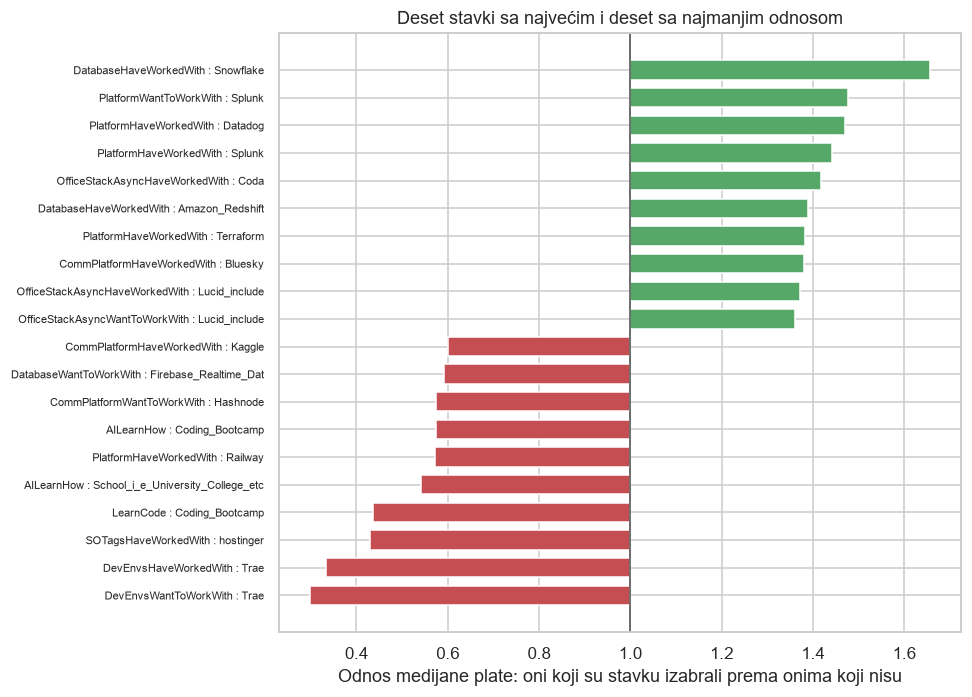

najveći odnos:  1.66 puta   (DatabaseHaveWorkedWith : Snowflake, izabralo 511 ljudi)
najmanji odnos: 0.30 puta   (DevEnvsWantToWorkWith : Trae, izabralo 46 ljudi)
koliko ljudi je izabralo stavke sa krajeva: od 46 do 2,356
stavki kod kojih je odnos ispod 1: 150 od 305


In [111]:
effect = pd.DataFrame({
    "izabrali": [train.loc[items[c] == 1, TARGET].median() for c in kept_items],
    "nisu": [train.loc[items[c] == 0, TARGET].median() for c in kept_items],
}, index=kept_items)
effect["odnos"] = effect["izabrali"] / effect["nisu"]
effect["izabralo_ljudi"] = [int(items[c].sum()) for c in kept_items]

edges = pd.concat([effect.nlargest(10, "odnos"), effect.nsmallest(10, "odnos")])
edges = edges.sort_values("odnos")
labels = [name.replace(ITEM_PREFIX, "").replace("__", " : ")[:46] for name in edges.index]

fig, ax = plt.subplots(figsize=(9, 6.5))
colors = ["#C44E52" if value < 1 else "#55A868" for value in edges["odnos"]]
ax.barh(range(len(edges)), edges["odnos"] - 1, left=1, color=colors, height=0.7)
ax.axvline(1, color="#4C4C4C", linewidth=1)

ax.set_yticks(range(len(edges)))
ax.set_yticklabels(labels, fontsize=7.5)
ax.set_xlabel("Odnos medijane plate: oni koji su stavku izabrali prema onima koji nisu")
ax.set_title("Deset stavki sa najvećim i deset sa najmanjim odnosom")
plt.tight_layout()
plt.show()

print(f"najveći odnos:  {edges['odnos'].max():.2f} puta   ({labels[-1]}, "
      f"izabralo {edges['izabralo_ljudi'].iloc[-1]:,} ljudi)")
print(f"najmanji odnos: {edges['odnos'].min():.2f} puta   ({labels[0]}, "
      f"izabralo {edges['izabralo_ljudi'].iloc[0]:,} ljudi)")
print(f"koliko ljudi je izabralo stavke sa krajeva: od "
      f"{edges['izabralo_ljudi'].min():,} do {edges['izabralo_ljudi'].max():,}")
print(f"stavki kod kojih je odnos ispod 1: {int((effect['odnos'] < 1).sum())} od {len(effect)}")

**Zapažanje:** odnosi idu od **0,30 do 1,66 puta**. Na gornjem kraju je `Snowflake`, gde oni koji su ga
izabrali imaju 1,66 puta veću medijanu plate; na donjem `Trae`, gde je odnos 0,30. Kod **150 od 305**
zadržanih stavki odnos je ispod jedinice, dakle otprilike pola njih prati **nižu** platu.

**Tumačenje:** ono što je preživelo ima smisla, i to je bila svrha grafika.

Na strani veće plate su alati velikih firmi i zrelih timova — baze u oblaku, infrastrukturni alati,
sistemi za dokumentaciju. Na strani manje plate su uglavnom novi alati koje tek treba da se dokažu, i
tehnologije koje se uče na početku. To nije spisak tehnologija koje „donose platu" nego oznaka toga u
kakvoj firmi i na kom poslu neko radi — što je i razlog zbog kog ove kolone modelu pomažu.

Odnos od 0,30 pri tome ne znači da neka tehnologija smanjuje platu tri puta.
Znači da je biraju ljudi koji zarađuju manje, a to su najčešće mlađi ispitanici i oni iz zemalja sa nižim
platama — a zemlju i staž model već ima. Zato ovaj grafik i nije osnov za odluku nego provera da nam u
skupu nisu ostale slučajne kolone.

In [112]:
columns_before = train.shape[1]
train = pd.concat([train, items[kept_items]], axis=1)

# The multi-select columns have now given everything they hold: counts in
# section 4, chosen items here. As strings they cannot enter a model, and they
# are what makes the saved file large, so they leave.
text_size_mb = sum(train[c].astype(str).str.len().sum() for c in multi_select) / 1024 ** 2
train = train.drop(columns=multi_select)

print(f"kolona pre sekcije 27:       {columns_before}")
print(f"dodato po stavci:            {len(kept_items)}   (od {items.shape[1]} kandidata)")
print(f"izbačeno multi-select kolona: {len(multi_select)}   "
      f"(iz njih je izvedeno sve što nose)")
print(f"kolona posle:                {train.shape[1]}")
print(f"teksta koji time izlazi iz skupa: oko {text_size_mb:.0f} MB")
print()
print(f"provera da u skupu više nema kolona sa tačka-zarezom: "
      f"{not any(is_multi_select(train[c]) for c in train.columns if is_text(train[c]))}")
print()
print("iz kojih pitanja dolaze zadržane stavke:")
by_source = pd.Series([c.split("__")[0].replace(ITEM_PREFIX, "") for c in kept_items]).value_counts()
print(by_source.head(8).to_string())
print(f"  ... ukupno iz {by_source.size} izvornih kolona od {len(item_sources)}")

kolona pre sekcije 27:       178
dodato po stavci:            305   (od 609 kandidata)
izbačeno multi-select kolona: 36   (iz njih je izvedeno sve što nose)
kolona posle:                447
teksta koji time izlazi iz skupa: oko 26 MB

provera da u skupu više nema kolona sa tačka-zarezom: True

iz kojih pitanja dolaze zadržane stavke:
PlatformHaveWorkedWith                      27
PlatformWantToWorkWith                      21
WebframeWantToWorkWith                      20
DatabaseHaveWorkedWith                      17
OfficeStackAsyncHaveWorkedWith              16
LanguageHaveWorkedWith                      15
CommPlatformHaveWorkedWith                  13
AIToolDon_t_plan_to_use_AI_for_this_task    13
  ... ukupno iz 29 izvornih kolona od 29


### Šta sekcija ostavlja sledećoj

Skup je sa 178 kolona narastao na **447**: dodato je 305 od 609 kandidata, a izbačeno je 36 multi-select
kolona iz kojih je sve izvedeno.

To izbacivanje je važno i vredi ga objasniti. Multi-select kolona je string oblika
`Python;JavaScript;SQL` i model je takvu ne može primiti — u prethodnom delu smo videli da bi
enkodiranje takvih kolona kao običnih kategorija dalo više kolona nego što skup ima redova. Sve što one
nose sada postoji u upotrebljivom obliku: **koliko** je stavki izabrano, iz sekcije 27, i **koje** su
izabrane, iz ove sekcije. Same više nemaju šta da daju, a nose i najveći deo veličine fajla.

Tri stvari se prenose dalje:

- **koje su stavke izabrane vredi mnogo više od toga koliko ih je.** Kolone po stavci dodaju +0,0460 na
  model koji već ima zemlju, staž i sve brojeve — skoro tri puta više nego što su dodali sami brojevi;
- **prag nije mogao da se izvede iz zastupljenosti** jer prekida u nizu nema, ali ni nije trebalo:
  izmerili smo da retkost koloni ne daje nezasluženu prednost. Pravi problem je bio broj provera, i prag
  je postavljen na domet koji slučajnost pri 609 provera ne prelazi;
- **ono što je preživelo je prepoznatljivo** — infrastrukturni i timski alati na jednoj strani, novi i
  početnički na drugoj — pa postupak nije uhvatio šum.

Skup i dalje ima znatno više kolona nego što je udobno za običnu regresiju. To je razlog zbog kog sekcija
9 proverava koliko se nove promenljive međusobno preklapaju, a u modelovanju Ridge i Lasso postoje baš za
ovakav slučaj.

Ostaje još da se obrade **43 kolone sa rangiranjem**, koje su i dalje netaknute — time se bavi sledeća
sekcija.

## 29. Kolone sa rangiranjem

Ostale su **43 numeričke kolone** koje su sve vreme bile tu ali ih nismo dirali. One ne dolaze iz
multi-select pitanja nego iz pitanja tipa „poređaj po važnosti", i vrednost u njima nije količina nego
**mesto na listi**.

Pre nego što s njima bilo šta uradimo, treba da vidimo šta tačno znače i, što je važnije, **koliko od
tih vrednosti je uopšte odgovor ispitanika**. U prethodnom delu su nedostajuće vrednosti u ovim
kolonama popunjene medijanom, pa kod jednog dela ispitanika u koloni ne stoji njihov rang nego naša
procena. Ako to zanemarimo, merili bismo sopstvenu imputaciju.

### 29.1 Šta je u tim kolonama

Za svaku kolonu šema kaže iz kog pitanja dolazi i **koju stavku** ta kolona rangira, pa te oznake
čitamo odatle umesto da ih pogađamo iz imena.

In [113]:
# The four ranking questions and the indicator that says who actually answered
# each of them; the indicators come from the cleaning notebook, where these
# columns were filled with the median.
RANK_QUESTIONS = {
    "TechEndorse": "NotAnswered_TechEndorse_1",
    "TechOppose": "NotAnswered_TechOppose_1",
    "JobSatPoints": "NotAnswered_JobSatPoints_1",
    "SO_Actions": "NotAnswered_SO_Actions_1",
}
item_label = schema.drop_duplicates(subset="qname").set_index("qname")["sub"]

rank_columns = {name: [c for c in train.columns
                       if c.startswith(name) and train[c].dtype.kind in "if"]
                for name in RANK_QUESTIONS}

print(f"kolona sa rangiranjem: {sum(len(c) for c in rank_columns.values())}")
print()
for name, indicator in RANK_QUESTIONS.items():
    columns = rank_columns[name]
    answered = train[indicator] == 0
    values = train.loc[answered, columns]
    # The schema keeps ranking questions one row per column, so the question
    # text and type are read off any one of them.
    entry = question_info.loc[columns[0]]
    text = re.sub(r"<[^>]+>|\s+", " ", str(entry["question"])).strip()
    print(f"{name}  ({entry['type']}, {len(columns)} kolona, {entry['qid']})")
    print(f"  {text[:96]}")
    print(f"  stvarno rangiralo: {int(answered.sum()):>6,} ({100 * answered.mean():.1f}%)   "
          f"imputirano: {int((~answered).sum()):>5,} ({100 * (~answered).mean():.1f}%)")
    print(f"  rangovi idu od {values.min().min():.0f} do {values.max().max():.0f}, "
          f"različitih po ispitaniku: {values.nunique(axis=1).median():.0f}")
    print(f"  primer stavke: {columns[0]} = „{item_label.get(columns[0])}\"")
    print()


# What the fill from the cleaning notebook actually put in these columns, shown
# next to two real answers.
example = rank_columns["TechEndorse"]
skipped = train["NotAnswered_TechEndorse_1"] == 1

print("kako izgleda red od deset kolona pitanja TechEndorse:")
for label, subset in [("rangirao", train.loc[~skipped, example]),
                      ("nije rangirao", train.loc[skipped, example])]:
    for i in range(2):
        print(f"  {label:<14} {[int(v) for v in subset.iloc[i]]}")
print()
print(f"  {'':<14} {'zbir rangova u redu':>28} {'različitih vrednosti':>22}")
for label, mask in [("rangirali", ~skipped), ("nisu rangirali", skipped)]:
    sums = sorted(int(v) for v in train.loc[mask, example].sum(axis=1).unique())
    distinct = sorted(int(v) for v in train.loc[mask, example].nunique(axis=1).unique())
    shown = ", ".join(str(v) for v in sums[:3]) + (" ..." if len(sums) > 3 else "")
    print(f"  {label:<14} {shown:>28} {', '.join(str(v) for v in distinct):>22}")
print(f"  za poređenje, ispravno rangiranje deset stavki: zbir 1+2+...+10 = {sum(range(1, 11))}, "
      f"deset različitih vrednosti")

kolona sa rangiranjem: 43

TechEndorse  (RO, 10 kolona, QID18)
  What attracts you to a technology or causes you to endorse it (most to least important)?
  stvarno rangiralo: 13,867 (94.9%)   imputirano:   741 (5.1%)


  rangovi idu od 1 do 14, različitih po ispitaniku: 10
  primer stavke: TechEndorse_1 = „AI integration or AI Agent capabilities"

TechOppose  (RO, 10 kolona, QID19)
  What would turn you off or cause you to reject it (most to least important)?
  stvarno rangiralo: 13,420 (91.9%)   imputirano: 1,188 (8.1%)
  rangovi idu od 1 do 15, različitih po ispitaniku: 10
  primer stavke: TechOppose_1 = „Lack of AI or AI agents"

JobSatPoints  (RO, 13 kolona, QID27)
  Rank the following attributes of your current professional job in technology according to those 
  stvarno rangiralo: 13,656 (93.5%)   imputirano:   952 (6.5%)


  rangovi idu od 1 do 15, različitih po ispitaniku: 13
  primer stavke: JobSatPoints_1 = „Control over the level of quality in projects"

SO_Actions  (RO, 10 kolona, QID76)
  When visiting Stack Overflow, which following activities are you most interested in? Please rank
  stvarno rangiralo: 11,544 (79.0%)   imputirano: 3,064 (21.0%)
  rangovi idu od 1 do 15, različitih po ispitaniku: 10
  primer stavke: SO_Actions_1 = „Browse content related to Q&A posts I recently viewed"

kako izgleda red od deset kolona pitanja TechEndorse:
  rangirao       [8, 7, 3, 4, 9, 5, 6, 2, 1, 10]
  rangirao       [9, 6, 4, 7, 2, 3, 8, 1, 5, 10]
  nije rangirao  [9, 4, 4, 6, 4, 6, 7, 4, 4, 10]
  nije rangirao  [9, 4, 4, 6, 4, 6, 7, 4, 4, 10]

                          zbir rangova u redu   različitih vrednosti


  rangirali                    55, 56, 58 ...                     10
  nisu rangirali                           58                      5
  za poređenje, ispravno rangiranje deset stavki: zbir 1+2+...+10 = 55, deset različitih vrednosti


**Zapažanje:** sva četiri pitanja su tipa **`RO`**, dakle rang-pitanja: ispitanik poređa ponuđene stavke
od najvažnije ka najmanje važnoj, a u koloni stoji mesto koje je dodelio toj stavci. Kod onih koji su
stvarno rangirali broj različitih vrednosti u redu poklapa se sa brojem kolona — svaka stavka dobija svoje
mesto i nijedno se ne ponavlja.

Udeo onih koji su stvarno rangirali kreće se od **94,9% kod `TechEndorse` do 79,0% kod `SO_Actions`**.
Ostatak su vrednosti koje smo mi upisali u prethodnom delu — kod `SO_Actions` je to **3.064
ispitanika**.

Poslednji deo ispisa pokazuje **kako to popunjavanje zapravo izgleda**, i to je gore nego što zvuči. U
prethodnom delu je svaka kolona popunjena **svojom** medijanom, nezavisno od ostalih. Pošto
`TechEndorse_1` ima medijanu 9, a `TechEndorse_2` medijanu 4, svaki ispitanik koji je pitanje preskočio
dobio je **isti red**: `[9, 4, 4, 6, 4, 6, 7, 4, 4, 10]`. U njemu se rang 4 javlja četiri puta, ima svega
pet različitih vrednosti umesto deset, a zbir je 58 umesto 55.

**Tumačenje:** to nije rangiranje. Nijedan ispitanik ne bi mogao tako da odgovori, jer se u rang-pitanju
mesto ne može dodeliti dvaput.

Popunjavanje medijanom je za ove kolone, dakle, samo **čuvanje mesta** — način da u tabeli ne ostane
prazno polje, a ne procena nečijeg odgovora. Za rang-pitanje ni ne postoji popunjavanje koje bi bilo
bolje: svaka izmišljena lista je izmišljena. Ono što jeste urađeno kako treba je da uz te kolone stoji
indikator `NotAnswered_`, pa model može da razlikuje te ispitanike od ostalih, a svi oni u ovih 43 kolone
imaju identične vrednosti — dakle ništa što bi model mogao pogrešno da nauči osim jedne konstante, koju
indikator ionako objašnjava.

Iz ovoga slede dve stvari.

Prva je da rang **nije količina** nego mesto, i da manji broj znači veću važnost. Kad takvu kolonu
stavimo u regresiju kao broj, pretpostavljamo da je razlika između prvog i drugog mesta ista kao između
devetog i desetog — što ne mora biti tačno. Zato u odeljku 29.3 poredimo taj pristup sa drugim, koji takvu
pretpostavku ne pravi.

Druga je razlog zbog kog dalje **merimo samo na onima koji su rangirali**. Kod `SO_Actions` bi svaki peti
ispitanik u merenje ušao sa istim izmišljenim redom, pa bi rezultat delom govorio o našem popunjavanju, a
ne o njihovim odgovorima.

### 29.2 Koliko rang nosi, mereno samo na onima koji su rangirali

Merilo iz sekcije 25 primenjujemo kao i do sada, uz jednu izmenu koju nameće imputacija: **računamo samo
na ispitanicima koji su pitanje stvarno rangirali.** Kod ostalih u koloni stoji medijana koju smo mi
upisali, ista za sve njih, pa bi njihovo uključivanje merilo koliko naša imputacija liči na platu — a to
nas ne zanima.

Rang je broj kod kog **manja vrednost znači veću važnost**: 1 je ono što je ispitaniku na prvom mestu. To
znači da negativan koeficijent u regresiji treba čitati obrnuto nego obično — što je stavka više na
listi, to je vrednost manja.

In [114]:
def signal_on_subset(values, mask):
    """The same measure as in section 2, computed on part of the rows only."""
    target = train.loc[mask, TARGET_LOG]
    model = sm.OLS(target.to_numpy(),
                   design_matrix(values[mask]).to_numpy()).fit()
    return {"n": int(mask.sum()), "R": float(np.sqrt(model.rsquared)),
            "R2_prilag": model.rsquared_adj, "p": model.f_pvalue}


measured_ranks = {}
for name, indicator in RANK_QUESTIONS.items():
    answered = train[indicator] == 0
    for column in rank_columns[name]:
        measured_ranks[column] = signal_on_subset(train[column], answered)

measured_ranks = pd.DataFrame(measured_ranks).T.sort_values("R2_prilag", ascending=False)
measured_ranks["stavka"] = [str(item_label.get(c))[:44] for c in measured_ranks.index]

print("osam najjačih pojedinačnih rangova:")
top = measured_ranks.head(8)
print(pd.DataFrame({"n": top["n"].map(lambda v: f"{int(v):,}"),
                    "R": top["R"].map(lambda v: f"{v:.3f}"),
                    "R2_prilag": top["R2_prilag"].map(lambda v: f"{v:.4f}"),
                    "p": top["p"].map(format_p),
                    "stavka": top["stavka"]}).to_string())
print()
band_ranks = pd.cut(measured_ranks["R2_prilag"], [-np.inf, NOISE_LIMIT, SIGNAL_LIMIT, np.inf],
                    labels=["šum", "slaba", "nosi signal"])
band_ranks = band_ranks.mask(measured_ranks["p"] >= 0.05, "šum")
print("razvrstano po pravilu iz 25.4:")
for label, count in band_ranks.value_counts().reindex(["nosi signal", "slaba", "šum"]).items():
    print(f"  {label:<14} {int(count):>3} od {len(measured_ranks)}")

osam najjačih pojedinačnih rangova:
                      n      R R2_prilag        p                                   stavka
TechOppose_1     13,420  0.178    0.0316    5e-96                  Lack of AI or AI agents
JobSatPoints_4   13,656  0.152    0.0230  2.3e-71                           Expert mentors
TechEndorse_1    13,867  0.149    0.0222  8.5e-70  AI integration or AI Agent capabilities
SO_Actions_10    11,544  0.138    0.0189  5.5e-50           Use discussion or chat feature
JobSatPoints_11  13,656  0.120    0.0142    1e-44             Competitive pay and benefits
JobSatPoints_16  13,656  0.105    0.0109  1.5e-34                    You like your manager
JobSatPoints_6   13,656  0.102    0.0104  5.2e-33         Developing specialized expertise
TechEndorse_4    13,867  0.096    0.0091  1.2e-29     Customizable and manageable codebase

razvrstano po pravilu iz 25.4:
  nosi signal      1 od 43
  slaba           35 od 43
  šum              7 od 43


**Zapažanje:** najjača pojedinačna kolona je **`TechOppose_1`, „Lack of AI or AI agents"**, sa
prilagođenim R² od **0,0316** — jedina koja po pravilu iz 25.4 prelazi granicu od 0,0286. Slede
`JobSatPoints_4` („Expert mentors", 0,0230) i `TechEndorse_1` („AI integration or AI Agent capabilities",
0,0222). Od 43 kolone, **35 je slabo, a 7 je šum**.

**Tumačenje:** vrh liste je zanimljiv jer se tri od četiri najjače kolone tiču istog — **odnosa prema AI**
i prema mentorstvu.

Kod `TechOppose_1` treba paziti na smer. Kolona sadrži mesto koje je ispitanik dao stavci „nedostatak AI
me odbija od tehnologije"; **manji broj znači da mu je to važnije**. Sam po sebi rang ne kaže na koju
stranu ide plata — to se vidi tek iz koeficijenta, i tu razliku ćemo morati da čitamo pažljivo u fazi
modelovanja.

Kod `JobSatPoints_4` je čitanje neposrednije i pokazuje ga Grafik 23: onima koji su „stručne mentore"
stavili na prvo mesto plata je najniža u celom pitanju. To nije iznenađenje — mentore najviše traže oni
koji su na početku karijere.

Nijedna od 43 kolone nije jaka sama za sebe, što je do sada bilo pravilo a ne izuzetak. Da li zajedno
vrede, i u kom obliku, rešava odeljak 29.3.

### Grafik 23 — šta je ispitaniku najvažnije i koliko zarađuje

**Motivacija:** rang jedne stavke govori malo sam za sebe, ali ono što je ispitaniku **na prvom mestu**
sažima celu njegovu listu u jedan podatak. Kod pitanja o zadovoljstvu poslom to je posebno čitljivo: neko
ko na prvo mesto stavi platu verovatno gleda na posao drugačije od nekoga kome je prvo mentorstvo. Da li
se to vidi i u zaradi, ne znamo — crtamo medijanu plate po tome šta je kod koga na prvom mestu.

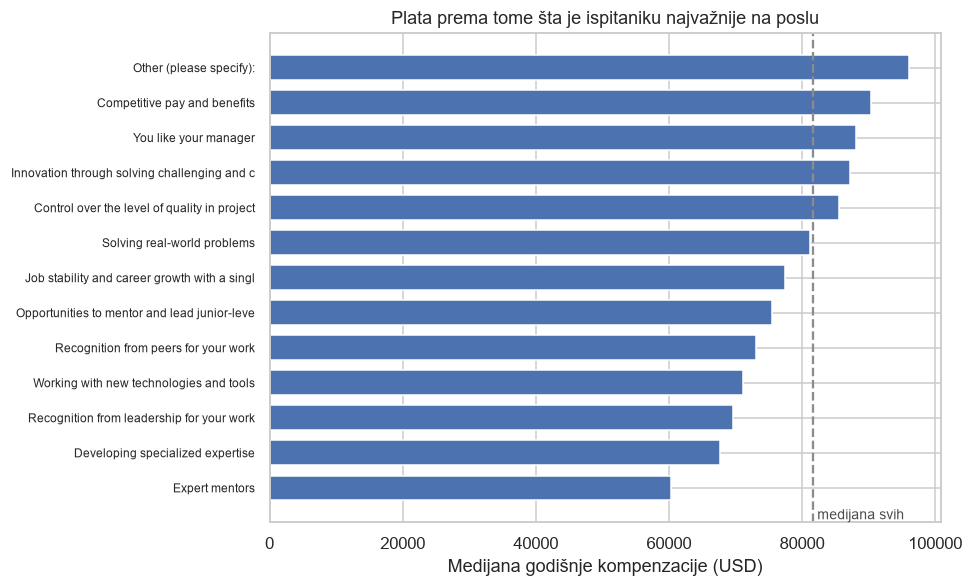

prikazano izbora sa bar 100 ispitanika: 13 od 13
raspon medijana: 60,328 do 96,033 USD (1.59 puta)

                  median  size                                        stavka
JobSatPoints_4   60328.0   389                                Expert mentors
JobSatPoints_6   67655.0   543              Developing specialized expertise
JobSatPoints_14  69609.0   402     Recognition from leadership for your work
JobSatPoints_10  71125.5   784       Working with new technologies and tools
JobSatPoints_13  73089.0   379          Recognition from peers for your work
JobSatPoints_5   75410.0   235  Opportunities to mentor and lead junior-leve
JobSatPoints_8   77399.0  1435  Job stability and career growth with a singl
JobSatPoints_7   81210.0  2277                   Solving real-world problems
JobSatPoints_1   85557.0  1187  Control over the level of quality in project
JobSatPoints_9   87135.5  1388  Innovation through solving challenging and c
JobSatPoints_16  88121.5  1134                       

In [115]:
def top_choice(name):
    """Which of the available items the respondent put highest.

    The lowest rank wins. Taking the smallest rather than looking for rank 1
    matters because a few items of each question are not in our columns, so the
    literal first place is sometimes missing while the order among the rest holds.
    """
    columns = rank_columns[name]
    answered = train[RANK_QUESTIONS[name]] == 0
    return train[columns].idxmin(axis=1).where(answered, "NotAnswered")


choice = top_choice("JobSatPoints")
answered = choice != "NotAnswered"

by_choice = train[answered].groupby(choice[answered])[TARGET].agg(["median", "size"])
by_choice = by_choice[by_choice["size"] >= 100].sort_values("median")
labels = [str(item_label.get(c, c))[:44] for c in by_choice.index]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(range(len(by_choice)), by_choice["median"], color="#4C72B0", height=0.7)
ax.axvline(train.loc[answered, TARGET].median(), color="#8C8C8C", linestyle="--", linewidth=1.5)

ax.set_yticks(range(len(by_choice)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Medijana godišnje kompenzacije (USD)")
ax.set_title("Plata prema tome šta je ispitaniku najvažnije na poslu")
ax.text(train.loc[answered, TARGET].median(), -0.9, " medijana svih",
        color="#4C4C4C", fontsize=9)
plt.tight_layout()
plt.show()

print(f"prikazano izbora sa bar 100 ispitanika: {len(by_choice)} od {choice[answered].nunique()}")
print(f"raspon medijana: {by_choice['median'].min():,.0f} do {by_choice['median'].max():,.0f} USD "
      f"({by_choice['median'].max() / by_choice['median'].min():.2f} puta)")
print()
print(by_choice.assign(stavka=labels).to_string())

**Zapažanje:** raspon medijana je **od 60.328 do 96.033 dolara**, dakle **1,59 puta**. Najnižu platu imaju
oni kojima su na prvom mestu **stručni mentori** (60.328, njih 389), a najvišu oni koji su izabrali
„Other" (96.033, njih 185). Među odgovorima sa najviše ljudi, **konkurentna plata** je na prvom mestu kod
**3.318 ispitanika**, sa medijanom od 90.422 — među najvišima.

Ispod proseka su, redom, mentori, razvijanje uske ekspertize, priznanje od rukovodstva i rad sa novim
tehnologijama.

**Tumačenje:** poredak ima jasnu logiku i ona nije o tome da neki prioritet „donosi" platu, nego o tome
**ko ga bira**. Mentore i priznanje traže oni na početku karijere; stabilnost i konkurentnu platu biraju
oni koji su već u poziciji da o tome pregovaraju. Isti obrazac smo videli i kod stavki u sekciji 28.

Raspon od 1,59 puta je pri tome skroman u poređenju sa 136,8 puta koliko daje zemlja. Ovo je promenljiva
koja može da doprinese, ali nije reda veličine onoga što nose zemlja ili iskustvo.

### 29.3 Hipoteza 8 — rang po stavci ili samo ono što je prvo

Iz 43 kolone sa rangiranjem mogu se izvesti dva sasvim različita skupa promenljivih, i treba izabrati.

**Rangovi kakvi jesu.** Svaka od 43 kolone ulazi kao broj. Zadržava se cela lista — i šta je prvo i šta
je poslednje — ali se pretpostavlja da rang deluje kao količina, dakle da je razlika između prvog i drugog
mesta ista kao između devetog i desetog.

**Samo ono što je na prvom mestu.** Iz svakog pitanja se izvodi jedna kategorijska promenljiva sa
onoliko kategorija koliko ima stavki. Gubi se sve osim vrha liste, ali se ne pretpostavlja ništa o tome
kako rangovi deluju — svaka kategorija dobija svoj koeficijent.

Druga mogućnost deluje privlačnije jer je sažetija: četiri promenljive umesto 43. Ali sažimanje uvek
nešto baca, a ovde baca dosta — dvoje ljudi kojima je isto na prvom mestu mogu imati potpuno različit
ostatak liste.

Poređenje radimo nad onim što ovaj deo do sada ima: zemljom, svim promenljivama iz sekcija 27 i 5 i
nasleđenim brojčanim kolonama. Ostale nasleđene kategorijske kolone u toj osnovi nisu, jer se njima
bavi tek sekcija 31.

> **Hipoteza:** ono što je ispitaniku na prvom mestu nosi bar onoliko informacije o plati koliko i cela
> lista rangova.
>
> **Kriterijum:** hipoteza je potvrđena ako četiri promenljive „prvo mesto", dodate na model iz sekcije 28,
> daju prirast prilagođenog R² bar toliki koliki daju sve 43 kolone sa rangovima. Poređenje je na
> prilagođenom R², pa je svaka mogućnost kažnjena za kolone koje troši — četiri kategorijske promenljive
> u model unose oko četrdeset dummy kolona, dakle otprilike isto koliko i sami rangovi.

In [116]:
from scipy import linalg

all_rank_columns = [c for columns in rank_columns.values() for c in columns]
top_choices = pd.DataFrame({f"Top_{name}": top_choice(name) for name in RANK_QUESTIONS},
                           index=train.index)

# Everything the notebook has built so far, plus the plain numeric columns it
# inherited — which is what a new variable has to improve on at this point.
# Read off the frame rather than listed by hand: every numeric column that is
# not a ranking and not the target.
current = [c for c in train.columns
           if c not in (TARGET, TARGET_LOG) and train[c].dtype.kind in "if"
           and not RANK_NAME.fullmatch(c)]


def independent_columns(design):
    """The columns that are not an exact combination of the others.

    With this many columns some are bound to be determined by the rest, and a
    regression then has no unique solution. The factorisation below orders the
    columns by how much new direction each one adds, so those that add nothing
    are the ones to leave out.
    """
    matrix = design.to_numpy(dtype=float)
    _, upper, order = linalg.qr(matrix, mode="economic", pivoting=True)
    tolerance = abs(upper[0, 0]) * max(matrix.shape) * np.finfo(float).eps
    rank = int((abs(np.diag(upper)) > tolerance).sum())
    return [design.columns[i] for i in order[:rank]], [design.columns[i] for i in order[rank:]]


def fit_with(extra=None, report=False, label=""):
    parts = [pd.get_dummies(train["Country"].astype(str), prefix="Country",
                            drop_first=True, dtype=float),
             train[current].astype(float)]
    if extra is not None:
        parts.append(extra)
    design = pd.concat(parts, axis=1)
    keep, dropped = independent_columns(design)
    if report:
        print(f"  {label:<30} kolona {design.shape[1]:>3}, zavisnih {len(dropped):>2}"
              f"   {dropped[:3]}")
    design = sm.add_constant(design[keep], has_constant="add")
    return sm.OLS(train[TARGET_LOG].to_numpy(), design.to_numpy()).fit()


rank_block = train[all_rank_columns].astype(float)

# Two categories have to come out of each of these variables, not one. The
# notebook already carries a NotAnswered_ column per question, so a dummy for
# "not answered" would copy it; and once that is gone, the remaining dummies plus
# that indicator plus the intercept still add up to one, so one more has to go.
top_block = pd.get_dummies(top_choices, dtype=float)
redundant = [c for c in top_block.columns if c.endswith("NotAnswered")]
for name in top_choices.columns:
    real = [c for c in top_block.columns
            if c.startswith(name + "_") and c not in redundant]
    redundant.append(real[0])
top_block = top_block.drop(columns=redundant)

print("provera da li neka kolona ponavlja ono što druge već nose:")
base_now = fit_with(report=True, label="zemlja i sve izvedeno")
with_ranks = fit_with(rank_block, report=True, label="+ rangovi")
with_tops = fit_with(top_block, report=True, label="+ prvo mesto")
with_both = fit_with(pd.concat([rank_block, top_block], axis=1),
                     report=True, label="+ oboje")
print()

print(f"{'model':<34} {'prilagođeni':>12} {'prirast':>9} {'kolona':>7}")
for label, model in [("zemlja i sve izvedeno (4 i 5)", base_now),
                     ("+ 43 ranga kao brojevi", with_ranks),
                     ("+ 4 promenljive „prvo mesto\"", with_tops),
                     ("+ oboje", with_both)]:
    gain = model.rsquared_adj - base_now.rsquared_adj
    print(f"{label:<34} {model.rsquared_adj:>12.4f} {gain:>+9.4f} {int(model.df_model):>7}")

print()
print(f"tipičan prirast anketnog obeležja: {typical_gain:+.4f}")
print(f"rangovi dodaju bar koliko i „prvo mesto\": "
      f"{bool(with_ranks.rsquared_adj >= with_tops.rsquared_adj)}")

provera da li neka kolona ponavlja ono što druge već nose:


  zemlja i sve izvedeno          kolona 508, zavisnih  0   []


  + rangovi                      kolona 551, zavisnih  0   []


  + prvo mesto                   kolona 547, zavisnih  0   []


  + oboje                        kolona 590, zavisnih  0   []



model                               prilagođeni   prirast  kolona
zemlja i sve izvedeno (4 i 5)            0.6471   +0.0000     508
+ 43 ranga kao brojevi                   0.6556   +0.0084     551
+ 4 promenljive „prvo mesto"             0.6508   +0.0037     547
+ oboje                                  0.6560   +0.0089     590

tipičan prirast anketnog obeležja: +0.0072
rangovi dodaju bar koliko i „prvo mesto": True


**Zapažanje:** provera zavisnosti na početku ispisa odmah je nešto našla — promenljive „prvo
mesto", onako kako se prvo naprave, **ponavljaju ono što već imamo**. Za svako od četiri pitanja postoji
kolona `NotAnswered_`, pa bi dummy za kategoriju „nije odgovorio" bio njena tačna kopija; a i kad se ta
kategorija izbaci, preostale dummy kolone jednog pitanja zajedno sa tim indikatorom i slobodnim članom i
dalje daju jedinicu. Zato iz svake promenljive izlaze **dve** kategorije umesto jedne. Posle toga nijedan
model nema zavisnih kolona.

Rezultat poređenja:

- 43 ranga kao brojevi dodaju **+0,0084**;
- četiri promenljive „prvo mesto" dodaju **+0,0037**, uz sličan broj kolona;
- oboje zajedno dodaju **+0,0089**, dakle svega 0,0005 više od samih rangova.

**Verdikt: hipoteza je opovrgnuta.** Ono što je ispitaniku na prvom mestu nosi **manje od pola** onoga što
nosi cela lista.

**Tumačenje:** sažimanje je ovde koštalo više nego što je donelo. To ima smisla kad se pogleda šta se
gubi: dvoje ljudi kojima je na prvom mestu „konkurentna plata" mogu imati potpuno različit ostatak liste
— jedan mentore na drugom mestu, drugi na poslednjem — a ta razlika po svemu sudeći nešto znači.

Poslednji red je usput i odgovor na pitanje da li vredi zadržati oboje: pošto „prvo mesto" povrh rangova
dodaje samo 0,0005, ono što ono nosi već je sadržano u rangovima. Cela lista, dakle, **sadrži svoj vrh**,
a obrnuto ne važi.

Prirast rangova od +0,0084 je iznad tipičnog prirasta anketnog obeležja (+0,0072), pa 43 kolone ostaju.

### 29.4 Šta zadržavamo

Odluka je time doneta: **rangove zadržavamo kakvi jesu, promenljive „prvo mesto" ne pravimo.** Ostaje još
da se na rangove primeni isto pravilo kao na sve ostalo — da se izbaci ono što je po merenju šum, uz
proveru koliko to košta.

In [117]:
noise_ranks = list(band_ranks[band_ranks == "šum"].index)
kept_ranks = [c for c in all_rank_columns if c not in noise_ranks]

print(f"rangova označenih kao šum: {len(noise_ranks)} od {len(all_rank_columns)}")
for column in noise_ranks:
    print(f"  {column:<18} {str(item_label.get(column))[:52]}")
print()

with_all_ranks = fit_with(train[all_rank_columns].astype(float))
with_kept_ranks = fit_with(train[kept_ranks].astype(float))
print(f"model sa svih {len(all_rank_columns)} rangova:  prilagođeni={with_all_ranks.rsquared_adj:.4f}")
print(f"model bez {len(noise_ranks)} označenih kao šum: prilagođeni={with_kept_ranks.rsquared_adj:.4f}")
print(f"cena izbacivanja:              {with_kept_ranks.rsquared_adj - with_all_ranks.rsquared_adj:+.5f}")
print()

train = train.drop(columns=noise_ranks)
print(f"izbačeno kolona: {len(noise_ranks)}")
print(f"kolona u skupu na kraju sekcije: {train.shape[1]}")

rangova označenih kao šum: 7 od 43
  SO_Actions_7       Upvote/Downvote Q&A posts
  SO_Actions_5       Ask a question
  SO_Actions_4       Directly open a Q&A post via search, documentation o
  SO_Actions_15      Other (write in):
  SO_Actions_9       Comment on Q&A posts
  TechOppose_15      Other (please specify):
  TechEndorse_2      Easy-to-use API



model sa svih 43 rangova:  prilagođeni=0.6556
model bez 7 označenih kao šum: prilagođeni=0.6557
cena izbacivanja:              +0.00009

izbačeno kolona: 7
kolona u skupu na kraju sekcije: 440


### Šta sekcija ostavlja sledećoj

Kolone sa rangiranjem su obrađene, i za razliku od prethodne dve sekcije ovde **nismo dodali nijednu novu
promenljivu** — samo smo utvrdili da su postojeće u dobrom obliku i izbacili one koje su šum.

Tri nalaza:

- **rang kao broj radi bolje od sažimanja na „šta je prvo".** Cela lista sadrži svoj vrh, obrnuto ne
  važi, pa se sažimanjem samo gubi;
- **rangovi zajedno dodaju +0,0084**, iznad tipičnog prirasta anketnog obeležja, iako pojedinačno samo
  jedna kolona prelazi granicu od 0,0286;
- **prilikom pravljenja novih kategorijskih promenljivih treba paziti na indikatore neodgovaranja.**
  Kategorija „nije odgovorio" ponavlja ono što indikator već nosi, i to model čini nerešivim. Ovo je
  prvi put da smo na to naleteli i verovatno neće biti poslednji — sekcija 32 se time bavi sistematski.

Za sledeću sekciju ostaje **`Country`**, koji je sve vreme u modelu kao 141 dummy kolona i sam objašnjava
više od svega ostalog zajedno. Pitanje je da li mu je toliko kolona zaista potrebno.

## 30. Zemlja: prvih N i ostalo

`Country` je od prve sekcije najjače obeležje koje imamo — sam objašnjava 55,87% varijanse, više nego
svih devet ostalih anketnih pitanja zajedno. Ali to dolazi po ceni: u model ulazi kao **141 dummy
kolona**, jedna manje nego što ima zemalja.

Do sada je to bila najveća stavka u modelu. Posle sekcija 27, 5 i 6 nije više, ali je i dalje velika, a
pitanje je da li joj je toliko kolona zaista potrebno. Zemlje se u uzorku razlikuju po veličini
ogromno — od nekoliko hiljada ispitanika do jednog ili dva — pa se lako može desiti da najveći deo onoga
što `Country` nosi dolazi od nekoliko desetina zemalja, a ostatak da su kolone koje se oslanjaju na
šačicu ljudi.

Uobičajen postupak za kategorijsku promenljivu sa previše kategorija je **„prvih N i ostalo"**: zadrže se
zemlje sa najviše ispitanika, a sve ostale se spoje u jednu kategoriju. Pitanje koje treba rešiti je
koliko iznosi N, i njega ćemo izvesti, ne izabrati.

### 30.1 Koliko je zemalja i koliko su nejednake

In [118]:
country_counts = train["Country"].value_counts()

print(f"zemalja u trening skupu: {len(country_counts)}   "
      f"kolona koje bi dale: {len(country_counts) - 1}")
print()
print("pet najvećih:")
for name, count in country_counts.head(5).items():
    print(f"  {name[:44]:<46} {count:>5,} ({100 * count / len(train):>4.1f}%)")
print()
for limit in [500, 100, 30, 10]:
    small = country_counts[country_counts < limit]
    print(f"zemalja sa manje od {limit:>3} ispitanika: {len(small):>3}   "
          f"nose {int(small.sum()):>5,} ispitanika ({100 * small.sum() / len(train):.1f}%)")
print()
print(f"medijana broja ispitanika po zemlji: {country_counts.median():.0f}")
print(f"polovina zemalja nosi ukupno: "
      f"{int(country_counts.tail(len(country_counts) // 2).sum()):,} ispitanika")

zemalja u trening skupu: 142   kolona koje bi dale: 141

pet najvećih:
  United States of America                       3,205 (21.9%)
  Germany                                        1,265 ( 8.7%)
  United Kingdom of Great Britain and Northern     979 ( 6.7%)
  India                                            696 ( 4.8%)
  France                                           645 ( 4.4%)

zemalja sa manje od 500 ispitanika: 136   nose 7,241 ispitanika (49.6%)
zemalja sa manje od 100 ispitanika: 111   nose 1,963 ispitanika (13.4%)
zemalja sa manje od  30 ispitanika:  85   nose   539 ispitanika (3.7%)
zemalja sa manje od  10 ispitanika:  63   nose   192 ispitanika (1.3%)

medijana broja ispitanika po zemlji: 12
polovina zemalja nosi ukupno: 277 ispitanika


**Zapažanje:** zemalja ima **142**, ali su krajnje nejednake. Sjedinjene Države same nose **21,9%**
ispitanika, a prvih pet zemalja skoro polovinu. Na drugom kraju, **85 zemalja ima manje od trideset
ispitanika** i zajedno nose 539 ljudi, dakle 3,7% skupa.

Najjasnije to govori medijana: **polovina zemalja ima 12 ili manje ispitanika**, a svih 71 tih zemalja
zajedno nosi **277 ljudi** — manje nego jedna Francuska.

**Tumačenje:** ovo je oblik za koji je „prvih N i ostalo" i smišljeno. Zemlja sa deset ispitanika u model
donosi svoju kolonu, a ta kolona uči prosek deset ljudi — to je procena koja se lako pomeri i za koju je
malo verovatno da će važiti i na test skupu.

Pitanje je samo gde povući granicu, a nju ne postavljamo po osećaju nego merimo.

### 30.2 Koliko zemalja zadržati

N ne biramo nego ga izvodimo, i to istim merilom kojim smo do sada sve merili.

Za svaki N zadržimo N zemalja sa najviše ispitanika, ostatak spojimo u kategoriju **`Other`**, i izmerimo
koliko takva promenljiva objašnjava. Zatim gledamo **koliko se time gubi** u odnosu na to da zadržimo sve
zemlje.

Prag je isti onaj koji koristimo od odeljka 27.3: **gubitak sme da bude manji od onoga što tipično anketno
obeležje dodaje na osnovu**, dakle manji od 0,0072. Ako je gubitak manji od toga, sažimanje košta manje
nego što vredi jedno prosečno pitanje iz ankete — a dobija se osetno manje kolona.

Uzimamo **najmanji N koji taj uslov ispunjava**, jer nema smisla nositi više kolona nego što treba.

In [119]:
def country_groups(n, series=None):
    """The n largest countries kept as they are, everything else as one group."""
    series = train["Country"] if series is None else series
    largest = country_counts.head(n).index
    return series.where(series.isin(largest), "Other")


def country_strength(n):
    """Adjusted R² of the grouped country variable on its own."""
    design = sm.add_constant(pd.get_dummies(country_groups(n), drop_first=True, dtype=float))
    return sm.OLS(train[TARGET_LOG].to_numpy(), design.to_numpy()).fit().rsquared_adj


full_strength = country_strength(len(country_counts))
curve = pd.Series({n: country_strength(n) for n in range(5, len(country_counts) + 1, 5)})
curve.loc[len(country_counts)] = full_strength

print(f"sve zemlje ({len(country_counts)}): prilagođeni R² = {full_strength:.4f}")
print(f"dozvoljeni gubitak (tipičan prirast anketnog obeležja): {typical_gain:.4f}")
print()
print(f"{'N':>5} {'kolona':>7} {'prilagođeni R²':>16} {'gubitak':>9}")
for n, value in curve.items():
    marker = "  ispod praga" if full_strength - value < typical_gain else ""
    print(f"{n:>5} {n - 1 if n == len(country_counts) else n:>7} {value:>16.4f} "
          f"{full_strength - value:>9.4f}{marker}")

COUNTRY_KEEP = next(n for n in range(1, len(country_counts) + 1)
                    if full_strength - country_strength(n) < typical_gain)
print()
print(f"najmanji N sa gubitkom ispod praga: {COUNTRY_KEEP}")
print(f"gubitak pri tom N: {full_strength - country_strength(COUNTRY_KEEP):.4f}")

sve zemlje (142): prilagođeni R² = 0.5544
dozvoljeni gubitak (tipičan prirast anketnog obeležja): 0.0072

    N  kolona   prilagođeni R²   gubitak
    5       5           0.2813    0.2731
   10      10           0.3546    0.1998
   15      15           0.3743    0.1801
   20      20           0.4127    0.1417
   25      25           0.4319    0.1225
   30      30           0.4492    0.1052
   35      35           0.4797    0.0747
   40      40           0.4874    0.0670
   45      45           0.5000    0.0544
   50      50           0.5182    0.0362
   55      55           0.5371    0.0173
   60      60           0.5402    0.0142
   65      65           0.5499    0.0045  ispod praga
   70      70           0.5509    0.0035  ispod praga
   75      75           0.5514    0.0030  ispod praga
   80      80           0.5521    0.0023  ispod praga
   85      85           0.5522    0.0022  ispod praga
   90      90           0.5533    0.0011  ispod praga
   95      95           0.5533    0.0


najmanji N sa gubitkom ispod praga: 61
gubitak pri tom N: 0.0052


**Zapažanje:** kriva raste dugo. Sa pet zemalja `Country` objašnjava svega 0,2813, sa trideset 0,4492, a
tek negde oko šezdesete približi se punoj vrednosti od 0,5544. **Najmanji N sa gubitkom ispod praga je
61**, i tu gubitak iznosi **0,0052**.

Posle toga se dobitak gasi: od 61 do svih 142 zemlje prilagođeni R² poraste za manje od 0,006, iako se
model uveća za osamdeset kolona.

**Tumačenje:** rezultat je manje povoljan nego što bi se očekivalo. Nije bilo tako da nekoliko velikih
zemalja nosi sve — zemlja stvarno nosi informaciju duboko u listu, sve do onih sa nekoliko desetina
ispitanika. To ima smisla: `Country` ovde ne označava naciju nego **tržište rada i kupovnu moć**, a to su
veličine koje se razlikuju od države do države i ne svode se na nekoliko grupa.

Zato N ispada relativno visok. Ali osamdeset kolona manje i dalje je osetna ušteda u modelu koji ih ima
preko četiri stotine, a plaća se gubitkom manjim od onoga što donese jedno prosečno anketno pitanje.

### Grafik 24 — koliko se dobija svakom sledećom zemljom

**Motivacija:** tabela daje vrednosti u nekoliko tačaka, ali se iz nje ne vidi **oblik** — da li se dobitak
troši postepeno ili naglo stane. To je ono što odlučuje da li „prvih N i ostalo" uopšte ima smisla: ako
kriva raste do samog kraja, svaka zemlja nosi nešto svoje i sažimanje je gubitak; ako se poravna, ono što
je iza te tačke su kolone koje se drže na šačici ljudi.

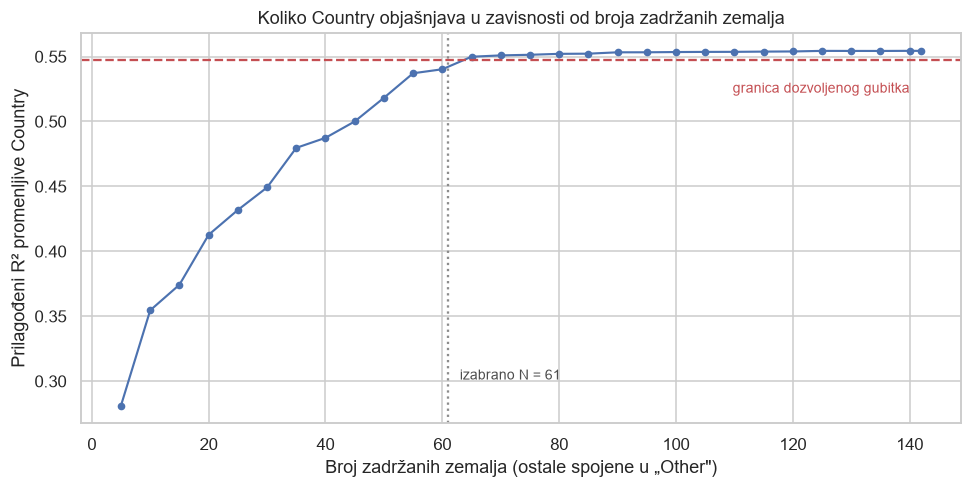

zadržano zemalja: 61   spojeno u „Other": 81
ispitanika u „Other": 440 (3.0%)
najmanja zadržana zemlja ima 21 ispitanika

medijana plate u „Other":    44,096 USD
medijana celog skupa:        81,210 USD
kolona umesto 141: 61   (ušteda 80)


In [120]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(curve.index, curve.values, marker="o", markersize=4, linewidth=1.4, color="#4C72B0")
ax.axhline(full_strength - typical_gain, color="#C44E52", linestyle="--", linewidth=1.5)
ax.axvline(COUNTRY_KEEP, color="#8C8C8C", linestyle=":", linewidth=1.5)

ax.set_xlabel("Broj zadržanih zemalja (ostale spojene u „Other\")")
ax.set_ylabel("Prilagođeni R² promenljive Country")
ax.set_title("Koliko Country objašnjava u zavisnosti od broja zadržanih zemalja")
ax.text(COUNTRY_KEEP + 2, curve.min() + 0.02, f"izabrano N = {COUNTRY_KEEP}",
        color="#4C4C4C", fontsize=9)
ax.text(len(country_counts) - 2, full_strength - typical_gain - 0.025,
        "granica dozvoljenog gubitka", color="#C44E52", fontsize=9, ha="right")
plt.tight_layout()
plt.show()

grouped = country_groups(COUNTRY_KEEP)
in_other = grouped == "Other"
print(f"zadržano zemalja: {COUNTRY_KEEP}   spojeno u „Other\": "
      f"{len(country_counts) - COUNTRY_KEEP}")
print(f"ispitanika u „Other\": {int(in_other.sum()):,} ({100 * in_other.mean():.1f}%)")
print(f"najmanja zadržana zemlja ima {country_counts.iloc[COUNTRY_KEEP - 1]} ispitanika")
print()
print(f"medijana plate u „Other\": {train.loc[in_other, TARGET].median():>9,.0f} USD")
print(f"medijana celog skupa:     {train[TARGET].median():>9,.0f} USD")
print(f"kolona umesto {len(country_counts) - 1}: {COUNTRY_KEEP}   "
      f"(ušteda {len(country_counts) - 1 - COUNTRY_KEEP})")

**Zapažanje:** grafik pokazuje krivu koja raste skoro pravolinijski do oko pedesete zemlje, pa se naglo
poravna. Izabrani N stoji tačno na mestu gde kriva preseca granicu dozvoljenog gubitka.

Sažimanje ostavlja **61 zemlju**, a u `Other` spaja **81 zemlju sa 440 ispitanika (3,0%)**. Najmanja
zadržana zemlja ima 21 ispitanika. Umesto 141 kolone dobijamo 61, dakle **osamdeset manje**.

Medijana plate u grupi `Other` je **44.096 dolara**, naspram 81.210 u celom skupu.

**Tumačenje:** poslednji broj je važan. Grupa `Other` **nije nasumičan ostatak** —
to su pretežno manja tržišta sa nižim platama, pa je njena medijana skoro upola manja od opšte. Spajanjem
tih zemalja model gubi mogućnost da ih međusobno razlikuje, ali ne gubi ono glavno: da su to tržišta sa
nižim platama, jer to sada nosi sama kategorija `Other`.

Da su te zemlje bile izmešane po visini plate, spajanje bi bilo mnogo štetnije — sve razlike među njima
bi se poništile u jednom proseku. Ovako se gubi finoća, ali ne i smer.

### 30.3 Hipoteza 9 — da li sažimanje košta i u punom modelu

Sve dosad merili smo `Country` **samu za sebe**. To je dobra osnova za izbor N, ali nije odgovor na
pitanje koje nas zapravo zanima: koliko se gubi u modelu u kom su i sve ostale promenljive.

Razlog da to bude drugačije je konkretan. Male zemlje koje spajamo u `Other` nisu nasumičan skup — to su
uglavnom tržišta sa nižim platama, što se vidi i po medijani te grupe. Ali model sada ima i broj
tehnologija, i pojedinačne stavke, i rangove, a dosta toga i samo prati razvijenost tržišta. Moguće je,
dakle, da ono što se gubi spajanjem zemalja druge promenljive već pokrivaju — pa da gubitak u punom
modelu bude manji nego kad se `Country` meri sama.

> **Hipoteza:** `Country` se može svesti na prvih N i „Other" bez gubitka koji bi bio veći od onoga što
> tipično anketno obeležje donosi.
>
> **Kriterijum:** hipoteza je potvrđena ako u **punom modelu** — sa svim promenljivama koje smo do sada
> napravili — zamena pune promenljive `Country` sažetom smanji prilagođeni R² za manje od 0,0072, koliko
> tipično anketno obeležje dodaje na osnovu.

In [121]:
def fit_with_country(country_column):
    """The full model as it stands, with the country variable given from outside."""
    design = pd.concat([pd.get_dummies(country_column.astype(str), prefix="Country",
                                       drop_first=True, dtype=float),
                        train[current].astype(float),
                        train[kept_ranks].astype(float)], axis=1)
    keep, dropped = independent_columns(design)
    design = sm.add_constant(design[keep], has_constant="add")
    model = sm.OLS(train[TARGET_LOG].to_numpy(), design.to_numpy()).fit()
    return model, len(keep), len(dropped)


full_country, columns_full, _ = fit_with_country(train["Country"])
short_country, columns_short, _ = fit_with_country(country_groups(COUNTRY_KEEP))
loss = full_country.rsquared_adj - short_country.rsquared_adj

print(f"{'model':<34} {'prilagođeni':>12} {'kolona':>8}")
print(f"{'sve zemlje':<34} {full_country.rsquared_adj:>12.4f} {columns_full:>8}")
print(f"{'prvih ' + str(COUNTRY_KEEP) + ' i „Other”':<34} {short_country.rsquared_adj:>12.4f} "
      f"{columns_short:>8}")
print()
print(f"gubitak u punom modelu:        {loss:.4f}")
print(f"gubitak kad se Country meri sama: "
      f"{full_strength - country_strength(COUNTRY_KEEP):.4f}")
print(f"dozvoljeni gubitak:            {typical_gain:.4f}")
print(f"kriterijum ispunjen:           {bool(loss < typical_gain)}")
print(f"kolona manje:                  {columns_full - columns_short}")

model                               prilagođeni   kolona
sve zemlje                               0.6557      544
prvih 61 i „Other”                       0.6524      464

gubitak u punom modelu:        0.0032
gubitak kad se Country meri sama: 0.0052
dozvoljeni gubitak:            0.0072
kriterijum ispunjen:           True
kolona manje:                  80


**Zapažanje:** u punom modelu zamena pune promenljive `Country` sažetom spušta prilagođeni R² sa
**0,6557 na 0,6524**, dakle za **0,0032**, uz **osamdeset kolona manje**.

Zanimljivo je da je gubitak u punom modelu **manji** od onoga koji smo izmerili kad se `Country` meri sama
(0,0052).

**Verdikt: hipoteza je potvrđena.** Gubitak je ispod praga i po jednom i po drugom merenju.

**Tumačenje:** to što je gubitak u punom modelu manji nije slučajnost nego ono što smo i očekivali kad
smo hipotezu postavljali. Ono što se spajanjem malih zemalja gubi delom **već nose druge promenljive**:
ispitanici iz manjih tržišta se razlikuju i po tome koje tehnologije koriste, koliko ih koriste i kako
odgovaraju na pitanja — a sve to je u modelu od sekcija 27, 5 i 6. Model, dakle, do dela te informacije
dolazi zaobilaznim putem i kad mu se sama zemlja oduzme.

To je i podsetnik zašto se odluke o promenljivama ne smeju donositi na osnovu samostalnog merenja. Da smo
gledali samo `Country` za sebe, gubitak bi izgledao veći nego što u praksi jeste.

### 30.4 Šta zadržavamo

Promenljivu `Country` zamenjujemo sažetom verzijom: 61 zemlja ostaje pod svojim imenom, ostalih 81 postaje
`Other`. Punu verziju ne zadržavamo uz nju — nosila bi istu informaciju u 141 koloni umesto u 61, i uz to
bi sa sažetom bila u savršenoj vezi, što je upravo ono što smo u sekciji 29 videli da model čini nerešivim.

Treba pomenuti i **šta nismo radili**, jer su obe mogućnosti bile na stolu.

**Nismo grupisali zemlje po visini plate.** Takvo grupisanje deluje smislenije od „prvih N po broju ispitanika" —
jer bi spajalo zemlje sličnog nivoa zarade umesto sličnog broja ispitanika. Da li bi i dalo bolji
rezultat, ne znamo — nismo merili, i nećemo, jer se takva grupa pravi
**gledajući ciljnu promenljivu**, pa bi promenljiva delom sadržala odgovor koji tražimo. To je isti
problem zbog kog smo u delu o ciljnoj promenljivoj izbacili `CompTotal`, samo blaži: model bi na test skupu izgledao
bolje nego što jeste.

**Nismo grupisali po regionu ili kontinentu.** To bi bilo smisleno i ne bi koristilo ciljnu promenljivu,
ali podatak o tome koja zemlja pripada kom regionu u anketi ne postoji — trebalo bi ga uzeti spolja, a
spoljne izvore u ovom radu ne koristimo.

In [122]:
before = train["Country"].nunique()
train["Country"] = country_groups(COUNTRY_KEEP)

print(f"kategorija u Country pre: {before}   posle: {train['Country'].nunique()}")
print(f"kolona koje Country daje pri enkodiranju: {train['Country'].nunique() - 1}")
print(f"kolona u skupu: {train.shape[1]}   (broj kolona se ne menja, menja se sadržaj jedne)")
print()
print("pet najvećih kategorija posle sažimanja:")
for name, count in train["Country"].value_counts().head(5).items():
    print(f"  {name[:44]:<46} {count:>5,}")
print()
print(f"provera da „Other” postoji i nosi očekivan broj ljudi: "
      f"{int((train['Country'] == 'Other').sum()):,}")

kategorija u Country pre: 142   posle: 62
kolona koje Country daje pri enkodiranju: 61
kolona u skupu: 440   (broj kolona se ne menja, menja se sadržaj jedne)

pet najvećih kategorija posle sažimanja:
  United States of America                       3,205
  Germany                                        1,265
  United Kingdom of Great Britain and Northern     979
  India                                            696
  France                                           645

provera da „Other” postoji i nosi očekivan broj ljudi: 440


### Šta sekcija ostavlja sledećoj

`Country` je sažet sa 142 kategorije na 62 — 61 zemlju i `Other` — što je **osamdeset kolona manje** u
modelu, uz gubitak od 0,0032 prilagođenog R², manji od onoga što donese prosečno anketno pitanje.

Tri stvari se prenose dalje:

- **zemlja nosi informaciju duboko u listu.** Nije bilo tako da nekoliko velikih tržišta objašnjava sve —
  kriva raste sve do šezdesete zemlje. To je i razlog zbog kog N nije ispao mali;
- **grupa `Other` nije nasumičan ostatak** nego pretežno manja tržišta sa nižim platama, sa medijanom
  skoro upola manjom od opšte. Zato spajanje gubi finoću ali ne i smer;
- **gubitak je u punom modelu manji nego kad se `Country` meri sama**, jer ono što se spajanjem gubi
  delom već nose promenljive iz sekcija 27, 5 i 6.

Ostalo je još da se pogledaju **obične kategorijske i numeričke kolone** koje smo nasledili iz čišćenja a
nismo ih dirali — obrazovanje, veličina firme, uzrast i slične. Neke od njih imaju prirodan poredak, koji
se enkodiranjem u dummy kolone gubi. Time se bavi sledeća sekcija.

## 31. Kolone koje smo nasledili a nismo dirali

Sekcije 27 do 7 bavile su se onim što je iz čišćenja izašlo u neupotrebljivom obliku — multi-select
stringovima, rangovima i zemljom. Ostale su **obične kategorijske i numeričke kolone**, koje su sve vreme
bile upotrebljive kakve jesu i zato ih nismo dirali.

To ne znači da su gotove. Tri stvari treba proveriti.

**Da li je nešto promaklo.** U sekciji 26 smo multi-select kolone prepoznavali po tome što bar 30% odgovora
sadrži tačka-zarez. Prag je bio naša odluka, a odluke treba proveriti — ako je neka kolona sa više
odgovora imala manje od toga, ostala je među običnim kategorijama i time nije obrađena.

**Kolone sa mnogo kategorija.** Isti problem koji smo kod zemlje rešavali u sekciji 30 mogu imati i druge
kolone: kategorijska promenljiva sa stotinu vrednosti daje devedeset devet kolona.

**Kolone sa prirodnim poretkom.** Uzrast i veličina firme nisu obične kategorije — one imaju redosled.
Dummy enkodiranje taj redosled baca, jer svakoj kategoriji daje svoju kolonu i svoj koeficijent, kao da
između njih nema veze. Ako poredak nešto znači, jedna brojčana kolona bi mogla da uradi isti posao.

### 31.1 Šta je tačno ostalo

In [123]:
plain_categorical = [c for c in train.columns
                     if c not in (TARGET, TARGET_LOG) and is_text(train[c])]
# What is left once the columns this notebook made and the rankings are taken
# out; read off the frame, so the list cannot go stale.
plain_numeric_left = [c for c in train.columns
                      if c not in (TARGET, TARGET_LOG) and train[c].dtype.kind in "if"
                      and not c.startswith((COUNT_PREFIX, KEPT_PREFIX, ANSWERED_PREFIX,
                                            ITEM_PREFIX))
                      and not RANK_NAME.fullmatch(c)]

print(f"običnih kategorijskih kolona: {len(plain_categorical)}")
print(f"običnih numeričkih kolona:    {len(plain_numeric_left)}   {plain_numeric_left}")
print()
sizes = pd.Series({c: train[c].nunique() for c in plain_categorical}).sort_values(ascending=False)
print("kategorijske sa najviše kategorija:")
for name, count in sizes.head(6).items():
    print(f"  {name:<18} {count:>4} kategorija -> {count - 1:>3} kolona pri enkodiranju")
print(f"  ostalih {len(sizes) - 6} kolona ima od {sizes.iloc[-1]} do {sizes.iloc[6]} kategorija")
print(f"  ukupno kolona koje bi dale sve zajedno: {int(sizes.sum() - len(sizes))}")
print()

# The rule from section 3 again, on the columns it did not pick up then.
semicolon_share = pd.Series({c: train[c].astype(str).str.contains(";").mean()
                             for c in plain_categorical}).sort_values(ascending=False)
print("udeo odgovora sa tačka-zarezom kod običnih kategorijskih kolona:")
for name, share in semicolon_share.head(4).items():
    marker = "  <- više odgovora, a prag iz sekcije 25 je nije uhvatio" if 0 < share < MULTI_SELECT_SHARE else ""
    print(f"  {name:<18} {share:>6.3f}{marker}")

običnih kategorijskih kolona: 35
običnih numeričkih kolona:    5   ['WorkExp', 'YearsCode', 'ToolCountWork', 'ToolCountPersonal', 'JobSat']

kategorijske sa najviše kategorija:
  Currency             98 kategorija ->  97 kolona pri enkodiranju
  EmploymentAddl       97 kategorija ->  96 kolona pri enkodiranju
  Country              62 kategorija ->  61 kolona pri enkodiranju
  DevType              32 kategorija ->  31 kolona pri enkodiranju
  Industry             16 kategorija ->  15 kolona pri enkodiranju
  EdLevel               9 kategorija ->   8 kolona pri enkodiranju
  ostalih 29 kolona ima od 2 do 9 kategorija
  ukupno kolona koje bi dale sve zajedno: 435

udeo odgovora sa tačka-zarezom kod običnih kategorijskih kolona:
  EmploymentAddl      0.118  <- više odgovora, a prag iz sekcije 25 je nije uhvatio
  EdLevel             0.000
  Age                 0.000
  Employment          0.000


**Zapažanje:** ostalo je **35 kategorijskih** i **5 numeričkih** kolona. Kad bi se sve kategorijske
enkodirale, dale bi **435 kolona** — više nego sve što smo do sada napravili.

Najveći deo toga nose dve: **`Currency` sa 98 kategorija i `EmploymentAddl` sa 97**. Za poređenje,
`Country` posle sažimanja iz sekcije 30 ima 62.

Provera tačka-zareza je našla jednu kolonu koju prag iz sekcije 26 nije uhvatio — **`EmploymentAddl`**, gde
ga ima u **11,8%** odgovora.

**Tumačenje:** tri stvari treba rešiti, i sve tri su iste vrste posla koji smo već radili.
`EmploymentAddl` je multi-select koji nam je promakao. `Currency` je kolona sa mnogo kategorija, kao što
je bila `Country`. A među preostalima su `Age` i `OrgSize`, koje imaju poredak koji dummy enkodiranje
baca.

### 31.2 Kolona koja je promakla: `EmploymentAddl`

Provera je našla jednu. `EmploymentAddl` je pitanje **„čime se još bavite pored posla"**, sa mogućnošću da
se izabere više odgovora — briga o ukućanima, volontiranje, dodatni honorarni posao, školovanje. U šemi
je označeno kao `MC`, dakle isto kao `LearnCode` i ostala multi-select pitanja iz sekcije 26.

Kod nas je ipak ostalo među običnim kategorijama, i razlog je prag: tačka-zarez ima u svega **11,8%**
odgovora, jer većina ljudi izabere jednu stavku ili nijednu. Prag od 30% iz sekcije 26 to nije uhvatio.

To je greška u našem postupku, ne u podacima, i ovde je ispravljamo. Kolona se obrađuje isto kao u
sekciji 28 — po jedna kolona za svaku ponuđenu stavku, uz isti prag koji smo tamo izmerili.

Treba objasniti i zašto prag iz sekcije 26 ipak nije bio loše postavljen. Da smo ga spustili dovoljno
nisko da uhvati ovu kolonu, uhvatio bi i obične kategorije u kojima se tačka-zarez javlja slučajno. Bolje
je bilo postaviti ga strogo pa naknadno proveriti šta je ispalo — što je upravo ovo.

In [124]:
missed = [c for c in plain_categorical if 0 < semicolon_share[c] < MULTI_SELECT_SHARE]
print(f"kolone sa više odgovora koje prag iz sekcije 25 nije uhvatio: {missed}")

extra_items = {}
for column in missed:
    chosen = train[column].fillna("").astype(str).map(lambda value: set(value.split(";")) - {""})
    for item in sorted(set().union(*chosen)):
        name = f"{ITEM_PREFIX}{clean_name(column, 40)}__{clean_name(item)}"
        extra_items[name] = chosen.map(lambda picked, i=item: float(i in picked))

extra_items = pd.DataFrame(extra_items, index=train.index)
measured_extra = pd.DataFrame(
    [binary_signal(extra_items[c].to_numpy()) for c in extra_items.columns],
    index=extra_items.columns, columns=["R2_prilag", "p"])
kept_extra = list(measured_extra[(measured_extra["R2_prilag"] > ITEM_LIMIT)
                                 & (measured_extra["p"] < 0.05)].index)

print(f"stavki u toj koloni: {extra_items.shape[1]}   prolazi prag iz sekcije 27: {len(kept_extra)}")
print()
print(pd.DataFrame({
    "R2_prilag": measured_extra["R2_prilag"].map(lambda v: f"{v:.5f}"),
    "p": measured_extra["p"].map(format_p),
    "izabralo": [int(extra_items[c].sum()) for c in measured_extra.index],
    "ostaje": ["da" if c in kept_extra else "ne" for c in measured_extra.index],
}).sort_values("R2_prilag", ascending=False).to_string())



def fit_current(extra=None):
    """The model as it stands after section 7, optionally with new columns added."""
    parts = [pd.get_dummies(train["Country"].astype(str), prefix="Country",
                            drop_first=True, dtype=float),
             train[current].astype(float),
             train[kept_ranks].astype(float)]
    if extra is not None:
        parts.append(extra)
    design = pd.concat(parts, axis=1)
    keep, _ = independent_columns(design)
    return sm.OLS(train[TARGET_LOG].to_numpy(),
                  sm.add_constant(design[keep], has_constant="add").to_numpy()).fit()


# The choice is not between nine columns and nothing: without this step the
# question would enter the model as one category with 97 values, which is 96
# columns. So both ways are measured against the model without it.
without = fit_current()
as_category = fit_current(pd.get_dummies(train["EmploymentAddl"].astype(str),
                                         prefix="EmploymentAddl", drop_first=True, dtype=float))
as_items = fit_current(extra_items[kept_extra])

print()
print(f"{'model':<38} {'prilagođeni':>12} {'kolona':>8} {'prirast':>9}")
for label, model in [("bez EmploymentAddl", without),
                     ("+ kao kategorija sa 97 vrednosti", as_category),
                     ("+ kao " + str(len(kept_extra)) + " binarnih kolona", as_items)]:
    print(f"{label:<38} {model.rsquared_adj:>12.4f} {int(model.df_model):>8} "
          f"{model.rsquared_adj - without.rsquared_adj:>+9.4f}")
print()
print(f"binarne kolone daju {100 * (as_items.rsquared_adj - without.rsquared_adj) / (as_category.rsquared_adj - without.rsquared_adj):.0f}% "
      f"onoga što daje puna kategorija, uz "
      f"{int(as_category.df_model) - int(as_items.df_model)} kolona manje")

kolone sa više odgovora koje prag iz sekcije 25 nije uhvatio: ['EmploymentAddl']
stavki u toj koloni: 10   prolazi prag iz sekcije 27: 9

                                                         R2_prilag         p  izabralo ostaje
Chose_EmploymentAddl__Engaged_in_paid_work_20_29_hours_p   0.03659  1.2e-120      1808     da
Chose_EmploymentAddl__Caring_for_dependents_children_eld   0.02165     1e-71      3210     da
Chose_EmploymentAddl__Attending_school_full_time           0.01773   5.5e-59       229     da
Chose_EmploymentAddl__Attending_school_part_time           0.01054   9.4e-36       629     da
Chose_EmploymentAddl__Engaged_in_paid_work_10_19_hours_p   0.00559   8.7e-20       410     da
Chose_EmploymentAddl__Engaged_in_paid_work_less_than_10    0.00271   1.9e-10       902     da
Chose_EmploymentAddl__Volunteering_regularly               0.00256   5.8e-10      1747     da
Chose_EmploymentAddl__Not_answered                         0.00149   1.8e-06       786     da
Chose_Employment


model                                   prilagođeni   kolona   prirast
bez EmploymentAddl                           0.6524      464   +0.0000
+ kao kategorija sa 97 vrednosti             0.6578      560   +0.0054
+ kao 9 binarnih kolona                      0.6546      473   +0.0021

binarne kolone daju 39% onoga što daje puna kategorija, uz 87 kolona manje


**Zapažanje:** pitanje nudi **10 stavki**, i od njih **9 prolazi prag** postavljen u sekciji 28. Najjača je
„paid work (20-29 hours per week)" sa prilagođenim R² od **0,03659**, što je jače od svake pojedinačne
stavke koju smo našli u sekciji 28. Slede briga o ukućanima (0,02165) i školovanje sa punim radnim vremenom
(0,01773). Jedina koja pada je „prelazak u penziju", koju je izabralo 198 ljudi.

Drugi deo ispisa poredi dva načina da ta kolona uđe u model:

- **kao kategorija sa 97 vrednosti**, dakle 96 dummy kolona: prirast **+0,0054**;
- **kao 9 binarnih kolona**, po jedna za stavku: prirast **+0,0021**, uz **87 kolona manje**.

Binarne kolone, dakle, daju **39%** onoga što daje puna kategorija.

**Tumačenje:** kolona koja nam je promakla ispala je jedna od korisnijih u ovom delu, i to ima smisla. Ko
pored programerskog posla radi još dvadeset sati nedeljno, ili istovremeno studira, ili se brine o
ukućanima — to su okolnosti koje se vide na plati, a nijedno drugo pitanje ih ne pokriva.

Zanimljivije je zašto puna kategorija dobija više. Njenih 97 vrednosti nisu stavke nego **kombinacije
stavki** — „briga o ukućanima i volontiranje" je zasebna vrednost, različita od svake od te dve pojedinačno.
Binarne kolone takve kombinacije ne mogu da predstave, jer svaka gleda svoju stavku odvojeno.

**Odluka: uzimamo devet binarnih kolona, a punu kategoriju izbacujemo.** Puna kategorija donosi +0,0054,
što je ispod praga od 0,0072 koji smo postavili za blok promenljivih, a košta 96 kolona. Devet binarnih
kolona donosi manje, ali svaka od njih pojedinačno prolazi pravilo iz 25.4 i košta jednu kolonu. Ono što se
gubi su kombinacije stavki; ako se u modelovanju pokaže da su bitne, tamo za to postoje interakcije.

Među zadržanima ostaje i `Not_answered` kao stavka. To nije greška: kolona je u
prethodnom delu dobila kategoriju za neodgovaranje, pa je ona ovde postala jedna od stavki i nosi
isti podatak koji nose indikatori `NotAnswered_`.

In [125]:
# Section 8.2 applied: the nine item columns come in and the category with 97
# values that they replace goes out. The counts are taken first, so the state
# before the whole section can be shown again in 8.6.
columns_before_section8 = train.shape[1]
categorical_before_section8 = sum(1 for c in train.columns
                                  if c not in (TARGET, TARGET_LOG) and is_text(train[c]))
encoded_before_section8 = sum(train[c].nunique() - 1 for c in train.columns
                              if c not in (TARGET, TARGET_LOG) and is_text(train[c]))

train = pd.concat([train, extra_items[kept_extra]], axis=1)
train = train.drop(columns=missed)

print(f"dodato kolona po stavci: +{len(kept_extra)}   {kept_extra[:2]} ...")
print(f"izbačeno kategorijskih:  -{len(missed)}   {missed}")
print(f"kolona u tabeli: {columns_before_section8} -> {train.shape[1]}")
print(f"kolona koje bi enkodiranje dalo: {encoded_before_section8} -> "
      f"{sum(train[c].nunique() - 1 for c in train.columns if c not in (TARGET, TARGET_LOG) and is_text(train[c]))}")

dodato kolona po stavci: +9   ['Chose_EmploymentAddl__Attending_school_full_time', 'Chose_EmploymentAddl__Attending_school_part_time'] ...
izbačeno kategorijskih:  -1   ['EmploymentAddl']
kolona u tabeli: 440 -> 448
kolona koje bi enkodiranje dalo: 435 -> 339


### 31.3 `Currency` — devedeset sedam kolona koje možda ponavljaju zemlju

Posle sažimanja zemlje, najveća kategorijska kolona u skupu je **`Currency`**, sa 98 kategorija. Ona je i
prvi kandidat za sumnju: valuta kojom neko biva plaćen uglavnom sledi iz zemlje u kojoj radi, pa bi mogla
da bude skupo ponavljanje nečega što već imamo.

Ali ne mora. Ispitanik koji živi u Srbiji a plaćen je u dolarima nije isto što i onaj plaćen u dinarima —
a `Country` tu razliku ne vidi. Da li je to česta pojava i da li nešto znači, proveravamo pre nego što
odlučimo.

In [126]:
currencies_per_country = train.groupby("Country")["Currency"].nunique()
countries_per_currency = train.groupby("Currency")["Country"].nunique()

print(f"zemalja sa više od jedne valute: {int((currencies_per_country > 1).sum())} "
      f"od {len(currencies_per_country)}")
print(f"valuta koje se javljaju u više zemalja: {int((countries_per_currency > 1).sum())} "
      f"od {len(countries_per_currency)}")
print()


def strength_of(columns):
    """Adjusted R² of a small model built only from these categorical columns."""
    design = pd.concat([pd.get_dummies(train[c].astype(str), prefix=c, drop_first=True,
                                       dtype=float) for c in columns], axis=1)
    keep, _ = independent_columns(design)
    model = sm.OLS(train[TARGET_LOG].to_numpy(),
                   sm.add_constant(design[keep], has_constant="add").to_numpy()).fit()
    return model.rsquared_adj, len(keep)


for label, columns in [("samo Country", ["Country"]), ("samo Currency", ["Currency"]),
                       ("Country i Currency", ["Country", "Currency"])]:
    value, size = strength_of(columns)
    print(f"{label:<22} prilagođeni R²={value:.4f}   kolona={size:>3}")

alone, _ = strength_of(["Country"])
together, _ = strength_of(["Country", "Currency"])
print()
print(f"Currency dodaje preko zemlje:      {together - alone:+.4f}")
print(f"tipičan prirast anketnog obeležja: {typical_gain:+.4f}")
print(f"vredi zadržati: {bool(together - alone >= typical_gain)}")

zemalja sa više od jedne valute: 54 od 62
valuta koje se javljaju u više zemalja: 16 od 98

samo Country           prilagođeni R²=0.5491   kolona= 61


samo Currency          prilagođeni R²=0.4892   kolona= 97


Country i Currency     prilagođeni R²=0.5764   kolona=156


Currency dodaje preko zemlje:      +0.0272
tipičan prirast anketnog obeležja: +0.0072
vredi zadržati: True


**Zapažanje:** valuta **nije** određena zemljom. **54 od 62 zemlje** javljaju se sa više od jedne valute, a
16 valuta se javlja u više zemalja.

Sama za sebe `Currency` objašnjava **0,4892**, dakle skoro koliko i zemlja. Ali važnije je koliko dodaje
**preko** zemlje: **+0,0272**, što je skoro četiri puta više od onoga što tipično anketno obeležje donese.

**Tumačenje:** valuta, dakle, nije skupo ponavljanje zemlje nego zaseban podatak. Objašnjenje je
najverovatnije ono koje smo naslutili: ispitanik koji radi u zemlji sa nižim platama a plaćen je u dolarima
ili evrima nije u istoj poziciji kao njegov sused plaćen u domaćoj valuti. `Country` tu razliku ne vidi,
`Currency` je vidi.

Zbog toga je **ne sažimamo i ne izbacujemo**, uprkos tome što nosi 97 kolona. Ovo je jedno od retkih mesta
u ovom delu gde je odgovor „ostavi kako jeste" — i do njega smo došli merenjem, a ne pretpostavkom da
valuta sigurno ponavlja zemlju.

### 31.4 Hipoteza 10 — ordinalno kodiranje umesto dummy kolona

Dve kolone imaju poredak koji se **čita iz samih oznaka kategorija**: `Age` („18-24 years old", „25-34
years old"…) i `OrgSize` („20 to 99 employees", „100 to 499 employees"…). Poredak zato ne izmišljamo nego
ga izvodimo — svakoj kategoriji uzimamo **donju granicu opsega iz njene oznake**, pa po tome poređamo.
Dve oznake nemaju broj i njih navodimo izričito: „Just me" je firma od jednog čoveka, a „Less than 20"
počinje od dva.

Kad se poredak zna, kategorija može u model da uđe na dva načina. Kao **dummy kolone**, po jedna za svaku
kategoriju osim jedne — tako je sada, i tako svaka kategorija dobija svoj koeficijent, nezavisno od
ostalih. Ili **ordinalno**, kao jedna brojčana kolona sa mestom u poretku — što troši jednu kolonu umesto
sedam ili osam, ali pretpostavlja da je razmak između susednih kategorija svuda isti.

> **Hipoteza:** kod kolona sa prirodnim poretkom ordinalno kodiranje ne gubi u odnosu na dummy kolone.
>
> **Kriterijum:** hipoteza je potvrđena za onu kolonu kod koje je gubitak prilagođenog R² pri prelasku na
> ordinalno kodiranje manji od 0,0072, koliko tipično anketno obeležje donosi. Kolona kod koje je gubitak
> veći ostaje u dummy obliku.

In [127]:
# The category the cleaning notebook wrote where a categorical value was missing.
NOT_ANSWERED = "Not answered"


def band_start(label):
    """The lower end of the range a category label describes."""
    if label.startswith("Just me"):
        return 1
    if label.startswith("Less than"):
        return 2
    match = re.search(r"\d[\d,]*", label)
    return int(match.group().replace(",", "")) if match else -1


# The two columns whose order can be read off the category labels themselves.
ORDERED = ["Age", "OrgSize"]
ordinal_versions = {}
# The order itself is kept, so the same one can be applied to the test set.
ordinal_maps = {}

for column in ORDERED:
    real = [v for v in train[column].dropna().unique() if v != NOT_ANSWERED]
    order = sorted(real, key=band_start)
    place = {value: position for position, value in enumerate(order, start=1)}
    ordinal_maps[column] = place
    values = train[column].map(place)
    # Whoever did not answer gets the middle place; the NotAnswered category in
    # the dummy version carried that, and here the median stands in for it.
    ordinal_versions[column] = values.fillna(values.median())

    print(f"{column} — izvedeni poredak i medijana plate:")
    for value in order:
        print(f"  {place[value]:>2}. {value[:44]:<46} "
              f"{train.loc[train[column] == value, TARGET].median():>9,.0f} USD")
    dummy_strength, dummy_columns = strength_of([column])
    single = sm.OLS(train[TARGET_LOG].to_numpy(),
                    sm.add_constant(pd.DataFrame({column: ordinal_versions[column].astype(float)}),
                                    has_constant="add").to_numpy()).fit()
    loss = dummy_strength - single.rsquared_adj
    print(f"  dummy: {dummy_strength:.4f} ({dummy_columns} kolona)   "
          f"ordinalno: {single.rsquared_adj:.4f} (1 kolona)   gubitak: {loss:.4f}"
          f"   {'ispod praga' if loss < typical_gain else 'IZNAD praga'}")
    print()

Age — izvedeni poredak i medijana plate:
   1. 18-24 years old                                   32,060 USD
   2. 25-34 years old                                   68,267 USD
   3. 35-44 years old                                   94,846 USD
   4. 45-54 years old                                  104,487 USD
   5. 55-64 years old                                  113,085 USD
   6. 65 years or older                                120,000 USD
  dummy: 0.1564 (6 kolona)   ordinalno: 0.1192 (1 kolona)   gubitak: 0.0372   IZNAD praga

OrgSize — izvedeni poredak i medijana plate:
   1. Just me - I am a freelancer, sole proprietor      60,000 USD
   2. Less than 20 employees                            62,015 USD
   3. 20 to 99 employees                                73,089 USD
   4. 100 to 499 employees                              83,531 USD
   5. 500 to 999 employees                              83,857 USD
   6. 1,000 to 4,999 employees                          90,000 USD
   7. 5,000 to 9,99

**Zapažanje:** rezultat je kod dve kolone različit.

Kod **`Age`** ordinalno kodiranje gubi **0,0372** — pet puta više od praga. Dummy kolone dobijaju 0,1564, a
jedna brojčana svega 0,1192.

Kod **`OrgSize`** gubitak je **0,0043**, ispod praga. Osam kolona zamenjuje se jednom uz gubitak manji od
onoga što donese prosečno anketno pitanje.

**Verdikt: hipoteza je potvrđena za `OrgSize`, a opovrgnuta za `Age`.**

**Tumačenje:** razlog se vidi iz medijana ispisanih uz poredak. Kod uzrasta plata skoči sa 32.060 na
68.267 dolara između prve i druge kategorije, pa se dalje penje sve sporije — do 120.000 kod najstarijih.
Prvi korak je, dakle, ogroman, a poslednji mali. Ordinalno kodiranje takvu vezu ne može da isprati, jer po
konstrukciji svakom koraku daje istu težinu.

Kod veličine firme koraci su ujednačeniji, pa jedna brojčana kolona radi skoro isti posao kao osam.

Ovo je usput dobar primer da „ima poredak" nije dovoljan uslov za ordinalno kodiranje. Poredak mora biti i
**ravnomeran** — a to se ne pretpostavlja nego proverava, što Grafik 25 i pokazuje.

### Grafik 25 — zašto kod jedne kolone ordinalno radi a kod druge ne

**Motivacija:** rezultat je kod dve kolone ispao različito, a razlog se iz brojeva ne vidi. Ordinalno
kodiranje pretpostavlja da svaki korak u poretku vredi isto — da je razlika između prve i druge kategorije
ista kao između pete i šeste. Crtamo medijanu plate po kategorijama, u izvedenom poretku, da vidimo da li
ta pretpostavka stoji.

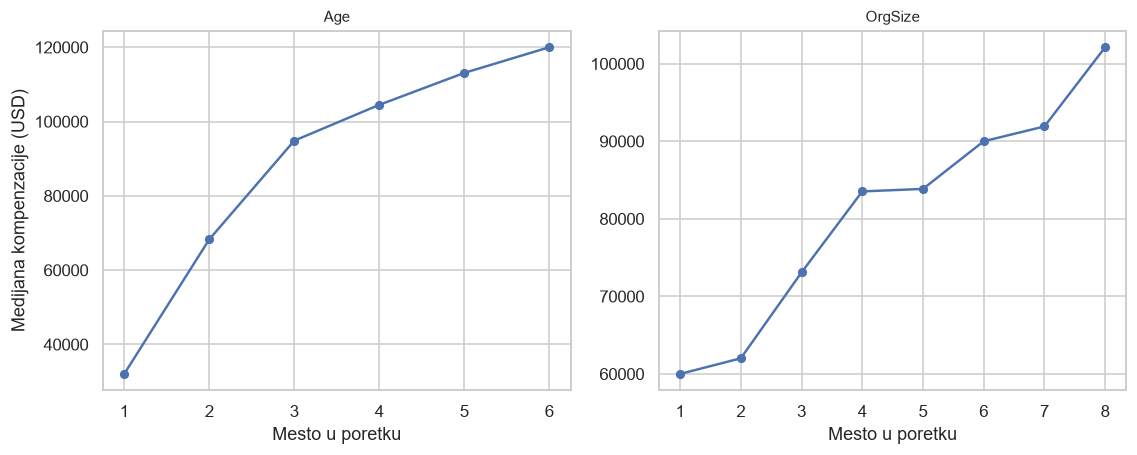

Age: korak od kategorije do kategorije, u dolarima
  +36,207, +26,579, +9,641, +8,598, +6,915
  najveći korak +36,207, najmanji +6,915, odnos 5.2 puta

OrgSize: korak od kategorije do kategorije, u dolarima
  +2,015, +11,074, +10,442, +326, +6,143, +1,909, +10,215
  najveći korak +11,074, najmanji +326, odnos 34.0 puta



In [128]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
for ax, column in zip(axes, ORDERED):
    real = [v for v in train[column].dropna().unique() if v != NOT_ANSWERED]
    order = sorted(real, key=band_start)
    medians = [train.loc[train[column] == value, TARGET].median() for value in order]
    ax.plot(range(1, len(order) + 1), medians, marker="o", markersize=5,
            linewidth=1.6, color="#4C72B0")
    ax.set_title(column, fontsize=10)
    ax.set_xlabel("Mesto u poretku")
    ax.set_xticks(range(1, len(order) + 1))
axes[0].set_ylabel("Medijana kompenzacije (USD)")
plt.tight_layout()
plt.show()

for column in ORDERED:
    real = [v for v in train[column].dropna().unique() if v != NOT_ANSWERED]
    order = sorted(real, key=band_start)
    medians = np.array([train.loc[train[column] == value, TARGET].median() for value in order])
    steps = np.diff(medians)
    print(f"{column}: korak od kategorije do kategorije, u dolarima")
    print(f"  {', '.join(f'{s:+,.0f}' for s in steps)}")
    print(f"  najveći korak {steps.max():+,.0f}, najmanji {steps.min():+,.0f}, "
          f"odnos {abs(steps.max() / steps.min()):.1f} puta")
    print()

**Zapažanje:** dve krive izgledaju bitno drugačije. Kod uzrasta je prvi korak **+36.207 dolara**, a
poslednji **+6.915** — razlika od **5,2 puta**; kriva strmo raste pa se poravna. Kod veličine firme koraci
idu od +326 do +11.074, dakle razlika je čak veća po odnosu (34 puta), ali su skokovi raspoređeni po celoj
krivoj umesto da budu skoncentrisani na jednom kraju.

**Tumačenje:** ovo objašnjava zašto brojevi ispadaju kako ispadaju. Ordinalno kodiranje povlači **pravu
liniju kroz mesta u poretku**. Kod veličine firme ta prava prolazi blizu svih tačaka, jer se plata penje
prilično ravnomerno od najmanje ka najvećoj firmi. Kod uzrasta prava ne može da isprati skok od tridesetak
hiljada dolara na početku i zaravnjenje na kraju — pa gubi taman toliko koliko smo izmerili.

Odnos najvećeg i najmanjeg koraka pri tome **nije** merilo — kod `OrgSize` je čak
veći. Bitno je gde su ti koraci: kod uzrasta je razlika sistematska, od velikih ka malim, a kod veličine
firme su nepravilno raspoređeni pa se u proseku ponište.

In [129]:
# Section 8.4 applied: the dummy columns become one ordered number. The order
# is the one worked out above, and it is kept so the test set can be given the
# same one. The width before the change is taken first, to show what it saves.
dummy_width_before = train["OrgSize"].nunique() - 1
train["OrgSize"] = ordinal_versions["OrgSize"].astype(float)

print(f"OrgSize je sada {train['OrgSize'].dtype}, vrednosti od "
      f"{train['OrgSize'].min():.0f} do {train['OrgSize'].max():.0f}")
print(f"kolona koje daje pri enkodiranju: {dummy_width_before} -> 1")
print(f"kolona u tabeli: {train.shape[1]}   "
      f"(broj se ne menja, menja se sadržaj jedne)")

OrgSize je sada float64, vrednosti od 1 do 8
kolona koje daje pri enkodiranju: 8 -> 1
kolona u tabeli: 448   (broj se ne menja, menja se sadržaj jedne)


### 31.5 Promenljive izvedene iz onoga što već imamo

Sve dosad smo promenljive izvlačili iz kolona koje su bile u neupotrebljivom obliku. Ovde probamo nešto
drugo: **promenljivu koja se računa iz kolona koje već imamo i koje su već u modelu.**

Nijedna od njih nije nov podatak iz ankete. Obe se dobijaju oduzimanjem dve postojeće kolone:

| nova promenljiva | računa se kao | šta bi trebalo da meri |
| --- | --- | --- |
| `YearsBeforeWork` | `YearsCode − WorkExp` | koliko je godina programirao pre prvog posla |
| `ToolGapWorkPersonal` | `ToolCountWork − ToolCountPersonal` | koliko mu je radni alat širi od privatnog |

Sve četiri kolone sa desne strane — `YearsCode`, `WorkExp`, `ToolCountWork` i `ToolCountPersonal` —
nasleđene su iz čišćenja i **već su u modelu**. Za nekoga ko programira petnaest godina a radi pet,
`YearsBeforeWork` je 10; to bi mogle biti godine školovanja ili samostalnog učenja pre ulaska u struku.

Obe merimo kao i sve ostalo. Ali uz merenje ide i provera koju smo uveli u sekciji 29 — da li je nova
kolona **tačna kombinacija** onih koje već imamo. Kod razlike dve postojeće kolone to pitanje je ozbiljno.

In [130]:
derived = pd.DataFrame({
    "YearsBeforeWork": train["YearsCode"] - train["WorkExp"],
    "ToolGapWorkPersonal": train["ToolCountWork"] - train["ToolCountPersonal"],
}, index=train.index).astype(float)

measured_derived = signal_table({name: derived[name] for name in derived.columns})
show(measured_derived)
print()

# Both are differences of columns the model already has, so the check from
# section 6 has something to say about them.
check = pd.concat([train[["YearsCode", "WorkExp", "ToolCountWork",
                          "ToolCountPersonal"]].astype(float), derived], axis=1)
keep, dropped = independent_columns(check)
print(f"uz četiri postojeće kolone iz kojih su izvedene, zavisnih: {len(dropped)}   {dropped}")

                          n kolona      R      R2 R2_prilag        p raspon_puta
ToolGapWorkPersonal  14,608      1  0.146  0.0212    0.0211  4.5e-70        13.1
YearsBeforeWork      14,608      1  0.136  0.0186    0.0185  1.9e-61         7.3

uz četiri postojeće kolone iz kojih su izvedene, zavisnih: 2   ['ToolGapWorkPersonal', 'WorkExp']


**Zapažanje:** obe promenljive same za sebe nisu slabe — `ToolGapWorkPersonal` ima prilagođeni R² od
**0,0211**, `YearsBeforeWork` **0,0185**, obe značajne i obe iznad poda iz 2.1.

Ali provera zavisnosti kaže drugo. Kad se te dve stave uz četiri kolone iz kojih su izvedene, od šest
kolona **dve su suvišne**. Koje dve — nije jednoznačno, i ispis to i pokazuje: izbačeni su
`ToolGapWorkPersonal` i `WorkExp`, iako je moglo i obrnuto. Svejedno je da li se ukloni razlika ili jedna
od kolona iz kojih je nastala, jer nose istu informaciju.

**Tumačenje:** to je bilo neizbežno, i razlog je jednostavan. `YearsBeforeWork` je po definiciji
`YearsCode − WorkExp`, a obe te kolone već su u modelu. Linearna regresija sabira i oduzima svoje kolone
sa težinama koje sama bira — pa razliku dve kolone, ako su obe već tu, **model može da napravi sam**.
Dodavanjem te razlike ne dajemo mu nijedan podatak koji nije imao, samo isti podatak treći put.

Zato je prilagođeni R² od 0,0211 obmanjujuć: on kaže koliko ta razlika objašnjava **sama za sebe**, a ne
koliko dodaje modelu. To je najoštriji primer razlike između te dve stvari na koji smo naišli — promenljiva
koja samostalno izgleda pristojno, a u modelu ne vredi ništa, i to ne malo nego tačno ništa.

**Odluka: nijednu ne pravimo.** Iz istog razloga ne pravimo ni druge razlike ili zbirove postojećih
kolona. Kombinacija koja **jeste** nova je ona koju linearni model ne može sam da sastavi — odnos dve
kolone ili njihov proizvod, dakle interakcija, o kojoj smo učili na predavanjima. To je, međutim, odluka
o obliku modela a ne o podacima, pa joj je mesto u fazi modelovanja, gde se bira i sam model.

### 31.6 Šta zadržavamo

Sekcija je donela pet odluka i sve su izmerene:

- **`EmploymentAddl`** prestaje da bude kategorijska kolona sa 97 vrednosti i postaje **devet binarnih
  kolona**; puna kategorija bi dala +0,0054 umesto +0,0021, ali za 87 kolona više;
- **`Currency` ostaje netaknuta**, iako nosi 97 kolona, jer preko zemlje dodaje +0,0272;
- **`OrgSize` prelazi na ordinalno kodiranje**, jedna kolona umesto osam;
- **`Age` ostaje u dummy obliku**, jer bi ordinalno kodiranje izgubilo 0,0372;
- **izvedene razlike se ne prave**, jer ih linearni model može sam da sastavi.

In [131]:
# Both changes are already applied, each in its own subsection; what is left
# is to put the state before and after the section side by side.
categorical_now = sum(1 for c in train.columns
                      if c not in (TARGET, TARGET_LOG) and is_text(train[c]))
encoded_now = sum(train[c].nunique() - 1 for c in train.columns
                  if c not in (TARGET, TARGET_LOG) and is_text(train[c]))

print(f"{'':<34} {'pre sekcije':>12} {'posle':>7}")
print(f"{'kolona u tabeli':<34} {columns_before_section8:>12} {train.shape[1]:>7}")
print(f"{'kategorijskih kolona':<34} {categorical_before_section8:>12} {categorical_now:>7}")
print(f"{'kolona koje bi enkodiranje dalo':<34} {encoded_before_section8:>12} {encoded_now:>7}")
print()
print(f"dodato po stavci iz EmploymentAddl: +{len(kept_extra)}")
print(f"izbačeno kategorijskih kolona:      -{len(missed)}")
print(f"OrgSize: osam dummy kolona zamenjeno jednom brojčanom, "
      f"vrednosti od {train['OrgSize'].min():.0f} do {train['OrgSize'].max():.0f}")

                                    pre sekcije   posle
kolona u tabeli                             440     448
kategorijskih kolona                         35      33
kolona koje bi enkodiranje dalo             435     331

dodato po stavci iz EmploymentAddl: +9
izbačeno kategorijskih kolona:      -1
OrgSize: osam dummy kolona zamenjeno jednom brojčanom, vrednosti od 1 do 8


### Šta sekcija ostavlja sledećoj

Skup je posle svih izmena **manji nego što je bio u kolonama koje idu u model**, iako je broj kolona u
tabeli porastao. Razlog je što se kategorijska kolona sa 97 vrednosti pretvorila u devet binarnih, a
kolona sa osam kategorija u jednu brojčanu — a to se vidi tek kad se prebroji koliko kolona sve zajedno
daje pri enkodiranju.

Četiri nalaza se prenose dalje:

- **prag iz sekcije 26 je propustio jednu multi-select kolonu**, i ta kolona je ispala jedna od korisnijih
  u ovom delu. Postupak koji smo tada koristili nije bio pogrešan, ali jeste bio nepotpun bez naknadne
  provere;
- **valuta nije ponavljanje zemlje** — dodaje četiri puta više od tipičnog anketnog obeležja, jer razlikuje
  onoga ko je u istoj zemlji plaćen u stranoj valuti;
- **poredak nije dovoljan uslov za ordinalno kodiranje.** Mora biti i ravnomeran, što je kod veličine
  firme slučaj a kod uzrasta nije;
- **razlika dve kolone koje već imamo nije nova promenljiva.** Linearni model je pravi sam, pa je dodavanje
  samo ponavljanje — bez obzira na to kako izgleda kad se meri samostalno.

Ostaje još da se ceo skup pogleda kao celina: koliko se promenljive međusobno preklapaju i da li je nešto
od onoga što smo napravili suvišno pored ostalog. Time se bavi sekcija 32.

## 32. Ceo skup kao celina

Osam sekcija je pravilo promenljive, svaku merilo posebno i svaku branilo svojim kriterijumom. Ostaju dva
pitanja koja se ne mogu postaviti dok se ne završi sve ostalo.

**Koliko je svaka sekcija zapravo donela?** Do sada smo svaki put merili prirast prema stanju u tom
trenutku, ali to nikad nije bilo sabrano.

**Da li se promenljive međusobno preklapaju?** Napravili smo ih preko tri stotine, i to iz istih izvornih
kolona. Da neka od njih ponavlja drugu, to bi bila kolinearnost o kojoj smo učili, i merimo je VIF-om.

### 32.1 Koliko kolona model zapravo ima

Pre svega treba razjasniti jednu razliku koja se do sada podrazumevala, a od ove sekcije postaje bitna:
**broj kolona u tabeli nije broj kolona u modelu.**

U tabeli `train` svaka promenljiva zauzima jedno mesto, pa i `Country`, iako u sebi ima 62 različite
vrednosti. Ali regresija ne ume da radi sa tekstom — kategorijska promenljiva u nju ulazi kao **dummy
kolone, po jedna za svaku kategoriju osim jedne**, kao što smo učili na predavanjima. Tako jedna kolona
tabele postaje 61 kolona modela.

Kod brojčanih promenljivih razlike nema: jedna kolona tabele je jedna kolona modela. Zato se dva broja
razilaze samo onoliko koliko imamo kategorijskih promenljivih sa mnogo vrednosti — a imamo `Currency` sa
98, `Country` sa 62, `DevType` sa 32.

Ispis ispod prvo prikazuje to razilaženje, pa tek onda meri koliko je koja sekcija donela.

In [132]:
def dummies_for(columns):
    """Categorical columns turned into dummy variables, numeric ones left alone."""
    parts = []
    for column in columns:
        if is_text(train[column]):
            parts.append(pd.get_dummies(train[column].astype(str), prefix=column,
                                        drop_first=True, dtype=float))
        else:
            parts.append(train[[column]].astype(float))
    return pd.concat(parts, axis=1) if parts else pd.DataFrame(index=train.index)


# Indicators made in section 4, one per multi-select question, as opposed to the
# ones inherited from the cleaning notebook.
questions_indicators = [ANSWERED_PREFIX + name for name in questions
                        if ANSWERED_PREFIX + name in train.columns]

# The same reading as in 8.1, except OrgSize is a number by now.
inherited_numeric = [c for c in train.columns
                     if c not in (TARGET, TARGET_LOG) and train[c].dtype.kind in "if"
                     and not c.startswith((COUNT_PREFIX, KEPT_PREFIX, ANSWERED_PREFIX,
                                           ITEM_PREFIX))
                     and not RANK_NAME.fullmatch(c)]
inherited_indicators = [c for c in train.columns
                        if c.startswith(ANSWERED_PREFIX) and c not in questions_indicators]
inherited_categorical = [c for c in train.columns
                         if is_text(train[c]) and c not in (TARGET, TARGET_LOG)
                         and c != "Country"]

blocks = {
    "zemlja i staž": dummies_for(["Country", "WorkExp"]),
    "ostale nasleđene kolone": dummies_for([c for c in inherited_categorical]
                                           + [c for c in inherited_numeric if c != "WorkExp"]
                                           + inherited_indicators),
    "brojevi izabranih stavki (4)": train[[c for c in train.columns
                                           if c.startswith((COUNT_PREFIX, KEPT_PREFIX))]
                                          + questions_indicators].astype(float),
    "pojedinačne stavke (5 i 8)": train[[c for c in train.columns
                                         if c.startswith(ITEM_PREFIX)]].astype(float),
    "rangiranja (6)": train[kept_ranks].astype(float),
}

def build_up(order):
    """Adjusted R² after each block is added, in the order given."""
    running, result, previous = [], [], None
    for label in order:
        running.append(blocks[label])
        design = pd.concat(running, axis=1)
        keep, _ = independent_columns(design)
        model = sm.OLS(train[TARGET_LOG].to_numpy(),
                       sm.add_constant(design[keep], has_constant="add").to_numpy()).fit()
        result.append((label, blocks[label].shape[1], model.rsquared_adj,
                       None if previous is None else model.rsquared_adj - previous))
        previous = model.rsquared_adj
    return result


predictors_now = [c for c in train.columns if c not in (TARGET, TARGET_LOG)]
text_now = [c for c in predictors_now if is_text(train[c])]
print("kolona u tabeli naspram kolona u modelu:")
print(f"  prediktora u tabeli:            {len(predictors_now)}")
print(f"    od toga brojčanih:            {len(predictors_now) - len(text_now)}   "
      f"(svaka daje jednu kolonu modela)")
print(f"    od toga kategorijskih:        {len(text_now)}   "
      f"(svaka daje onoliko kolona koliko ima kategorija, manje jednu)")
print()
print("  najveće kategorijske i koliko kolona daju:")
for column in sorted(text_now, key=lambda c: -train[c].nunique())[:4]:
    print(f"    {column:<16} {train[column].nunique():>3} kategorija -> {train[column].nunique() - 1:>3} kolona")
expansion = sum(train[c].nunique() - 1 for c in text_now)
print(f"    ostale {len(text_now) - 4} kategorijske zajedno -> "
      f"{expansion - sum(train[c].nunique() - 1 for c in sorted(text_now, key=lambda c: -train[c].nunique())[:4])} kolona")
print(f"  ukupno kolona u modelu:         "
      f"{len(predictors_now) - len(text_now) + expansion}")
print()

running, previous = [], None
for label, block in blocks.items():
    running.append(block)
    design = pd.concat(running, axis=1)
    keep, _ = independent_columns(design)
    model = sm.OLS(train[TARGET_LOG].to_numpy(),
                   sm.add_constant(design[keep], has_constant="add").to_numpy()).fit()
    gain = "" if previous is None else f"{model.rsquared_adj - previous:>+9.4f}"
    print(f"{label:<30} {block.shape[1]:>5} kolona   prilagođeni={model.rsquared_adj:.4f} {gain}")
    previous = model.rsquared_adj

full_design = pd.concat(running, axis=1)
print()
print(f"ukupno kolona u modelu: {full_design.shape[1]}")
print(f"redova po koloni:       {len(train) / full_design.shape[1]:.0f}")
print()

# What each block gets depends on what is already in the model, so the same
# blocks are added once more in the opposite order.
made_here = ["brojevi izabranih stavki (4)", "pojedinačne stavke (5 i 8)", "rangiranja (6)"]
inherited_blocks = ["zemlja i staž", "ostale nasleđene kolone"]
reverse = build_up(["zemlja i staž"] + made_here + ["ostale nasleđene kolone"])

print("isti blokovi, obrnutim redom:")
for label, size, value, gain in reverse:
    shown = "" if gain is None else f"{gain:>+9.4f}"
    print(f"  {label:<30} {size:>5} kolona   prilagođeni={value:.4f} {shown}")

forward = build_up(list(blocks))
made_forward = sum(g for l, _, _, g in forward if l in made_here and g is not None)
made_reverse = sum(g for l, _, _, g in reverse if l in made_here and g is not None)
print()
print(f"ono što smo napravili u ovom delu dobija {made_forward:+.4f} kad se dodaje poslednje,")
print(f"a {made_reverse:+.4f} kad se dodaje pre ostalih nasleđenih kolona")

kolona u tabeli naspram kolona u modelu:
  prediktora u tabeli:            446
    od toga brojčanih:            413   (svaka daje jednu kolonu modela)
    od toga kategorijskih:        33   (svaka daje onoliko kolona koliko ima kategorija, manje jednu)

  najveće kategorijske i koliko kolona daju:
    Currency          98 kategorija ->  97 kolona
    Country           62 kategorija ->  61 kolona
    DevType           32 kategorija ->  31 kolona
    Industry          16 kategorija ->  15 kolona


    ostale 29 kategorijske zajedno -> 127 kolona


  ukupno kolona u modelu:         744

zemlja i staž                     62 kolona   prilagođeni=0.5763 


ostale nasleđene kolone          284 kolona   prilagođeni=0.6812   +0.1049


brojevi izabranih stavki (4)      48 kolona   prilagođeni=0.6860   +0.0048


pojedinačne stavke (5 i 8)       314 kolona   prilagođeni=0.7028   +0.0168


rangiranja (6)                    36 kolona   prilagođeni=0.7079   +0.0051

ukupno kolona u modelu: 744
redova po koloni:       20



isti blokovi, obrnutim redom:
  zemlja i staž                     62 kolona   prilagođeni=0.5763 
  brojevi izabranih stavki (4)      48 kolona   prilagođeni=0.6032   +0.0269
  pojedinačne stavke (5 i 8)       314 kolona   prilagođeni=0.6431   +0.0399
  rangiranja (6)                    36 kolona   prilagođeni=0.6513   +0.0082
  ostale nasleđene kolone          284 kolona   prilagođeni=0.7079   +0.0566



ono što smo napravili u ovom delu dobija +0.0267 kad se dodaje poslednje,
a +0.0750 kad se dodaje pre ostalih nasleđenih kolona


**Zapažanje:** u tabeli je **446 prediktora**, ali u modelu **744 kolone**. Razlika dolazi od 33
kategorijske promenljive: `Currency` sama daje 97 kolona, `Country` 61, `DevType` 31, `Industry` 15, a
ostalih 29 zajedno 127. Brojčanih promenljivih je 413 i svaka daje po jednu kolonu.

Na 14.608 redova to znači **20 redova po jednoj koloni modela** — dakle svaki koeficijent koji model
procenjuje oslanja se u proseku na dvadesetak ispitanika.

Konačan model ima **prilagođeni R² od 0,7079**, a evo kako se do njega dolazi kad se blokovi dodaju redom
kojim su nastajali:

| blok | kolona | prilagođeni R² | prirast |
| --- | --- | --- | --- |
| zemlja i staž | 62 | 0,5763 | — |
| ostale nasleđene kolone | 284 | 0,6812 | +0,1049 |
| brojevi izabranih stavki (4) | 48 | 0,6860 | +0,0048 |
| pojedinačne stavke (5 i 8) | 314 | 0,7028 | +0,0168 |
| rangiranja (6) | 36 | 0,7079 | +0,0051 |

**Tumačenje:** dvadeset redova po koloni je malo. Taj odnos je broj redova podeljen brojem kolona modela, i kaže koliko ispitanika u proseku stoji iza jednog koeficijenta koji se procenjuje — što je manji, na tim se manje ljudi svaki koeficijent oslanja. To je isti odnos koji nas je zabrinjavao u sekciji 28 i
razlog zbog kog u modelovanju Ridge i Lasso nisu opcioni — kad model ima toliko kolona, obična regresija
lako nauči slučajne razlike umesto stvarnih.

Sam rezultat je ipak dobar. Sedamdeset odsto varijanse logaritmovane plate, i to iz jedne ankete, je
znatno više od 0,5544 koliko daje sama zemlja i mnogo više nego što bi se očekivalo posle sekcije 25, gde
nijedno pojedinačno obeležje nije prelazilo 0,16.

**Zapažanje uz obrnut redosled:** isti blokovi, dodati obrnutim redom, daju sasvim druge priraste. Ono što
smo napravili u ovom delu dobija **+0,0267 kad se dodaje poslednje**, a **+0,0750 kad se dodaje pre
nasleđenih kolona**. Nasleđene kolone istovremeno padaju sa +0,1049 na +0,0566. Krajnji rezultat je u oba
slučaja **isti — 0,7079**.

**Tumačenje:** ovo na prvi pogled deluje kao protivrečnost, a nije. Prirast nije osobina bloka nego
**osobina bloka i onoga što je već u modelu**.

Primer koji to objašnjava: i valuta i broj izabranih tehnologija delom govore o tome koliko je razvijeno
tržište na kom neko radi. Taj zajednički deo objasniće **onaj blok koji uđe prvi**, a drugi će dobiti samo
ono što je preostalo. Zajednički deo, dakle, ne pripada ni jednom ni drugom bloku pojedinačno — pripada
obojici, a redosled odlučuje ko će ga u tabeli dobiti.

Zato zbir mora biti isti bez obzira na redosled: ista informacija je u modelu, samo drugačije raspoređena
po redovima tabele.

Praktična posledica je da **nijedan od ta dva broja nije „pravi" doprinos ovog dela**. Pošten opseg
je između njih: od +0,0267 do +0,0750, dakle od četiri do deset puta više od onoga što donese tipično
anketno pitanje. Zato prikazujemo oba redosleda umesto da izaberemo povoljniji.

### 32.2 Koliko se promenljive međusobno preklapaju

Sa predavanja znamo da kolinearnost ne kvari predviđanja modela ali kvari **koeficijente**: kad dve
kolone nose skoro istu informaciju, model ne može da razluči koliko pripada kojoj, pa im koeficijenti
postaju nestabilni i nečitljivi. Na predavanjima smo uz to izričito učili da se kolinearnost između tri i
više promenljivih **ne vidi u matrici korelacije parova** i da uvek treba proveriti VIF.

Kod nas je razlog za sumnju konkretan. Iz istog pitanja smo izveli i broj izabranih stavki i pojedinačne
stavke — a broj izabranih stavki je zbir tih pojedinačnih. Ako su sve stavke jednog pitanja zadržane, taj
zbir bi bio tačna kombinacija; nije se desilo, ali je blizu.

VIF za jednu kolonu dobija se tako što se ona regresuje na sve ostale, pa je `VIF = 1 / (1 − R²)`. Ako
kolona sa ostalima nema nikakve veze, R² je nula i VIF je **1**; ako je ostale objašnjavaju napola, VIF je
2; ako je objašnjavaju 90%, VIF je 10. Pragovi su oni sa predavanja: **1** znači da preklapanja nema,
**5 do 10** umereno, **preko 10** ozbiljno.

Sa preko sedam stotina kolona to bi značilo sedam stotina modela, pa koristimo poznatu prečicu: isti
brojevi stoje na **dijagonali inverzne matrice korelacije**, koja se računa jednom.

Ispis prikazuje **celu raspodelu po grupama promenljivih**, a ne samo najgore vrednosti — jer je za odluku
jednako važno koliko je kolona čisto koliko i koliko ih je sporno.

In [133]:
def variance_inflation(design):
    """VIF for every column at once.

    Regressing each column on all the others would mean one model per column;
    the same numbers stand on the diagonal of the inverted correlation matrix.
    """
    correlation = np.corrcoef(design.to_numpy(dtype=float), rowvar=False)
    return pd.Series(np.diag(np.linalg.inv(correlation)), index=design.columns)


# Columns that never change carry no correlation at all and would break the
# matrix; with an exact combination among the rest it could not be inverted.
varying = [c for c in full_design.columns if full_design[c].nunique() > 1]
independent, dependent = independent_columns(full_design[varying])
print(f"kolona u modelu: {full_design.shape[1]}   "
      f"bez konstantnih: {len(varying)}   bez zavisnih: {len(independent)}")

vif = variance_inflation(full_design[independent]).sort_values(ascending=False)

vif_groups = {
    "kolone po stavci  Chose_": [c for c in vif.index if c.startswith(ITEM_PREFIX)],
    "brojevi stavki    Count_": [c for c in vif.index if c.startswith(COUNT_PREFIX)],
    "odnos zadržanog   KeptShare_": [c for c in vif.index if c.startswith(KEPT_PREFIX)],
    "indikatori        NotAnswered_": [c for c in vif.index if c.startswith(ANSWERED_PREFIX)],
    "rangiranja": [c for c in vif.index if c in kept_ranks],
    "nasleđene brojčane": [c for c in vif.index if c in inherited_numeric],
}
covered = {c for columns in vif_groups.values() for c in columns}
vif_groups["dummy kolone kategorijskih"] = [c for c in vif.index if c not in covered]

# The bands the lectures use to read a VIF: one means no overlap, five to ten
# moderate, above ten serious.
BANDS = [(1, 2, "1-2"), (2, 5, "2-5"), (5, 10, "5-10"), (10, np.inf, "> 10")]

print()
print(f"{'grupa':<32} {'kolona':>7} " + " ".join(f"{name:>6}" for _, _, name in BANDS)
      + f" {'medijana':>9} {'najveći':>9}")
for label, columns in vif_groups.items():
    values = vif[columns]
    counts = " ".join(f"{int(((values >= low) & (values < high)).sum()):>6}"
                      for low, high, _ in BANDS)
    print(f"{label:<32} {len(columns):>7} {counts} {values.median():>9.2f} {values.max():>9.1f}")

# Everything except the dummy columns, i.e. the variables this notebook made
# plus the plain numeric ones it inherited.
engineered = [c for c in vif.index if c not in vif_groups["dummy kolone kategorijskih"]]

print()
print("pet najvećih i pet najmanjih među promenljivama koje smo napravili:")
edges = pd.concat([vif[engineered].head(5), vif[engineered].tail(5)])
print(edges.round(2).to_string())

kolona u modelu: 744   bez konstantnih: 744   bez zavisnih: 742

grupa                             kolona    1-2    2-5   5-10   > 10  medijana   najveći
kolone po stavci  Chose_             314    160    142     12      0      1.97       9.6
brojevi stavki    Count_              27      0      4     12     11      9.59     182.2
odnos zadržanog   KeptShare_           7      0      5      2      0      4.47       5.6
indikatori        NotAnswered_        23      3      6      6      8      8.82     253.7
rangiranja                            36     33      3      0      0      1.66       2.2
nasleđene brojčane                     6      4      0      2      0      1.58       9.0
dummy kolone kategorijskih           329     99     79     55     96      4.06    1758.1

pet najvećih i pet najmanjih među promenljivama koje smo napravili:
NotAnswered_LearnCode                             253.70
Count_AIToolDon't plan to use AI for this task    182.17
Count_CommPlatformWantToWorkWith        

**Zapažanje:** raspodela je vrlo različita od grupe do grupe.

| grupa | kolona | VIF 1–2 | 2–5 | 5–10 | > 10 | medijana | najveći |
| --- | --- | --- | --- | --- | --- | --- | --- |
| kolone po stavci `Chose_` | 314 | 160 | 142 | 12 | **0** | 1,97 | 9,6 |
| brojevi stavki `Count_` | 27 | 0 | 4 | 12 | **11** | 9,59 | 182,2 |
| odnos zadržanog `KeptShare_` | 7 | 0 | 5 | 2 | 0 | 4,47 | 5,6 |
| indikatori `NotAnswered_` | 23 | 3 | 6 | 6 | **8** | 8,82 | 253,7 |
| rangiranja | 36 | 33 | 3 | 0 | 0 | 1,66 | 2,2 |
| nasleđene brojčane | 6 | 4 | 0 | 2 | 0 | 1,58 | 9,0 |
| dummy kolone kategorijskih | 329 | 99 | 79 | 55 | **96** | 4,06 | 1758,1 |

**Tumačenje:** dve grupe koje smo pravili su gotovo besprekorne, a dve su problematične, i razlika među
njima ima isti uzrok.

**Kolone po stavci i rangiranja su čiste.** Kod stavki je medijana 1,97 — dakle tipična kolona po stavci
sa svim ostalima deli oko polovine varijanse, što je za 744 kolone malo — i **nijedna od 314 ne prelazi
10**. Kod rangiranja je još bolje: medijana 1,66, najveći 2,2. Obe grupe imaju istu osobinu: svaka njihova
kolona govori o **jednoj stavci**, a ne o celom pitanju.

**Brojevi i indikatori nisu.** Kod `Count_` je medijana 9,59, a jedanaest od 27 kolona prelazi 10; kod
indikatora osam od 23. Obe grupe govore o **celom pitanju** — koliko je stavki izabrano, odnosno da li je
pitanje uopšte odgovoreno — a to isto već nose sve kolone po stavci tog pitanja zajedno.

To je usput i objašnjenje zašto ovo preklapanje nismo mogli da vidimo ranije: u sekciji 27, kad su brojevi
i indikatori napravljeni, kolona po stavci još nije bilo.

Kod dummy kolona je slika najgora, ali je te prirode da se ne može popraviti — tome se vraćamo u 9.3.

### Grafik 26 — odakle preklapanje dolazi

**Motivacija:** VIF je jedan broj po koloni i kaže **koliko** se ona preklapa sa svim ostalima, ali ne i
**sa kojima**. Bez toga se ne zna šta uraditi: ako se kolona preklapa sa dvadeset drugih pomalo, to je
druga situacija nego ako je skoro tačno određena jednom grupom kolona.

Zato uzimamo kolonu sa najvećim VIF-om i gledamo **sve promenljive izvedene iz istog pitanja** — indikator
neodgovaranja, broj izabranih stavki i pojedinačne stavke. Crtamo njihove međusobne korelacije kao mapu, u
kojoj je svako polje korelacija dve promenljive: crveno znači da rastu zajedno, plavo da jedna raste kad
druga opada, a belo da veze nema. Ako je uzrok onaj koji smo pretpostavili u 9.2, videće se kao pravilna
struktura — cela vrsta i cela kolona iste boje — a ne kao nasumične mrlje.

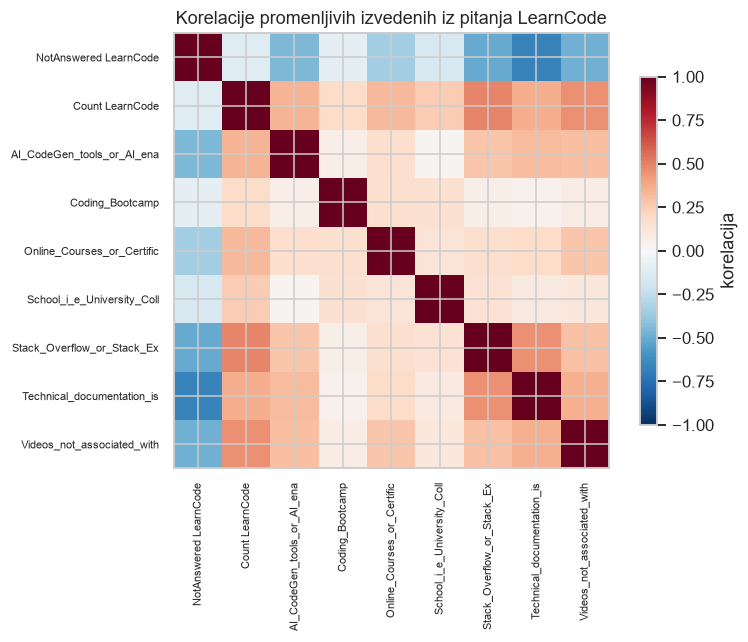

kolona sa najvećim VIF-om: NotAnswered_LearnCode  (253.7)
pitanje iz kog su sve ove promenljive izvedene: LearnCode

korelacija indikatora sa brojem izabranih stavki: -0.122
korelacija indikatora sa pojedinačnim stavkama: od -0.671 do -0.093
stavki iz tog pitanja u modelu: 7 od 13 ponuđenih


In [134]:
worst = vif[engineered].idxmax()
question = worst.replace(ANSWERED_PREFIX, "")
family = ([ANSWERED_PREFIX + question, COUNT_PREFIX + question]
          + [c for c in train.columns if c.startswith(f"{ITEM_PREFIX}{question}__")])
family = [c for c in family if c in train.columns]

labels = [c.replace(f"{ITEM_PREFIX}{question}__", "").replace(ANSWERED_PREFIX, "NotAnswered ")
          .replace(COUNT_PREFIX, "Count ")[:26] for c in family]
correlation = train[family].astype(float).corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
image = ax.imshow(correlation.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(family)))
ax.set_xticklabels(labels, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(family)))
ax.set_yticklabels(labels, fontsize=7.5)
ax.set_title(f"Korelacije promenljivih izvedenih iz pitanja {question}")
fig.colorbar(image, ax=ax, shrink=0.8, label="korelacija")
plt.tight_layout()
plt.show()

indicator = correlation.loc[ANSWERED_PREFIX + question].drop(ANSWERED_PREFIX + question)
print(f"kolona sa najvećim VIF-om: {worst}  ({vif[worst]:.1f})")
print(f"pitanje iz kog su sve ove promenljive izvedene: {question}")
print()
print(f"korelacija indikatora sa brojem izabranih stavki: "
      f"{correlation.loc[ANSWERED_PREFIX + question, COUNT_PREFIX + question]:.3f}")
print(f"korelacija indikatora sa pojedinačnim stavkama: od {indicator.min():.3f} "
      f"do {indicator.max():.3f}")
print(f"stavki iz tog pitanja u modelu: "
      f"{sum(1 for c in family if c.startswith(ITEM_PREFIX))} "
      f"od {len(vocabulary[question])} ponuđenih")

**Zapažanje:** mapa ima pravilnu strukturu, ne nasumičnu. Prva vrsta i prva kolona pripadaju indikatoru
neodgovaranja i **plave su prema svim stavkama** — dakle indikator raste tačno kad stavke opadaju, sa
korelacijama od **−0,671 do −0,093**. Sa brojem izabranih stavki indikator je korelisan sa −0,122.

Ostatak mape, gde se stavke porede međusobno, uglavnom je bled — pojedinačne stavke se međusobno slabo
preklapaju.

Ispis dodaje i podatak koji objašnjava zašto veza nije još jača: iz tog pitanja je u modelu **7 od 13
ponuđenih stavki**.

**Tumačenje:** ovo potvrđuje ono što je VIF nagovestio, i pokazuje tačan mehanizam.

Indikator kaže „ovaj ispitanik nije odgovorio na pitanje". Kolone po stavci to iste govore zajedno: ko nije
odgovorio ima **nulu u svakoj od njih**. Zato je indikator negativno korelisan sa svakom stavkom
pojedinačno, i zato mu VIF ispada 253,7 — ne zato što ga jedna kolona ponavlja, nego zato što ga sedam
kolona zajedno gotovo tačno određuje.

Da su sve stavke bile zadržane, veza bi bila **tačna**, a ne samo jaka: indikator bi bio jedinica tačno
kad su sve stavke nula. Pošto je zadržano sedam od trinaest, ostaje mogućnost da je neko odgovorio birajući
samo stavke koje nismo zadržali — pa je veza jaka ali ne i savršena.

Isti mehanizam objašnjava i zašto su kolone po stavci međusobno čiste. Nijedna od njih ne govori o celom
pitanju, pa se ni jedna ne može sastaviti od ostalih.

### 32.3 Šta radimo sa preklapanjem

Sa predavanja znamo dva rešenja za kolinearnost: **ukloniti jedan od kolinearnih prediktora** ili ih
**kombinovati**. Pre nego što bilo šta uklonimo, vredi razdvojiti dve vrste preklapanja koje smo izmerili,
jer se ne rešavaju isto.

**Kod dummy kolona preklapanje je ugrađeno.** Kolone jedne kategorijske promenljive po konstrukciji ne mogu
biti nezavisne — ako je ispitanik iz Nemačke, nije ni iz jedne od preostalih šezdeset zemalja. Visok VIF
tu ne znači da smo nešto pogrešili nego da promenljiva ima mnogo kategorija. Jedino „rešenje" bilo bi
izbaciti celu promenljivu, a to smo već merili u sekcijama 30 i 8 i odlučili drugačije.

**Kod promenljivih koje smo sami napravili preklapanje je naše delo**, i tu se može nešto uraditi. Zato
merimo koliko košta da se izbace one kod kojih je VIF preko granice koju smo učili na predavanjima.

In [135]:
# The threshold from the lectures: above ten the overlap counts as serious.
VIF_LIMIT = 10

overlapping = [c for c in engineered if vif[c] > VIF_LIMIT]
print(f"promenljivih koje smo napravili sa VIF preko {VIF_LIMIT}: {len(overlapping)}")
for prefix, label in [(COUNT_PREFIX, "Count_"), (ANSWERED_PREFIX, "NotAnswered_"),
                      (ITEM_PREFIX, "Chose_"), (KEPT_PREFIX, "KeptShare_")]:
    print(f"  {label:<14} {sum(1 for c in overlapping if c.startswith(prefix)):>3}")
print(f"  rangovi i nasleđene numeričke {sum(1 for c in overlapping if not c.startswith((COUNT_PREFIX, ANSWERED_PREFIX, ITEM_PREFIX, KEPT_PREFIX))):>3}")
print()

kept_after_vif = [c for c in independent if c not in overlapping]
with_all = sm.OLS(train[TARGET_LOG].to_numpy(),
                  sm.add_constant(full_design[independent], has_constant="add").to_numpy()).fit()
without_overlap = sm.OLS(train[TARGET_LOG].to_numpy(),
                         sm.add_constant(full_design[kept_after_vif],
                                         has_constant="add").to_numpy()).fit()

print(f"model sa svim kolonama:        prilagođeni={with_all.rsquared_adj:.4f}   "
      f"kolona={len(independent)}")
print(f"bez {len(overlapping)} sa VIF > {VIF_LIMIT}:          prilagođeni={without_overlap.rsquared_adj:.4f}   "
      f"kolona={len(kept_after_vif)}")
print(f"cena izbacivanja:              "
      f"{without_overlap.rsquared_adj - with_all.rsquared_adj:+.5f}")
print(f"dozvoljeni gubitak:            {typical_gain:.4f}")

promenljivih koje smo napravili sa VIF preko 10: 19
  Count_          11
  NotAnswered_     8
  Chose_           0
  KeptShare_       0
  rangovi i nasleđene numeričke   0



model sa svim kolonama:        prilagođeni=0.7079   kolona=742
bez 19 sa VIF > 10:          prilagođeni=0.7075   kolona=723
cena izbacivanja:              -0.00042
dozvoljeni gubitak:            0.0072


**Zapažanje:** VIF preko 10 ima **19 promenljivih koje smo napravili** — 11 brojeva izabranih stavki i 8
indikatora neodgovaranja. Nijedna kolona po stavci, nijedan odnos zadržanog i nijedan rang nisu među njima.

Izbacivanje tih 19 košta **0,00042** prilagođenog R², dakle model pada sa 0,7079 na 0,7075.

**Odluka: izbacujemo ih.** Cena je četiri desethiljadita dela, a dobija se devetnaest kolona manje i,
važnije, model u kome koeficijenti mogu da se čitaju.

**Tumačenje:** treba biti precizan oko toga šta se ovim gubi, jer na prvi pogled deluje da izbacujemo
podatak o neodgovaranju — a upravo smo u sekciji 27 pokazali da je on vredan.

Ne gubimo ga. Grafik 26 je pokazao **zašto** su ti indikatori suvišni: isti podatak nose kolone po stavci,
jer ko na pitanje nije odgovorio ima nulu u svakoj od njih. Informacija ostaje u skupu, samo prestaje da
bude u njemu dvaput. Isto važi i za brojeve izabranih stavki, koji su zbir istih tih kolona.

Izbacujemo, pri tome, **isključivo po izmerenom VIF-u**, a ne po tome iz kog pitanja promenljiva
dolazi. Ispis posle izbacivanja pokazuje šta to znači: među indikatorima koji ostaju jesu i oni za
`WorkExp`, `JobSat` i za četiri rang-pitanja, koje zaista ništa drugo ne pokriva, ali i indikatori
nekoliko pitanja koja **imaju** kolone po stavci. Kod njih se preklapanje izmerilo ispod granice od
10, pa nemamo razlog da ih diramo. Pravilo je, dakle, izmerena vrednost, a ne vrsta promenljive.

**Kod dummy kolona ne radimo ništa.** Njihov VIF je posledica toga što kategorijska promenljiva sa mnogo
kategorija po konstrukciji ima međusobno zavisne kolone — ako je ispitanik iz Nemačke, nije ni iz jedne od
preostalih šezdeset zemalja, pa se te kolone nužno prate. Jedini način da se to ukloni je izbaciti celu
promenljivu, a to smo za `Country` i `EmploymentAddl` već merili i odlučili, dok smo za `Currency` u
sekciji 31 izmerili da vredi zadržati je uprkos ceni.

Sa predavanja znamo i da kolinearnost **ne kvari predviđanja** nego procenu pojedinačnih koeficijenata. Za
model koji predviđa platu to znači da preostali visok VIF kod dummy kolona ne smeta u onome što merimo na
test skupu — ali smeta ako budemo hteli da tumačimo pojedinačne koeficijente. Ridge regresija sa predavanja
postoji upravo za ovakav slučaj i u fazi modelovanja je prvi kandidat.

In [136]:
def model_width(frame):
    """How many columns the table would give a regression after encoding."""
    predictors = [c for c in frame.columns if c not in (TARGET, TARGET_LOG)]
    text = [c for c in predictors if is_text(frame[c])]
    return len(predictors) - len(text) + sum(frame[c].nunique() - 1 for c in text)


before_table, before_model = train.shape[1], model_width(train)
train = train.drop(columns=overlapping)

print(f"izbačeno kolona: {len(overlapping)}")
print()
print(f"{'':<26} {'pre':>8} {'posle':>8}")
print(f"{'kolona u tabeli':<26} {before_table:>8} {train.shape[1]:>8}")
print(f"{'kolona u modelu':<26} {before_model:>8} {model_width(train):>8}")
print(f"{'redova po koloni modela':<26} {len(train) / before_model:>8.0f} "
      f"{len(train) / model_width(train):>8.0f}")
print()
remaining = [c for c in train.columns if c.startswith(ANSWERED_PREFIX)]
print(f"indikatora neodgovaranja koji ostaju: {len(remaining)}")
print(f"  {sorted(remaining)}")

izbačeno kolona: 19

                                pre    posle
kolona u tabeli                 448      429
kolona u modelu                 744      725
redova po koloni modela          20       20

indikatora neodgovaranja koji ostaju: 15
  ['NotAnswered_AIAgentChallenges', 'NotAnswered_AIFrustration', 'NotAnswered_CommPlatform', 'NotAnswered_Database', 'NotAnswered_JobSat', 'NotAnswered_JobSatPoints_1', 'NotAnswered_OfficeStackAsync', 'NotAnswered_SO_Actions_1', 'NotAnswered_SO_Dev_Content', 'NotAnswered_TechEndorse_1', 'NotAnswered_TechOppose_1', 'NotAnswered_ToolCountPersonal', 'NotAnswered_ToolCountWork', 'NotAnswered_Webframe', 'NotAnswered_WorkExp']


### Šta sekcija ostavlja sledećoj

Skup je proveren kao celina i iz njega je izbačeno devetnaest kolona koje su ponavljale ono što druge već
nose.

Četiri nalaza:

- **model sa svim promenljivama objašnjava 0,7079 varijanse logaritmovane plate**, a posle izbacivanja
  devetnaest kolona 0,7075 — u oba slučaja na dvadesetak redova po koloni;
- **doprinos ovog dela je između +0,0267 i +0,0750**, u zavisnosti od redosleda kojim se pripisuje —
  i oba broja su tačna, jer se blokovi preklapaju;
- **kolone po stavci su najčistije od svega što smo napravili** — nijedna od 314 nema VIF preko 10, dok ga
  ima 19 od 99 ostalih naših promenljivih. Razlog je što govore o jednoj stavci, a ne o celom pitanju;
- **preklapanje koje smo našli nije se moglo videti ranije**, jer je nastalo kombinacijom sekcija 27 i 5.

Ostaje da se sve što je ovde odlučeno **primeni i na test skup** — istim pragovima i istim vrednostima
izračunatim na treningu — pa da se oba skupa sačuvaju. Time se bavi poslednja sekcija.

## 33. Primena na test skup i čuvanje

Sve što je urađeno u ovom delu urađeno je **isključivo nad trening skupom**. Test skup nismo
koristili ni za jednu odluku od trenutka kad je u prethodnom delu odvojen — jedino što smo mu
upisali jeste logaritam ciljne promenljive u odeljku 24.3, a to je račun po redu koji iz podataka ništa
ne uči. To nije bila formalnost nego uslov da merenje na testu uopšte nešto znači.

Sada mu prilazimo prvi put, i to na tačno određen način: **na test skup se primenjuju iste transformacije,
sa istim pragovima i istim vrednostima izračunatim na treningu.** Ništa se iznova ne meri i ništa se ne
bira prema tome kako na testu ispada.

Ovo je najosetljiviji korak u ovom delu, jer se ovde najlakše potkrade ono što se zove **curenje
podataka**. Taj pojam nismo radili na predavanjima, pa ga odmah određujemo: curenje je kada u pripremu
podataka uđe bilo šta izračunato nad test skupom, čime test prestaje da meri ono zbog čega je i
odvojen. Dovoljno je da se jedna medijana izračuna nad celim skupom umesto nad treningom, ili da se
prag zastupljenosti stavki odredi ponovo, pa da test prestane da bude nezavisna provera.

### 33.1 Šta tačno treba primeniti

Redosled je isti kao redosled sekcija, i svaki korak koristi nešto što je izračunato na treningu:

| korak | šta se primenjuje | šta dolazi sa treninga |
| --- | --- | --- |
| sekcija 27 | brojevi izabranih stavki, indikatori, odnos zadržanog | medijane za popunjavanje |
| sekcija 27.4 | izbacivanje kolona koje su bile šum | spisak tih kolona |
| sekcija 28 | kolone po stavci | spisak stavki koje su prošle prag |
| sekcija 28 | izbacivanje multi-select kolona | spisak tih kolona |
| sekcija 29.4 | izbacivanje rangova koji su bili šum | spisak tih kolona |
| sekcija 30 | zemlja kao prvih 61 i „Other" | spisak zadržanih zemalja |
| sekcija 31.2 | kolone po stavci iz `EmploymentAddl` | spisak stavki koje su prošle prag |
| sekcija 31.4 | `OrgSize` kao redni broj | izvedeni poredak kategorija |
| sekcija 32.3 | izbacivanje kolona sa VIF preko 10 | spisak tih kolona |

Nijedan od tih spiskova i nijedna od tih vrednosti ne računa se iznova nad testom.

In [137]:
def item_columns_for(frame, sources):
    """The same per-item columns as in sections 5 and 8, built for another frame."""
    made = {}
    for column in sources:
        chosen = frame[column].fillna("").astype(str).map(lambda value: set(value.split(";")) - {""})
        for item in sorted(set().union(*chosen)):
            name = f"{ITEM_PREFIX}{clean_name(column, 40)}__{clean_name(item)}"
            made[name] = chosen.map(lambda picked, i=item: float(i in picked))
    return pd.DataFrame(made, index=frame.index)


def apply_everything(frame):
    """Every step this notebook took, with all values taken from the training set."""
    out = frame.copy()

    # Section 4: counts, indicators and ratios, filled with the training medians.
    features = multi_select_features(out).fillna(fill_values)
    out = pd.concat([out, features], axis=1)

    # Sections 5 and 8.2: one column per item that passed the threshold. An item
    # nobody in this frame chose simply gets a column of zeros.
    items_here = item_columns_for(out, item_sources)
    extra_here = item_columns_for(out, missed)
    out = pd.concat([out,
                     items_here.reindex(columns=kept_items, fill_value=0.0),
                     extra_here.reindex(columns=kept_extra, fill_value=0.0)], axis=1)

    # Section 7: the countries kept in training stay, everything else is "Other".
    out["Country"] = out["Country"].where(
        out["Country"].isin(country_counts.head(COUNTRY_KEEP).index), "Other")

    # Section 8.4: the order worked out on the training set.
    values = out["OrgSize"].map(ordinal_maps["OrgSize"])
    out["OrgSize"] = values.fillna(ordinal_versions["OrgSize"].median()).astype(float)

    # Everything the notebook dropped along the way.
    leaving = set(noise_features) | set(multi_select) | set(missed) | set(noise_ranks) | set(overlapping)
    return out.drop(columns=[c for c in leaving if c in out.columns])


test[TARGET_LOG] = np.log10(test[TARGET])
test_ready = apply_everything(test)

print(f"test skup pre:  {test.shape[0]:,} redova x {test.shape[1]} kolona")
print(f"test skup posle: {test_ready.shape[0]:,} redova x {test_ready.shape[1]} kolona")
print(f"trening skup:    {train.shape[0]:,} redova x {train.shape[1]} kolona")

test skup pre:  3,652 redova x 130 kolona
test skup posle: 3,652 redova x 429 kolona
trening skup:    14,608 redova x 429 kolona


**Zapažanje:** test skup je prošao kroz iste korake i sada ima **429 kolona**, tačno koliko i trening,
naspram 130 sa kojih je krenuo. Broj redova je nepromenjen — **3.652**, dakle nijedan ispitanik nije ni
izgubljen ni dodat.

**Tumačenje:** poklapanje broja kolona je nužan uslov, ali ne i dovoljan: kolone bi mogle biti iste po
broju a različite po imenu ili redosledu, a vrednosti unutar njih mogle bi da sadrže kategorije kojih u
treningu nema. To se proverava u nastavku.

### 33.2 Da li su skupovi usklađeni

Broj kolona koji se poklapa nije dovoljan dokaz da je sve u redu. Proveravamo četiri stvari, i svaka od
njih može da obori ceo posao ako ne prođe.

**Iste kolone, istim redom.** Ako se razlikuju, model istreniran na treningu ne može se ni primeniti na
test.

**Nema praznih polja.** U treningu smo ih popunili medijanama; ako su na testu ostale, negde nedostaje
vrednost za popunjavanje.

**Nema kategorija koje trening ne poznaje.** Ovo je zamka koja se lako previdi. Ako se u testu javi valuta
koje u treningu nema, enkodiranje bi za nju napravilo kolonu koju model nikad nije video — pa bi se dva
skupa razišla tek u fazi modelovanja, kad je kasno.

**Ciljna promenljiva je netaknuta.** Nju nismo ni smeli menjati.

In [138]:
print("provera usklađenosti trening i test skupa:")
print(f"  iste kolone, istim redom        "
      f"{list(train.columns) == list(test_ready.columns)}")
print(f"  praznih polja u treningu        {int(train.isna().sum().sum())}")
print(f"  praznih polja u testu           {int(test_ready.isna().sum().sum())}")
print(f"  ciljna promenljiva popunjena    "
      f"{train[TARGET].notna().all() and test_ready[TARGET].notna().all()}")
print()

unseen = {}
for column in [c for c in train.columns if is_text(train[c])]:
    extra = set(test_ready[column].dropna().unique()) - set(train[column].dropna().unique())
    if extra:
        unseen[column] = extra
print(f"kategorijskih kolona sa vrednostima kojih nema u treningu: {len(unseen)}")
for column, values in list(unseen.items())[:5]:
    print(f"  {column:<16} {len(values)} vrednosti, npr. {sorted(values)[:2]}")
print()

print(f"{'':<28} {'trening':>10} {'test':>10}")
print(f"{'redova':<28} {len(train):>10,} {len(test_ready):>10,}")
print(f"{'medijana kompenzacije':<28} {train[TARGET].median():>10,.0f} "
      f"{test_ready[TARGET].median():>10,.0f}")
print(f"{'udeo u grupi Other':<28} "
      f"{100 * (train['Country'] == 'Other').mean():>9.1f}% "
      f"{100 * (test_ready['Country'] == 'Other').mean():>9.1f}%")
print(f"{'prosečan Count_ jezika':<28} "
      f"{train['Count_LanguageHaveWorkedWith'].mean():>10.2f} "
      f"{test_ready['Count_LanguageHaveWorkedWith'].mean():>10.2f}")

provera usklađenosti trening i test skupa:
  iste kolone, istim redom        True
  praznih polja u treningu        0
  praznih polja u testu           0
  ciljna promenljiva popunjena    True

kategorijskih kolona sa vrednostima kojih nema u treningu: 1
  Currency         4 vrednosti, npr. ['BBD Barbadian dollar', 'MMK Myanmar kyat']

                                trening       test
redova                           14,608      3,652
medijana kompenzacije            81,210     81,210
udeo u grupi Other                 3.0%       3.3%
prosečan Count_ jezika             6.04       6.03


**Zapažanje:** tri provere prolaze — kolone su iste i istim redom, praznih polja nema ni u jednom skupu, a
ciljna promenljiva je popunjena svuda. Skupovi su i po sadržaju slični: ista medijana kompenzacije, udeo u
grupi `Other` 3,0% naspram 3,3%, prosečan broj jezika 6,04 naspram 6,03.

**Četvrta provera ne prolazi.** U koloni `Currency` test ima **četiri valute kojih u treningu nema** —
barbadoški dolar, mjanmarski kjat, mongolski tugrik i srednjoafrički franak — i one pogađaju **5
ispitanika**.

**Tumačenje:** ovo je tačno ono zbog čega provera postoji. Reč je o pet ljudi, ali problem nije u
njihovom broju nego u obliku: pri enkodiranju bi za svaku od te četiri valute nastala kolona koje u
treningu nema, pa bi test skup imao četiri kolone više od modela. To se ne bi videlo sada nego tek u fazi
modelovanja, i to kao greška koju je teško povezati sa uzrokom.

Ovo se, uz to, **nije moglo otkriti na trening skupu**. Sve dosad smo radili isključivo nad
njim, a ovaj problem po prirodi postoji samo kad se pojavi vrednost koju trening ne poznaje.

### 33.3 Ispravka: valute koje trening ne poznaje

Rešenje je isto ono koje smo primenili na zemlju u sekciji 30, samo u manjem obimu: uvodi se kategorija
`Other` u koju idu valute koje model ne može da nauči.

Da bi ta kategorija postojala i u treningu, u nju spajamo i **valute koje u treningu ima samo jedan
ispitanik**. Takva kategorija ionako ne može da podupre sopstveni koeficijent — procenjivala bi se na
jednom čoveku. Time `Other` postaje prava kategorija sa svojim redovima, a valute koje se jave samo u
testu imaju gde da odu.

Prag biramo najmanji mogući, dakle „samo jedan ispitanik", jer je cilj popraviti oblik a ne sažimati
promenljivu — u sekciji 31 smo izmerili da `Currency` vredi zadržati u punom obliku.

In [139]:
# A currency with a single respondent cannot support a coefficient of its own,
# and grouping those gives the category that unseen test currencies can join.
currency_counts = train["Currency"].value_counts()
known_currencies = currency_counts[currency_counts > 1].index

before_strength = strength_of(["Currency"])[0]
for frame in (train, test_ready):
    frame["Currency"] = frame["Currency"].where(frame["Currency"].isin(known_currencies), "Other")
after_strength = strength_of(["Currency"])[0]

print(f"valuta u treningu pre: {len(currency_counts)}   posle: {train['Currency'].nunique()}")
print(f"spojeno u „Other”: {len(currency_counts) - len(known_currencies)} valuta, "
      f"{int((train['Currency'] == 'Other').sum())} ispitanika u treningu, "
      f"{int((test_ready['Currency'] == 'Other').sum())} u testu")
print(f"prilagođeni R² promenljive Currency: {before_strength:.4f} -> {after_strength:.4f}   "
      f"({after_strength - before_strength:+.4f})")
print()

text_columns_final = [c for c in train.columns if is_text(train[c])]
unseen_in_test = {c: set(test_ready[c].dropna().unique()) - set(train[c].dropna().unique())
                  for c in text_columns_final}
missing_in_test = {c: set(train[c].dropna().unique()) - set(test_ready[c].dropna().unique())
                   for c in text_columns_final}

print(f"vrednosti kojih nema u treningu a ima ih u testu: "
      f"{sum(len(v) for v in unseen_in_test.values())}   (mora biti nula)")
print(f"vrednosti kojih ima u treningu a nema u testu:    "
      f"{sum(len(v) for v in missing_in_test.values())}   (očekivano, test je manji)")
print(f"iste kolone, istim redom: {list(train.columns) == list(test_ready.columns)}")
print()
print(f"kolona koje bi enkodiranje dalo, kad bi se radilo nad svakim skupom posebno:")
print(f"  trening {model_width(train)}   test {model_width(test_ready)}")
print("  te dve brojke se ne moraju poklapati i to nije greška — enkodiranje se")
print("  u modelovanju radi po kategorijama iz treninga, pa test dobija iste kolone.")

valuta u treningu pre: 98   posle: 82
spojeno u „Other”: 17 valuta, 17 ispitanika u treningu, 10 u testu
prilagođeni R² promenljive Currency: 0.4892 -> 0.4883   (-0.0009)

vrednosti kojih nema u treningu a ima ih u testu: 0   (mora biti nula)
vrednosti kojih ima u treningu a nema u testu:    12   (očekivano, test je manji)
iste kolone, istim redom: True

kolona koje bi enkodiranje dalo, kad bi se radilo nad svakim skupom posebno:
  trening 709   test 697
  te dve brojke se ne moraju poklapati i to nije greška — enkodiranje se
  u modelovanju radi po kategorijama iz treninga, pa test dobija iste kolone.


**Zapažanje:** spajanje je pogodilo **17 valuta sa po jednim ispitanikom u treningu**, pa `Other` sada ima
17 ljudi u treningu i 10 u testu — među njima i onih pet sa valutama koje trening nije poznavao.
`Currency` gubi **0,0009** prilagođenog R², a broj kategorija pada sa 98 na 82.

Posle toga vrednosti kojih trening ne poznaje **više nema nijedne**.

Ostaje razlika u suprotnom smeru: **12 vrednosti postoji u treningu a ne i u testu**, pa bi enkodiranje
nad svakim skupom posebno dalo 709 kolona za trening i 697 za test.

**Tumačenje:** ta druga razlika **nije greška i ne ispravlja se**. Test ima četiri puta manje ljudi, pa je
sasvim očekivano da se u njemu neka zemlja ili valuta ne pojavi. Bitno je da razlika ide samo u tom smeru:
test ne sme da ima vrednost koju trening ne poznaje, jer za nju model nema koeficijent — dok obrnuto nije
problem, jer koeficijent postoji a nijedan red ga ne koristi.

Praktično to znači jedno pravilo za sledeći deo: **enkodiranje se radi po kategorijama iz treninga i
onda primenjuje na test**, a ne nad svakim skupom posebno. Isto pravilo koje smo primenili na medijane i
pragove važi i za spisak kategorija.

### 33.4 Koliko model objašnjava na isporučenom skupu

Prilagođeni R² koji smo poslednji put izmerili — 0,7079 u odeljku 32.2 — više ne opisuje ono što
isporučujemo. Posle njega su usledile dve redukcije: devetnaest kolona sa visokim VIF-om u 32.3 i
sedamnaest retkih valuta maločas. Zato taj broj računamo još jednom, i to nad skupom **u obliku u kom se
zaista snima**, da zaključak ovog dela ne bi tvrdio nešto što se iz isporučenog fajla ne dobija.

Ovo nije nova odluka niti se išta na osnovu ovog broja menja — merenje je i dalje na trening skupu, kao i
sve dosad. Test se ni ovde ne dira.

In [140]:
# The number the conclusion quotes has to be the number the saved file gives,
# so the model is built the same way the modelling notebook will build it:
# numeric columns as they are, categorical ones as dummies.
final_design = pd.concat(
    [pd.get_dummies(train[c].astype(str), prefix=c, drop_first=True, dtype=float)
     if is_text(train[c]) else train[[c]].astype(float)
     for c in train.columns if c not in (TARGET, TARGET_LOG)], axis=1)

independent_final, dependent_final = independent_columns(final_design)
final_model = sm.OLS(train[TARGET_LOG].to_numpy(),
                     sm.add_constant(final_design[independent_final],
                                     has_constant="add").to_numpy()).fit()

print(f"{'kolona u tabeli':<38} {train.shape[1] - 2:>6} prediktora")
print(f"{'kolona u modelu posle enkodiranja':<38} {final_design.shape[1]:>6}")
print(f"{'od toga nezavisnih':<38} {len(independent_final):>6}")
print(f"{'redova po koloni':<38} {len(train) / final_design.shape[1]:>6.0f}")
print()
print(f"{'R²':<38} {final_model.rsquared:>6.4f}")
print(f"{'prilagođeni R²':<38} {final_model.rsquared_adj:>6.4f}")
print(f"{'sama zemlja, iz sekcije 29':<38} {full_strength:>6.4f}")
print()
print("poređenje sa stanjem pre poslednje dve redukcije:")
print(f"  9.2, svih 744 kolone:            {with_all.rsquared_adj:.4f}")
print(f"  9.3, bez 19 sa VIF > 10:         {without_overlap.rsquared_adj:.4f}")
print(f"  10.3, i bez 17 retkih valuta:    {final_model.rsquared_adj:.4f}")
print(f"  ukupna cena obe redukcije:       "
      f"{final_model.rsquared_adj - with_all.rsquared_adj:+.5f}")

kolona u tabeli                           427 prediktora
kolona u modelu posle enkodiranja         709
od toga nezavisnih                        707
redova po koloni                           21

R²                                     0.7209
prilagođeni R²                         0.7067
sama zemlja, iz sekcije 29             0.5544

poređenje sa stanjem pre poslednje dve redukcije:
  9.2, svih 744 kolone:            0.7079
  9.3, bez 19 sa VIF > 10:         0.7075
  10.3, i bez 17 retkih valuta:    0.7067
  ukupna cena obe redukcije:       -0.00116


**Zapažanje:** isporučeni skup ima **427 prediktora**, koji posle enkodiranja daju **709 kolona
modela**, od kojih je **707 nezavisnih** — dakle dve kolone su tačna kombinacija ostalih. Prilagođeni R²
je **0,7067**, na dvadesetak redova po koloni.

Poređenje na kraju ispisa pokazuje šta su dve poslednje redukcije koštale: sa 0,7079 na 0,7075
izbacivanjem devetnaest kolona sa visokim VIF-om, pa na 0,7067 spajanjem sedamnaest retkih valuta.

**Tumačenje:** ukupna cena je **0,00116** prilagođenog R², dakle šesti deo onoga što donese prosečno
anketno pitanje. Za to smo dobili trideset pet kolona manje i, važnije, skup u kome nema kategorije
procenjene na jednom čoveku ni promenljive koja ponavlja druge — dakle model čiji se koeficijenti mogu
čitati i na koji se test skup može primeniti bez ijedne nepoznate vrednosti.

Broj koji odavde nosimo dalje je **0,7067**, i to je vrednost prema kojoj se u sledećem delu čita
svaki model. Naspram 0,5544 koliko daje sama zemlja, feature engineering je dodao oko petnaest
procentnih poena objašnjene varijanse — ali na trening skupu, gde obična regresija sa ovoliko kolona
sigurno izgleda bolje nego što jeste. Šta od toga preživi na testu, meri sledeći deo.

### 33.5 Čuvanje

Oba skupa se čuvaju u `data/processed/`, pod novim imenima, pored onih iz prethodnog dela. Stare
fajlove ne prepisujemo — oni su ulaz u ovaj deo, pa bi njihovo brisanje značilo da se rad više ne
može ponoviti od početka.

Format je isti kao ranije, CSV sažet gzip-om.

In [141]:
train_path = PROCESSED_DIR / "train_features.csv.gz"
test_path = PROCESSED_DIR / "test_features.csv.gz"

train.to_csv(train_path, index=False, encoding="utf-8", compression="gzip")
test_ready.to_csv(test_path, index=False, encoding="utf-8", compression="gzip")

MB = 1024 ** 2
for path, frame in ((train_path, train), (test_path, test_ready)):
    plain = len(frame.to_csv(index=False).encode("utf-8"))
    print(f"{path.name:<26} {path.stat().st_size / MB:>5.1f} MB sažeto   "
          f"{plain / MB:>5.1f} MB nesažeto")
print()
for name in ("train.csv.gz", "test.csv.gz"):
    print(f"{name:<26} {(PROCESSED_DIR / name).stat().st_size / MB:>5.1f} MB   "
          f"(ulaz u ovaj deo, ostaje)")

# Reading the files back is the only way to be sure they hold what we think.
train_check = pd.read_csv(train_path, low_memory=False)
test_check = pd.read_csv(test_path, low_memory=False)
print()
print(f"trening: {train_check.shape[0]:>6,} redova x {train_check.shape[1]} kolona")
print(f"test:    {test_check.shape[0]:>6,} redova x {test_check.shape[1]} kolona")
print(f"iste kolone posle čitanja:        "
      f"{list(train_check.columns) == list(test_check.columns) == list(train.columns)}")
print(f"praznih polja posle čitanja:      "
      f"{int(train_check.isna().sum().sum())} i {int(test_check.isna().sum().sum())}")
print(f"ciljna promenljiva prisutna:      "
      f"{train_check[TARGET].notna().all() and test_check[TARGET].notna().all()}")
print(f"medijana kompenzacije:            {train_check[TARGET].median():,.0f} i "
      f"{test_check[TARGET].median():,.0f} USD")

train_features.csv.gz        2.8 MB sažeto    34.3 MB nesažeto


test_features.csv.gz         0.7 MB sažeto     8.6 MB nesažeto

train.csv.gz                 4.3 MB   (ulaz u ovaj deo, ostaje)
test.csv.gz                  1.1 MB   (ulaz u ovaj deo, ostaje)



trening: 14,608 redova x 429 kolona
test:     3,652 redova x 429 kolona
iste kolone posle čitanja:        True
praznih polja posle čitanja:      0 i 0
ciljna promenljiva prisutna:      True
medijana kompenzacije:            81,210 i 81,210 USD


**Zapažanje:** oba fajla su zapisana i pročitana nazad bez greške. Trening ima **14.608 redova i 429
kolona**, test **3.652 i 429**, kolone su iste i istim redom, praznih polja nema, ciljna promenljiva je
prisutna svuda i medijane se poklapaju sa onima pre čuvanja.

Sažeti fajlovi zauzimaju **2,8 i 0,7 MB**, naspram 4,3 i 1,1 MB koliko zauzimaju ulazni. Nesaženi bi bili
34,3 i 8,6 MB.

**Tumačenje:** to što su izlazni fajlovi **manji od ulaznih** iako imaju tri puta više kolona nije
protivrečnost. Ulazni su nosili 36 multi-select kolona sa dugačkim tekstualnim spiskovima; izlazni na
njihovom mestu imaju nule i jedinice, koje se i zapisuju kraće i sažimaju bolje.

Zapis u CSV i čitanje nazad mogu da promene tip kolone ili da unesu prazne vrednosti tamo gde ih
nije bilo, pa je jedini način da se u sadržaj fajla bude siguran taj da se on
stvarno pročita.

## Zaključak dela

Pošli smo od **18.260 ispitanika i 129 kolona** iz čišćenja, a završavamo sa istim ispitanicima i **429
kolona**, od kojih su dve ciljna promenljiva i njen logaritam.

Redosled odluka bio je sledeći:

1. **Merilo** — postavljeno pre nego što je napravljena ijedna promenljiva: prilagođeni R² jedne
   promenljive, uz F-test na pragu 0,05 i pod izmeren nasumičnim kolonama. Granice nisu birane nego
   izmerene.
2. **Multi-select kolone** — 36 kolona iz 17 pitanja, provereno šemom. Utvrđeno je da prazna ćelija
   najčešće znači nulu izabranih stavki, a ne nedostajanje.
3. **Broj izabranih stavki** (Hipoteza 6) — 48 novih promenljivih; pojedinačno slabe, zajedno dodaju više
   od sedam od osam anketnih obeležja.
4. **Pojedinačne stavke** (Hipoteza 7) — 305 kolona od 609 kandidata, uz prag izveden merenjem koliko
   slučajnost postiže pri 609 provera. Najveći pojedinačni dobitak u ovom delu.
5. **Rangiranja** (Hipoteza 8) — zadržana u postojećem obliku; sažimanje na „šta je prvo" gubi više nego
   što štedi.
6. **Zemlja** (Hipoteza 9) — 142 kategorije svedene na 62, uz gubitak manji od onoga što donese prosečno
   anketno pitanje.
7. **Nasleđene kolone** (Hipoteza 10) — nađena je multi-select kolona koju je prag iz sekcije 26 propustio,
   `OrgSize` prešao na ordinalno kodiranje, `Currency` zadržana jer nije ponavljanje zemlje.
8. **Provera celine** — izbačeno 19 kolona koje su ponavljale ono što druge nose.

Isporučeni skup daje model od **709 kolona**, koji na trening skupu objašnjava **0,7067** varijanse
logaritmovane plate — naspram 0,5544 koliko daje sama zemlja. Pre poslednje dve redukcije, sa svih 744
kolone, bilo je 0,7079; ta razlika je cena devetnaest kolona koje su ponavljale druge i sedamnaest
valuta koje su se oslanjale na po jednog ispitanika.

**Šta ostaje otvoreno i prenosi se dalje:**

- **Kolona ima previše.** 709 kolona modela na 14.608 redova je dvadesetak redova po koloni. Ridge i
  Lasso u fazi modelovanja nisu izbor nego potreba, a formalna selekcija tek treba da odluči šta zaista
  ostaje.
- **Veza sa brojem izabranih stavki nije prava linija**, što smo izmerili u sekciji 27. Polinomski član se
  nije isplatio po našem kriterijumu, ali u regularizovanom modelu može.
- **Interakcije nisu probane.** Razlike postojećih kolona smo odbacili jer ih linearni model pravi sam;
  proizvodi i odnosi to nisu, ali su odluka o obliku modela.
- **Kolinearnost među dummy kolonama ostaje.** Ne kvari predviđanja, ali onemogućava čitanje pojedinačnih
  koeficijenata.
- **Pristrasnost uzorka iz prethodnog dela i dalje važi** — ispitanici iz Indije su potcenjeni, iz
  Sjedinjenih Država precenjeni, jer su redovi bez prijavljene plate izbačeni.

Sledeći deo gradi i poredi modele na ovim podacima, uz merenje isključivo na test skupu.

# Modelovanje: predviđanje godišnje kompenzacije

Prethodna četiri dela su opisala skup i pripremila podatke. Prvi je opisao šta u skupu ima, drugi je
odredio ciljnu promenljivu i pokazao kako je nastala, treći je skup očistio i podelio na trening i test,
četvrti je iz anketnih odgovora izveo promenljive koje model može da primi. Ovde se ti podaci konačno koriste za ono zbog čega su i pravljeni:
za predviđanje plate.

Ulaz su `train_features.csv.gz` i `test_features.csv.gz` — 14.608 i 3.652 ispitanika, po 429 kolona.

Četiri pravila važe kroz ceo ovaj deo i postavljamo ih pre nego što napravimo ijedan model:

- **Model se uči na logaritmu plate**, jer je odluka doneta u delu o ciljnoj promenljivoj. Greške zato prijavljujemo
  i **prevedene u dolare**, pošto greška izražena u logaritmu nikome ništa ne znači.
- **Enkodiranje i sve što se računa iz podataka radi se po trening skupu**, pa se primenjuje na test.
- **Metrike se prijavljuju isključivo na test skupu.** Do sedme sekcije test ne diramo; sve poređenje
  modela dotle ide preko unakrsne validacije nad treningom.
- **Statistički testovi na pragu 0,05, ali uz p-vrednost uvek ide i mera veličine efekta.** Pri 14.608
  redova skoro sve ispada značajno, u šta smo se već dvaput uverili.

Redosled sekcija:

1. polazna tačka i enkodiranje;
2. čime merimo model;
3. linearna regresija i dijagnostika;
4. Ridge;
5. Lasso;
6. regresija na glavne komponente;
7. poređenje modela;
8. šta model kaže;
9. gde model greši i šta ostaje kao ograničenje;
10. čuvanje i zaključak.

## 34. Polazna tačka i enkodiranje

### 34.1 Da li je stiglo ono što je poslato

Isto kao na početku prethodnog dela, skup čitamo iz fajla a ne iz promenljive koja je ostala u
memoriji, pa nemamo garanciju da je u njemu baš ono što smo mislili da čuvamo.

Proveravamo pet stvari: da je podela i dalje 80:20, da oba skupa imaju iste kolone istim redom, da
praznih polja nema, da je ciljna promenljiva popunjena, i da je `log_comp` zaista dekadni logaritam
kompenzacije. Poslednja provera je tu zato što su te dve kolone računate u prethodnom delu — ako
se između njih nešto razišlo, ceo ovaj deo bi modelovao pogrešnu veličinu, a to se iz rezultata ne
bi videlo.

In [142]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"

TARGET = "ConvertedCompYearly"
# The logarithm of the target, added in the previous notebook. The model is
# fitted on this column, never on the raw amount.
TARGET_LOG = "log_comp"

# The significance threshold used everywhere in this notebook.
ALPHA = 0.05

train = pd.read_csv(PROCESSED_DIR / "train_features.csv.gz", low_memory=False)
test = pd.read_csv(PROCESSED_DIR / "test_features.csv.gz", low_memory=False)

print(f"trening: {train.shape[0]:>6,} redova x {train.shape[1]} kolona")
print(f"test:    {test.shape[0]:>6,} redova x {test.shape[1]} kolona")
print()
print(f"odnos trening : test            {100 * len(train) / (len(train) + len(test)):.0f} : "
      f"{100 * len(test) / (len(train) + len(test)):.0f}")
print(f"iste kolone, istim redom        {list(train.columns) == list(test.columns)}")
print(f"praznih polja                   {int(train.isna().sum().sum())} u treningu, "
      f"{int(test.isna().sum().sum())} u testu")
print(f"ciljna promenljiva popunjena    {train[TARGET].notna().all() and test[TARGET].notna().all()}")
print(f"log_comp je zaista log10 plate  "
      f"{bool(np.allclose(train[TARGET_LOG], np.log10(train[TARGET])))}")
print()
print(f"prag značajnosti kroz ceo ovaj deo: {ALPHA}")

trening: 14,608 redova x 429 kolona
test:     3,652 redova x 429 kolona

odnos trening : test            80 : 20
iste kolone, istim redom        True
praznih polja                   0 u treningu, 0 u testu
ciljna promenljiva popunjena    True
log_comp je zaista log10 plate  True

prag značajnosti kroz ceo ovaj deo: 0.05


**Zapažanje:** svih pet provera prolazi. Podela je **80 : 20**, kolone su iste i istim redom, praznih
polja nema ni u jednom skupu, ciljna promenljiva je popunjena svuda, a `log_comp` se poklapa sa
logaritmom kompenzacije.

**Tumačenje:** isporuka iz prethodnog dela je stigla cela i možemo da nastavimo. Poslednja provera
je jedina koja nije rutinska — njome smo isključili mogućnost da modelujemo kolonu koja više ne odgovara
plati. Da je tu nešto pošlo naopako, model bi se i dalje uredno namestio, samo na pogrešnu veličinu, pa
bi greška izašla na videlo tek pri tumačenju koeficijenata, ako uopšte.

### 34.2 Šta je ciljna promenljiva, a šta prediktor

Podelu treba napisati izričito, jer je jedna od dve kolone koje **ne smeju** u model lako prevideti.

`log_comp` je ono što predviđamo. Ali u skupu stoji i `ConvertedCompYearly`, ista veličina u dolarima —
a `log_comp` je njen logaritam. Kad bi ta kolona ušla među prediktore, model bi ciljnu promenljivu
rekonstruisao iz nje, dobio bi savršen rezultat i ne bi naučio ništa. To je isti razlog zbog kog je u
delu o ciljnoj promenljivoj iz skupa izbačen `CompTotal`.

Uz podelu gledamo i od čega se 427 prediktora sastoji, po prefiksima koje smo sami uveli.

In [143]:
def is_text(series):
    """True for columns pandas stores as strings, whichever string dtype it uses."""
    return series.dtype.kind in "OU" or str(series.dtype) in ("str", "string")


# Neither of these two may enter the model: log_comp is what we predict, and
# ConvertedCompYearly is the same quantity unlogged, so it would hand over the
# answer directly.
predictors = [c for c in train.columns if c not in (TARGET, TARGET_LOG)]
categorical = [c for c in predictors if is_text(train[c])]
numeric = [c for c in predictors if c not in categorical]

y_train = train[TARGET_LOG]
y_test = test[TARGET_LOG]

print(f"prediktora:      {len(predictors)}")
print(f"  brojčanih:     {len(numeric)}")
print(f"  kategorijskih: {len(categorical)}")
print(f"van modela:      {TARGET} i {TARGET_LOG}")
print()

# The prefixes this project gave the variables it derived; whatever carries none
# of them came out of the survey as it was.
PREFIXES = ["Chose_", "Count_", "KeptShare_", "NotAnswered_"]

print("od čega se prediktori sastoje:")
derived = 0
for prefix in PREFIXES:
    size = sum(c.startswith(prefix) for c in predictors)
    derived += size
    print(f"  {prefix:<14} {size:>3}")
print(f"  {'nasleđene':<14} {len(predictors) - derived:>3}   (anketna pitanja koja nismo izvodili)")
print(f"  {'ukupno izvedeno':<14} {derived:>3}   od {len(predictors)} prediktora")
print()
print("ciljna promenljiva na trening skupu:")
for label, value in [("najmanja", y_train.min()), ("medijana", y_train.median()),
                     ("najveća", y_train.max())]:
    print(f"  {label:<9} log10 = {value:>5.3f}   u dolarima {10 ** value:>9,.0f}")

# The rows the cleaning notebook deliberately kept; the text below refers to
# them, so they are counted here rather than quoted.
low_pay = int((train[TARGET] < 1000).sum())
print()
print(f"ispitanika sa platom ispod 1.000 USD: {low_pay} "
      f"({100 * low_pay / len(train):.2f}% trening skupa)")

prediktora:      427
  brojčanih:     394
  kategorijskih: 33
van modela:      ConvertedCompYearly i log_comp

od čega se prediktori sastoje:
  Chose_         314
  Count_          16
  KeptShare_       7
  NotAnswered_    15
  nasleđene       75   (anketna pitanja koja nismo izvodili)
  ukupno izvedeno 352   od 427 prediktora

ciljna promenljiva na trening skupu:
  najmanja  log10 = 1.431   u dolarima        27
  medijana  log10 = 4.910   u dolarima    81,210
  najveća   log10 = 6.000   u dolarima 1,000,000

ispitanika sa platom ispod 1.000 USD: 89 (0.61% trening skupa)


**Zapažanje:** prediktora ima **427**, od čega **394 brojčanih** i **33 kategorijske** kolone. Najveći
deo su promenljive koje smo sami izveli: **314** kolona po stavci, 16 brojeva izabranih stavki, 15
indikatora neodgovaranja i 7 odnosa zadržanog. Nasleđenih anketnih kolona je **75**.

Ciljna promenljiva u logaritmu ide od **1,431** do **6,000**, sa medijanom **4,910** — u dolarima od
**27** do **1.000.000**, sa medijanom **81.210**.

**Tumačenje:** odnos je vredan pažnje: od 427 prediktora, njih 352 smo napravili mi, a samo 75 su
pitanja iz ankete onakva kakva su stigla. Ako se pokaže da model radi, dobar deo toga je zasluga
prethodnog dela — ali i obrnuto, ako se pokaže da su te kolone šum, teret je isto na njima.

Raspon ciljne promenljive podseća i na jedno ograničenje koje nosimo sa sobom. Donja granica od 27
dolara nije greška u podacima nego ispitanik koji je toliko prijavio, a ispis pokazuje da takvih, sa
iznosom ispod hiljadu dolara, ima **89** — **0,61%** trening skupa. Zadržani su svesno, odlukom iz
prethodnog dela: pravilo po zemlji ih nije označilo, a svaka apsolutna donja granica bila bi
izmišljen broj. U logaritmu ti
redovi leže daleko levo od ostalih, pa je razumno **očekivati** da će model na njima grešiti više nego na
sredini raspodele. Za sada je to samo očekivanje — greška po nivou plate meri se u devetoj sekciji, i tek
tamo se vidi da li je tačno.

### 34.3 Enkodiranje po kategorijama iz treninga

Regresija ne ume da radi sa tekstom, pa 33 kategorijske kolone moraju u dummy promenljive — po jedna za
svaku kategoriju osim jedne, kao što smo učili na predavanjima.

Način na koji se to radi nije svejedan. Ako bismo svaki skup enkodirali za sebe, kolone bi im se
razišle: test nema sve kategorije koje ima trening, pa bi dobio manje kolona i model se na njega ne bi
mogao ni primeniti. Zato **spisak kategorija uzimamo sa treninga** i njime enkodiramo oba skupa. Time
kategorija koje u testu nema postaje kolona popunjena nulama, što je tačno ono što treba: koeficijent za
nju postoji, samo ga nijedan red testa ne koristi.

Obrnut slučaj — vrednost koje u treningu nema a u testu je ima — ovaj postupak ne bi rešio nego sakrio,
jer bi takav red tiho postao sam nula u svim kolonama te promenljive. Zato ga proveravamo posebno, pre
enkodiranja. U prethodnom delu smo takve vrednosti već našli i uklonili kod valuta, pa očekujemo
da ih više nema — ali to je očekivanje, ne dokaz.

In [144]:
def encode(frame, categories):
    """Categorical columns as dummy variables, using the category list given.

    The list comes from the training set, so both frames come out with the same
    columns in the same order. A value the training set never saw would silently
    become a row of zeros rather than a column of its own, which is why that case
    is checked separately before this runs.
    """
    parts = []
    for column in frame.columns:
        if column in categories:
            values = pd.Categorical(frame[column], categories=categories[column])
            parts.append(pd.get_dummies(values, prefix=column, drop_first=True, dtype=float))
        else:
            parts.append(frame[[column]].astype(float))
    return pd.concat(parts, axis=1)


train_categories = {c: sorted(train[c].dropna().unique()) for c in categorical}
unseen = {c: sorted(set(test[c].dropna().unique()) - set(train_categories[c]))
          for c in categorical}
unseen = {c: values for c, values in unseen.items() if values}

print(f"vrednosti u testu kojih trening ne poznaje: {sum(len(v) for v in unseen.values())}   {unseen}")
print()

X_train = encode(train[predictors], train_categories)
X_test = encode(test[predictors], train_categories)

print(f"kolona posle enkodiranja:    trening {X_train.shape[1]}   test {X_test.shape[1]}")
print(f"iste kolone, istim redom:    {list(X_train.columns) == list(X_test.columns)}")
print(f"praznih polja:               {int(X_train.isna().sum().sum())} i "
      f"{int(X_test.isna().sum().sum())}")
print(f"redova po koloni u treningu: {len(X_train) / X_train.shape[1]:.0f}")
print()
widths = pd.Series({c: len(v) - 1 for c, v in train_categories.items()}).sort_values(ascending=False)
print("kategorijske kolone koje se najviše šire:")
for name, width in widths.head(4).items():
    print(f"  {name:<12} {len(train_categories[name]):>3} kategorija -> {width:>3} kolona")
print(f"  ostalih {len(widths) - 4} zajedno -> {int(widths.iloc[4:].sum())} kolona")
print(f"  prve dve zajedno -> {int(widths.head(2).sum())} od {X_train.shape[1]} kolona")
print()
empty_in_test = [c for c in X_test.columns if X_test[c].sum() == 0]
empty_in_train = [c for c in X_train.columns if X_train[c].sum() == 0]
print(f"kolona koje su u testu svuda nula: {len(empty_in_test)}   "
      f"(u treningu {len(empty_in_train)})")
print(f"  {empty_in_test[:3]} ...")
print()
# What encoding each set separately would have given, which is the thing
# this whole step exists to avoid.
test_own = encode(test[predictors],
                  {c: sorted(test[c].dropna().unique()) for c in categorical})
print(f"da je test enkodiran po svojim kategorijama: {test_own.shape[1]} kolona, "
      f"a ovako ih ima {X_test.shape[1]}")

vrednosti u testu kojih trening ne poznaje: 0   {}



kolona posle enkodiranja:    trening 709   test 709
iste kolone, istim redom:    True
praznih polja:               0 i 0
redova po koloni u treningu: 21

kategorijske kolone koje se najviše šire:
  Currency      82 kategorija ->  81 kolona
  Country       62 kategorija ->  61 kolona
  DevType       32 kategorija ->  31 kolona
  Industry      16 kategorija ->  15 kolona
  ostalih 29 zajedno -> 127 kolona
  prve dve zajedno -> 142 od 709 kolona

kolona koje su u testu svuda nula: 12   (u treningu 0)
  ['DevType_Retired', 'Currency_BOB Bolivian boliviano', 'Currency_DOP Dominican peso'] ...

da je test enkodiran po svojim kategorijama: 697 kolona, a ovako ih ima 709


**Zapažanje:** vrednosti kojih trening ne poznaje **nema nijedne**, pa enkodiranje ne krije nikakav
slučaj. Oba skupa dobijaju **709 kolona**, iste i istim redom, bez praznih polja. Na trening skup to
znači **21 red po koloni**.

Najviše se šire `Currency` (82 kategorije, 81 kolona) i `Country` (62 kategorije, 61 kolona) — te dve
same nose 142 od 709 kolona.

U testu je **12 kolona svuda nula**, a u treningu nijedna. Prva među njima je `DevType_Retired`.

**Tumačenje:** onih 12 praznih kolona po broju odgovaraju vrednostima koje po prethodnom delu
postoje u treningu a ne i u testu, i one su razlog zbog kog enkodiranje po skupu ne bi radilo — tamo bi dale 697
kolona umesto 709. Ovako model ima koeficijent i za penzionisanog developera, samo ga na test skupu
nema ko da iskoristi. To nije problem: kolona od samih nula ne utiče ni na jedno predviđanje, a
alternativa bi bila da se dva skupa razlikuju po obliku.

Odnos od **21 reda po koloni** dobijen je deljenjem — 14.608 redova trening skupa na 709 kolona — i kaže
koliko ispitanika u proseku stoji iza jednog koeficijenta koji model procenjuje. Što je taj broj manji,
na tim se manje ljudi svaki koeficijent oslanja, pa lakše prati i one razlike koje su među njima nastale
slučajno. Dvadesetak je malo, i taj isti odnos nas je zabrinjavao još u prethodnom delu — ali
„malo" je tvrdnja kao svaka druga, pa je odeljak 34.5 meri umesto da je pretpostavi.

### 34.4 Standardizacija

Ridge i Lasso ne kažnjavaju model za složenost uopšteno nego **za veličinu koeficijenata**. Zbog toga im
merna jedinica svake kolone nije svejedno: kolona sa velikim brojevima dobija mali koeficijent i prolazi
kaznu jeftino, a kolona sa malim brojevima veliki koeficijent i biva kažnjena jače — iako obe mogu nositi
isto. Sa predavanja zato znamo da uz Ridge i Lasso ide standardizacija: od svake kolone se oduzme njena
sredina i podeli se njenom standardnom devijacijom, pa sve kolone uđu na istu skalu.

Pre nego što to uradimo, gledamo koliko su skale zaista raspoređene, jer se odatle vidi je li korak
uopšte potreban. I ovde važi isto pravilo kao kod enkodiranja: **sredina i standardna devijacija računaju
se na treningu**, pa se ista transformacija primeni na test. Test se ne standardizuje sam za sebe.

In [145]:
center = X_train.mean()
scale = X_train.std(ddof=0)

print("raspon standardnih devijacija pre standardizacije:")
print(f"  najmanja {scale.min():>7.4f}   ({scale.idxmin()})")
print(f"  najveća  {scale.max():>7.2f}   ({scale.idxmax()})")
print(f"  odnos    {scale.max() / scale.min():>7,.0f} puta")
print(f"kolona bez ijedne razlike u treningu (sd = 0): {int((scale == 0).sum())}")
print()

# A column that never varies would divide by zero. There are none, but the guard
# keeps this step from depending on that.
Z_train = (X_train - center) / scale.replace(0, 1.0)
Z_test = (X_test - center) / scale.replace(0, 1.0)

print(f"{'trening posle standardizacije':<32} prosek {Z_train.mean().abs().max():>8.1e}   "
      f"sd od {Z_train.std(ddof=0).min():.3f} do {Z_train.std(ddof=0).max():.3f}")
print(f"{'test posle iste transformacije':<32} prosek od {Z_test.mean().min():>.3f} do "
      f"{Z_test.mean().max():.3f}   sd od {Z_test.std(ddof=0).min():.3f} do "
      f"{Z_test.std(ddof=0).max():.3f}")
print()
# Exact equality would miss these: an all-zero column comes out constant
# but not bit-for-bit zero once it has been shifted and divided.
flat_in_test = [c for c in Z_test.columns if Z_test[c].std(ddof=0) < 1e-12]
print(f"kolona u testu bez ikakve razlike: {len(flat_in_test)}")
print(f"  to su iste one koje su svuda nula: {sorted(flat_in_test) == sorted(empty_in_test)}")

raspon standardnih devijacija pre standardizacije:


  najmanja  0.0117   (DevType_Retired)
  najveća    10.47   (YearsCode)
  odnos        895 puta
kolona bez ijedne razlike u treningu (sd = 0): 0



trening posle standardizacije    prosek  3.1e-16   sd od 1.000 do 1.000
test posle iste transformacije   prosek od -0.049 do 0.075   sd od 0.000 do 2.449

kolona u testu bez ikakve razlike: 12
  to su iste one koje su svuda nula: True


**Zapažanje:** skale su raspoređene mnogo šire nego što se očekivalo. Najmanju standardnu devijaciju ima
`DevType_Retired`, **0,0117**, a najveću `YearsCode`, **10,47** — odnos je **895 puta**. Kolona bez
ijedne razlike u treningu nema.

Posle standardizacije nijedna kolona treninga nema prosek veći od **3,1·10⁻¹⁶** po apsolutnoj vrednosti,
uz standardnu devijaciju **tačno 1** u svakoj. Taj prosek je nula: računar realne brojeve pamti sa
ograničenim brojem cifara, pa se pri oduzimanju sredine od četrnaest hiljada vrednosti nakupi
zaokruživanje petnaestak decimala ispod jedinice. Da je prosek zaista pomeren, video bi se na trećoj ili
četvrtoj decimali, kao kod test skupa u redu ispod.
Test, na koji je primenjena ista transformacija, ima prosek između **−0,049 i 0,075** i standardnu
devijaciju između **0,000 i 2,449**.

**Tumačenje:** odnos od 895 puta odgovara na pitanje da li je korak potreban — jeste. Bez njega bi
`YearsCode`, koji ide do nekoliko desetina, i indikatorska kolona koja je nula ili jedan ulazili u istu
kaznu kao da su iste vrste, pa bi Ridge i Lasso birali koje promenljive da zadrže delom po tome u čemu
su merene.

Drugi deo ispisa je važniji nego što izgleda. Test **nije** sveden na prosek nula i devijaciju jedan, i
to nije greška nego dokaz da je urađeno kako treba: da smo test standardizovali njegovim sopstvenim
sredinama, on bi imao tačno nulu i jedinicu, ali bi u pripremu ušla informacija iz test skupa. Ovako
odstupanja od nule pokazuju koliko se test skup razlikuje od treninga — malo, jer su najveća odstupanja
ispod jedne dvadesetine standardne devijacije. Kolona kod kojih devijacija ispada nula ima **dvanaest**, i ispis potvrđuje da
su to tačno one prazne kolone iz 1.3.

Jedno ograničenje ide uz ovaj korak i lako se previdi. Standardizovane matrice `Z_train` i `Z_test` ovde su
napravljene da bi se videlo šta korak radi, ali ih dalje **ne nosimo takve**. U unakrsnoj validaciji se
skup deli na delove, i standardizacija se mora raditi **unutar svakog dela posebno** — inače bi svaki
deo pri skaliranju koristio i redove iz onih delova na kojima se u tom trenutku proverava. Zato od
četvrte sekcije standardizacija ide kao prvi korak u nizu obrade zajedno sa modelom, a ne kao nešto
urađeno unapred.

### 34.5 Koliko slobode ima model sa 709 kolona

Odnos od **21 reda po koloni** iz odeljka 34.3 dobili smo deljenjem: 14.608 redova trening skupa na 709
kolona koje model ima posle enkodiranja. On kaže koliko ispitanika u proseku stoji iza jednog koeficijenta
koji model procenjuje. Što je taj broj manji, tim se svaki koeficijent oslanja na manje ljudi, pa lakše
prati i one razlike koje su među tih nekoliko redova nastale slučajno.

Da li je dvadesetak dovoljno malo da se to zaista dogodi, ne procenjujemo nego merimo.

Postupak je isti onaj kojim smo u prethodnom delu merili dokle stiže čista slučajnost. Uzmemo ciljnu
promenljivu i **nasumično joj promešamo redove**. Time svakom ispitaniku pripada tuđa plata, pa veze sa
prediktorima po konstrukciji nema nikakve — sve što model na takvoj koloni objasni je čisto prilagođavanje
šumu. Zatim isti model pustimo i na stvarnu i na promešanu ciljnu promenljivu, i to za sve više kolona,
od deset do svih 709.

Ako se model zaista prilagođava slučajnostima, R² na promešanoj ciljnoj promenljivoj **neće ostati na
nuli** nego će rasti sa brojem kolona. Ako se ne prilagođava, ostaće pri nuli bez obzira na to koliko mu
kolona damo.

### Grafik 27 — koliko regresija objasni od ciljne promenljive koju ne može da zna

**Motivacija:** tabela daje osam parova brojeva, ali se iz nje ne vidi **oblik** rasta — da li fit na
promešanoj ciljnoj promenljivoj raste postepeno sa svakom dodatom kolonom ili tek na kraju odskoči. To je
ono što odlučuje da li je problem u broju kolona ili u nekoj njihovoj osobini. Zato uz obe krive crtamo i
pravu `broj kolona / broj redova`, kao meru koliko bi se dobilo kad bi svaka kolona doprinosila samo
onoliko koliko joj sledi iz toga što je u modelu.

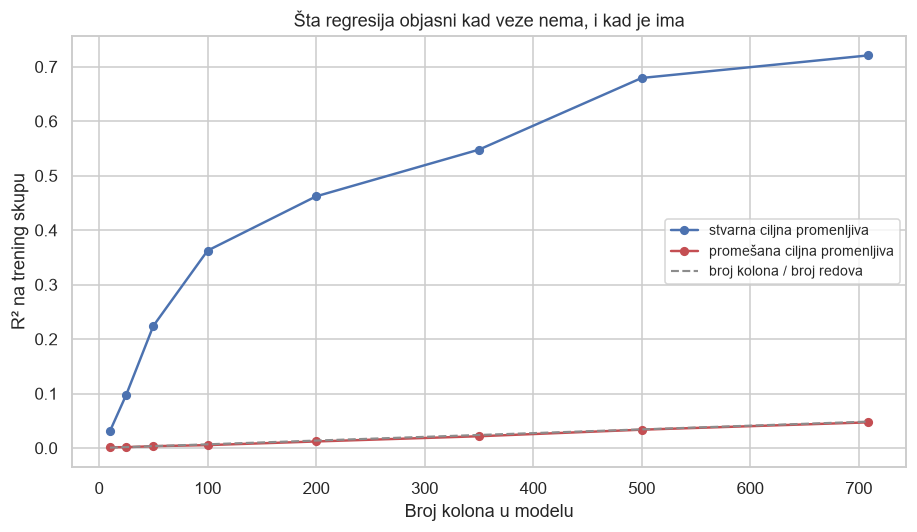

 kolona  nezavisnih  R2_stvarna  adj_stvarna  R2_promešana  adj_promešana  kolona/redova
     10          10      0.0308       0.0301        0.0014         0.0008         0.0007
     25          25      0.0975       0.0960        0.0016        -0.0002         0.0017
     50          50      0.2241       0.2215        0.0034        -0.0001         0.0034
    100         100      0.3624       0.3580        0.0053        -0.0015         0.0068
    200         200      0.4621       0.4546        0.0120        -0.0017         0.0137
    350         350      0.5478       0.5367        0.0216        -0.0024         0.0240
    500         499      0.6794       0.6681        0.0336        -0.0005         0.0342
    709         707      0.7209       0.7067        0.0471        -0.0013         0.0485

korelacija stvarne i promešane ciljne promenljive: 0.0092
sa svih 709 kolona (707 nezavisnih):
  stvarna ciljna promenljiva   R² = 0.7209   prilagođeni 0.7067
  promešana                    R² = 0.0

In [146]:
# The target with its rows shuffled: every respondent gets somebody else's pay,
# so nothing in the predictors can explain it. A fixed seed keeps it repeatable.
rng = np.random.default_rng(0)
y_shuffled = pd.Series(rng.permutation(y_train.to_numpy()), index=y_train.index)

# How many columns to give the model at each step, up to all of them.
SIZES = [10, 25, 50, 100, 200, 350, 500, X_train.shape[1]]


def fit_quality(design, targets):
    """R2 and adjusted R2 of a least-squares fit, for several targets at once.

    lstsq is used rather than a regression object because some of these column
    sets are rank-deficient — a few columns are exact combinations of others —
    and it solves that case without complaint. The rank it reports is also the
    honest number of parameters to charge the adjusted R2 for.
    """
    coefficients, _, rank, _ = np.linalg.lstsq(design, targets, rcond=None)
    fitted = design @ coefficients
    rows = len(design)
    out = []
    for column in range(targets.shape[1]):
        observed = targets[:, column]
        residual = observed - fitted[:, column]
        r_squared = 1 - float(residual @ residual) / float(
            (observed - observed.mean()) @ (observed - observed.mean()))
        out.append((r_squared, 1 - (1 - r_squared) * (rows - 1) / (rows - rank)))
    return out, int(rank) - 1


targets = np.column_stack([y_train.to_numpy(), y_shuffled.to_numpy()])
records = []
for size in SIZES:
    picked = (list(X_train.columns) if size == X_train.shape[1]
              else list(rng.choice(X_train.columns, size=size, replace=False)))
    design = np.column_stack([np.ones(len(X_train)), X_train[picked].to_numpy(dtype=float)])
    (real, noise), independent = fit_quality(design, targets)
    records.append({"kolona": size, "nezavisnih": independent,
                    "R2_stvarna": real[0], "adj_stvarna": real[1],
                    "R2_promešana": noise[0], "adj_promešana": noise[1],
                    "kolona/redova": size / len(X_train)})

quality = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(quality["kolona"], quality["R2_stvarna"], marker="o", markersize=5,
        linewidth=1.6, color="#4C72B0", label="stvarna ciljna promenljiva")
ax.plot(quality["kolona"], quality["R2_promešana"], marker="o", markersize=5,
        linewidth=1.6, color="#C44E52", label="promešana ciljna promenljiva")
ax.plot(quality["kolona"], quality["kolona/redova"], linestyle="--", linewidth=1.4,
        color="#8C8C8C", label="broj kolona / broj redova")

ax.set_xlabel("Broj kolona u modelu")
ax.set_ylabel("R² na trening skupu")
ax.set_title("Šta regresija objasni kad veze nema, i kad je ima")
ax.legend(loc="center right", fontsize=9)
plt.tight_layout()
plt.show()

print(quality.round(4).to_string(index=False))
print()
print(f"korelacija stvarne i promešane ciljne promenljive: "
      f"{float(np.corrcoef(y_train, y_shuffled)[0, 1]):.4f}")
biggest = quality.iloc[-1]
print(f"sa svih {int(biggest['kolona'])} kolona ({int(biggest['nezavisnih'])} nezavisnih):")
print(f"  stvarna ciljna promenljiva   R² = {biggest['R2_stvarna']:.4f}   "
      f"prilagođeni {biggest['adj_stvarna']:.4f}")
print(f"  promešana                    R² = {biggest['R2_promešana']:.4f}   "
      f"prilagođeni {biggest['adj_promešana']:+.4f}")
print(f"  za poređenje, kolona/redova  {biggest['kolona/redova']:.4f}")
print()
print(f"najveći prilagođeni R² koji promešana postiže u svih {len(quality)} koraka: "
      f"{quality['adj_promešana'].max():+.4f}")

**Zapažanje:** prilagođavanje se dešava, i to skoro tačno onoliko koliko sledi iz broja kolona.

Crvena kriva **ne stoji na nuli**. Sa deset kolona regresija na promešanoj ciljnoj promenljivoj dobija
R² od 0,0014, sa dvesta 0,0120, a sa svih 709 kolona **0,0471** — dakle skoro **pet posto** ciljne
promenljive sa kojom po konstrukciji nema nikakve veze. Njena korelacija sa stvarnom platom je 0,0092.
Crvena kriva pri tome leži gotovo tačno na isprekidanoj pravoj: odnos broja kolona i broja redova je na
kraju **0,0485**, a dobijeni R² 0,0471.

Prilagođeni R² se ponaša sasvim drugačije. Na promešanoj ciljnoj promenljivoj ne prelazi **+0,0008** ni u
jednom od osam koraka, a na kraju je **−0,0013**.

Plava kriva raste do **0,7209**, uz prilagođeni R² od **0,7067** — isti broj koji je prethodni deo
izmerio na ovom skupu.

**Tumačenje:** ovo je ono što se u gradivu naziva krajem bias-variance krive na kom varijansa preuzima
posao. Model sa mnogo kolona ima dovoljno slobode da kroz podatke provuče površ koja prati i ono što je
puki slučaj, a pošto se ta površ ocenjuje na istim redovima na kojima je i nameštena, izgleda uspešno.
Veličina tog efekta nije stvar procene: prati odnos broja kolona i broja redova, pa se sa 709 kolona na
14.608 redova dobija oko pet stotih delova varijanse ni iz čega.

Za nas iz ovoga slede tri stvari.

**R² na trening skupu nije mera kvaliteta modela.** Od 0,7209 koliko dobija stvarni model, oko 0,047 je
iste vrste kao ono što bi se dobilo i da podataka nema. To ne znači da je model loš — znači da se po tom
broju ne sme suditi.

**Prilagođeni R² tu grešku ispravlja**, i to pouzdano: na promešanoj ciljnoj promenljivoj ostaje oko nule
kroz ceo raspon. Zato smo ga u prethodnom delu i koristili kao merilo.

**Ridge i Lasso nisu izbor nego posledica.** Oba rade tako što modelu oduzimaju deo te slobode, a upravo
smo izmerili koliko je slobode previše.

Ono što ovim **nije** rešeno jeste kako meriti model na podacima koje nije video. Prilagođeni R² kažnjava
broj kolona, ali i dalje gleda iste redove na kojima je model učen. Time se bavi sledeća sekcija.

### Šta sekcija ostavlja sledećoj

Iz sekcije izlazimo sa četiri stvari: matricama prediktora `X_train` i `X_test`, po **709 kolona**
svaka i sa istim kolonama u istom redosledu, i ciljnim promenljivama `y_train` i `y_test`, koje su
logaritam kompenzacije.

Tri nalaza se prenose dalje:

- **oba skupa imaju isti oblik**, jer je enkodiranje rađeno po kategorijama iz treninga. Vrednosti koje
  trening ne poznaje nema nijedne, a 12 kolona koje u testu ostaju prazne su cena tog izbora i ne smetaju;
- **21 red po koloni je premalo, i to je izmereno, ne pretpostavljeno.** Na nasumično promešanoj ciljnoj
  promenljivoj regresija sa 709 kolona dobija R² od 0,0471, pa toliko od trening rezultata otpada na
  prilagođavanje šumu. Prilagođeni R² tu grešku ispravlja, ali i dalje gleda iste redove na kojima je
  model učen;
- **skale kolona se razlikuju do 895 puta**, pa je standardizacija uz Ridge i Lasso obavezna — ali ide
  unutar unakrsne validacije, ne pre nje.

Ostaje da se dogovorimo **čime merimo** da li je model dobar, pre nego što napravimo ijedan. To je posao
sledeće sekcije.

## 35. Čime merimo model

Odeljak 34.5 je pokazao da R² na trening skupu nije mera kvaliteta: od 0,7209 koliko dobija stvarni model,
oko 0,047 je iste vrste kao ono što bi se dobilo i da veze u podacima nema. Prilagođeni R² tu grešku
ispravlja, ali i on gleda **iste redove** na kojima je model učen.

Zato merila postavljamo sada, pre nego što napravimo ijedan model, i tražimo od njih tri stvari.

**Da se računaju na redovima koje model nije video.** To rešava unakrsna validacija, koju smo učili na
predavanjima: skup se podeli na delove, model se uči na svim delovima osim jednog, a proverava na tom
jednom, pa se postupak ponovi za svaki deo. Tako svaki ispitanik bude predviđen modelom koji njega nije
imao pred sobom.

**Da se mogu pročitati u dolarima.** Model uči logaritam plate, pa je i greška u logaritmu. Broj kao
„RMSE = 0,2" nikome ništa ne znači, a označava nešto vrlo konkretno — i to prevodimo.

**Da uz njih stoji referentna tačka.** R² od 0,54 zvuči osrednje ili dobro u zavisnosti od toga sa čim se
poredi. Zato prvo izmerimo šta dobija najprostije moguće predviđanje, pa se svaki dalji model čita naspram
toga.

### 35.1 Greška u logaritmu i greška u dolarima

Pošto je ciljna promenljiva dekadni logaritam, razlika predviđene i stvarne vrednosti nije razlika u
dolarima nego **odnos**: ako se predviđanje i stvarna plata razlikuju za `d` u logaritmu, onda je
`predviđeno / stvarno = 10^d`. Greška se zato u dolarima ne izražava kao iznos nego kao **koliko puta**
model promaši, i to je za platu i prirodnije — isti promašaj u dolarima ne znači isto kod niske i kod
visoke plate.

Uz standardna tri merila (RMSE, MAE, R²) računamo zato i četiri koja se čitaju bez prevođenja. Nisu
izabrana po osećaju nego izvedena iz gornje veze. **Koliko puta model promaši** je direktan prevod
greške iz logaritma. **Medijana promašaja u procentima i u dolarima** je isti taj broj u dva oblika —
jednom bez iznosa, jednom sa njim, jer „promaši za četvrtinu" i „promaši za 17.000 dolara" ne znače
istom čitaocu isto. Preostala dva su pragovi, i uzimamo ih tamo gde su okrugli **u jedinici u kojoj
model radi**: predviđanje **u okviru dvostruko** je tačno greška od 0,30 u logaritmu, a **u okviru
četvrtine** otprilike 0,10. Prvi prag kaže koliko često predviđanje nije grubo promašeno, drugi koliko
često je upotrebljivo.

Jednu stvar treba razjasniti odmah, jer se lako pogreši. `10^ŷ` daje iznos u dolarima i ništa
komplikovanije od toga — ali taj iznos **nije procena prosečne plate** takvog ispitanika. Prosek u
dolarima podižu najveće plate, pa leži osetno iznad onoga što se dobija stepenovanjem sredine logaritma;
ispis ispod pokazuje koliko se te dve veličine razilaze već na celom trening skupu. Zato sve dolarske
iznose u nastavku prijavljujemo kao **medijane**, nikad kao aritmetičke sredine.

In [147]:
from sklearn.model_selection import KFold


def metrics(actual, predicted):
    """Errors of a prediction of the logged pay, in the logarithm and in dollars.

    The target is a base-10 logarithm, so a difference of d between prediction
    and truth means the prediction is 10**d times the real amount. That ratio is
    what the dollar-side numbers are built on.
    """
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = predicted - actual
    centered = actual - actual.mean()
    ratio = 10.0 ** error
    rmse = float(np.sqrt(np.mean(error ** 2)))
    mae = float(np.mean(np.abs(error)))
    return {
        "RMSE_log": rmse,
        "MAE_log": mae,
        "R2": 1 - float(error @ error) / float(centered @ centered),
        "puta_RMSE": 10 ** rmse,
        "puta_MAE": 10 ** mae,
        "promašaj_%": float(np.median(np.abs(ratio - 1)) * 100),
        "promašaj_USD": float(np.median(np.abs(10.0 ** predicted - 10.0 ** actual))),
        "u_okviru_25%": float(np.mean(np.abs(ratio - 1) <= 0.25) * 100),
        "u_okviru_2x": float(np.mean((ratio >= 0.5) & (ratio <= 2)) * 100),
    }


def show_metrics(table):
    """Print a table of measures, each column formatted the way it reads best."""
    out = pd.DataFrame(index=table.index)
    for column, form in [("RMSE_log", "{:.4f}"), ("MAE_log", "{:.4f}"), ("R2", "{:+.4f}"),
                         ("puta_RMSE", "{:.2f}x"), ("puta_MAE", "{:.2f}x"),
                         ("promašaj_%", "{:.1f}%"), ("promašaj_USD", "{:,.0f}"),
                         ("u_okviru_25%", "{:.1f}%"), ("u_okviru_2x", "{:.1f}%")]:
        out[column] = table[column].map(form.format)
    print(out.to_string())


print("koliko puta model promaši, u zavisnosti od greške u logaritmu:")
for step in [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
    print(f"  greška {step:.2f} u log10  ->  odnos {10 ** step:.2f}x   "
          f"promašaj {100 * (10 ** step - 1):+.0f}%")
print()
print(f"standardna devijacija ciljne promenljive (log10): {y_train.std(ddof=0):.4f}")
print(f"prosek log10 {y_train.mean():.4f} -> {10 ** y_train.mean():>9,.0f} USD")
print(f"medijana     {y_train.median():.4f} -> {10 ** y_train.median():>9,.0f} USD")
print()
# Why every dollar figure in this notebook is a median: three middle values of
# the same distribution, thirty thousand dollars apart.
print("ista raspodela, tri srednje vrednosti u dolarima:")
print(f"  aritmetička sredina plate  {train[TARGET].mean():>9,.0f}")
print(f"  medijana plate             {train[TARGET].median():>9,.0f}")
print(f"  10 na prosek logaritma     {10 ** y_train.mean():>9,.0f}")

koliko puta model promaši, u zavisnosti od greške u logaritmu:
  greška 0.05 u log10  ->  odnos 1.12x   promašaj +12%
  greška 0.10 u log10  ->  odnos 1.26x   promašaj +26%
  greška 0.15 u log10  ->  odnos 1.41x   promašaj +41%
  greška 0.20 u log10  ->  odnos 1.58x   promašaj +58%
  greška 0.30 u log10  ->  odnos 2.00x   promašaj +100%
  greška 0.50 u log10  ->  odnos 3.16x   promašaj +216%

standardna devijacija ciljne promenljive (log10): 0.4390
prosek log10 4.8298 ->    67,584 USD
medijana     4.9096 ->    81,210 USD

ista raspodela, tri srednje vrednosti u dolarima:
  aritmetička sredina plate     94,499
  medijana plate                81,210
  10 na prosek logaritma        67,584


**Zapažanje:** prevod je nelinearan, i to menja način na koji se svaki dalji rezultat čita. Greška od **0,05** u logaritmu znači da je
predviđanje **1,12 puta** stvarnog iznosa, dakle promašaj od 12%. Greška od **0,15** daje **1,41 puta**
(41%), a greška od **0,30** tačno **2,00 puta**, dakle promašaj od 100%.

Standardna devijacija ciljne promenljive je **0,4390** u logaritmu. Prosek logaritma je **4,8298**, što
je **67.584 dolara**, a medijana **4,9096**, odnosno **81.210**.

**Tumačenje:** prva tabela daje skalu na kojoj ćemo čitati sve dalje. Ako model dobije RMSE oko 0,30, to
nije „mala greška u logaritmu" nego promašaj od dvostruko — što za predviđanje plate nije upotrebljivo.
Da bi predviđanje bilo u okviru četvrtine, greška mora da padne ispod 0,10.

Razlika proseka i medijane logaritma pokazuje isto ono što je prethodni deo našao kod asimetrije: i
posle čišćenja je raspodela logaritma iskošena ulevo, pa je prosek niži od medijane.

Poslednji deo ispisa pokazuje zašto dolarske iznose prijavljujemo kao medijane. Na istom trening skupu
aritmetička sredina plate je **94.499** dolara, medijana **81.210**, a stepenovanje proseka logaritma
daje **67.584** — tri srednje vrednosti iste raspodele, razmaknute za više od trideset hiljada. Najviši
od ta tri je prosek u dolarima, jer njega podižu najveće plate, pa je za opis tipičnog ispitanika
najmanje upotrebljiv.

### 35.2 Zašto unakrsna validacija, i sa koliko delova

Postupak je onaj sa predavanja: trening skup podelimo na `k` delova, pa `k` puta učimo model na `k − 1`
dela i predviđamo onaj koji je izostavljen. Na kraju je **svaki red predviđen modelom koji ga nije video**,
pa se metrike računaju nad predviđanjima koja nisu mogla da budu naučena napamet.

Jedan detalj vredi zapisati, jer se izvodi na dva načina. Mi predviđanja iz svih deset delova sastavimo u
**jedan niz** i metriku računamo **jednom, nad svih 14.608 redova**. Druga mogućnost je izračunati R² u
svakom delu posebno pa uzeti prosek tih deset brojeva — to nije ista veličina, jer takav prosek zavisi i
od toga koliko je koji deo ispao lak. Ispis ispod daje i tih deset pojedinačnih vrednosti, ali samo zato
da se vidi koliko se međusobno razlikuju.

Broj delova ne biramo po osećaju. Sa predavanja znamo tri mogućnosti: validacioni skup (jedna podela),
`k`-fold i LOOCV. LOOCV bi ovde značio 14.608 modela sa po 709 kolona, što je neizvodljivo, a jedna podela
bi rezultat vezala za to kako je ispala. Ostaje `k`-fold, a da izbor između 5 i 10 delova ne bi bio
proizvoljan, izmerićemo oba na istom modelu i videti da li se razlikuju.

Uz to imamo priliku da proverimo i samu metodu. U odeljku 34.5 smo videli da regresija sa 709 kolona na
**promešanoj** ciljnoj promenljivoj dobija R² od 0,0471 na trening skupu. Ako unakrsna validacija radi
ono zbog čega je uvodimo, na istoj promešanoj koloni mora da da nulu ili manje — jer model tamo nema šta
da nauči, pa na izostavljenom delu ne može ništa da pogodi.

In [148]:
# Ten parts, and the same seed the previous notebook used for the split, so a
# rerun gives the same folds.
FOLDS = 10
# The same seed the cleaning notebook used for the train/test split.
SEED = 42


def ols_fit_predict(design_fit, target_fit, design_eval):
    """Least squares on one part of the rows, prediction on another.

    lstsq again rather than a regression object, for the same reason as in 1.5:
    some of these designs are rank-deficient and it handles that case quietly.
    """
    coefficients, _, _, _ = np.linalg.lstsq(design_fit, target_fit, rcond=None)
    return design_eval @ coefficients


def with_intercept(columns):
    """The design matrix for these columns, with a column of ones in front."""
    if not columns:
        return np.ones((len(X_train), 1))
    return np.column_stack([np.ones(len(X_train)), X_train[columns].to_numpy(dtype=float)])


def cross_validated(design, target, fit_predict=ols_fit_predict, folds=FOLDS, seed=SEED):
    """Predictions made out of fold, one per row of the training set."""
    target = np.asarray(target, dtype=float)
    out = np.empty(len(target))
    splitter = KFold(n_splits=folds, shuffle=True, random_state=seed)
    for fit_rows, eval_rows in splitter.split(design):
        out[eval_rows] = fit_predict(design[fit_rows], target[fit_rows], design[eval_rows])
    return out


country_columns = [c for c in X_train.columns if c.startswith("Country_")]
country_design = with_intercept(country_columns)

print("da li broj delova menja rezultat (model: samo Country):")
for folds in (5, 10):
    predicted = cross_validated(country_design, y_train, folds=folds)
    measured = metrics(y_train, predicted)
    print(f"  {folds:>2} delova:  R² {measured['R2']:.4f}   RMSE {measured['RMSE_log']:.4f}")
print()

print(f"R² po pojedinačnom delu, pri {FOLDS} delova:")
splitter = KFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
per_fold = []
for number, (fit_rows, eval_rows) in enumerate(splitter.split(country_design), start=1):
    predicted = ols_fit_predict(country_design[fit_rows], y_train.to_numpy()[fit_rows],
                                country_design[eval_rows])
    per_fold.append(metrics(y_train.to_numpy()[eval_rows], predicted)["R2"])
print("  " + "  ".join(f"{value:.3f}" for value in per_fold))
print(f"  najmanji {min(per_fold):.4f}   najveći {max(per_fold):.4f}   "
      f"raspon {max(per_fold) - min(per_fold):.4f}")
print()

# The same shuffled target as in 1.5: if cross-validation works, it cannot find
# anything there.
full_design = with_intercept(list(X_train.columns))
noise_predicted = cross_validated(full_design, y_shuffled)
print("promešana ciljna promenljiva, svih 709 kolona:")
print(f"  R² na trening skupu, iz 34.5:       {quality.iloc[-1]['R2_promešana']:+.4f}")
print(f"  R² po unakrsnoj validaciji:         {metrics(y_shuffled, noise_predicted)['R2']:+.4f}")

da li broj delova menja rezultat (model: samo Country):
   5 delova:  R² 0.5421   RMSE 0.2971


  10 delova:  R² 0.5429   RMSE 0.2968

R² po pojedinačnom delu, pri 10 delova:
  0.526  0.560  0.519  0.550  0.545  0.573  0.521  0.545  0.546  0.538
  najmanji 0.5188   najveći 0.5727   raspon 0.0539



promešana ciljna promenljiva, svih 709 kolona:
  R² na trening skupu, iz 34.5:       +0.0471
  R² po unakrsnoj validaciji:         -0.0573


**Zapažanje:** broj delova ne menja rezultat. Sa 5 delova model sa samom zemljom dobija R² **0,5421**, sa
10 delova **0,5429** — razlika je na trećoj decimali. R² po pojedinačnim delovima kreće se od **0,5188**
do **0,5727**, dakle raspon je **0,0539**.

Provera metode prolazi, i to jasnije nego što se očekivalo. Na promešanoj ciljnoj promenljivoj sa svih
709 kolona R² na trening skupu iznosi **+0,0471**, a po unakrsnoj validaciji **−0,0573**.

**Tumačenje:** to što 5 i 10 delova daju isto znači da izbor nije taj koji vodi rezultat, pa uzimamo
**10 delova** — više dela za učenje po prolazu, a cena je zanemarljiva. Raspon od 0,0539 između najgoreg
i najboljeg dela je pri tome podsetnik da jedna podela ne bi bila dovoljna: da smo uzeli samo jedan
validacioni skup, mogli smo dobiti 0,52 ili 0,57 zavisno od toga koji je ispao.

Druga provera je važnija. Na promešanoj koloni unakrsna validacija ne daje samo nulu nego **negativan**
R², i to nije greška u računu. Negativan R² znači da je model **gori od predviđanja prosekom** — što je
tačno ono što se očekuje: model je na svom delu naučio slučajne razlike, pa ih na izostavljenom delu
primenjuje tamo gde ih nema, i time aktivno pogoršava predviđanje.

Time je pitanje iz 34.5 zatvoreno. Trening R² od 0,0471 i unakrsni R² od −0,0573 su ista stvar viđena sa
dve strane: prvo je mera koliko se model prilagodio šumu, drugo je mera koliko ga to košta kod novih
ljudi. Sve dalje merimo drugim.

### 35.3 Pod: predviđanje bez ijednog prediktora

Prvi stepenik je najniži zamisliv. Svakom ispitaniku damo **isti broj**, i to je celo predviđanje —
nijedna kolona se ne gleda. Taj broj se, kao i sve ostalo, računa **na delu na kom se uči** pa primenjuje
na izostavljeni deo, dakle prolazi kroz istu unakrsnu validaciju kao pravi modeli. To je najgore što se
može uraditi a da se i dalje zove predviđanje, i ništa što u nastavku nazovemo modelom ne sme biti gore.

Ostaje pitanje **koji** broj, i ono nije formalno. Sa predavanja znamo da RMSE i MAE ne minimizuje ista
vrednost: zbir kvadrata odstupanja najmanji je oko **proseka**, zbir apsolutnih odstupanja oko
**medijane**. Da su plate simetrično raspoređene, ta dva broja bi se poklopila i pitanje ne bi ni
postojalo; kod nas se razilaze — u 35.1 smo videli da je prosek logaritma 4,8298 a medijana 4,9096. Zato
računamo **obe konstante** i pustimo merila da pokažu koja gde pobeđuje, umesto da unapred izaberemo
jednu.

In [149]:
def median_fit_predict(design_fit, target_fit, design_eval):
    """The simplest prediction there is: the median of the rows it was fitted on."""
    return np.full(len(design_eval), float(np.median(target_fit)))


def mean_fit_predict(design_fit, target_fit, design_eval):
    """The same, with the mean instead of the median."""
    return np.full(len(design_eval), float(np.mean(target_fit)))


intercept_only = with_intercept([])
baselines = {
    "medijana treninga": cross_validated(intercept_only, y_train, median_fit_predict),
    "prosek treninga": cross_validated(intercept_only, y_train, mean_fit_predict),
}
floor = pd.DataFrame({name: metrics(y_train, predicted)
                      for name, predicted in baselines.items()}).T
show_metrics(floor)
print()
for column, better in [("RMSE_log", "min"), ("MAE_log", "min"), ("promašaj_%", "min"),
                       ("u_okviru_2x", "max")]:
    winner = floor[column].idxmin() if better == "min" else floor[column].idxmax()
    print(f"  po {column:<14} bolja je {winner}")

                  RMSE_log MAE_log       R2 puta_RMSE puta_MAE promašaj_% promašaj_USD u_okviru_25% u_okviru_2x
medijana treninga   0.4462  0.2965  -0.0330     2.79x    1.98x      42.8%       36,718        29.6%       66.4%
prosek treninga     0.4390  0.3054  -0.0001     2.75x    2.02x      44.8%       36,315        27.6%       62.2%

  po RMSE_log       bolja je prosek treninga
  po MAE_log        bolja je medijana treninga
  po promašaj_%     bolja je medijana treninga
  po u_okviru_2x    bolja je medijana treninga


**Zapažanje:** dve konstante se razlikuju, i to na predvidiv način. **Prosek** daje niži RMSE
(**0,4390** naspram 0,4462) i R² bliži nuli (**−0,0001** naspram −0,0330). **Medijana** daje niži MAE
(**0,2965** naspram 0,3054), manji tipičan promašaj (**42,8%** naspram 44,8%) i više ispitanika u okviru
dvostruko (**66,4%** naspram 62,2%).

**Tumačenje:** rezultat je provera da merila rade ono što od njih očekujemo, a ne nalaz o podacima —
prosek pobeđuje tamo gde se greška kvadrira, medijana tamo gde se ne kvadrira, tačno kao što sledi iz
definicija. Da je ispalo obrnuto, tražili bismo grešku u kodu.

Praktična posledica je da **pod nije jedan broj nego zavisi od merila**, pa ćemo u nastavku navoditi oba.
Za R² uzimamo prosek kao pod, jer je R² građen oko kvadratne greške.

Oba poda su pri tome **negativna**. To nije greška: konstanta se računa na delu za učenje pa
primenjuje na izostavljeni deo, i time je za taj deo neznatno pogrešna. Nula na unakrsnom R² je, dakle,
već malo bolja od ničega.

### 35.4 Koje pojedinačno obeležje je najjače

Pod je prenizak da bi bio koristan. Model sa 709 kolona koji pobedi konstantu nije pokazao ništa — pravo
pitanje je da li pobeđuje **jedno jedino anketno pitanje**.

Iz prethodnog dela nosimo uverenje da je to pitanje `Country`, ali ono je tamo izmereno drugim
merilom (prilagođeni R² na trening skupu) i na drugačije sažetoj promenljivoj. Ovde ga zato ne
pretpostavljamo nego merimo iznova, istom unakrsnom validacijom kojom merimo sve ostalo, i to **za svako**
nasleđeno anketno obeležje.

Obeležjem smatramo jedno anketno pitanje: to je jedna kolona kod većine, a kod rang-pitanja ceo blok
kolona koji je iz njega izvezen. Promenljive koje smo sami napravili ovde ne ulaze — one se mere kasnije,
naspram letvice koju upravo postavljamo.

In [150]:
# The four ranking questions; each was exported as one column per offered item,
# so the question, not the column, is the feature.
RANK_PREFIXES = ("TechEndorse_", "TechOppose_", "JobSatPoints_", "SO_Actions_")
# The prefixes of everything this project derived, which is what "inherited" excludes.
DERIVED_PREFIXES = ("Chose_", "Count_", "KeptShare_", "NotAnswered_")

inherited = [c for c in predictors if not c.startswith(DERIVED_PREFIXES)]
features = {c: [c] for c in inherited if not c.startswith(RANK_PREFIXES)}
for prefix in RANK_PREFIXES:
    features[prefix.rstrip("_")] = [c for c in inherited if c.startswith(prefix)]



def encoded_columns_for(names):
    """Where these survey features sit in the encoded matrix.

    A numeric column keeps its name. A categorical one was expanded into dummy
    columns called "<column>_<category>", so it is found by that prefix instead.
    """
    found = []
    for name in names:
        if name in X_train.columns:
            found.append(name)
        else:
            found.extend(c for c in X_train.columns if c.startswith(name + "_"))
    return found


def cv_r2_of(names):
    """Cross-validated R2 of a model built from these survey features alone."""
    design = with_intercept(encoded_columns_for(names))
    return metrics(y_train, cross_validated(design, y_train))["R2"], design.shape[1] - 1


# Every inherited column has to land in exactly one feature, otherwise the table
# below would be measuring something other than what it claims.
claimed = [c for columns in features.values() for c in encoded_columns_for(columns)]
print(f"nasleđenih kolona: {len(inherited)}   anketnih obeležja: {len(features)}")
print(f"kolona modela koje ta obeležja pokrivaju: {len(claimed)}   "
      f"bez ponavljanja: {len(set(claimed)) == len(claimed)}")
print()


single = pd.DataFrame(
    [{"obeležje": name, "kolona": width, "CV_R2": value}
     for name, (value, width) in ((name, cv_r2_of(columns)) for name, columns in features.items())]
).sort_values("CV_R2", ascending=False).reset_index(drop=True)

print("osam najjačih pojedinačnih obeležja:")
print(single.head(8).to_string(index=False,
                               formatters={"CV_R2": "{:.4f}".format}))
print()
print("tri najslabija:")
print(single.tail(3).to_string(index=False, formatters={"CV_R2": "{:.4f}".format}))
print()
print(f"najjače:  {single.loc[0, 'obeležje']} = {single.loc[0, 'CV_R2']:.4f}")
print(f"drugo:    {single.loc[1, 'obeležje']} = {single.loc[1, 'CV_R2']:.4f}   "
      f"razlika {single.loc[0, 'CV_R2'] - single.loc[1, 'CV_R2']:.4f}")
print(f"treće:    {single.loc[2, 'obeležje']} = {single.loc[2, 'CV_R2']:.4f}   "
      f"razlika {single.loc[1, 'CV_R2'] - single.loc[2, 'CV_R2']:.4f}")
print(f"obeležja sa negativnim CV R²: {int((single['CV_R2'] < 0).sum())} od {len(single)}")

# Whichever feature came out strongest becomes the second reference point, so the
# choice follows the measurement instead of being made in advance.
best_feature = str(single.loc[0, "obeležje"])
baselines[f"samo {best_feature}"] = cross_validated(
    with_intercept(encoded_columns_for(features[best_feature])), y_train)
print()
print(f"druga referentna tačka je time određena: samo {best_feature}")

nasleđenih kolona: 75   anketnih obeležja: 43
kolona modela koje ta obeležja pokrivaju: 357   bez ponavljanja: True



osam najjačih pojedinačnih obeležja:
    obeležje  kolona  CV_R2
     Country      61 0.5429
    Currency      81 0.4821
  SODuration       7 0.1829
         Age       6 0.1552
   YearsCode       1 0.1479
     WorkExp       1 0.1280
JobSatPoints      13 0.0660
     OrgSize       1 0.0398

tri najslabija:
         obeležje  kolona   CV_R2
       Employment       1  0.0001
ToolCountPersonal       1  0.0000
      LearnCodeAI       5 -0.0002

najjače:  Country = 0.5429
drugo:    Currency = 0.4821   razlika 0.0608
treće:    SODuration = 0.1829   razlika 0.2992
obeležja sa negativnim CV R²: 1 od 43

druga referentna tačka je time određena: samo Country


**Zapažanje:** merenje potvrđuje ono što smo nosili iz prethodnog dela, ali uz dve stvari koje se
odatle nisu videle.

**`Country` je najjače**, sa CV R² od **0,5429**. Drugo je **`Currency` sa 0,4821**, dakle svega
**0,0608** iza. Treće je `SODuration` sa **0,1829** — a razlika između drugog i trećeg je **0,2992**,
skoro pet puta veća od razlike između prvog i drugog.

Zatim slede `Age` (0,1552), `YearsCode` (0,1479) i `WorkExp` (0,1280). Od **43** obeležja, njih **42**
ima pozitivan CV R², a jedno negativan.

**Tumačenje:** letvica je time izmerena, a ne uvezena: **0,5429**, i to je `Country`.

Ali dva obeležja se odvajaju od svih ostalih, ne jedno. Da smo gledali samo prvo mesto, propustili bismo
da valuta sama za sebe objašnjava skoro koliko i zemlja. To ima isti uzrok koji je prethodni deo
našao kad je merio šta valuta dodaje preko zemlje: obe nose istu vrstu podatka — na kom tržištu ispitanik
zarađuje — pa se i pojedinačno ponašaju slično. Za nas to znači da bi bilo pogrešno reći „samo zemlja
nosi signal"; tačnije je da ga nosi **zemlja i valuta zajedno**, a sve ostalo je reda veličine desetak
puta manje.

To što jedno obeležje ima negativan CV R² je pri tome poučno na isti način kao pod iz 35.3: obeležje koje
ne nosi ništa na unakrsnoj validaciji ne dobija nulu nego **malo manje od nule**, jer model potroši jedan
koeficijent na šum.

### 35.5 Prava mera: sve što je anketa dala, bez ijedne naše promenljive

Najjače pojedinačno obeležje je poštena letvica za jednu promenljivu, ali ne i za ceo prethodni deo.
Ako se model sa 709 kolona poredi sa zemljom samom, pobeda mu je zagarantovana i ništa ne dokazuje —
pobediće je već i time što uz zemlju ima valutu i uzrast.

Zato postavljamo i treći stepenik, i on je onaj koji stvarno nešto proverava: **model od svih anketnih
obeležja u obliku u kom su došla iz čišćenja, bez ijedne promenljive koju smo sami napravili.** To je
`Country`, `Currency`, `DevType`, uzrast, staž, rangiranja i ostalo — dakle 75 kolona iz odeljka 34.2, ili
357 kolona posle enkodiranja.

Ako model sa svim promenljivama ne pređe taj broj, feature engineering iz prethodnog dela nije
doneo ništa što anketa nije već imala. Letvicu postavljamo **sada, pre nego što napravimo prvi model**,
baš zato da posle ne bismo birali poređenje koje nam odgovara.

In [151]:
inherited_encoded = encoded_columns_for(inherited)
inherited_r2, inherited_width = cv_r2_of(inherited)
baselines["sva anketna obeležja"] = cross_validated(
    with_intercept(inherited_encoded), y_train)

reference = pd.DataFrame({name: metrics(y_train, predicted)
                          for name, predicted in baselines.items()}).T
show_metrics(reference)
print()
derived = [c for c in predictors if c.startswith(DERIVED_PREFIXES)]
print(f"{'nasleđenih kolona u modelu':<34} {inherited_width:>4}   "
      f"(od {len(inherited)} prediktora)")
print(f"{'naših kolona u modelu':<34} {X_train.shape[1] - inherited_width:>4}   "
      f"(od {len(derived)} prediktora)")
print(f"{'ukupno':<34} {X_train.shape[1]:>4}")
print()
print(f"letvica koju model sa svim promenljivama mora da pređe: {inherited_r2:.4f}")
print(f"  koliko od toga nosi sama zemlja: {single.loc[0, 'CV_R2'] / inherited_r2 * 100:.0f}%")
print(f"  koliko dodaje sve ostalo iz ankete: "
      f"{inherited_r2 - single.loc[0, 'CV_R2']:+.4f}")

                     RMSE_log MAE_log       R2 puta_RMSE puta_MAE promašaj_% promašaj_USD u_okviru_25% u_okviru_2x
medijana treninga      0.4462  0.2965  -0.0330     2.79x    1.98x      42.8%       36,718        29.6%       66.4%
prosek treninga        0.4390  0.3054  -0.0001     2.75x    2.02x      44.8%       36,315        27.6%       62.2%
samo Country           0.2968  0.2047  +0.5429     1.98x    1.60x      32.1%       22,186        40.6%       79.2%
sva anketna obeležja   0.2534  0.1652  +0.6668     1.79x    1.46x      25.5%       17,568        49.2%       86.7%

nasleđenih kolona u modelu          357   (od 75 prediktora)
naših kolona u modelu               352   (od 352 prediktora)
ukupno                              709

letvica koju model sa svim promenljivama mora da pređe: 0.6668
  koliko od toga nosi sama zemlja: 81%
  koliko dodaje sve ostalo iz ankete: +0.1239


**Zapažanje:** sva anketna obeležja zajedno daju CV R² od **0,6668**, sa **357** kolona. Sama zemlja nosi
**81%** te vrednosti, a sve ostalo iz ankete dodaje **+0,1239**.

Iz iste tabele se vidi i šta to znači u dolarima: tipičan promašaj pada sa 32,1% kod same zemlje na
**25,5%**, odnosno sa 22.186 na **17.568 dolara**, a udeo ispitanika u okviru dvostruko raste sa
79,2% na **86,7%**.

**Tumačenje:** ovo je letvica za sve dalje, i postavljena je pre prvog modela. Naših **352** kolone —
koje posle enkodiranja daju 352 kolone modela — moraju da pređu **0,6668** da bi bile opravdane, i to je
mnogo zahtevnije od 0,5429 koliko daje sama zemlja.

Zašto se ne poredimo sa zemljom, nije samo po sebi jasno. Model sa 709 kolona bi zemlju pobedio i bez
ijedne naše promenljive, samo zahvaljujući valuti i uzrastu, pa bi takvo poređenje merilo anketu a
pripisivalo zaslugu nama. Poređenje sa svim anketnim obeležjima to isključuje: ono što ostane iznad
0,6668 je isključivo doprinos prethodnog dela.

Ostaje da se kaže i šta ovaj broj **nije**. On nije rezultat na test skupu — sve je mereno unakrsnom
validacijom nad treningom. I nije konačan izbor modela, jer obična regresija sa 709 kolona nije jedini
kandidat; upravo smo u 34.5 videli koliko slobode ona ima.

### Grafik 28 — kako se greška sužava sa svakim stepenikom

**Motivacija:** tabela daje po jedan broj za svaki stepenik, ali sažima celu raspodelu u medijanu i
procenat. Nas zanima i **oblik**: da li se sa svakim stepenikom greška sužava ravnomerno kod svih, ili se
popravlja kod većine a ostaje ista kod manjine. To je važno jer se dva modela sa istim MAE mogu ponašati
sasvim različito — jedan promašuje malo kod svih, drugi tačno kod većine a katastrofalno kod nekih.

Crtamo raspodelu odnosa `predviđeno / stvarno` za sva tri stepenika, na logaritamskoj osi, jer je na njoj
promašaj od dva puta na gore jednako daleko od jedinice kao promašaj od dva puta na dole.

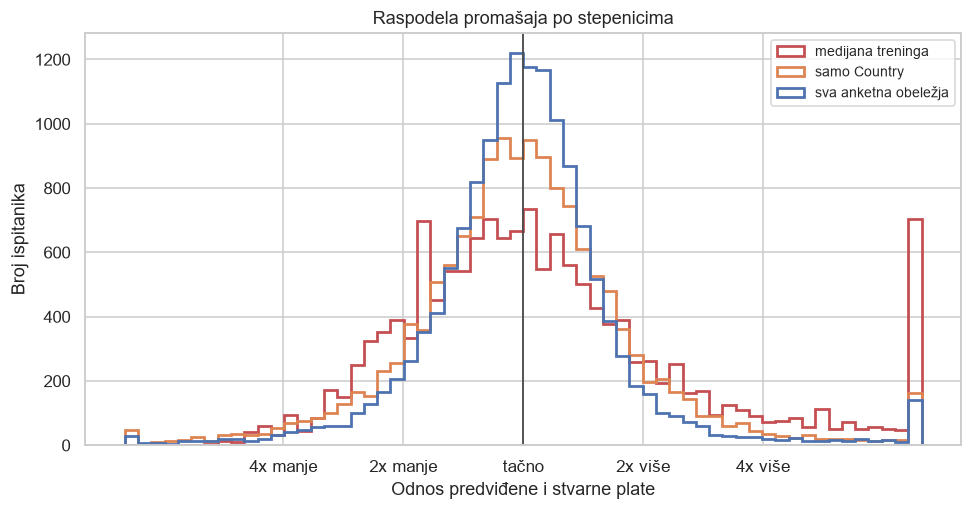

stepenik                5. pct 25. pct 50. pct 75. pct 95. pct
medijana treninga        0.37   0.65   1.00   1.67   8.73
samo Country             0.36   0.71   0.98   1.37   2.75
sva anketna obeležja     0.44   0.76   0.99   1.28   2.18

medijana treninga      preceni kod 49.1% ispitanika, promaši više od 4x kod 10.9%, izvan opsega grafika 654
samo Country           preceni kod 48.7% ispitanika, promaši više od 4x kod  4.8%, izvan opsega grafika 192
sva anketna obeležja   preceni kod 49.1% ispitanika, promaši više od 4x kod  3.4%, izvan opsega grafika 151


In [152]:
fig, ax = plt.subplots(figsize=(9, 4.8))
edges = np.logspace(np.log10(0.1), np.log10(10), 61)
# The three steps drawn here, each keeping its colour for the rest of the notebook.
COLORS = {"medijana treninga": "#C44E52", f"samo {best_feature}": "#DD8452",
          "sva anketna obeležja": "#4C72B0"}

outside = {}
for name, color in COLORS.items():
    ratio = 10.0 ** (baselines[name] - y_train.to_numpy())
    outside[name] = int(np.sum((ratio < edges[0]) | (ratio > edges[-1])))
    # Clipped, not dropped: without this the worst misses would simply be missing
    # from the picture instead of piling up in the edge bins.
    ax.hist(np.clip(ratio, edges[0], edges[-1]), bins=edges, histtype="step",
            linewidth=1.8, color=color, label=name)

ax.axvline(1, color="#4C4C4C", linewidth=1.2)
ax.set_xscale("log")
ax.set_xticks([0.25, 0.5, 1, 2, 4])
ax.set_xticklabels(["4x manje", "2x manje", "tačno", "2x više", "4x više"])
ax.set_xlabel("Odnos predviđene i stvarne plate")
ax.set_ylabel("Broj ispitanika")
ax.set_title("Raspodela promašaja po stepenicima")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'stepenik':<22} " + " ".join(f"{q:>2}. pct" for q in (5, 25, 50, 75, 95)))
for name in COLORS:
    ratio = 10.0 ** (baselines[name] - y_train.to_numpy())
    values = " ".join(f"{np.percentile(ratio, q):>6.2f}" for q in (5, 25, 50, 75, 95))
    print(f"{name:<22} {values}")
print()
for name in COLORS:
    ratio = 10.0 ** (baselines[name] - y_train.to_numpy())
    print(f"{name:<22} preceni kod {100 * np.mean(ratio > 1):>4.1f}% ispitanika, "
          f"promaši više od 4x kod {100 * np.mean((ratio > 4) | (ratio < 0.25)):>4.1f}%, "
          f"izvan opsega grafika {outside[name]:>3}")

**Zapažanje:** sva tri stepenika su usredsređena oko jedinice, a razlikuju se po širini i po repovima.

Srednjih pola ispitanika je kod **medijane treninga** između **0,65 i 1,67 puta** stvarne plate, kod
**same zemlje** između **0,71 i 1,37**, a kod **svih anketnih obeležja** između **0,76 i 1,28**. Peti i
devedeset peti percentil idu od **0,37 i 8,73** kod medijane, preko **0,36 i 2,75** kod zemlje, do
**0,44 i 2,18** kod svih obeležja.

Smer promašaja je kod svih uravnotežen — precenjeno je između **48,7%** i **49,1%** ispitanika. Veličina
nije: promašaj veći od četiri puta pada sa **10,9%** kod medijane na **4,8%** kod zemlje i **3,4%** kod
svih obeležja.

Stubić na samom desnom kraju nije gomila oko desetostrukog promašaja nego **sve što je izvan opsega
grafika**, sabrano u poslednju kutiju: kod medijane treninga **654** ispitanika, a kod svih anketnih
obeležja **151**. Bez tog sabiranja bi ti redovi sa slike prosto nedostajali, pa bi grafik izgledao bolje
nego što stvari stoje.

**Tumačenje:** oblik objašnjava zašto uz medijanu promašaja gledamo i udeo u okviru dvostruko. Kod
medijane treninga je „tipičan" promašaj 42,8%, ali kod svakog devetog ispitanika predviđanje nije ni
približno upotrebljivo. Sa svim anketnim obeležjima taj udeo pada na **3,4%** — a tipičan
promašaj i dalje ostaje **25,5%**, dakle četvrtina plate.

Repovi su pri tome jasno nesimetrični: gornji je duži od donjeg kod svih tri. Uzrok je delom to što je
najniže moguće predviđanje ograničeno nulom a najviše nije, a delom ispitanici sa iznosima ispod hiljadu
dolara, kod kojih svako razumno predviđanje ispada mnogo puta previsoko. To je prvi konkretan trag onoga
što smo u 34.2 postavili samo kao očekivanje, i vraćamo mu se u devetoj sekciji.

### Šta sekcija ostavlja sledećoj

Merila su postavljena pre nego što je napravljen ijedan model: **RMSE, MAE i R²** u logaritmu, uz
**koliko puta model promaši**, medijanu promašaja u procentima i dolarima, i udeo ispitanika kod kojih je
predviđanje u okviru četvrtine odnosno dvostruko. Sve se računa **unakrsnom validacijom sa 10 delova**
nad trening skupom, na istim delovima za svaki model.

Uz njih su izmerena, a ne izabrana, tri stepenika prema kojima se sve dalje čita:

| stepenik | kolona | CV R² | tipičan promašaj |
| --- | --- | --- | --- |
| konstanta (prosek treninga) | 0 | −0,0001 | 44,8% |
| najjače pojedinačno obeležje (`Country`) | 61 | 0,5429 | 32,1% |
| sva anketna obeležja, bez naših | 357 | 0,6668 | 25,5% |

Četiri nalaza se prenose dalje:

- **unakrsna validacija radi ono zbog čega je uvedena.** Na promešanoj ciljnoj promenljivoj daje −0,0573,
  dok trening R² daje +0,0471. Izbor između 5 i 10 delova ne menja rezultat, ali jedna jedina podela bi
  ga menjala — R² po delovima ide od 0,5188 do 0,5727;
- **pod zavisi od merila.** Prosek pobeđuje po RMSE, medijana po MAE, i oba poda su blago negativna;
- **zemlja i valuta se odvajaju od svega ostalog.** `Country` daje 0,5429, `Currency` 0,4821, a treće
  obeležje po jačini svega 0,1829. Nije, dakle, tačno da signal nosi samo zemlja;
- **letvica za prethodni deo je 0,6668.** Naših 352 kolone opravdane su samo onoliko koliko model
  pređe taj broj — ne 0,5429, jer bi zemlju pobedila i sama anketa.

Test skup i dalje nije dodirnut. Sledeća sekcija gradi prvi pravi model — običnu višestruku regresiju sa
svih 709 kolona — i na njoj proverava pretpostavke koje smo odložili još u delu o ciljnoj promenljivoj.

## 36. Linearna regresija i dijagnostika

Sada pravimo prvi pravi model: **višestruku linearnu regresiju sa svim kolonama**. To je model sa
predavanja i polazna tačka za sve ostalo — Ridge, Lasso i glavne komponente u nastavku menjaju upravo
njega.

Uz rezultat, sekcija vraća i jedno dugovanje. Kad smo u delu o ciljnoj promenljivoj odlučili da modelujemo logaritam
plate, rekli smo da se taj izbor ne opravdava asimetrijom ciljne kolone nego **rasipanjem grešaka
modela** — a modela tada nismo imali.

### 36.1 Model sa svim kolonama

Prvo treba skloniti dve kolone. U 34.5 smo videli da je od 709 kolona **707 nezavisnih**, dakle dve su
tačna kombinacija ostalih. Za predviđanje to ne smeta, ali za regresiju sa standardnim greškama smeta,
jer koeficijenti tada nisu jednoznačno određeni.

Model merimo dvaput: na trening skupu i unakrsnom validacijom. Razlika između tih dva je ono što nas
zanima.

In [153]:
import statsmodels.api as sm
from scipy import linalg, stats


def format_p(value):
    """A p-value too small for a float prints as a bound, not as a plain zero."""
    return "< 1e-300" if value == 0 else f"{value:.2g}"


def independent_columns(frame):
    """The columns that are not an exact combination of the others.

    The factorisation orders the columns by how much new direction each adds, so
    the ones that add nothing land at the end and are the ones to leave out.
    """
    matrix = frame.to_numpy(dtype=float)
    _, upper, order = linalg.qr(matrix, mode="economic", pivoting=True)
    tolerance = abs(upper[0, 0]) * max(matrix.shape) * np.finfo(float).eps
    rank = int((abs(np.diag(upper)) > tolerance).sum())
    return ([frame.columns[i] for i in order[:rank]],
            [frame.columns[i] for i in order[rank:]])


independent, dependent = independent_columns(X_train)
# Kept in the original order, so the columns keep meaning what they meant.
independent = [c for c in X_train.columns if c in set(independent)]

print(f"kolona: {X_train.shape[1]}   nezavisnih: {len(independent)}   "
      f"izbačeno: {len(dependent)}")
print(f"  izbačene: {list(dependent)}")
print()

full_design = np.column_stack([np.ones(len(X_train)),
                               X_train[independent].to_numpy(dtype=float)])
full_model = sm.OLS(y_train.to_numpy(), full_design).fit()

print("na trening skupu:")
print(f"  R²                {full_model.rsquared:.4f}")
print(f"  prilagođeni R²    {full_model.rsquared_adj:.4f}")
print(f"  F-test            F = {full_model.fvalue:.1f}   p = {format_p(full_model.f_pvalue)}")
print(f"  RSE (u log10)     {np.sqrt(full_model.mse_resid):.4f}")
print()

full_cv = cross_validated(full_design, y_train)
full_metrics = metrics(y_train, full_cv)
reference.loc["sve kolone, regresija"] = pd.Series(full_metrics)
show_metrics(reference)
print()
step = reference.loc["sve kolone, regresija", "R2"] - reference.loc["sva anketna obeležja", "R2"]
print(f"trening R² naspram unakrsnog:   {full_model.rsquared:.4f} -> {full_metrics['R2']:.4f}"
      f"   razlika {full_model.rsquared - full_metrics['R2']:.4f}")
print(f"letvica iz 35.5 (sva anketna obeležja): {reference.loc['sva anketna obeležja', 'R2']:.4f}")
print(f"koliko naše 352 kolone dodaju:  {step:+.4f}")
print(f"prelazi letvicu: {bool(step > 0)}")

kolona: 709   nezavisnih: 707   izbačeno: 2
  izbačene: ['Country_Indonesia', 'Currency_NPR Nepalese rupee']



na trening skupu:
  R²                0.7209
  prilagođeni R²    0.7067
  F-test            F = 50.8   p = < 1e-300
  RSE (u log10)     0.2377



                      RMSE_log MAE_log       R2 puta_RMSE puta_MAE promašaj_% promašaj_USD u_okviru_25% u_okviru_2x
medijana treninga       0.4462  0.2965  -0.0330     2.79x    1.98x      42.8%       36,718        29.6%       66.4%
prosek treninga         0.4390  0.3054  -0.0001     2.75x    2.02x      44.8%       36,315        27.6%       62.2%
samo Country            0.2968  0.2047  +0.5429     1.98x    1.60x      32.1%       22,186        40.6%       79.2%
sva anketna obeležja    0.2534  0.1652  +0.6668     1.79x    1.46x      25.5%       17,568        49.2%       86.7%
sve kolone, regresija   0.2495  0.1615  +0.6769     1.78x    1.45x      24.8%       17,028        50.3%       87.5%

trening R² naspram unakrsnog:   0.7209 -> 0.6769   razlika 0.0440
letvica iz 35.5 (sva anketna obeležja): 0.6668
koliko naše 352 kolone dodaju:  +0.0101
prelazi letvicu: True


**Zapažanje:** izbačene su `Country_Indonesia` i `Currency_NPR Nepalese rupee`. Na trening skupu model
daje R² **0,7209** i prilagođeni **0,7067**, uz F = **50,8** i standardnu grešku ostatka **0,2377** u
logaritmu. Unakrsnom validacijom dobija **0,6769** — tipičan promašaj **24,8%**, a kod **87,5%**
ispitanika predviđanje je u okviru dvostruko. Naspram letvice iz 35.5 (**0,6668**) naših 352 kolone dodaju
**+0,0101**.

**Tumačenje:** model radi, ali dva broja traže objašnjenje.

Razlika trening i unakrsnog R² je **0,0440**, a u 34.5 smo izmerili da promešana ciljna promenljiva na
treningu dobija 0,0471. Skoro celu razliku, dakle, objašnjava prilagođavanje šumu — i to je bilo
izmereno pre nego što je model napravljen.

Doprinos prethodnog dela je **+0,0101**, znatno manji nego što je izgledao na trening skupu. Da li
regularizacija iz tih kolona može izvući više, pitanje je sekcija 37 i 5.

### 36.2 Dugovanje iz dela o ciljnoj promenljivoj: da li je logaritam bio pravi izbor

Pretpostavka koja se proverava zove se **homoscedastičnost**: da je rasipanje ostatka **isto** duž celog
raspona predviđenih vrednosti. Ostatak je razlika stvarne i predviđene vrednosti, pa to znači da model
kod niskih plata sme da greši u proseku taman koliko i kod visokih. Kad rasipanje raste sa predviđenom
vrednošću, oblak tačaka dobija oblik levka — to je heteroscedastičnost, i sa predavanja znamo da je prvi
lek za nju transformacija ciljne promenljive, `log Y` ili `√Y`. Posledica nije da su koeficijenti
pogrešni: oni ostaju nepristrasni, ali njihove **standardne greške** prestaju da važe, a iz njih se
računaju p-vrednosti i intervali poverenja.

Postupak je poređenje: **isti model, istih 707 kolona, dva puta — jednom na logaritmu plate, jednom na
sirovim dolarima.** R² ta dva modela se ne smeju porediti, jer mere razlike u različitim jedinicama;
poredi se samo oblik rasipanja.

Uz sliku merimo i broj, jer se „levak" teško brani rečima. Predviđene vrednosti poređamo po veličini pa
ih podelimo na deset jednakih delova — **decila** — i u svakom izmerimo standardnu devijaciju ostatka.
Decil je, dakle, desetina poređanog niza: prvi decil su najnižih deset posto predviđanja, poslednji
najviših deset posto, a granice među njima su 10, 20, ... 90. percentil. Ako je rasipanje ujednačeno, tih
deset brojeva izlaze približno isti.

### Grafik 29 — rasipanje ostatka, u dolarima i u logaritmu

**Motivacija:** homoscedastičnost je tvrdnja o obliku, pa se najbolje vidi na slici. Ako je logaritam bio
pravi izbor, levi panel treba da pokaže lepezu koja se širi, a desni pojas ujednačene širine.

sirovi dolari: najniže predviđanje    -51,028 USD, negativnih predviđanja 419


logaritam plate: najniže predviđanje        838 USD, negativnih predviđanja 0


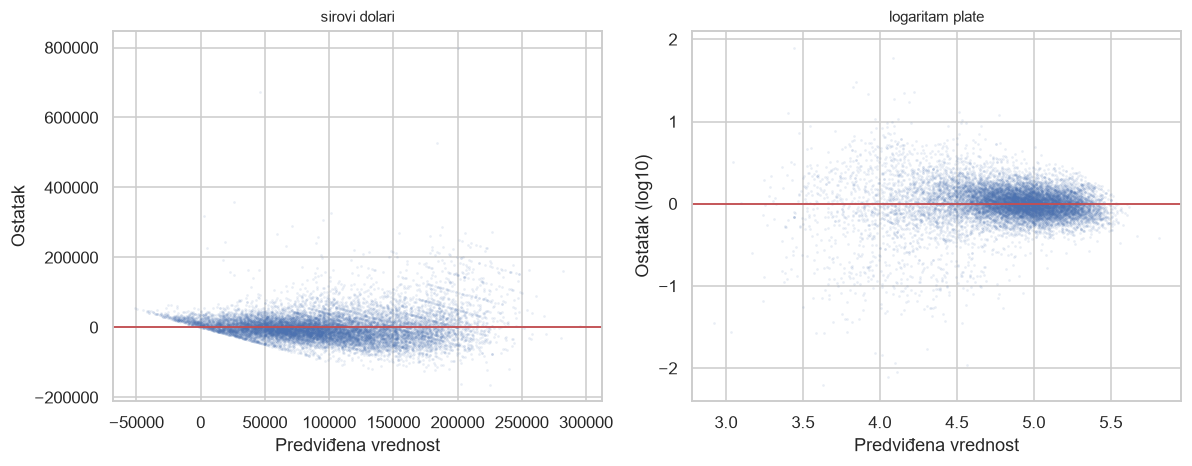

sirovi dolari — standardna devijacija ostatka po decilu predviđene vrednosti (USD):
  23,258  22,845  29,903  26,767  29,641  36,872  35,543  40,192  46,535  71,974
  prvi decil 23,258.292   poslednji 71,973.582   odnos poslednji/prvi 3.09
  bez prva dva decila: odnos najveći/najmanji 2.69

logaritam plate — standardna devijacija ostatka po decilu predviđene vrednosti (log10):
  0.483  0.321  0.208  0.177  0.152  0.146  0.141  0.140  0.134  0.139
  prvi decil 0.483   poslednji 0.139   odnos poslednji/prvi 0.29
  bez prva dva decila: odnos najveći/najmanji 1.55



In [154]:
targets = {"sirovi dolari": train[TARGET].to_numpy(), "logaritam plate": y_train.to_numpy()}
spread = {}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (label, target) in zip(axes, targets.items()):
    coefficients, _, _, _ = np.linalg.lstsq(full_design, target, rcond=None)
    fitted = full_design @ coefficients
    residual = target - fitted
    ax.scatter(fitted, residual, s=3, alpha=0.12, color="#4C72B0", linewidths=0)
    ax.axhline(0, color="#C44E52", linewidth=1.2)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Predviđena vrednost")

    # Residual spread by decile of the fitted value: the same thing the picture
    # shows, as a number that can be compared.
    decile = pd.qcut(fitted, 10, labels=False)
    spread[label] = pd.Series(residual).groupby(decile).std(ddof=0)
    # In dollars a prediction can come out below zero; in the logarithm it
    # cannot, because the value is raised to a power to get back to dollars.
    lowest = fitted.min() if label == "sirovi dolari" else 10 ** fitted.min()
    negative = int((fitted < 0).sum()) if label == "sirovi dolari" else 0
    print(f"{label}: najniže predviđanje {lowest:>10,.0f} USD, "
          f"negativnih predviđanja {negative}")

axes[0].set_ylabel("Ostatak")
axes[1].set_ylabel("Ostatak (log10)")
plt.tight_layout()
plt.show()

for label, values in spread.items():
    unit = "USD" if label == "sirovi dolari" else "log10"
    print(f"{label} — standardna devijacija ostatka po decilu predviđene vrednosti ({unit}):")
    print("  " + "  ".join(f"{value:,.3f}" if unit == "log10" else f"{value:,.0f}"
                           for value in values))
    print(f"  prvi decil {values.iloc[0]:,.3f}   poslednji {values.iloc[-1]:,.3f}   "
          f"odnos poslednji/prvi {values.iloc[-1] / values.iloc[0]:.2f}")
    print(f"  bez prva dva decila: odnos najveći/najmanji "
          f"{values.iloc[2:].max() / values.iloc[2:].min():.2f}")
    print()

**Zapažanje:** nijedan panel ne pokazuje ujednačen pojas.

Kod **sirovih dolara** rasipanje raste sa predviđenom vrednošću — standardna devijacija ostatka ide od
**23.258** dolara u prvom decilu do **71.974** u poslednjem, dakle **3,09 puta** veća.

Kod **logaritma** je lepeza **obrnuta**: **0,483** u prvom decilu, **0,139** u poslednjem. Ali odnos prvog
i poslednjeg ne opisuje ceo niz — po decilima ostatak ide **0,483, 0,321, 0,208, 0,177, 0,152, 0,146,
0,141, 0,140, 0,134, 0,139**, dakle od trećeg naviše je praktično ravan, sa odnosom **1,55**. Sav problem
je u **prva dva decila**.

Levi panel pokazuje i nešto što se rasipanja ne tiče: predviđena vrednost ide **ispod nule**. Model na
sirovim dolarima predviđa negativnu platu kod **419** ispitanika, najniže **−51.028** dolara. Model na
logaritmu to ne može — najniže predviđa **838**.

**Tumačenje:** odgovor je „da, ali ne do kraja", i znamo gde je granica. Logaritam je ispravio lepezu
koja je u dolarima rasla sa nivoom plate, ali je napravio novu na dnu — kod ispitanika sa vrlo malim
prijavljenim iznosima, koje smo svesno zadržali. U dolarima oni stoje zbijeni uz nulu; u logaritmu se
razvlače ulevo.

**Logaritam zato ostaje**, i to iz dva razloga koja su oba upravo izmerena. Prvi: na osamdeset posto
raspona rasipanje jeste ujednačeno, sa odnosom **1,55**, dok u dolarima nije ujednačeno nigde — tamo je
odnos **3,09** i raste postepeno kroz sve decile. Drugi razlog sa homoscedastičnošću nema veze: model na
sirovim dolarima predviđa **negativnu platu kod 419 ispitanika**, a to nije loša procena nego nemoguća
vrednost. U logaritmu se ne može desiti, jer se u dolare vraća stepenovanjem, a `10^x` je uvek pozitivno.

Pretpostavka je, dakle, **narušena lokalno** — kod dvadeset posto najnižih predviđanja, a ne kroz ceo
raspon. Gde tačno leže te greške, meri deveta sekcija.

### 36.3 Četiri dijagnostička grafika

Sa predavanja ide četvorka prikaza koja se standardno gleda zajedno — u R-u je daje `plot(model)`.
Crtamo sva četiri, na modelu koji zaista koristimo, dakle na logaritmu plate, i zadržavamo imena pod
kojima smo ih učili. Ovo je podsetnik šta koji od njih pokazuje:

| grafik | proverava | čita se |
| --- | --- | --- |
| **Residuals vs Fitted** | linearnost | vodoravan oblak → u redu; uočljiv obrazac → veza nije linearna |
| **Normal Q-Q** | normalnost ostatka | tačke na pravoj → u redu; odstupanje na krajevima → predugački repovi |
| **Scale-Location** | ujednačenost rasipanja | vodoravna linija → homoscedastičnost; levak → nije |
| **Residuals vs Leverage** | pojedinačne tačke koje vuku model | tačka daleko desno, uz velik ostatak → uticajna |

Poslednji panel uvodi pojam koji do sada nismo koristili. **Poluga** — na predavanjima _leverage_, u R-u
`hatvalues()` — meri koliko je **kombinacija prediktora** jednog ispitanika neobična u odnosu na ostale.
O njegovoj plati ne kaže ništa. Kreće se od nule do jedan, prosečna joj je uvek `p/n`, a granica sa
predavanja je `2(p+1)/n`. Brojevima se bavi odeljak 36.4; ovde je dovoljno znati da desno na tom grafiku
stoje ispitanici sa neobičnom kombinacijom odgovora.

Prvi panel ponavlja desni panel Grafika 29, ali sa dodatim **prosekom ostatka po decilu**, jer se iz
oblaka od 14.608 tačaka sistematsko odstupanje ne vidi golim okom.

### Grafik 30 — četiri standardna dijagnostička prikaza

**Motivacija:** svaki panel proverava drugu pretpostavku, pa se zajedno čitaju kao lista provera iz
gornje tabele. Crtamo ih u istom rasporedu u kom ih daje `plot(model)`, da se mogu porediti sa onim što
smo videli na vežbama.

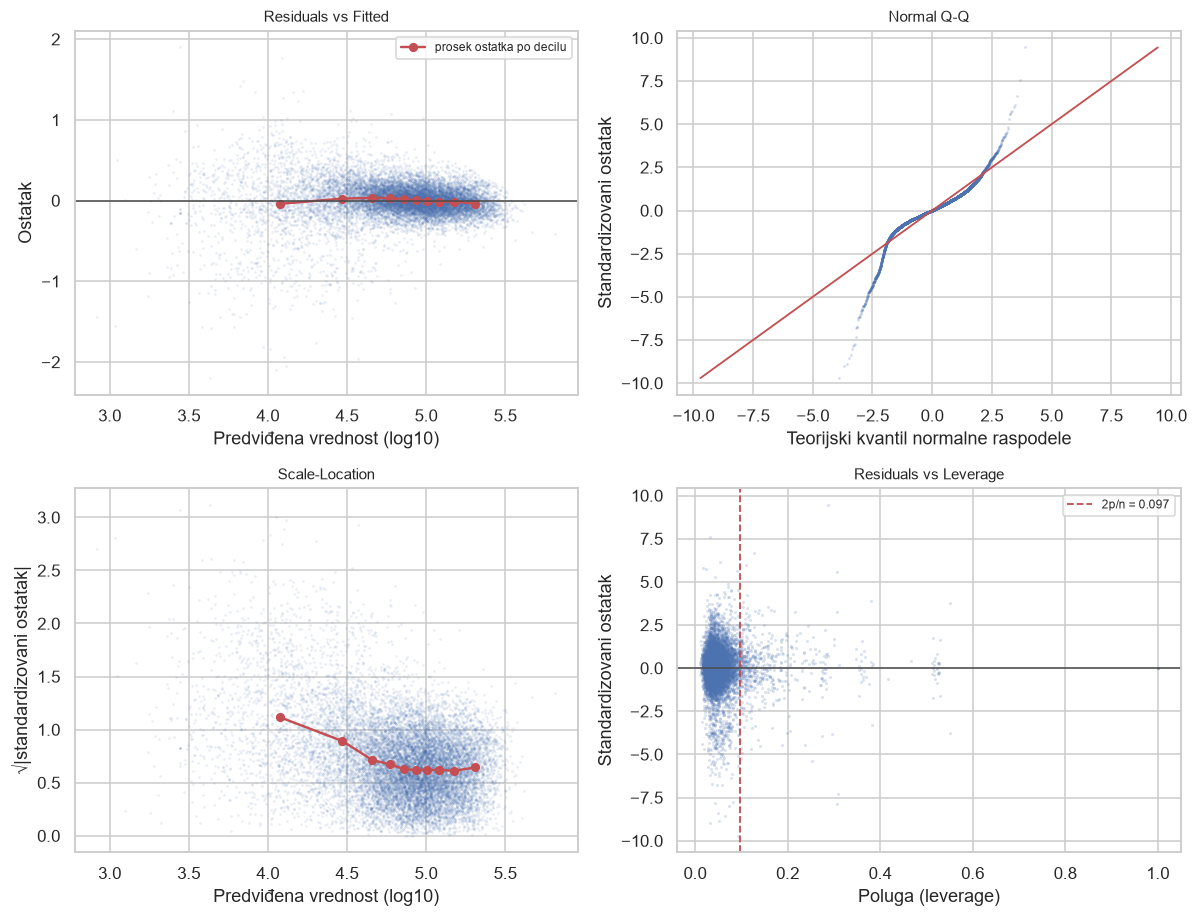

prosek ostatka po decilu, od najmanjeg predviđanja ka najvećem:
  -0.040  +0.024  +0.034  +0.030  +0.017  +0.004  -0.002  -0.018  -0.012  -0.038
  najveće odstupanje od nule: 0.040

√|standardizovani ostatak| po decilu:
  1.12  0.89  0.71  0.67  0.63  0.62  0.62  0.62  0.61  0.64

standardizovani ostatak: najmanji -9.71   najveći 9.45
  ispod −3: 246   iznad +3: 90

rasipanje: sd ostatka 0.4825 u najnižem decilu, 0.1385 u najvišem, odnos 3.48
           bez prva dva decila odnos 1.55
normalnost: asimetrija -1.088   spljoštenost +9.677   (kod normalne oba nula)
           ostatka izvan tri standardne devijacije 2.12%   (kod normalne 0,27%)


In [155]:
residual = full_model.resid
fitted = full_model.fittedvalues
parameters = full_design.shape[1]

# Leverage from the QR factorisation: the diagonal of the hat matrix is the row
# norm of Q, which is far cheaper than forming the hat matrix itself.
orthogonal, _ = np.linalg.qr(full_design)
leverage = np.einsum("ij,ij->i", orthogonal, orthogonal)
sigma = np.sqrt(full_model.mse_resid)
standardized = residual / (sigma * np.sqrt(np.clip(1 - leverage, 1e-12, None)))

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))

ax = axes[0, 0]
ax.scatter(fitted, residual, s=3, alpha=0.12, color="#4C72B0", linewidths=0)
decile = pd.qcut(fitted, 10, labels=False)
centres = pd.Series(fitted).groupby(decile).median()
means = pd.Series(residual).groupby(decile).mean()
ax.plot(centres, means, marker="o", markersize=5, color="#C44E52", linewidth=1.6,
        label="prosek ostatka po decilu")
ax.axhline(0, color="#4C4C4C", linewidth=1)
ax.set_xlabel("Predviđena vrednost (log10)")
ax.set_ylabel("Ostatak")
ax.set_title("Residuals vs Fitted", fontsize=10)
ax.legend(fontsize=8)

ax = axes[0, 1]
(theoretical, ordered), _ = stats.probplot(standardized, dist="norm", fit=False), None
ax.scatter(theoretical, ordered, s=3, alpha=0.25, color="#4C72B0", linewidths=0)
limit = [min(theoretical.min(), ordered.min()), max(theoretical.max(), ordered.max())]
ax.plot(limit, limit, color="#C44E52", linewidth=1.2)
ax.set_xlabel("Teorijski kvantil normalne raspodele")
ax.set_ylabel("Standardizovani ostatak")
ax.set_title("Normal Q-Q", fontsize=10)

ax = axes[1, 0]
ax.scatter(fitted, np.sqrt(np.abs(standardized)), s=3, alpha=0.12,
           color="#4C72B0", linewidths=0)
root_means = pd.Series(np.sqrt(np.abs(standardized))).groupby(decile).mean()
ax.plot(centres, root_means, marker="o", markersize=5, color="#C44E52", linewidth=1.6)
ax.set_xlabel("Predviđena vrednost (log10)")
ax.set_ylabel("√|standardizovani ostatak|")
ax.set_title("Scale-Location", fontsize=10)

ax = axes[1, 1]
ax.scatter(leverage, standardized, s=4, alpha=0.2, color="#4C72B0", linewidths=0)
ax.axvline(2 * parameters / len(X_train), color="#C44E52", linestyle="--", linewidth=1.2,
           label=f"2p/n = {2 * parameters / len(X_train):.3f}")
ax.axhline(0, color="#4C4C4C", linewidth=1)
ax.set_xlabel("Poluga (leverage)")
ax.set_ylabel("Standardizovani ostatak")
ax.set_title("Residuals vs Leverage", fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"prosek ostatka po decilu, od najmanjeg predviđanja ka najvećem:")
print("  " + "  ".join(f"{value:+.3f}" for value in means))
print(f"  najveće odstupanje od nule: {means.abs().max():.3f}")
print()
print(f"√|standardizovani ostatak| po decilu:")
print("  " + "  ".join(f"{value:.2f}" for value in root_means))
print()
print(f"standardizovani ostatak: najmanji {standardized.min():.2f}   "
      f"najveći {standardized.max():.2f}")
print(f"  ispod −3: {int((standardized < -3).sum())}   "
      f"iznad +3: {int((standardized > 3).sum())}")
print()
# Descriptive numbers for the two panels that show a problem, so the verdict
# does not rest on reading a picture.
by_decile = pd.Series(residual).groupby(decile).std(ddof=0)
print(f"rasipanje: sd ostatka {by_decile.iloc[0]:.4f} u najnižem decilu, "
      f"{by_decile.iloc[-1]:.4f} u najvišem, odnos {by_decile.iloc[0] / by_decile.iloc[-1]:.2f}")
print(f"           bez prva dva decila odnos "
      f"{by_decile.iloc[2:].max() / by_decile.iloc[2:].min():.2f}")
print(f"normalnost: asimetrija {float(stats.skew(residual)):+.3f}   "
      f"spljoštenost {float(stats.kurtosis(residual)):+.3f}   (kod normalne oba nula)")
print(f"           ostatka izvan tri standardne devijacije "
      f"{100 * np.mean(np.abs(residual) > 3 * sigma):.2f}%   (kod normalne 0,27%)")

**Zapažanje:** četiri panela daju tri različita odgovora.

**Residuals vs Fitted — linearnost stoji.** Oblak je centriran oko nule kroz ceo raspon — prosek ostatka po decilima ne
odstupa od nule više od **0,040**.

**Scale-Location — rasipanje nije ujednačeno.** Prosek korena standardizovanog ostatka pada sa **1,12** u prvom decilu na
**0,64** u poslednjem, i pad je sistematski. Isti nalaz kao u 36.2: odnos **3,48** između dna i vrha,
**1,55** bez prva dva decila.

**Normal Q-Q — ostatak nije normalan.** Oba repa odstupaju — standardizovani ostatak ide od
**−9,71** do **+9,45**, dok bi kod normalne raspodele na 14.608 redova krajnosti bile oko ±4. Repovi su
po dometu slični ali ne i po gustini: ispod −3 ima **246** ispitanika, iznad +3 samo **90**. Asimetrija
je **−1,088**, spljoštenost **+9,677**, a ostatka izvan tri standardne devijacije je **2,12%** naspram
0,27% koliko bi dala normalna raspodela.

**Residuals vs Leverage.** Većina tačaka je pri niskoj poluzi, ali se vidi rep koji ide do jedinice, i tamošnje tačke
imaju ostatak oko nule.

**Tumačenje:** linearnost je u redu, i to nije bilo zagarantovano — u prethodnom delu smo izmerili
da veza broja izabranih stavki i plate nije prava linija, ali kod 707 kolona ostale imaju dovoljno
slobode da to pokriju.

Druge dve pretpostavke su narušene i imaju isti uzrok: onaj levi rep. Praktična posledica je jedna i
treba je zapisati: **p-vrednosti i intervali poverenja za pojedinačne koeficijente ovog modela nisu
pouzdani.**

Interval poverenja je, sa predavanja, raspon `β̂ ± 2·SE(β̂)` za koji tvrdimo da sa 95% poverenja sadrži
pravu vrednost koeficijenta; p-vrednost se računa iz iste standardne greške `SE`. A formula za `SE`
izvedena je pod pretpostavkom da je rasipanje ostatka svuda isto i da je ostatak normalan — dakle pod
tačno one dve pretpostavke koje smo upravo oborili. Sam koeficijent time nije pogrešan, ali raspon oko
njega jeste, i ne znamo ni u kom smeru.

Predviđanja to ne kvari, jer se mere unakrsnom validacijom, koja se na te pretpostavke ne oslanja — ali u
osmoj sekciji koeficijente treba čitati kao veličine, a ne kao rezultate testova.

Poslednji panel otvara pitanje koje sledeći odeljak razrešava brojevima.

### 36.4 Poluga i uticajne opservacije

Poslednji panel je pokazao tačke sa polugom blizu jedinice, i tu je lako pomešati tri različite stvari.
Sa predavanja ih razdvajamo ovako:

| pojam | šta znači | čime se meri | granica sa predavanja |
| --- | --- | --- | --- |
| **netipična vrednost** | ispitanik čiju platu model promašuje | studentizovani ostatak | veći od 3 po apsolutnoj vrednosti |
| **visoka poluga** | ispitanik sa neobičnom **kombinacijom prediktora**, bez obzira na platu | poluga, `hatvalues` | veća od 2(p+1)/n |
| **uticajna opservacija** | ona čije bi izbacivanje pomerilo model | Cook-ova distanca | veća od 1 |

Tri mere iz treće kolone ukratko podsećamo, jer se odavde nadalje samo koriste.
**Studentizovani ostatak** je ostatak podeljen sopstvenom standardnom greškom, i to izračunatom kao da je
taj red izostavljen iz modela — dobija se broj koji se čita kao z-vrednost, pa granica 3 znači „tri
standardne greške od nule". **Poluga** je udeo koji jedan red ima u sopstvenom predviđanju: ako je nula,
predviđanje za njega dolazi isključivo od ostalih redova, ako je jedan, dolazi samo od njega.
**Cook-ova distanca** spaja to dvoje u jedan broj — koliko bi se sva predviđanja pomerila da tog reda
nema.

Razlika između poluge i uticaja je ono što se najlakše previdi, pa vredi reći svojim rečima. **Poluga** ne
zna ništa o plati — ona meri samo koliko je ispitanikova kombinacija odgovora neobična u odnosu na
ostale. Ispitanik može biti krajnje neobičan a da model ni ne pomeri, ako mu je plata baš onakva kakvu
model za takvu kombinaciju i predviđa. **Uticaj** spaja to dvoje: neobična kombinacija **i** promašena
plata.

Poluga ima i osobinu koju treba znati da bi se brojevi pročitali: prosečna poluga je uvek `p/n`, dakle
kod nas oko 0,05, a najveća moguća je **1**. Poluga jednaka jedinici znači da model tog ispitanika
predviđa **tačno**, sa ostatkom nula — ne zato što ga je razumeo, nego zato što mu je posvetio sopstveni
parametar.

Jedna tehnička napomena: Cook-ova distanca u imeniocu ima `(1 − poluga)²`, pa kod poluge jednake jedinici
deli nulom. Takve ispitanike izdvajamo posebno, jer su oni sami po sebi nalaz.

### Grafik 31 — kako je poluga raspoređena

**Motivacija:** iz Grafika 30 se vidi da rep postoji, ali ne i koliko je gust — a to je razlika između
„nekoliko neobičnih ispitanika" i „model se drži na malom broju ljudi". Crtamo raspodelu poluge, sa
uspravnom osom u logaritmu, jer je inače vrh oko prosečne vrednosti toliko visok da se rep ne vidi.

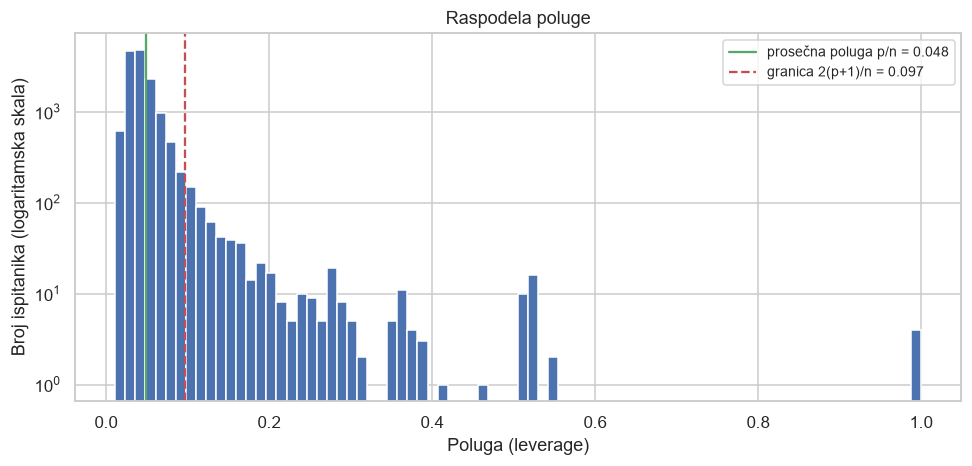

prosečna poluga p/n                             0.0485
granica 2(p+1)/n                                0.0969
najveća poluga                                  1.0000

netipičnih (|studentizovani ostatak| > 3)      336
sa visokom polugom (> 2(p+1)/n)                612
sa polugom praktično jednakom 1                  4

Cook-ova distanca, bez tih 4:
  najveća 0.0506   preko granice od 1: 0

tri najuticajnija ispitanika:
  plata   220,000   predviđeno     2,783   poluga 0.286   Cook 0.0506
  plata        30   predviđeno     1,082   poluga 0.307   Cook 0.0387
  plata        30   predviđeno       838   poluga 0.309   Cook 0.0338

ispitanika sa platom ispod 1.000 USD: 89   od njih netipičnih: 80
ispitanici koje model predviđa tačno (poluga ~ 1):
  plata    76,000   ostatak +2.40e-14
  plata    83,200   ostatak +1.95e-14
  plata    73,089   ostatak +1.42e-14
  plata    80,000   ostatak +1.95e-14


In [156]:
average_leverage = parameters / len(X_train)
limit_leverage = 2 * parameters / len(X_train)
exactly_fitted = np.where(leverage > 0.999)[0]

# The externally studentized residual the lectures use for outliers: the same
# standardized residual, rescaled as if the row had been left out of the fit.
degrees = len(X_train) - parameters
studentized = standardized * np.sqrt((degrees - 1) / (degrees - standardized ** 2))

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.hist(leverage, bins=80, color="#4C72B0")
ax.set_yscale("log")
ax.axvline(average_leverage, color="#55A868", linewidth=1.5,
           label=f"prosečna poluga p/n = {average_leverage:.3f}")
ax.axvline(limit_leverage, color="#C44E52", linestyle="--", linewidth=1.5,
           label=f"granica 2(p+1)/n = {limit_leverage:.3f}")
ax.set_xlabel("Poluga (leverage)")
ax.set_ylabel("Broj ispitanika (logaritamska skala)")
ax.set_title("Raspodela poluge")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'prosečna poluga p/n':<44} {average_leverage:>9.4f}")
print(f"{'granica 2(p+1)/n':<44} {limit_leverage:>9.4f}")
print(f"{'najveća poluga':<44} {leverage.max():>9.4f}")
print()
print(f"{'netipičnih (|studentizovani ostatak| > 3)':<44} "
      f"{int((np.abs(studentized) > 3).sum()):>5}")
print(f"{'sa visokom polugom (> 2(p+1)/n)':<44} "
      f"{int((leverage > limit_leverage).sum()):>5}")
print(f"{'sa polugom praktično jednakom 1':<44} {len(exactly_fitted):>5}")
print()

# Cook's distance, with the exactly fitted rows left out: for them the formula
# divides by zero and the result would be an artefact of that.
usable = leverage <= 0.999
variance = float(residual[usable] @ residual[usable]) / (usable.sum() - parameters)
cooks = np.full(len(X_train), np.nan)
cooks[usable] = ((residual[usable] ** 2 / (parameters * variance))
                 * (leverage[usable] / (1 - leverage[usable]) ** 2))

print(f"Cook-ova distanca, bez tih {len(exactly_fitted)}:")
print(f"  najveća {np.nanmax(cooks):.4f}   preko granice od 1: {int(np.nansum(cooks > 1))}")
print()
print("tri najuticajnija ispitanika:")
for row in np.argsort(np.nan_to_num(cooks))[-3:][::-1]:
    print(f"  plata {train[TARGET].iloc[row]:>9,.0f}   predviđeno {10 ** fitted[row]:>9,.0f}   "
          f"poluga {leverage[row]:.3f}   Cook {cooks[row]:.4f}")
print()
low_pay = train[TARGET].to_numpy() < 1000
print(f"ispitanika sa platom ispod 1.000 USD: {int(low_pay.sum())}   "
      f"od njih netipičnih: {int((np.abs(studentized[low_pay]) > 3).sum())}")
print("ispitanici koje model predviđa tačno (poluga ~ 1):")
for row in exactly_fitted:
    print(f"  plata {train[TARGET].iloc[row]:>9,.0f}   ostatak {residual[row]:+.2e}")

**Zapažanje:** grafik pokazuje jedan visok vrh i dugačak, **redak** rep. Zbog logaritamske ose vidi se da
u repu iza granice stoje desetine, a ne hiljade ispitanika, i da su vrednosti blizu jedinice
pojedinačne.

Brojevi razdvajaju tri pojma:

- **netipičnih** vrednosti, sa studentizovanim ostatkom preko 3, ima **336**;
- **visoku polugu**, preko granice od **0,097**, ima **612** ispitanika, pri prosečnoj poluzi **0,048**;
- **polugu praktično jednaku jedinici** imaju **četiri** ispitanika, sa ostatkom reda 10⁻¹⁴.

**Uticajnih opservacija nema.** Kad se ta četiri izuzmu, najveća Cook-ova distanca je **0,0506**, dakle
dvadeset puta manja od granice, i nijedan ispitanik je ne prelazi. Najuticajniji je onaj sa platom
**220.000** dolara kome model predviđa **2.783**, pa dva sa prijavljenih **30** dolara.

Od **89** ispitanika sa platom ispod hiljadu dolara, **80** su netipične vrednosti.

**Tumačenje:** ovo je bolja vest nego što je Grafik 30 sugerisao, uz jedan izuzetak.

Nijedan pojedinačni ispitanik ne vuče model — pri 14.608 redova jedan red i ne može mnogo da pomeri
procenu, pa je Cook-ova distanca svuda mala. To znači da ne treba ništa izbacivati, i da bi izbacivanje
bilo pogrešno: čišćenje je završeno u prethodnom delu, a vraćanje na njega ovde značilo bi da
podatke prilagođavamo modelu.

Izuzetak su ona četiri ispitanika sa polugom jedan. Očekivali smo da su to ljudi sa nekom retkom
kategorijom, i **provera to ne potvrđuje** — nijedan od njih ne nosi ni jednu kolonu koja je jedinica kod
pet ili manje ispitanika. Izdvaja ih **kombinacija** od 707 kolona, i tu kombinaciju ne umemo da pokažemo
jednostavnije. To je konkretno lice onoga što smo u 34.5 izmerili: sa ovoliko kolona model ima dovoljno
slobode da pojedine ljude nauči napamet. Rešenje je regularizacija, koja mu tu slobodu oduzima, i njome
se bave sledeće dve sekcije.

Ispitanici sa vrlo malim iznosima izdvajaju se i ovde, treći put u sekciji: oni prave obrnutu lepezu u
3.2, gušći levi rep u 3.3, a sada se pokazuje da su gotovo svi i netipične vrednosti. To je ograničenje
uzorka i ide u zaključak.

### Šta sekcija ostavlja sledećoj

**Obična regresija sa 707 nezavisnih kolona daje unakrsni R² od 0,6769**, uz tipičan promašaj 24,8% i
predviđanje u okviru dvostruko kod 87,5% ispitanika. Letvicu iz 35.5 prelazi za **+0,0101**.

Četiri nalaza se prenose dalje:

- **doprinos prethodnog dela je skroman na podacima koje model nije video** — +0,0101, a razlika
  trening i unakrsnog R² (0,0440) skoro se poklapa sa 0,0471 koliko je u 34.5 izmereno kao prilagođavanje
  šumu;
- **logaritam je bio pravi izbor, ali ne rešava sve.** Na osamdeset posto raspona odnos rasipanja je
  1,55, a na dnu 3,48. Uz to isključuje negativna predviđanja, kojih model u dolarima ima 419;
- **od tri pretpostavke jedna stoji.** Linearnost je u redu, rasipanje i normalnost nisu, pa se
  p-vrednosti pojedinačnih koeficijenata ne smeju čitati kao pouzdane;
- **uticajnih opservacija nema** (najveća Cook-ova distanca 0,0506), ali **četiri ispitanika model uči
  napamet**, sa polugom jednakom jedinici.

Sledeća sekcija uvodi Ridge regresiju: isti model, ali sa kaznom za veličinu koeficijenata.

## 37. Ridge regresija

Sekcija 34.5 je izmerila da model sa 707 kolona ima previše slobode, a sekcija 36 je pokazala kako to
izgleda: četiri ispitanika koje predviđa napamet i razliku od 0,0440 između trening i unakrsnog R².
Ridge je prvi odgovor na to sa predavanja.

Ideja je da se uz sumu kvadrata ostataka minimizuje i **kazna za veličinu koeficijenata**, `λ·Σβ²`.
Model time ne dobija manje kolona nego **manje slobode u svakoj**: koeficijenti se skupljaju ka nuli, ali
nijedan ne postaje tačno nula. Kod korelisanih prediktora — a mi ih imamo, 96 dummy kolona sa VIF-om
preko 10 — to stabilizuje ocene, jer model više ne može da jednoj koloni da veliki pozitivan a drugoj
veliki negativan koeficijent.

### 37.1 Izbor λ

Dve stvari određuju kako se to izvodi:

- **standardizacija ide unutar unakrsne validacije**, kako smo se dogovorili u 1.4. Kazna se odnosi na
  veličinu koeficijenata, pa bi kolona merena u drugoj jedinici bila drugačije kažnjena; a skaliranje
  mora da se računa na delu za učenje, ne na celom skupu;
- **λ ne biramo nego ga izvodimo** — probamo mrežu vrednosti i uzimamo onu sa najboljom unakrsnom
  greškom. Slobodan član se ne kažnjava.

In [157]:
from sklearn.linear_model import Ridge, lasso_path
from sklearn.preprocessing import StandardScaler

# Regularized models get the design without the column of ones: they fit their
# own intercept and, unlike the other coefficients, do not penalise it.
regularized_design = X_train[independent].to_numpy(dtype=float)


def scaled_fit_predict(make_model):
    """Standardize on the fold being learned from, then fit and predict.

    Doing it this way rather than scaling everything up front is what keeps a
    fold from being scaled with information out of the part it is tested on.
    """
    def fit_predict(design_fit, target_fit, design_eval):
        scaler = StandardScaler().fit(design_fit)
        model = make_model().fit(scaler.transform(design_fit), target_fit)
        return model.predict(scaler.transform(design_eval))
    return fit_predict


# A wide grid, so the best value is found inside it rather than at an edge.
RIDGE_ALPHAS = np.logspace(3, -2, 30)

ridge_scores = []
for value in RIDGE_ALPHAS:
    predicted = cross_validated(regularized_design, y_train,
                                scaled_fit_predict(lambda a=value: Ridge(alpha=a)))
    ridge_scores.append(metrics(y_train, predicted))

ridge_table = pd.DataFrame(ridge_scores, index=RIDGE_ALPHAS)
best_alpha = float(ridge_table["R2"].idxmax())
ridge_cv = cross_validated(regularized_design, y_train,
                           scaled_fit_predict(lambda: Ridge(alpha=best_alpha)))

print("unakrsni R² za nekoliko vrednosti λ:")
for value in RIDGE_ALPHAS[::4]:
    print(f"  λ = {value:>9.4g}   R² = {ridge_table.loc[value, 'R2']:.4f}")
print()
print(f"najbolja λ: {best_alpha:.4g}   unakrsni R² {ridge_table['R2'].max():.4f}")
print(f"obična regresija iz 36.1:       {reference.loc['sve kolone, regresija', 'R2']:.4f}")
print(f"razlika:                        "
      f"{ridge_table['R2'].max() - reference.loc['sve kolone, regresija', 'R2']:+.4f}")
print(f"raspon R² kroz celu mrežu λ:    {ridge_table['R2'].min():.4f} do {ridge_table['R2'].max():.4f}")
print()

# How much the penalty actually shrank things, against the unpenalised fit.
scaler_all = StandardScaler().fit(regularized_design)
scaled_all = scaler_all.transform(regularized_design)
ridge_full = Ridge(alpha=best_alpha).fit(scaled_all, y_train)
ols_scaled = np.linalg.lstsq(np.column_stack([np.ones(len(scaled_all)), scaled_all]),
                             y_train.to_numpy(), rcond=None)[0][1:]
print(f"{'':<24} {'Ridge':>10} {'bez kazne':>10}")
print(f"{'najveći |koeficijent|':<24} {np.abs(ridge_full.coef_).max():>10.4f} "
      f"{np.abs(ols_scaled).max():>10.4f}")
print(f"{'suma kvadrata koeficijenata':<24} {(ridge_full.coef_ ** 2).sum():>10.4f} "
      f"{(ols_scaled ** 2).sum():>10.4f}")
print(f"{'koeficijenata tačno nula':<24} {int((ridge_full.coef_ == 0).sum()):>10} "
      f"{int((ols_scaled == 0).sum()):>10}")
print()

# Which columns the penalty actually works on: the claim above is about
# correlated predictors, and it is checkable only if they are named.
shrinkage = pd.DataFrame({"kolona": independent, "bez_kazne": ols_scaled,
                          "Ridge": ridge_full.coef_})
shrinkage["razlika"] = shrinkage["bez_kazne"].abs() - shrinkage["Ridge"].abs()
largest = shrinkage.reindex(
    shrinkage["razlika"].abs().sort_values(ascending=False).index).head(10)
print("deset kolona koje je kazna najviše promenila:")
print(largest.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))

reference.loc["Ridge"] = pd.Series(metrics(y_train, ridge_cv))

unakrsni R² za nekoliko vrednosti λ:
  λ =      1000   R² = 0.6795
  λ =     204.3   R² = 0.6791
  λ =     41.75   R² = 0.6778
  λ =     8.532   R² = 0.6772
  λ =     1.743   R² = 0.6771
  λ =    0.3562   R² = 0.6770
  λ =   0.07279   R² = 0.6769
  λ =   0.01487   R² = 0.6769

najbolja λ: 672.3   unakrsni R² 0.6798
obična regresija iz 36.1:       0.6769
razlika:                        +0.0029
raspon R² kroz celu mrežu λ:    0.6769 do 0.6798



                              Ridge  bez kazne
najveći |koeficijent|        0.1005     0.1565
suma kvadrata koeficijenata     0.0656     0.1576
koeficijenata tačno nula          0          0

deset kolona koje je kazna najviše promenila:
                            kolona  bez_kazne   Ridge  razlika
        Currency_EUR European Euro    +0.1565 +0.0273  +0.1292
 Currency_USD United States dollar    +0.1266 +0.0313  +0.0954
       Currency_GBP Pound sterling    +0.0814 +0.0187  +0.0627
  Country_United States of America    +0.1561 +0.1005  +0.0557
         Currency_INR Indian rupee    -0.0002 -0.0439  -0.0437
      Currency_CAD Canadian dollar    +0.0519 +0.0117  +0.0401
        Currency_SEK Swedish krona    +0.0417 +0.0032  +0.0385
         Currency_DKK Danish krone    +0.0460 +0.0112  +0.0348
      Currency_VND Vietnamese dong    +0.0427 +0.0093  +0.0334
SODuration_Between 10 and 15 years    +0.0711 +0.0383  +0.0328


**Zapažanje:** Ridge pobeđuje običnu regresiju, ali malo. Najbolja λ je **672,3**, sa unakrsnim R² od
**0,6798** naspram **0,6769** — razlika **+0,0029**.

Zanimljivije je koliko je kriva **ravna**: kroz celu mrežu λ, od 0,01 do 1.000, unakrsni R² se kreće samo
od **0,6769 do 0,6798**. Dakle nijedna vrednost kazne ne pravi veliku razliku, ni na bolje ni na gore.

Kazna pri tome jasno radi svoj posao: najveći koeficijent pada sa **0,1565** na **0,1005**, a suma
kvadrata sa **0,1576** na **0,0656**, dakle na manje od polovine. Nijedan koeficijent nije postao tačno
nula, što je i očekivano — Ridge to po konstrukciji ne radi.

Tabela na kraju ispisa pokazuje **gde** kazna udara, i to je najkorisniji deo. Od deset kolona koje je
najviše promenila, **devet su valute**: `Currency_EUR` pada sa **+0,1565** na **+0,0273**,
`Currency_USD` sa **+0,1266** na **+0,0313**, `Currency_GBP` sa **+0,0814** na **+0,0187**. Deseta je
`Country_United States of America`, sa **+0,1561** na **+0,1005**.

Jedan red ide u suprotnom smeru: `Currency_INR Indian rupee` bez kazne ima koeficijent **−0,0002**,
dakle praktično nulu, a sa kaznom **−0,0439**.

**Tumačenje:** rezultat je koristan i kad je mali, jer kaže nešto o tome gde je problem.

Prvo, tabela je kolinearnost uhvaćena na delu. Valuta i zemlja nose istu vrstu podatka — na kom tržištu
ispitanik zarađuje — pa regresija bez kazne sme da najveći deo tog efekta pripiše jednoj koloni a drugoj
skoro ništa. Tako je indijskoj rupiji dala nulu, a evru najveći koeficijent u celom modelu. Ridge tu
slobodu oduzima, jer kažnjava **zbir kvadrata**, a on je pri istom ukupnom efektu najmanji kad je efekat
**razdeljen** na više kolona. Otud se veliki koeficijenti spuštaju, a onaj koji je bio na nuli podiže.

Drugo, to što uz sve to Ridge dobija samo +0,0029 znači da **naš model ne gubi zbog velikih
koeficijenata** — kolinearnost među dummy kolonama, koju smo merili u prethodnom delu, kvari
čitljivost koeficijenata ali ne i predviđanja. To se sa predavanja i očekuje, a sada je izmereno na našim
podacima.

Ono što Ridge ne rešava je **broj** kolona: model i dalje koristi svih 707, samo sa manjim
koeficijentima. Ako je pravi problem to što stotine kolona ne nose ništa, treba nam postupak koji ume da
ih izbaci — i to je Lasso.

### Grafik 32 — šta kazna radi sa greškom i sa koeficijentima

**Motivacija:** iz jedne najbolje vrednosti λ ne vidi se oblik. Zanima nas da li greška ima jasan minimum
ili je ravna, i koliko se koeficijenti skupljaju duž istog raspona — jer to dvoje zajedno pokazuje da li
je kazna uopšte ono što ovom modelu treba. Crtamo oba u dva panela, sa λ na logaritamskoj osi, jer se
mreža i pravi logaritamski.

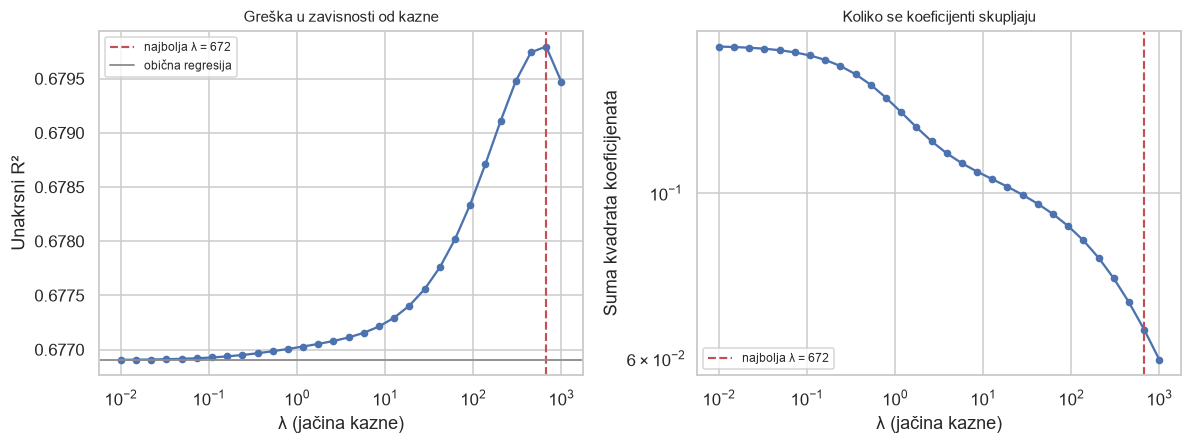

unakrsni R²: najmanji 0.6769 pri λ = 0.01, najveći 0.6798 pri λ = 672.3
suma kvadrata koeficijenata: 0.1571 pri najmanjoj λ, 0.0598 pri najvećoj
pri najboljoj λ iznosi 0.0656


In [158]:
sizes = []
for value in RIDGE_ALPHAS:
    fitted_ridge = Ridge(alpha=value).fit(scaled_all, y_train)
    sizes.append(float((fitted_ridge.coef_ ** 2).sum()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.plot(RIDGE_ALPHAS, ridge_table["R2"], marker="o", markersize=4, color="#4C72B0")
ax.axvline(best_alpha, color="#C44E52", linestyle="--", linewidth=1.4,
           label=f"najbolja λ = {best_alpha:.0f}")
ax.axhline(reference.loc["sve kolone, regresija", "R2"], color="#8C8C8C",
           linewidth=1.2, label="obična regresija")
ax.set_xscale("log")
ax.set_xlabel("λ (jačina kazne)")
ax.set_ylabel("Unakrsni R²")
ax.set_title("Greška u zavisnosti od kazne", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(RIDGE_ALPHAS, sizes, marker="o", markersize=4, color="#4C72B0")
ax.axvline(best_alpha, color="#C44E52", linestyle="--", linewidth=1.4,
           label=f"najbolja λ = {best_alpha:.0f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("λ (jačina kazne)")
ax.set_ylabel("Suma kvadrata koeficijenata")
ax.set_title("Koliko se koeficijenti skupljaju", fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"unakrsni R²: najmanji {ridge_table['R2'].min():.4f} pri λ = {ridge_table['R2'].idxmin():.4g}, "
      f"najveći {ridge_table['R2'].max():.4f} pri λ = {best_alpha:.4g}")
print(f"suma kvadrata koeficijenata: {max(sizes):.4f} pri najmanjoj λ, {min(sizes):.4f} pri najvećoj")
print(f"pri najboljoj λ iznosi {sizes[int(np.argmin(np.abs(RIDGE_ALPHAS - best_alpha)))]:.4f}")

**Zapažanje:** levi panel nema izražen minimum — kriva je gotovo vodoravna, sa vrhom oko λ = 672 i padom
prema najmanjim vrednostima kazne koji iznosi svega tri hiljadita dela. Siva linija, koja označava običnu
regresiju, praktično se poklapa sa levim krajem krive, što je i tačno: pri λ blizu nule Ridge se svodi na
običnu regresiju.

Desni panel se menja više: suma kvadrata koeficijenata pada sa **0,1571** pri najslabijoj kazni na
**0,0598** pri najjačoj, dakle **2,6 puta** duž istog raspona λ. Pri najboljoj λ iznosi **0,0656**.

**Tumačenje:** dva panela zajedno kažu ono što jedan ne bi. Kazna menja koeficijente osetno više nego
što menja grešku: suma kvadrata pada na manje od polovine, a unakrsni R² se pomera samo u trećoj
decimali. Model, dakle, nije bio zavistan od velikih koeficijenata — mogu se prepoloviti bez gubitka,
ali se time i ne dobija skoro ništa.

To je i praktičan zaključak za rad: Ridge ostaje u poređenju modela kao ozbiljna mogućnost, ali od njega
ne treba očekivati preokret. Ako preokret postoji, treba ga tražiti u tome koje se kolone izbacuju, ne u
tome koliko su koeficijenti veliki.

### Šta sekcija ostavlja sledećoj

**Ridge sa λ = 672,3 daje unakrsni R² 0,6798**, naspram 0,6769 obične regresije — dakle **+0,0029**.

Dva nalaza:

- **kriva greške je ravna.** Kroz raspon λ od 0,01 do 1.000 unakrsni R² se menja samo u trećoj decimali,
  pa izbor λ ovde nije osetljiv;
- **kazna radi, ali na pogrešnom problemu.** Suma kvadrata koeficijenata pada na manje od polovine
  (0,1571 na 0,0598, dakle 2,6 puta) bez gubitka u grešci, a najviše se skupljaju dummy kolone za valute,
  koje nose istu informaciju kao zemlja. Veliki koeficijenti, dakle, nisu bili to što modelu šteti.

Sledeća sekcija menja vrstu kazne: Lasso kažnjava sumu **apsolutnih** vrednosti, što neke koeficijente
spušta tačno na nulu i time ujedno radi izbor promenljivih.

## 38. Lasso regresija

Lasso je ista ideja kao Ridge sa jednom izmenom: kažnjava se `λ·Σ|β|` umesto `λ·Σβ²`. Posledica te izmene
nije mala. Kod apsolutne vrednosti optimum često pada tačno na nulu, pa Lasso pojedine koeficijente
**ukine**, a ne samo smanji. Time istovremeno radi dve stvari — regularizuje model i **bira promenljive**.

Za nas je to drugo važnije od prvog. Iz prethodnog dela nosimo 352 kolone koje smo sami napravili i
otvorenu stavku da „formalna selekcija tek treba da odluči šta ostaje". Lasso je upravo taj postupak, i
odgovor na to pitanje daje sam, bez da mu mi kažemo šta da zadrži.

### 38.1 Izbor λ i koliko kolona ostaje

λ se bira isto kao kod Ridge-a, unakrsnom validacijom nad mrežom vrednosti, uz standardizaciju unutar
svakog dela.

In [159]:
# The path is computed with a warm start from the previous value of lambda, which
# is why the whole grid costs about as much as one fit from cold.
LASSO_ALPHAS = np.logspace(-1, -3.5, 30)


def lasso_out_of_fold(design, target, alphas, folds=FOLDS, seed=SEED):
    """Out-of-fold predictions for every lambda at once.

    lasso_path fits no intercept, so the target is centred on the fold being
    learned from and the centre is added back to the prediction.
    """
    target = np.asarray(target, dtype=float)
    predictions = np.empty((len(alphas), len(target)))
    splitter = KFold(n_splits=folds, shuffle=True, random_state=seed)
    for fit_rows, eval_rows in splitter.split(design):
        scaler = StandardScaler().fit(design[fit_rows])
        centre = float(target[fit_rows].mean())
        used, coefficients, _ = lasso_path(scaler.transform(design[fit_rows]),
                                           target[fit_rows] - centre,
                                           alphas=alphas, max_iter=3000, tol=1e-3)
        assert np.allclose(used, alphas), "lasso_path je promenio poredak λ"
        predictions[:, eval_rows] = (scaler.transform(design[eval_rows])
                                     @ coefficients + centre).T
    return predictions


lasso_predictions = lasso_out_of_fold(regularized_design, y_train, LASSO_ALPHAS)
lasso_table = pd.DataFrame([metrics(y_train, row) for row in lasso_predictions],
                           index=LASSO_ALPHAS)
best_lasso = float(lasso_table["R2"].idxmax())

# The same path on the whole training set, to see which columns survive.
_, lasso_coefficients, _ = lasso_path(scaled_all, y_train - y_train.mean(),
                                      alphas=LASSO_ALPHAS, max_iter=5000, tol=1e-4)
nonzero = (lasso_coefficients != 0).sum(axis=0)
chosen = int(np.argmin(np.abs(LASSO_ALPHAS - best_lasso)))

print(f"{'λ':>9} {'unakrsni R²':>13} {'kolona u modelu':>16}")
for position in range(0, len(LASSO_ALPHAS), 3):
    print(f"{LASSO_ALPHAS[position]:>9.5f} {lasso_table['R2'].iloc[position]:>13.4f} "
          f"{nonzero[position]:>16}")
print()
print(f"najbolja λ: {best_lasso:.5f}   unakrsni R² {lasso_table['R2'].max():.4f}")
print(f"kolona sa koeficijentom različitim od nule: {nonzero[chosen]} od {len(independent)}")
print(f"kolona koje je Lasso ukinuo:                {len(independent) - nonzero[chosen]}")
print()
# The two ends of the grid, which is where the shape of the curve shows.
print(f"pri najslabijoj kazni: {nonzero[-1]} kolona, unakrsni R² "
      f"{lasso_table['R2'].iloc[-1]:.4f}")
print(f"pri najjačoj kazni:    {nonzero[0]} kolona, unakrsni R² "
      f"{lasso_table['R2'].iloc[0]:.4f}")
print()
for name, value in [("obična regresija", reference.loc["sve kolone, regresija", "R2"]),
                    ("Ridge", reference.loc["Ridge", "R2"]),
                    ("Lasso", lasso_table["R2"].max())]:
    print(f"  {name:<18} {value:.4f}")
print(f"  Lasso preko obične regresije: "
      f"{lasso_table['R2'].max() - reference.loc['sve kolone, regresija', 'R2']:+.4f}")
print(f"  Lasso preko Ridge-a:          "
      f"{lasso_table['R2'].max() - reference.loc['Ridge', 'R2']:+.4f}")

reference.loc["Lasso"] = pd.Series(metrics(y_train, lasso_predictions[chosen]))

        λ   unakrsni R²  kolona u modelu
  0.10000        0.2102                5
  0.05513        0.3611               16
  0.03039        0.5135               45
  0.01675        0.6056               81
  0.00924        0.6523              145
  0.00509        0.6737              220
  0.00281        0.6824              320
  0.00155        0.6845              423
  0.00085        0.6833              517
  0.00047        0.6819              589

najbolja λ: 0.00155   unakrsni R² 0.6845
kolona sa koeficijentom različitim od nule: 423 od 707
kolona koje je Lasso ukinuo:                284

pri najslabijoj kazni: 617 kolona, unakrsni R² 0.6811
pri najjačoj kazni:    5 kolona, unakrsni R² 0.2102

  obična regresija   0.6769
  Ridge              0.6798
  Lasso              0.6845
  Lasso preko obične regresije: +0.0076
  Lasso preko Ridge-a:          +0.0047


**Zapažanje:** Lasso daje najbolji rezultat do sada. Najbolja λ je **0,00155**, sa unakrsnim R² od
**0,6845** — naspram 0,6798 kod Ridge-a i 0,6769 kod obične regresije.

Pri toj λ model koristi **423 od 707 kolona**, dakle **284 koeficijenta je spustio tačno na nulu**.

Tabela pokazuje i kako to izgleda duž mreže. Pri λ = 0,1 model ima svega **5** kolona i R² **0,2102**;
pri λ = 0,00924 ima **145** kolona i **0,6523**; pri najmanjoj λ ima **617** kolona i R² koji ponovo
**pada**, na 0,6811.

**Tumačenje:** ovo je prvi rezultat u ovom delu koji je i bolji i manji.

Lasso dobija više od Ridge-a, a koristi četrdeset posto manje kolona. To potvrđuje ono što je Ridge samo
nagovestio: modelu nije štetila veličina koeficijenata nego **broj kolona koje ne nose ništa**. Kad se
one uklone, greška padne.

To što R² pri najmanjim λ ponovo pada je pri tome dokaz da postupak radi. Sa 617 kolona model se vraća
ka onome što je obična regresija imala — dakle ka prilagođavanju šumu izmerenom u 34.5 — pa unakrsna
greška raste. Minimum na 423 kolone nije, dakle, kompromis nego mesto gde se dodavanje kolona prestaje
isplaćivati.

Time je odgovorena i otvorena stavka iz prethodnog dela: **formalna selekcija je obavljena, i njen
odgovor je 423 od 707 kolona.** Koje su to kolone, gleda odeljak 38.2.

### Grafik 33 — greška i broj kolona duž istog raspona λ

**Motivacija:** kod Ridge-a je kriva greške bila ravna, pa je izbor λ bio nevažan. Ovde nije očigledno da
li je tako, a uz to nas zanima i drugo pitanje koje Ridge nije mogao da postavi: kako broj zadržanih
kolona zavisi od kazne, i da li minimum greške pada tamo gde model postaje mali ili tamo gde je još
uvek velik.

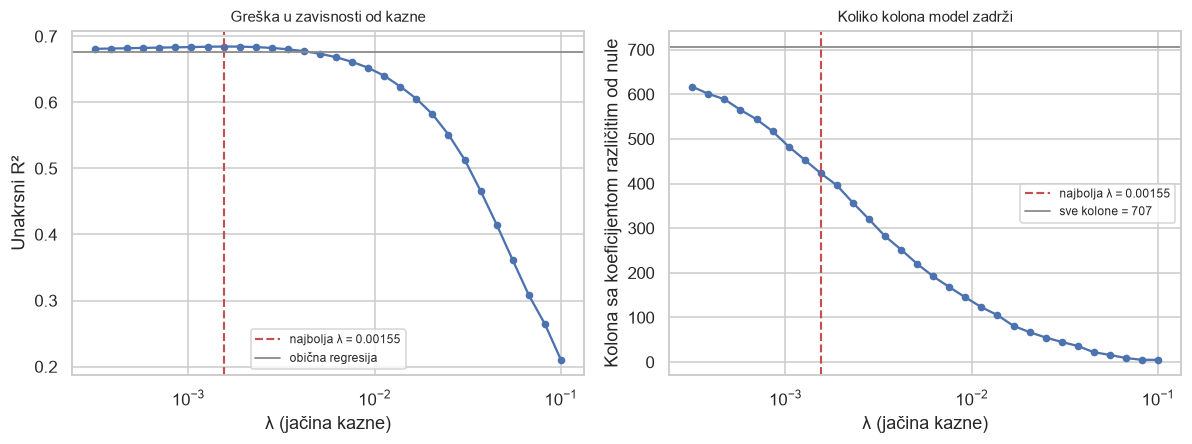

unakrsni R² duž mreže: od 0.2102 do 0.6845
broj zadržanih kolona: od 5 do 617
pri najboljoj λ: R² 0.6845, kolona 423
pri najmanjoj λ: R² 0.6811, kolona 617

sa upola manje kolona (357): R² 0.6837, gubitak -0.0008


In [160]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.plot(LASSO_ALPHAS, lasso_table["R2"], marker="o", markersize=4, color="#4C72B0")
ax.axvline(best_lasso, color="#C44E52", linestyle="--", linewidth=1.4,
           label=f"najbolja λ = {best_lasso:.5f}")
ax.axhline(reference.loc["sve kolone, regresija", "R2"], color="#8C8C8C", linewidth=1.2,
           label="obična regresija")
ax.set_xscale("log")
ax.set_xlabel("λ (jačina kazne)")
ax.set_ylabel("Unakrsni R²")
ax.set_title("Greška u zavisnosti od kazne", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(LASSO_ALPHAS, nonzero, marker="o", markersize=4, color="#4C72B0")
ax.axvline(best_lasso, color="#C44E52", linestyle="--", linewidth=1.4,
           label=f"najbolja λ = {best_lasso:.5f}")
ax.axhline(len(independent), color="#8C8C8C", linewidth=1.2,
           label=f"sve kolone = {len(independent)}")
ax.set_xscale("log")
ax.set_xlabel("λ (jačina kazne)")
ax.set_ylabel("Kolona sa koeficijentom različitim od nule")
ax.set_title("Koliko kolona model zadrži", fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"unakrsni R² duž mreže: od {lasso_table['R2'].min():.4f} do {lasso_table['R2'].max():.4f}")
print(f"broj zadržanih kolona: od {nonzero.min()} do {nonzero.max()}")
print(f"pri najboljoj λ: R² {lasso_table['R2'].max():.4f}, kolona {nonzero[chosen]}")
print(f"pri najmanjoj λ: R² {lasso_table['R2'].iloc[-1]:.4f}, kolona {nonzero[-1]}")
print()
half = int(np.argmin(np.abs(nonzero - len(independent) // 2)))
print(f"sa upola manje kolona ({nonzero[half]}): R² {lasso_table['R2'].iloc[half]:.4f}, "
      f"gubitak {lasso_table['R2'].iloc[half] - lasso_table['R2'].max():+.4f}")

**Zapažanje:** za razliku od Ridge-a, ovde kriva greške **ima oblik**. Raste od 0,2102 pri najjačoj kazni
do vrha na **0,6845**, pa se blago spušta na **0,6811** pri najslabijoj. Broj zadržanih kolona
istovremeno raste od **5** do **617**.

Vrh greške pada tamo gde model ima 423 kolone — dakle ne na kraju gde ih je najviše, ni blizu mesta gde
ih je malo.

Poslednji red ispisa daje i cenu strožeg izbora: sa **357** kolona, dakle upola manje od svih, unakrsni
R² je **0,6837**, samo **0,0008** ispod najboljeg.

**Tumačenje:** oblik krive je ono zbog čega Lasso ovde radi a Ridge nije.

Levi deo krive pokazuje da model kojem se odseče previše kolona zaista gubi — pri pet kolona objašnjava
samo pete deo varijanse. Desni deo pokazuje da model kojem se dozvoli previše kolona **takođe** gubi, i
to je ono što obična regresija nije umela da izbegne. Između njih postoji jasno najbolje mesto, i
unakrsna validacija ga nalazi.

Zadnji broj je praktično najupotrebljiviji: **357 kolona umesto 707 košta 0,0008 unakrsnog R².** Postoji,
dakle, i osetno manji model koji radi skoro isto, pa bi se mogao uzeti on ako bi čitljivost bila
važnija od poslednje decimale. Time se bavi sedma sekcija, gde se selekcija ocenjuje merilima sa predavanja.

### 38.2 Koje grupe promenljivih Lasso zadržava

Do sada smo brojali kolone. Pitanje koje nas zapravo zanima je **koje** su preživele, i to ne pojedinačno
nego po grupama. Grupu prepoznajemo po prefiksu imena kolone — `Chose_`, `Count_`, `KeptShare_`,
`NotAnswered_` su prefiksi koje smo sami uveli u prethodnom delu, a `Country_`, `Currency_` i
ostali dolaze iz enkodiranja anketnih pitanja. Uz svaku od naših grupa u tabeli stoji i hipoteza iz koje
je nastala, da se rezultat može pročitati naspram onoga što je tamo tvrđeno.

Ovo je najstroža provera koju feature engineering može da dobije: nismo mi odlučili šta ostaje, nego
postupak koji jedino gleda unakrsnu grešku.

In [161]:
survived = set(np.array(independent)[lasso_coefficients[:, chosen] != 0])

# The groups the previous notebook built, each with the hypothesis it came
# from, so the count can be read against what was claimed there.
FAMILIES = [
    ("Chose_", "Chose_ — pojedinačne stavke (Hip. 7)"),
    ("Count_", "Count_ — broj izabranih stavki (Hip. 6)"),
    ("KeptShare_", "KeptShare_ — odnos zadržanog (Hip. 5)"),
    ("NotAnswered_", "NotAnswered_ — neodgovaranje"),
    ("Country_", "Country — zemlja"),
    ("Currency_", "Currency — valuta"),
    ("DevType_", "DevType — tip posla"),
    ("Industry_", "Industry — industrija"),
    ("Age_", "Age — uzrast"),
]
RANK_FAMILY = ("TechEndorse_", "TechOppose_", "JobSatPoints_", "SO_Actions_")
PLAIN_FAMILY = ("WorkExp", "YearsCode", "JobSat", "ToolCountWork",
                "ToolCountPersonal", "OrgSize")

print(f"{'grupa kolona':<40} {'zadržano':>9} {'ukupno':>7} {'udeo':>7}")
for prefix, label in FAMILIES:
    columns = [c for c in independent if c.startswith(prefix)]
    kept = sum(1 for c in columns if c in survived)
    print(f"{label:<40} {kept:>9} {len(columns):>7} {100 * kept / len(columns):>6.0f}%")
ranks = [c for c in independent if c.startswith(RANK_FAMILY)]
kept_ranks = sum(1 for c in ranks if c in survived)
print(f"{'TechEndorse_ i sl. — rangiranja (Hip. 8)':<40} {kept_ranks:>9} {len(ranks):>7} "
      f"{100 * kept_ranks / len(ranks):>6.0f}%")
plain = [c for c in independent if c in PLAIN_FAMILY]
kept_plain = sum(1 for c in plain if c in survived)
print(f"{'WorkExp i sl. — nasleđene brojčane':<40} {kept_plain:>9} {len(plain):>7} "
      f"{100 * kept_plain / len(plain):>6.0f}%")
print()
derived_columns = [c for c in independent
                   if c.startswith(("Chose_", "Count_", "KeptShare_", "NotAnswered_"))]
kept_derived = sum(1 for c in derived_columns if c in survived)
print(f"naših kolona zadržano:      {kept_derived} od {len(derived_columns)}")
print(f"nasleđenih kolona zadržano: {len(survived) - kept_derived} od "
      f"{len(independent) - len(derived_columns)}")

grupa kolona                              zadržano  ukupno    udeo
Chose_ — pojedinačne stavke (Hip. 7)           168     314     54%
Count_ — broj izabranih stavki (Hip. 6)          0      16      0%
KeptShare_ — odnos zadržanog (Hip. 5)            0       7      0%
NotAnswered_ — neodgovaranje                     6      15     40%
Country — zemlja                                48      60     80%
Currency — valuta                               60      80     75%
DevType — tip posla                             20      31     65%
Industry — industrija                           11      15     73%
Age — uzrast                                     5       6     83%
TechEndorse_ i sl. — rangiranja (Hip. 8)        25      36     69%
WorkExp i sl. — nasleđene brojčane               6       6    100%

naših kolona zadržano:      174 od 352
nasleđenih kolona zadržano: 249 od 355


**Zapažanje:** rezultat je vrlo neravnomeran po grupama, i dva broja su nula.

**Sve 16 kolona `Count_` i svih 7 kolona `KeptShare_` Lasso je spustio na nulu.** Nijedna nije preživela.

Nasuprot tome, od **314 kolona po stavci preživelo je 168**, dakle više od polovine. Kod nasleđenih
obeležja: zemlja 48 od 60, valuta 60 od 80, tip posla 20 od 31, rangiranja 25 od 36, a **sve šest
nasleđenih brojčanih kolona** su ostale.

Ukupno: od naših 352 kolone preživelo je **174**, a od 355 nasleđenih **249**.

**Tumačenje:** ovo je najoštrija ocena prethodnog dela koju smo mogli da dobijemo, i deli je na dva
dela.

**Kolone `Count_` su izgubile posao.** Hipoteza 6 je pokazala da oni nose signal koji zemlja i
staž ne nose, i to je tada bilo tačno. Ali u prethodnom delu smo, u sekciji 42, izmerili i zašto to
ne mora da preživi: `Count_` kolone su **zbir** kolona po stavci istog pitanja, pa je 11 od njih imalo
VIF preko 10. Kad su i jedne i druge u modelu, kolone po stavci nose istu informaciju finije, a Lasso
onda uzima finiju verziju i grublju ukine. Isto važi i za odnos zadržanog.

**Kolone `Chose_` su se potvrdile.** Hipoteza 7 je bila najveći dobitak u prethodnom delu i
ostaje najveći doprinos ovde — 168 kolona koje je izabrao postupak koji o našim hipotezama ne zna ništa.

Ovo **ne znači da je Hipoteza 6 bila pogrešna**. Ona je merila da li brojevi nose signal
preko zemlje i staža, i nosili su ga. Tek u društvu sa 314 kolona po stavci postaju suvišni — što je
tačno ona razlika između samostalnog merenja i merenja u punom modelu na koju smo se pozivali kroz ceo prethodni deo.

### Šta sekcija ostavlja sledećoj

**Lasso sa λ = 0,00155 daje unakrsni R² 0,6845** i koristi **423 od 707 kolona** — najbolji rezultat i
najmanji model do sada.

Tri nalaza:

- **broj kolona je bio problem, ne veličina koeficijenata.** Lasso dobija +0,0076 preko obične regresije
  i +0,0047 preko Ridge-a, uz 284 kolone manje;
- **kriva greške ima jasan oblik**, sa padom na oba kraja, pa je unakrsna validacija zaista birala a ne
  samo potvrđivala. Sa 357 kolona rezultat je samo 0,0008 slabiji;
- **formalna selekcija je obavljena i ne slaže se sa svim našim hipotezama.** Sve kolone `Count_` i
  `KeptShare_` su ukinute, dok je 168 od 314 kolona po stavci ostalo.

Sledeća sekcija uvodi treći pristup sa predavanja — regresiju na glavne komponente, koja problem previše
kolona rešava tako što ih zameni manjim brojem izvedenih.

## 39. Regresija na glavne komponente

Treći pristup sa predavanja rešava isti problem na sasvim drugi način. Ridge i Lasso rade sa originalnim
kolonama i menjaju koeficijente; regresija na glavne komponente (PCR) **menja same kolone**.

Postupak je u dva koraka. Prvo se nad standardizovanim prediktorima uradi **analiza glavnih
komponenata**. Svaka komponenta je težinska kombinacija svih kolona, `Zₘ = Σⱼ φⱼₘ Xⱼ`, a biraju se po
pravilu sa predavanja: prva je pravac u kom se ispitanici **najviše razlikuju** među sobom, druga je
pravac najveće preostale razlike koji je nekorelisan sa prvom, i tako redom. Kolona na kraju ima isto
koliko ih je i bilo, ali su nove međusobno nekorelisane i poređane po tome koliko varijanse prediktora
nose. Zatim se obična regresija radi samo na **prvih M** komponenata, a ostale se odbace — otud i smisao
postupka: umesto `p` koeficijenata model procenjuje `M`, pa ima manje slobode. M se bira unakrsnom
validacijom.

Jedna stvar se ovde lako previdi, pa je kažemo unapred: komponente su poređane po varijansi
**prediktora**, a ne po vezi sa platom. PCR, dakle, pretpostavlja da su smerovi u kojima se ispitanici
najviše razlikuju ujedno i smerovi koji objašnjavaju platu — a to ne mora da važi.

### 39.1 Izbor broja komponenata

Mrežu M vodimo do 600, a ne do svih 707. Razlog je numerički: komponenta sa vrlo malom varijansom u
regresiji ulazi u imenilac, pa deljenje skoro nulom daje nestabilan koeficijent. To je isti rang problem
koji smo videli u 3.1, samo u drugom obliku. Koliko varijanse zaista ostaje iza šeststote komponente,
ispis meri.

In [162]:
from sklearn.decomposition import PCA

# Up to 600 rather than all 707, for the reason given above.
COMPONENTS = [1, 2, 5, 10, 20, 40, 70, 100, 150, 200, 300, 400, 500, 600]


def pcr_out_of_fold(design, target, sizes, folds=FOLDS, seed=SEED):
    """Out-of-fold predictions for every number of components at once.

    The components are uncorrelated, so each one gets its own coefficient
    independently of the others; the prediction for the first M is then just the
    running sum of their contributions.
    """
    target = np.asarray(target, dtype=float)
    predictions = np.empty((len(sizes), len(target)))
    splitter = KFold(n_splits=folds, shuffle=True, random_state=seed)
    for fit_rows, eval_rows in splitter.split(design):
        scaler = StandardScaler().fit(design[fit_rows])
        pca = PCA(n_components=max(sizes)).fit(scaler.transform(design[fit_rows]))
        scores_fit = pca.transform(scaler.transform(design[fit_rows]))
        scores_eval = pca.transform(scaler.transform(design[eval_rows]))
        centre = float(target[fit_rows].mean())
        slopes = (scores_fit.T @ (target[fit_rows] - centre)) / (scores_fit ** 2).sum(axis=0)
        running = np.cumsum(scores_eval * slopes, axis=1)
        for position, size in enumerate(sizes):
            predictions[position, eval_rows] = running[:, size - 1] + centre
    return predictions


pcr_predictions = pcr_out_of_fold(regularized_design, y_train, COMPONENTS)
pcr_table = pd.DataFrame([metrics(y_train, row) for row in pcr_predictions], index=COMPONENTS)
best_components = int(pcr_table["R2"].idxmax())

pca_all = PCA(n_components=max(COMPONENTS)).fit(scaled_all)
explained = np.cumsum(pca_all.explained_variance_ratio_)

print(f"{'M':>5} {'unakrsni R²':>13} {'varijansa prediktora':>21}")
for size in COMPONENTS:
    print(f"{size:>5} {pcr_table.loc[size, 'R2']:>13.4f} {100 * explained[size - 1]:>20.1f}%")
print()
print(f"najbolji M: {best_components}   unakrsni R² {pcr_table['R2'].max():.4f}")
print(f"tada je objašnjeno {100 * explained[best_components - 1]:.1f}% varijanse prediktora")
print()
# Why the grid stops at 600: what the components past it are worth.
tail = len(independent) - max(COMPONENTS)
print(f"prvih {max(COMPONENTS)} komponenata nosi {100 * explained[-1]:.2f}% varijanse prediktora, "
      f"{100 * explained[-1] / max(COMPONENTS):.4f}% po komponenti")
print(f"preostalih {tail} nosi zajedno {100 * (1 - explained[-1]):.2f}%, "
      f"{100 * (1 - explained[-1]) / tail:.4f}% po komponenti")
print()
for name, value in [("obična regresija", reference.loc["sve kolone, regresija", "R2"]),
                    ("Ridge", reference.loc["Ridge", "R2"]),
                    ("Lasso", reference.loc["Lasso", "R2"]),
                    ("PCR", pcr_table["R2"].max())]:
    print(f"  {name:<18} {value:.4f}")

reference.loc["PCR"] = pd.Series(metrics(y_train, pcr_predictions[COMPONENTS.index(best_components)]))

    M   unakrsni R²  varijansa prediktora
    1       -0.0003                  3.4%
    2        0.0949                  5.9%
    5        0.2308                  9.6%
   10        0.4195                 13.4%
   20        0.4548                 18.2%
   40        0.4978                 24.9%
   70        0.5181                 33.5%
  100        0.5511                 40.8%
  150        0.5792                 50.6%
  200        0.5900                 59.0%
  300        0.6095                 73.3%
  400        0.6375                 85.0%
  500        0.6613                 93.5%
  600        0.6695                 98.6%

najbolji M: 600   unakrsni R² 0.6695
tada je objašnjeno 98.6% varijanse prediktora

prvih 600 komponenata nosi 98.56% varijanse prediktora, 0.1643% po komponenti
preostalih 107 nosi zajedno 1.44%, 0.0134% po komponenti

  obična regresija   0.6769
  Ridge              0.6798
  Lasso              0.6845
  PCR                0.6695


**Zapažanje:** PCR je najslabiji od četiri pristupa. Najbolji M je **600**, sa unakrsnim R² od **0,6695**
— ispod obične regresije (0,6769), Ridge-a (0,6798) i Lassa (0,6845).

Tabela pokazuje i zašto. Sa **10** komponenata model objašnjava **0,4195** varijanse plate, sa **100**
komponenata **0,5511**, sa **300** komponenata **0,6095**. Rast je, dakle, spor i ne staje — najbolje je
na samom kraju mreže.

Uz to, **300 komponenata objašnjava 73,3% varijanse prediktora**, a 600 komponenata **98,6%**.

Poslednji deo ispisa opravdava i to što mreža staje na 600. Prvih 600 komponenata nosi **98,56%**
varijanse prediktora, dakle **0,1643%** po komponenti; preostalih **107** nosi zajedno **1,44%**, odnosno
**0,0134%** po komponenti — dvanaest puta manje. Na tako malim količinama regresija bi delila skoro
nulom.

**Tumačenje:** PCR ovde ne radi, i razlog je onaj koji smo naveli unapred.

Komponente su poređane po varijansi prediktora, a ne po vezi sa platom. Da su ta dva poretka slična,
prvih nekoliko desetina komponenata nosilo bi većinu signala i kriva bi se rano poravnala. Ona se ne
poravnava — modelu je najbolje kad mu se da skoro sve, što znači da je signal o plati **razbacan po
mnogo komponenata**, uključujući one sa malom varijansom.

Zašto je poredak takav, ne pretpostavljamo. Očekivanje je da prve komponente nose ono po čemu se
ispitanici najviše razlikuju međusobno — a to ne mora biti ono što objašnjava platu. Ako je tako, zemlja i
valuta, dva najjača obeležja po merenju iz 2.4, u tom poretku ne bi bile na vrhu. To se proverava u 6.2.

Time PCR odgovara na pitanje zbog kog je i uveden. Sažimanje kolona **ne pomaže** ako se sažimanje radi
bez obzira na ciljnu promenljivu. Lasso radi bolje jer ciljnu promenljivu gleda.

### Grafik 34 — koliko se dobija svakom sledećom komponentom

**Motivacija:** iz tabele se vidi da najbolje ispada na kraju mreže, ali ne i **kakvog je oblika** rast.
Ako kriva greške ide uporedo sa krivom objašnjene varijanse prediktora, komponente su korisne po redu
kojim su poređane; ako se razilaze, poredak je pogrešan za naš posao. Crtamo obe krive zajedno, pa se
odgovor čita iz toga da li se prate.

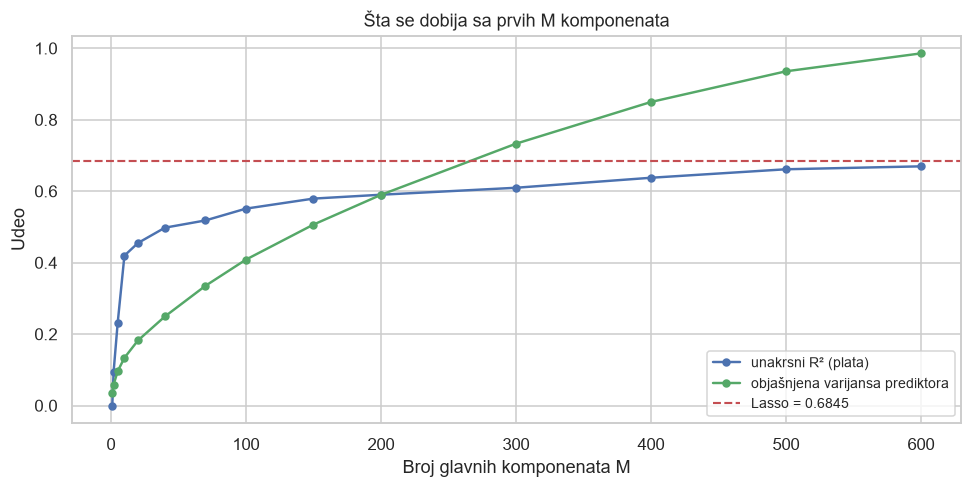

    M  R² (plata)  varijansa prediktora   razlika
   10      0.4195                 13.4%   +0.2859
  100      0.5511                 40.8%   +0.1427
  300      0.6095                 73.3%   -0.1233
  500      0.6613                 93.5%   -0.2742
  600      0.6695                 98.6%   -0.3162

komponenata potrebnih da PCR dostigne Lasso: nijedan M do 600 to ne postiže
  najbolji PCR 0.6695   Lasso 0.6845   razlika -0.0150


In [163]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(COMPONENTS, pcr_table["R2"], marker="o", markersize=4.5, linewidth=1.6,
        color="#4C72B0", label="unakrsni R² (plata)")
ax.plot(COMPONENTS, [explained[size - 1] for size in COMPONENTS], marker="o", markersize=4.5,
        linewidth=1.6, color="#55A868", label="objašnjena varijansa prediktora")
ax.axhline(reference.loc["Lasso", "R2"], color="#C44E52", linestyle="--", linewidth=1.4,
           label=f"Lasso = {reference.loc['Lasso', 'R2']:.4f}")
ax.set_xlabel("Broj glavnih komponenata M")
ax.set_ylabel("Udeo")
ax.set_title("Šta se dobija sa prvih M komponenata")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

print(f"{'M':>5} {'R² (plata)':>11} {'varijansa prediktora':>21} {'razlika':>9}")
for size in (10, 100, 300, 500, 600):
    row = pcr_table.loc[size, "R2"]
    print(f"{size:>5} {row:>11.4f} {100 * explained[size - 1]:>20.1f}% "
          f"{row - explained[size - 1]:>+9.4f}")
print()
print(f"komponenata potrebnih da PCR dostigne Lasso: nijedan M do {max(COMPONENTS)} to ne postiže")
print(f"  najbolji PCR {pcr_table['R2'].max():.4f}   Lasso {reference.loc['Lasso', 'R2']:.4f}   "
      f"razlika {pcr_table['R2'].max() - reference.loc['Lasso', 'R2']:+.4f}")

**Zapažanje:** dve krive se **ne prate**. Zelena, objašnjena varijansa prediktora, raste brzo na početku i
rano prelazi plavu; plava, unakrsni R² za platu, raste sporije i ravnomernije, i do kraja mreže ne stiže
crvenu liniju koja označava Lasso.

Kod **M = 100** komponente objašnjavaju 40,8% varijanse prediktora a samo 0,5511 varijanse plate. Kod
**M = 500** objašnjavaju 93,5% prediktora i 0,6613 plate.

Nijedan M do 600 ne dostiže Lasso — razlika ostaje **−0,0150**.

**Tumačenje:** razilaženje dve krive je odgovor na pitanje iz motivacije. Komponente **nisu** poređane
korisno za naš posao: one koje najviše opisuju kako se ispitanici razlikuju međusobno nisu one koje
najviše govore o plati.

To je i praktična granica metode, ne naša greška u primeni. PCA je nenadgledan postupak — ne vidi ciljnu
promenljivu — pa u skupu u kom signal nose retke kolone sa malom varijansom nužno greši u poretku. Da je
naša matrica imala nekoliko jakih, gustih pravaca, PCR bi radio dobro i sa dvadeset komponenata.

PCR zato ostaje u poređenju modela kao izmerena mogućnost koja nije prošla, a ne kao nešto što nismo
probali.

### 39.2 Odakle dolazi pogrešan poredak komponenata

Objašnjenje iz prethodnog odeljka — da komponente nisu poređane korisno jer signal nose retke kolone —
zvuči uverljivo, ali je zasad tvrdnja. Merimo ga, jer se lako proverava.

Komponenta je težinska kombinacija svih kolona. Kvadrat težine je udeo te kolone u komponenti, pa se
sabiranjem kvadrata preko prvih deset komponenata dobija **od kojih su kolona te komponente sastavljene**.
Ako je objašnjenje tačno, kolone po stavci treba da nose neproporcionalno mnogo, a zemlja i valuta
neproporcionalno malo.

In [164]:
# The square of a loading is that column's share of a component, so summing the
# squares over the first components says which columns those components are made
# of. That is what decides whether their order is useful for predicting pay.
LOADING_FAMILIES = {"Chose_": "pojedinačne stavke", "Country_": "zemlja",
                    "Currency_": "valuta"}


def family_of(name):
    """Which group of columns this one belongs to, for the table below."""
    for prefix, label in LOADING_FAMILIES.items():
        if name.startswith(prefix):
            return label
    if name.startswith(("Count_", "KeptShare_", "NotAnswered_")):
        return "ostale naše"
    return "ostale nasleđene"


families = np.array([family_of(name) for name in independent])
weight_ten = (pca_all.components_[:10] ** 2).sum(axis=0)
weight_ten = weight_ten / weight_ten.sum()
weight_fifty = (pca_all.components_[:50] ** 2).sum(axis=0)
weight_fifty = weight_fifty / weight_fifty.sum()

# The order the table is printed in, largest group of columns first.
ORDER = ["pojedinačne stavke", "zemlja", "valuta", "ostale naše", "ostale nasleđene"]
print(f"{'grupa kolona':<22} {'kolona':>7} {'udeo kolona':>12} "
      f"{'u prvih 10':>11} {'u prvih 50':>11}")
for label in ORDER:
    inside = families == label
    print(f"{label:<22} {int(inside.sum()):>7} {100 * inside.mean():>11.1f}% "
          f"{100 * weight_ten[inside].sum():>10.1f}% {100 * weight_fifty[inside].sum():>10.1f}%")
print()

# Why they land where they do: a dummy for one country is one among many, so it
# is almost always zero, and a column that rarely changes carries little variance.
binary_column = np.array([set(np.unique(X_train[name].to_numpy())) <= {0.0, 1.0}
                          for name in independent])
print("prosečan udeo jedinica u binarnim kolonama grupe:")
for label in ("pojedinačne stavke", "zemlja", "valuta"):
    inside = (families == label) & binary_column
    columns = list(np.array(independent)[inside])
    print(f"  {label:<22} {X_train[columns].to_numpy().mean():.4f}   "
          f"(binarnih kolona {len(columns)})")

grupa kolona            kolona  udeo kolona  u prvih 10  u prvih 50
pojedinačne stavke         314        44.4%       58.9%       40.5%
zemlja                      60         8.5%        1.1%       14.8%
valuta                      80        11.3%        1.0%       14.9%
ostale naše                 38         5.4%       13.0%        7.6%
ostale nasleđene           215        30.4%       26.0%       22.3%

prosečan udeo jedinica u binarnim kolonama grupe:
  pojedinačne stavke     0.1521   (binarnih kolona 314)
  zemlja                 0.0165   (binarnih kolona 60)
  valuta                 0.0125   (binarnih kolona 80)


**Zapažanje:** očekivanje se potvrđuje, i razlika je velika.

| grupa kolona | udeo kolona | udeo u prvih 10 komponenata | u prvih 50 |
| --- | --- | --- | --- |
| pojedinačne stavke | 44,4% | **58,9%** | 40,5% |
| zemlja | 8,5% | **1,1%** | 14,8% |
| valuta | 11,3% | **1,0%** | 14,9% |
| ostale naše | 5,4% | 13,0% | 7,6% |
| ostale nasleđene | 30,4% | 26,0% | 22,3% |

Prvih deset komponenata, dakle, sastavljeno je pretežno od **kolona po stavci** — one nose 58,9% težine
a čine 44,4% kolona. Zemlja i valuta zajedno nose **oko dva posto**, iako čine skoro petinu kolona. Tek u
prvih pedeset komponenata njihov udeo raste na 14,8% i 14,9%.

Drugi deo ispisa pokazuje mehanizam: prosečan udeo jedinica je **0,1521** kod kolona po stavci, a
**0,0165** kod zemlje i **0,0125** kod valute.

**Tumačenje:** ovo objašnjava rezultat iz 39.1 do kraja i bez pretpostavki.

Dummy kolona za jednu zemlju je jedinica kod nepuna dva posto ispitanika, pa se skoro nikad ne menja — a
kolona koja se retko menja nosi malu varijansu. PCA komponente poređa **po varijansi**, pa takve kolone
nužno gura na kraj liste. Kolona po stavci se, nasuprot tome, menja kod svakog sedmog ispitanika, pa ulazi
u prve komponente.

Time je i objašnjeno zašto je PCR-u bilo potrebno **600** komponenata: da bi došao do zemlje i valute,
morao je da uzme skoro sve. Ridge i Lasso do njih dolaze odmah, jer gledaju platu, a ne varijansu
prediktora.

To je i granica metode koju treba zapisati: **PCR loše radi kad signal nose retke kolone.** U skupu sa
nekoliko gustih, jakih pravaca radio bi dobro i sa dvadeset komponenata.

### Šta sekcija ostavlja sledećoj

**PCR sa 600 komponenata daje unakrsni R² 0,6695**, najslabije od četiri pristupa.

Dva nalaza:

- **sažimanje bez ciljne promenljive ne pomaže.** Krive objašnjene varijanse prediktora i objašnjene
  varijanse plate se razilaze, jer PCA ne zna šta predviđamo;
- **izmereno je i zašto.** Prvih deset komponenata čine 58,9% kolone po stavci, a zemlja i valuta zajedno
  svega oko dva posto, jer su njihove dummy kolone jedinica kod nepuna dva posto ispitanika i time nose
  malu varijansu. PCR je zato morao da uzme 600 od 707 komponenata da bi do njih došao;
- **PCR loše radi kad signal nose retke kolone**, i to je granica metode, a ne greška u primeni.

Sva četiri modela su time napravljena i izmerena unakrsnom validacijom. Sledeća sekcija ih poredi
merilima za izbor modela sa predavanja, i tek na kraju uzima test skup.

## 40. Poređenje modela

Četiri modela su napravljena i svaki je izmeren istom unakrsnom validacijom. Ostaje da se izaberu, i tu
treba razdvojiti dve vrste merila, jer se lako pomešaju.

**Merila za izbor promenljivih unutar jedne vrste modela** — Cp, AIC, BIC i prilagođeni R² — sa
predavanja služe da se između ugnežđenih regresija izabere ona sa pravim brojem prediktora. Sva četiri
rade tako što uzmu grešku na trening skupu i **kazne je za broj kolona**, svako sa svojom kaznom. Ona su
definisana za običnu regresiju sa procenom `σ²`, pa se ne mogu primeniti na Ridge, Lasso ili PCR — kod
njih broj kolona nije ni celobrojan u istom smislu.

**Merilo za poređenje različitih vrsta modela** je **greška unakrsne validacije**. Ona ne pretpostavlja
ništa o obliku modela, pa jedina može da uporedi sve četiri.

U 40.1 radimo prvo: nad nizom podmodela koje je Lasso izabrao, po jedan za svaku vrednost λ, ponovo
fitujemo običnu regresiju i računamo sva četiri merila. Time dobijamo formalnu selekciju u obliku u kom
je učena na predavanjima, i vidimo da li se ta merila slažu međusobno i sa unakrsnom validacijom.

### 40.1 Cp, AIC, BIC i prilagođeni R² nad podmodelima

In [165]:
# Cp needs an estimate of the error variance, and it is taken from the largest
# model, as the lectures do.
full_ols = np.linalg.lstsq(np.column_stack([np.ones(len(X_train)), regularized_design]),
                           y_train.to_numpy(), rcond=None)[0]
full_residual = y_train.to_numpy() - (np.column_stack([np.ones(len(X_train)),
                                                       regularized_design]) @ full_ols)
sigma_squared = float(full_residual @ full_residual) / (len(X_train) - len(independent) - 1)
total_squares = float((y_train - y_train.mean()) @ (y_train - y_train.mean()))

rows = []
for position in range(0, len(LASSO_ALPHAS), 3):
    selected = np.where(lasso_coefficients[:, position] != 0)[0]
    if len(selected) == 0:
        continue
    design = np.column_stack([np.ones(len(X_train)), regularized_design[:, selected]])
    coefficients = np.linalg.lstsq(design, y_train.to_numpy(), rcond=None)[0]
    residual_here = y_train.to_numpy() - design @ coefficients
    rss = float(residual_here @ residual_here)
    count = design.shape[1]
    rows.append({
        "kolona": len(selected),
        "Cp": (rss + 2 * count * sigma_squared) / len(X_train),
        "AIC": len(X_train) * np.log(rss / len(X_train)) + 2 * count,
        "BIC": len(X_train) * np.log(rss / len(X_train)) + np.log(len(X_train)) * count,
        "prilagođeni_R2": 1 - (rss / (len(X_train) - count)) / (total_squares / (len(X_train) - 1)),
        "unakrsni_R2": lasso_table["R2"].iloc[position],
    })

criteria = pd.DataFrame(rows)
print(criteria.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
for name, best in [("Cp", "min"), ("AIC", "min"), ("BIC", "min"),
                   ("prilagođeni_R2", "max"), ("unakrsni_R2", "max")]:
    row = criteria[name].idxmin() if best == "min" else criteria[name].idxmax()
    print(f"  {name:<16} bira {int(criteria.loc[row, 'kolona']):>3} kolona")
print()
strict = criteria.loc[criteria["BIC"].idxmin()]
loose = criteria.loc[criteria["unakrsni_R2"].idxmax()]
print(f"izbor BIC-a ({int(strict['kolona'])} kolona) naspram izbora unakrsne validacije "
      f"({int(loose['kolona'])}): unakrsni R² {strict['unakrsni_R2']:.4f} naspram "
      f"{loose['unakrsni_R2']:.4f}, razlika {strict['unakrsni_R2'] - loose['unakrsni_R2']:+.4f}")

 kolona     Cp         AIC         BIC  prilagođeni_R2  unakrsni_R2
      5 0.1197 -31007.5294 -30961.9934          0.3790       0.2102
     16 0.0956 -34278.9307 -34149.9122          0.5040       0.3611
     45 0.0716 -38494.6716 -38145.5627          0.6291       0.5135
     81 0.0644 -40044.6486 -39422.3240          0.6672       0.6056
    145 0.0602 -41033.2724 -39925.2310          0.6904       0.6523
    220 0.0586 -41431.3014 -39754.0606          0.7002       0.6737
    320 0.0579 -41628.2369 -39192.0637          0.7062       0.6824
    423 0.0578 -41644.6932 -38426.8196          0.7085       0.6845
    517 0.0581 -41587.7603 -37656.4902          0.7092       0.6833
    589 0.0585 -41486.6929 -37008.9914          0.7086       0.6819

  Cp               bira 423 kolona
  AIC              bira 423 kolona
  BIC              bira 145 kolona
  prilagođeni_R2   bira 517 kolona
  unakrsni_R2      bira 423 kolona

izbor BIC-a (145 kolona) naspram izbora unakrsne validacije (423): unakrsni

**Zapažanje:** četiri merila **ne biraju isti model**.

Cp i AIC su najmanji pri **423** kolone, isto koliko bira i unakrsna validacija. **BIC je najmanji pri
145** kolona, dakle skoro tri puta manjem modelu. Prilagođeni R² je najveći pri **517** kolona, dakle
najvećem od tri izbora.

Pri 423 kolone prilagođeni R² iznosi **0,7085**, a njegov najbolji je **0,7092** pri 517 — razlika je
sedam desethiljaditih delova.

**Tumačenje:** razilaženje nije greška nego posledica toga što svako merilo drugačije kažnjava broj
kolona, i njihov poredak je upravo onaj koji se sa predavanja i očekuje.

**BIC kažnjava najstrože**, jer mu kazna raste sa `log(n)` po koloni, a kod nas je `log(14.608)` blizu
deset — pa je svaka kolona pet puta skuplja nego kod AIC-a, gde je kazna 2. Zato BIC bira najmanji model.
**Prilagođeni R² kažnjava najslabije** i zato bira najveći. **Cp i AIC** su između, i kod normalne
regresije su međusobno gotovo ekvivalentni — što se i vidi, jer daju identičan izbor.

Za nas je važno da se tri od četiri merila, plus unakrsna validacija, slažu na **423** kolone. To je
model koji smo u sekciji 38 i dobili, pa ga uzimamo kao izabrani. Da se merila nisu slagala, morali bismo
da obrazložimo koje uzimamo; ovako obrazloženje ne treba.

### Grafik 35 — kako se četiri merila razilaze

**Motivacija:** iz tabele se vidi koji broj kolona svako merilo bira, ali ne i **koliko je taj izbor
izražen** — da li je minimum oštar ili je kriva skoro ravna, pa je izbor slučajan. Uz to su četiri merila
u različitim jedinicama i ne mogu se crtati zajedno, pa svako svodimo na sopstveni opseg, od najgore
vrednosti do najbolje. Tako se porede oblici, ne nivoi.

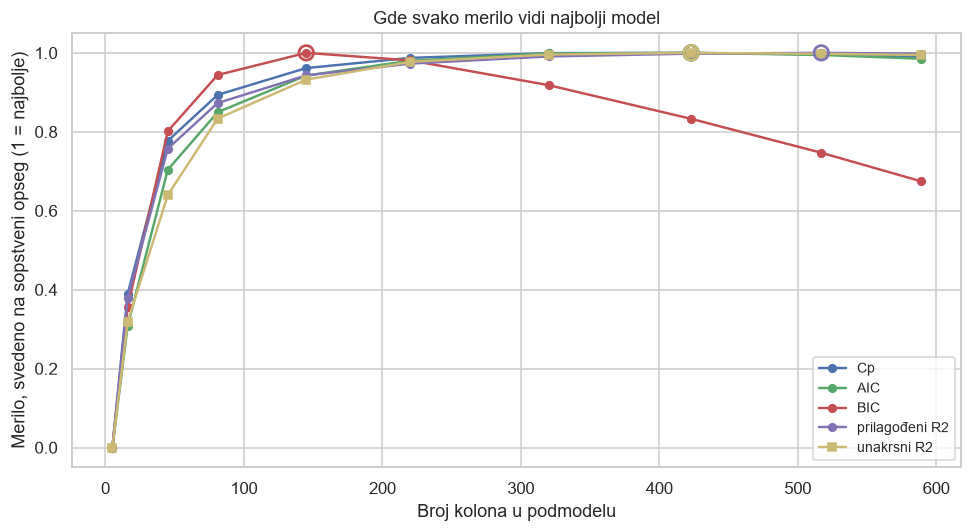

koliko svako merilo gubi ako se uzme izbor unakrsne validacije:
  Cp               pri 423 kolona       0.0578   najbolje       0.0578
  AIC              pri 423 kolona  -41644.6932   najbolje  -41644.6932
  BIC              pri 423 kolona  -38426.8196   najbolje  -39925.2310
  prilagođeni_R2   pri 423 kolona       0.7085   najbolje       0.7092
  unakrsni_R2      pri 423 kolona       0.6845   najbolje       0.6845


In [166]:
fig, ax = plt.subplots(figsize=(9, 5))
# The five measures drawn together, each with its own colour.
STYLE = {"Cp": "#4C72B0", "AIC": "#55A868", "BIC": "#C44E52", "prilagođeni_R2": "#8172B3",
         "unakrsni_R2": "#CCB974"}

for name, colour in STYLE.items():
    values = criteria[name].to_numpy(dtype=float)
    # Every measure onto the same 0-1 range, with 1 always meaning "best", so the
    # shapes can be compared even though the units cannot.
    if name in ("Cp", "AIC", "BIC"):
        values = -values
    scaled = (values - values.min()) / (values.max() - values.min())
    marker = "o" if name != "unakrsni_R2" else "s"
    ax.plot(criteria["kolona"], scaled, marker=marker, markersize=5, linewidth=1.6,
            color=colour, label=name.replace("_", " "))
    ax.scatter([criteria["kolona"].iloc[int(np.argmax(scaled))]], [1.0], s=90,
               facecolors="none", edgecolors=colour, linewidths=1.8, zorder=5)

ax.set_xlabel("Broj kolona u podmodelu")
ax.set_ylabel("Merilo, svedeno na sopstveni opseg (1 = najbolje)")
ax.set_title("Gde svako merilo vidi najbolji model")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

print("koliko svako merilo gubi ako se uzme izbor unakrsne validacije:")
cv_choice = int(criteria.loc[criteria["unakrsni_R2"].idxmax(), "kolona"])
for name in STYLE:
    at_cv = criteria.loc[criteria["kolona"] == cv_choice, name].iloc[0]
    best = criteria[name].min() if name in ("Cp", "AIC", "BIC") else criteria[name].max()
    print(f"  {name:<16} pri {cv_choice} kolona {at_cv:>12.4f}   najbolje {best:>12.4f}")

**Zapažanje:** četiri krive imaju **različit oblik**, i to je ono što se iz tabele nije videlo.

Cp, AIC i unakrsni R² dostižu najbolju vrednost pri 423 kolone i oko nje su **ravni** — dodavanje ili
uklanjanje stotinak kolona menja ih malo. BIC ima **oštar** vrh pri 145 kolona i zatim jasno opada, jer
mu kazna po koloni raste sa svakom dodatom. Prilagođeni R² raste skoro do kraja i ima najblaži oblik.

Ispis pod grafikom pokazuje šta se gubi ako se uzme izbor unakrsne validacije: kod Cp, AIC i unakrsnog
R² ništa, jer je 423 i njihov najbolji; kod prilagođenog R² **0,0007**; kod BIC-a razlika je velika
(**−38.426,8** naspram **−39.925,2**).

**Tumačenje:** oblik krivih odlučuje koliko je izbor ozbiljan. Kod Cp i AIC-a minimum je plitak, pa se
tvrdnja „najbolje je tačno 423 kolone" ne bi mogla braniti — tačnije je da je između tri i pet stotina
kolona sve podjednako dobro. Kod BIC-a je vrh oštar, pa je njegova preporuka jasna, samo se ne tiče
predviđanja nego jednostavnosti.

Praktično: **423 kolone uzimamo jer se tu slažu tri merila i unakrsna validacija**, ali beležimo da
model sa 145 kolona, koji bi BIC izabrao, gubi 0,0322 unakrsnog R² (0,6523 naspram 0,6845). To je cena
jednostavnosti, i navodimo je uz sam izbor.

### 40.2 Test skup

Do ovog trenutka test skup nije upotrebljen ni za jednu odluku. Sve — izbor λ, izbor broja komponenata,
izbor promenljivih — urađeno je unakrsnom validacijom nad trening skupom.

Sada ga koristimo **jednom**, da izmerimo ono što jedino test skup može da kaže: kako se modeli ponašaju
na ljudima koje nisu videli ni posredno, kroz izbor parametara. Svaki model se ponovo uči na **celom**
trening skupu, sa vrednostima parametara izabranim ranije, pa se primenjuje na test.

Ovo je i provera unakrsne validacije same. Ako je radila kako treba, poredak modela na testu treba da bude
isti kao poredak po unakrsnoj grešci.

In [167]:
# The test set enters the notebook here, and only here.
regularized_test = X_test[independent].to_numpy(dtype=float)
scaled_test = scaler_all.transform(regularized_test)
predictions_on_test = {}

design_train = np.column_stack([np.ones(len(X_train)), regularized_design])
design_test = np.column_stack([np.ones(len(X_test)), regularized_test])
predictions_on_test["obična regresija"] = design_test @ np.linalg.lstsq(
    design_train, y_train.to_numpy(), rcond=None)[0]

predictions_on_test["Ridge"] = ridge_full.predict(scaled_test)

predictions_on_test["Lasso"] = (scaled_test @ lasso_coefficients[:, chosen]
                                + float(y_train.mean()))

pcr_scores = pca_all.transform(scaled_all)[:, :best_components]
pcr_slopes = ((pcr_scores.T @ (y_train.to_numpy() - float(y_train.mean())))
              / (pcr_scores ** 2).sum(axis=0))
predictions_on_test["PCR"] = (pca_all.transform(scaled_test)[:, :best_components]
                              @ pcr_slopes + float(y_train.mean()))

# The reference points from section 2, so the test numbers can be read the same
# way the training numbers were.
predictions_on_test["sama zemlja"] = None
country_train = np.column_stack([np.ones(len(X_train)),
                                 X_train[country_columns].to_numpy(dtype=float)])
country_test = np.column_stack([np.ones(len(X_test)),
                                X_test[country_columns].to_numpy(dtype=float)])
predictions_on_test["sama zemlja"] = country_test @ np.linalg.lstsq(
    country_train, y_train.to_numpy(), rcond=None)[0]
predictions_on_test["medijana treninga"] = np.full(len(X_test), float(y_train.median()))

order = ["medijana treninga", "sama zemlja", "obična regresija", "PCR", "Ridge", "Lasso"]
on_test = pd.DataFrame({name: metrics(y_test, predictions_on_test[name])
                        for name in order}).T
show_metrics(on_test)
print()
print(f"{'model':<20} {'unakrsni R²':>12} {'test R²':>9} {'razlika':>9}")
pairs = [("medijana treninga", "medijana treninga"), ("sama zemlja", "samo Country"),
         ("obična regresija", "sve kolone, regresija"), ("PCR", "PCR"),
         ("Ridge", "Ridge"), ("Lasso", "Lasso")]
for test_name, cv_name in pairs:
    cv_value = reference.loc[cv_name, "R2"]
    test_value = on_test.loc[test_name, "R2"]
    print(f"{test_name:<20} {cv_value:>12.4f} {test_value:>9.4f} {test_value - cv_value:>+9.4f}")
print()
best_on_test = on_test["R2"].idxmax()
best_on_cv = max(pairs, key=lambda pair: reference.loc[pair[1], "R2"])[0]
print(f"najbolji po unakrsnoj validaciji: {best_on_cv}")
print(f"najbolji na test skupu:          {best_on_test}")
print(f"poredak se poklapa: {best_on_cv == best_on_test}")
print()
best_test = on_test.loc[best_on_test, "R2"]
print(f"izabrani model naspram same zemlje:        "
      f"{best_test - on_test.loc['sama zemlja', 'R2']:+.4f}")
print(f"izabrani model naspram medijane treninga:  "
      f"{best_test - on_test.loc['medijana treninga', 'R2']:+.4f}")

                  RMSE_log MAE_log       R2 puta_RMSE puta_MAE promašaj_% promašaj_USD u_okviru_25% u_okviru_2x
medijana treninga   0.4358  0.2941  -0.0345     2.73x    1.97x      43.8%       37,114        29.8%       66.3%
sama zemlja         0.2906  0.2041  +0.5401     1.95x    1.60x      32.1%       22,258        40.7%       78.3%
obična regresija    0.2471  0.1617  +0.6673     1.77x    1.45x      24.3%       17,228        50.9%       87.2%
PCR                 0.2504  0.1647  +0.6585     1.78x    1.46x      24.8%       16,977        50.4%       86.7%
Ridge               0.2466  0.1611  +0.6687     1.76x    1.45x      24.5%       16,997        50.9%       87.4%
Lasso               0.2454  0.1586  +0.6720     1.76x    1.44x      23.8%       16,630        51.6%       87.6%

model                 unakrsni R²   test R²   razlika
medijana treninga         -0.0330   -0.0345   -0.0015
sama zemlja                0.5429    0.5401   -0.0028
obična regresija           0.6769    0.6673   -0.0096

**Zapažanje:** poredak modela na test skupu je **isti** kao po unakrsnoj validaciji, i to je prva stvar
koju treba primetiti.

| model | unakrsni R² | test R² | razlika |
| --- | --- | --- | --- |
| medijana treninga | −0,0330 | −0,0345 | −0,0015 |
| sama zemlja | 0,5429 | 0,5401 | −0,0028 |
| obična regresija | 0,6769 | 0,6673 | −0,0096 |
| PCR | 0,6695 | 0,6585 | −0,0109 |
| Ridge | 0,6798 | 0,6687 | −0,0111 |
| **Lasso** | **0,6845** | **0,6720** | −0,0125 |

**Lasso je najbolji i na testu**, sa R² **0,6720**: tipičan promašaj **23,8%**, odnosno **16.630 dolara**,
a kod **87,6%** ispitanika predviđanje je u okviru dvostruko i kod **51,6%** u okviru četvrtine.

Svi modeli su na testu **neznatno slabiji** nego po unakrsnoj validaciji, i to sistematski: razlika ide
od −0,0015 kod medijane do −0,0125 kod Lassa.

**Tumačenje:** iz tabele slede dve stvari.

**Unakrsna validacija je radila.** Da nije, poredak bi se na testu promešao — a nije, čak ni između
Ridge-a i Lassa, koje deli manje od pet hiljaditih delova. To znači da su svi izbori napravljeni u
sekcijama 37 do 6 bili izbori na osnovu podataka, a ne slučajni.

**Pad od unakrsnog ka test rezultatu je mali i pravilan.** Zanimljivo je da je **veći kod boljih
modela** — kod medijane 0,0015, kod Lassa 0,0125. To ima smisla: model koji koristi više promenljivih
više zavisi od toga da su te promenljive u novom skupu raspoređene isto kao u starom. Ali ni kod Lassa
pad nije takav da bi menjao zaključak.

Naspram same zemlje, koja na testu daje 0,5401, izabrani model dodaje **+0,1320**. Naspram predviđanja
medijanom dodaje **+0,7066**. Ta dva broja nose najviše težine od svega izmerenog, jer su jedina
dobijena na ljudima koje model nije video ni posredno.

### Šta sekcija ostavlja sledećoj

**Izabrani model je Lasso sa λ = 0,00155 i 423 kolone. Na test skupu daje R² 0,6720**, tipičan promašaj
23,8% i predviđanje u okviru dvostruko kod 87,6% ispitanika.

Tri nalaza:

- **tri merila i unakrsna validacija slažu se na 423 kolone.** BIC bi izabrao 145, uz gubitak 0,0322
  unakrsnog R², a prilagođeni R² 517, uz dobitak 0,0007 — poredak strogosti kazni je onaj sa predavanja;
- **poredak modela na testu je isti kao po unakrsnoj validaciji**, što potvrđuje da su izbori u
  sekcijama 37 do 6 bili zasnovani na podacima;
- **pad sa unakrsnog na test rezultat je mali i veći kod složenijih modela** — od 0,0015 kod medijane do
  0,0125 kod Lassa.

Sledeća sekcija čita koeficijente izabranog modela.

## 41. Šta model kaže

Model je izabran, pa se može pitati **šta je naučio**. Odgovor traži dva prevoda i jednu ogradu.

**Prvi prevod: sa standardizovane skale na skalu kolone.** Lasso je učen na standardizovanim kolonama, pa
mu koeficijent kaže koliko se plata menja po jednoj standardnoj devijaciji te kolone. Za dummy kolonu to
nije upotrebljivo — jedna standardna devijacija indikatora nije ništa konkretno. Zato koeficijente delimo
standardnom devijacijom kolone i dobijamo promenu **po jedinici same kolone**: za dummy to je razlika
između „ima to obeležje" i osnovne kategorije, za brojčanu kolonu jedna godina staža ili jedan alat.

**Drugi prevod: iz logaritma u procente.** Ciljna promenljiva je dekadni logaritam, pa koeficijent `b`
znači da se plata množi sa `10^b`. Promena u procentima je `(10^b − 1) × 100`.

**Ograda:** u sekciji 36 smo izmerili da rasipanje ostatka nije ujednačeno i da ostatak nije normalan, pa
**p-vrednosti i intervali poverenja za ove koeficijente nisu pouzdani.** Zato ih čitamo kao veličine, a ne
kao rezultate testova, i uz svaki navodimo **na koliko se ispitanika oslanja** — jer koeficijent
procenjen na nekoliko ljudi nije isto što i koeficijent procenjen na hiljadama.

### 41.1 Najjači koeficijenti

In [168]:
# From the standardized scale back to the scale of the column itself, and then
# from the logarithm into a percentage change.
per_unit = lasso_coefficients[:, chosen] / scaler_all.scale_
support = X_train[independent].sum().to_numpy()
binary = np.array([set(np.unique(X_train[c].to_numpy())) <= {0.0, 1.0} for c in independent])

effects = pd.DataFrame({
    "kolona": independent,
    "koef_log10": per_unit,
    "promena_%": (10.0 ** per_unit - 1) * 100,
    "ispitanika": np.where(binary, support, len(X_train)),
}).query("koef_log10 != 0")

print("deset koeficijenata koji najviše podižu platu:")
print(effects.nlargest(10, "promena_%").to_string(
    index=False, formatters={"koef_log10": "{:+.4f}".format, "promena_%": "{:+.1f}".format,
                             "ispitanika": "{:,.0f}".format}))
print()
print("deset koji je najviše snižavaju:")
print(effects.nsmallest(10, "promena_%").to_string(
    index=False, formatters={"koef_log10": "{:+.4f}".format, "promena_%": "{:+.1f}".format,
                             "ispitanika": "{:,.0f}".format}))
print()
print("nasleđene brojčane kolone, promena po jednoj jedinici:")
for name in ("WorkExp", "YearsCode", "OrgSize", "JobSat", "ToolCountWork", "ToolCountPersonal"):
    row = effects[effects["kolona"] == name]
    if len(row):
        print(f"  {name:<20} {row['promena_%'].iloc[0]:+7.2f}%")
print()
thin = effects[effects["ispitanika"] < 50]
print(f"koeficijenata koji se oslanjaju na manje od 50 ispitanika: {len(thin)} od {len(effects)}")
print(f"  najjači među njima: {thin.loc[thin['promena_%'].abs().idxmax(), 'kolona']}, "
      f"{thin['promena_%'].abs().max():.1f}% na {int(thin.loc[thin['promena_%'].abs().idxmax(), 'ispitanika'])} ispitanika")

deset koeficijenata koji najviše podižu platu:
                          kolona koef_log10 promena_% ispitanika
                 DevType_Retired    +0.3715    +135.2          2
       Currency_IRR Iranian rial    +0.3580    +128.0         40
Country_United States of America    +0.3464    +122.0      3,205
                  Country_Israel    +0.2791     +90.2        108
    Currency_MOP Macanese pataca    +0.2383     +73.1          2
             Country_Switzerland    +0.2304     +70.0        214
                  Country_Norway    +0.1725     +48.7        116
       Currency_DKK Danish krone    +0.1717     +48.5        139
                  Country_Canada    +0.1646     +46.1        577
                 Country_Ireland    +0.1499     +41.2         96

deset koji je najviše snižavaju:
                              kolona koef_log10 promena_% ispitanika
                    Country_Viet Nam    -0.9441     -88.6         33
                       Country_Nepal    -0.9383     -88.5         

**Zapažanje:** najjači koeficijenti su gotovo isključivo **zemlje i valute**, i to je očekivano posle
sekcije 35, gde su ta dva obeležja bila daleko iznad svih ostalih — 0,5429 i 0,4821, naspram 0,1829
kod trećeg po jačini.

Na strani viših plata: **Sjedinjene Države +122,0%** (na 3.205 ispitanika), **Izrael +90,2%** (108),
**Švajcarska +70,0%** (214), **Norveška +48,7%** (116), **Kanada +46,1%** (577). Na strani nižih:
**Vijetnam −88,6%** (33), **Nepal −88,5%** (21), nigerijska najra **−86,2%** (40), indonezijska rupija
**−86,1%** (51).

Nasleđene brojčane kolone daju čitljive veličine: jedna godina radnog staža **+1,13%**, jedan korak u
veličini firme **+4,89%**, jedan poen zadovoljstva poslom **+2,00%**, jedna godina programiranja
**+0,53%**.

Ali dva najjača koeficijenta u celoj tabeli oslanjaju se na **po dva ispitanika**: `DevType_Retired`
(+135,2%) i makaoska pataka (+73,1%). Ukupno **63 od 423** koeficijenta procenjeno je na manje od
pedeset ljudi.

**Tumačenje:** tabela se čita na dva nivoa i lako je pogrešiti.

**Ono što je pouzdano** su koeficijenti sa velikim brojem ispitanika. Sjedinjene Države sa 3.205
ispitanika i Kanada sa 577 daju procene na koje se može osloniti, i one kažu ono što je i očekivano:
tržište rada objašnjava najveći deo razlike u plati.

**Ono što nije pouzdano** je vrh liste. Koeficijent od +135,2% procenjen na dva čoveka nije nalaz o
penzionisanim developerima nego artefakt — sa 707 kolona model ima dovoljno slobode da jednoj retkoj
koloni da veliki koeficijent, jer je gubi manje nego što dobija na tim dvema tačkama. To je ista stvar
koju smo u 36.4 videli kao polugu jednaku jedinici, samo sada u obliku koeficijenta.

Praktična posledica je da **jačina koeficijenta bez broja ispitanika ne znači ništa**, i zato ih u tabeli
prikazujemo zajedno. U nastavku se zato pozivamo samo na koeficijente sa razumnim brojem ispitanika, a ostale
navodimo kao poznato ograničenje.

Nasleđene brojčane kolone su pri tome najzahvalnije za tumačenje, jer se odnose na sve ispitanike i imaju
prirodnu jedinicu. Godina staža koja donosi **1,13%** je broj koji se može izgovoriti bez ograda.

### Grafik 36 — najjači koeficijenti i koliko ih ljudi podupire

**Motivacija:** tabela iz 41.1 daje veličine, ali se iz nje ne vidi odnos između **jačine** koeficijenta i
**broja ispitanika** na kojima je procenjen — a to je ono što odlučuje da li se koeficijentu može
verovati. Crtamo dvadeset najjačih, sa dužinom trake za promenu u procentima i brojem ispitanika ispisanim
uz svaku, pa se dva podatka čitaju odjednom.

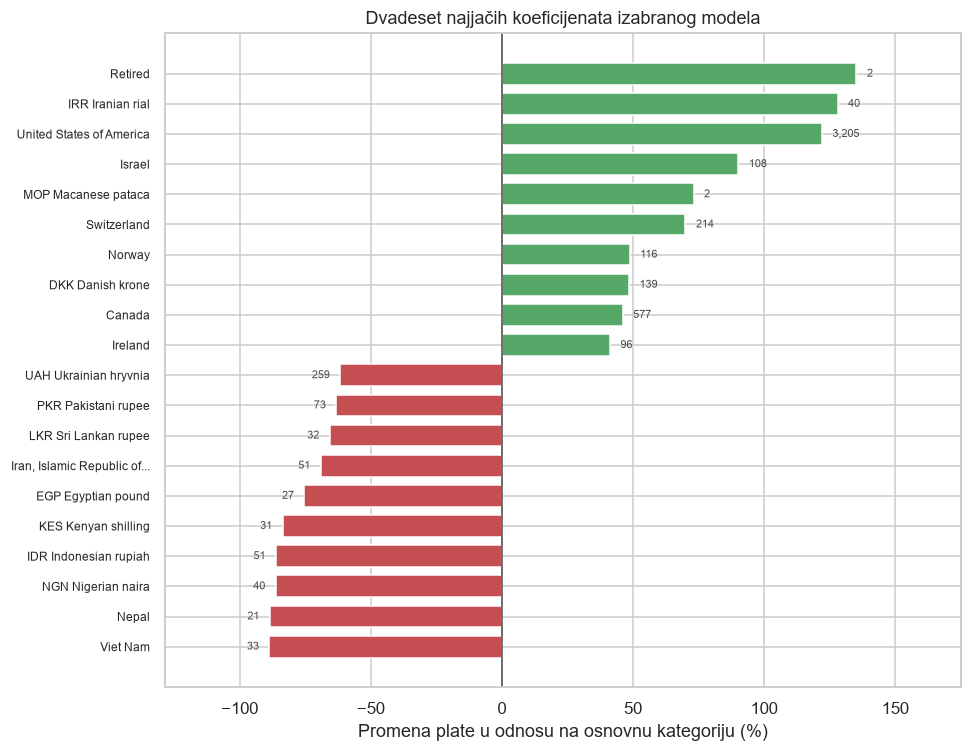

kolona                                     promena  ispitanika
DevType_Retired                            +135.2%           2
Currency_IRR Iranian rial                  +128.0%          40
Country_United States of America           +122.0%       3,205
Country_Israel                              +90.2%         108
Currency_MOP Macanese pataca                +73.1%           2
Country_Switzerland                         +70.0%         214
Country_Norway                              +48.7%         116
Currency_DKK Danish krone                   +48.5%         139
Country_Canada                              +46.1%         577
Country_Ireland                             +41.2%          96
Currency_UAH Ukrainian hryvnia              -61.6%         259
Currency_PKR Pakistani rupee                -63.1%          73
Currency_LKR Sri Lankan rupee               -65.6%          32
Country_Iran, Islamic Republic of...        -69.1%          51
Currency_EGP Egyptian pound                 -75.3%     

In [169]:
top = pd.concat([effects.nlargest(10, "promena_%"), effects.nsmallest(10, "promena_%")])
top = top.sort_values("promena_%")
labels = [name.replace("Country_", "").replace("Currency_", "").replace("DevType_", "")[:34]
          for name in top["kolona"]]

fig, ax = plt.subplots(figsize=(9, 7))
colours = ["#C44E52" if value < 0 else "#55A868" for value in top["promena_%"]]
ax.barh(range(len(top)), top["promena_%"], color=colours, height=0.72)
ax.axvline(0, color="#4C4C4C", linewidth=1)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Promena plate u odnosu na osnovnu kategoriju (%)")
ax.set_title("Dvadeset najjačih koeficijenata izabranog modela")

for position, (value, people) in enumerate(zip(top["promena_%"], top["ispitanika"])):
    offset = 4 if value > 0 else -4
    ax.text(value + offset, position, f"{int(people):,}", va="center",
            ha="left" if value > 0 else "right", fontsize=7.5, color="#4C4C4C")
ax.set_xlim(top["promena_%"].min() - 40, top["promena_%"].max() + 40)
plt.tight_layout()
plt.show()

print(f"{'kolona':<40} {'promena':>9} {'ispitanika':>11}")
for _, row in top.iloc[::-1].iterrows():
    print(f"{row['kolona'][:39]:<40} {row['promena_%']:>+8.1f}% {int(row['ispitanika']):>11,}")

**Zapažanje:** grafik pokazuje ono što se iz tabele nije videlo — **nema veze između jačine koeficijenta
i broja ispitanika na kojima je procenjen.** Najduže trake na oba kraja pripadaju kolonama sa dvocifrenim
ili jednocifrenim brojem ljudi, dok Sjedinjene Države sa **3.205** ispitanika stoje tek na trećem mestu
po jačini.

Uz to se vidi da je raspored po smeru **nesimetričan**: negativne trake idu do **−88,6%**, pozitivne do
**+135,2%**, ali su negativne gušće u opsegu preko šezdeset posto.

**Tumačenje:** nesimetričnost ima jednostavno objašnjenje. Osnovna kategorija za zemlju i valutu je ona
koja je alfabetski prva, a ne prosečna, pa se koeficijenti mere od nje — i pošto je većina ispitanika u
skupu iz zemalja sa visokim platama, više je zemalja koje su ispod te osnovice nego iznad.

Praktično, grafik je opomena za tumačenje koje sledi: **koeficijenti se ne smeju rangirati samo po
jačini.** Traka sa brojem 2 uz nju i traka sa brojem 3.205 ne znače istu vrstu tvrdnje, i to se iz same
dužine ne vidi.

### Šta sekcija ostavlja sledećoj

Koeficijenti izabranog modela pročitani su i prevedeni u procente.

Tri nalaza:

- **zemlja i valuta nose najjače koeficijente**, što potvrđuje merenje iz 2.4. Sjedinjene Države donose
  +122,0% u odnosu na osnovnu kategoriju, Vijetnam −88,6%;
- **nasleđene brojčane kolone su najzahvalnije za tumačenje**, jer se odnose na sve ispitanike i imaju
  prirodnu jedinicu: godina radnog staža +1,13%, korak u veličini firme +4,89%, poen zadovoljstva poslom
  +2,00%;
- **63 od 423 koeficijenta procenjeno je na manje od pedeset ispitanika**, a dva najjača na po dva
  čoveka. Jačina koeficijenta bez broja ispitanika ne znači ništa, pa se pozivamo samo na one sa
  razumnim brojem.

Sledeća sekcija gleda gde model greši.

## 42. Gde model greši i šta ostaje kao ograničenje

Jedan broj za ceo skup — test R² od oko 0,67 — krije to da model ne greši svuda isto. U 34.2 smo
postavili očekivanje da će greška biti veća kod ispitanika sa vrlo malim prijavljenim iznosima, a u 36.2 i
36.4 videli prve tragove toga. Ovde to merimo na test skupu, po dva osnova: po nivou plate i po zemlji.

Sve u ovoj sekciji računa se nad **predviđanjima izabranog modela na test skupu**, dakle nad ljudima koje
model nije video.

### 42.1 Greška po nivou plate

In [170]:
chosen_predictions = predictions_on_test["Lasso"]
test_error = chosen_predictions - y_test.to_numpy()
test_ratio = 10.0 ** test_error

by_level = pd.DataFrame({
    "decil": pd.qcut(test[TARGET], 10, labels=False),
    "plata": test[TARGET].to_numpy(),
    "greška": test_error,
    "odnos": test_ratio,
})
level_table = by_level.groupby("decil").agg(
    plata_medijana=("plata", "median"), ispitanika=("plata", "size"),
    prosečna_greška=("greška", "mean"),
    tipičan_promašaj=("odnos", lambda values: float(np.median(np.abs(values - 1)) * 100)),
    odnos_medijana=("odnos", "median"))

print(level_table.to_string(float_format=lambda v: f"{v:,.3f}"))
print()
print(f"prosečna greška u najnižem decilu: {level_table['prosečna_greška'].iloc[0]:+.3f} u log10, "
      f"dakle model predviđa {10 ** level_table['prosečna_greška'].iloc[0]:.2f} puta više")
print(f"prosečna greška u najvišem decilu: {level_table['prosečna_greška'].iloc[-1]:+.3f}, "
      f"dakle {10 ** level_table['prosečna_greška'].iloc[-1]:.2f} puta")
middle = level_table.iloc[2:8]["prosečna_greška"]
print(f"u šest srednjih decila greška se kreće od {middle.min():+.3f} do {middle.max():+.3f}")

       plata_medijana  ispitanika  prosečna_greška  tipičan_promašaj  odnos_medijana
decil                                                                               
0           9,299.000         366            0.331            80.175           1.802
1          31,324.000         365            0.015            32.193           1.123
2          47,922.000         367            0.004            25.360           1.064
3          61,264.000         363           -0.003            23.384           1.040
4          75,000.000         393           -0.033            20.626           1.003
5          88,171.000         337           -0.031            17.678           0.959
6         104,000.000         365           -0.035            19.124           0.941
7         125,296.000         378           -0.070            21.081           0.888
8         160,000.000         359           -0.044            19.585           0.954
9         216,000.000         359           -0.158            26.

**Zapažanje:** greška nije ista u svim decilima. U najnižem, sa medijanom plate **9.299** dolara, prosečna
greška je **+0,331** u logaritmu — model predviđa **2,14 puta** više nego što ispitanik zarađuje. U
najvišem, sa medijanom **216.000**, greška je **−0,158**, dakle **0,70 puta** stvarnog iznosa. U šest
srednjih decila kreće se od **−0,070 do +0,004**, praktično nula.

Tipičan promašaj prati isti oblik: **80,2%** u najnižem decilu, **26,5%** u najvišem, a najmanji je
**17,7%** u decilu sa medijanom 88.171 dolara.

**Tumačenje:** predznak greške menja se **jednom** duž raspona — pozitivan na dnu, negativan na vrhu — i
to je obrazac **vraćanja ka sredini**. Regresija predviđa uslovnu srednju vrednost, pa kod ispitanika
daleko od nje predviđanje vuče ka centru. Da model greši slučajno, znaci bi se mešali po decilima.

Grafik ispod pokazuje isti nalaz u dva oblika, jer se iz brojeva ne vidi da li je prelaz sa precenjivanja
na potcenjivanje gladak ili skokovit.

### Grafik 37 — greška po nivou plate

**Motivacija:** brojevi iz tabele pokazuju da greška nije ista u svim decilima, ali se iz njih ne vidi
**da li je obrazac pravilan**. Ako model podjednako promašuje na oba kraja a tačan je u sredini, to je
poznat obrazac vraćanja ka sredini i ima jedno objašnjenje; ako greši samo na jednom kraju, objašnjenje je
drugo. Crtamo prosečnu grešku po decilu, sa nulom kao referencom.

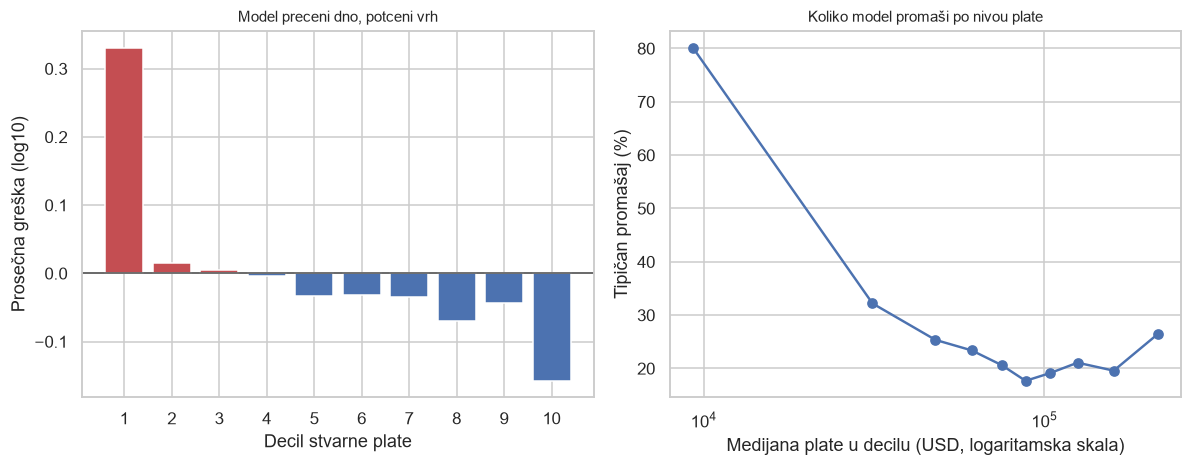

tipičan promašaj: najmanji 17.7% u decilu sa medijanom 88,171 USD
                  najveći 80.2% u decilu sa medijanom 9,299 USD
ispitanika sa platom ispod 1.000 USD u testu: 17
  njihov tipičan promašaj: 1,199%
  ostali: 23.7%


In [171]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

ax = axes[0]
colours = ["#C44E52" if value > 0 else "#4C72B0"
           for value in level_table["prosečna_greška"]]
ax.bar(range(1, 11), level_table["prosečna_greška"], color=colours)
ax.axhline(0, color="#4C4C4C", linewidth=1)
ax.set_xticks(range(1, 11))
ax.set_xlabel("Decil stvarne plate")
ax.set_ylabel("Prosečna greška (log10)")
ax.set_title("Model preceni dno, potceni vrh", fontsize=10)

ax = axes[1]
ax.plot(level_table["plata_medijana"], level_table["tipičan_promašaj"], marker="o",
        markersize=6, linewidth=1.6, color="#4C72B0")
ax.set_xscale("log")
ax.set_xlabel("Medijana plate u decilu (USD, logaritamska skala)")
ax.set_ylabel("Tipičan promašaj (%)")
ax.set_title("Koliko model promaši po nivou plate", fontsize=10)

plt.tight_layout()
plt.show()

print(f"tipičan promašaj: najmanji {level_table['tipičan_promašaj'].min():.1f}% u decilu sa medijanom "
      f"{level_table.loc[level_table['tipičan_promašaj'].idxmin(), 'plata_medijana']:,.0f} USD")
print(f"                  najveći {level_table['tipičan_promašaj'].max():.1f}% u decilu sa medijanom "
      f"{level_table.loc[level_table['tipičan_promašaj'].idxmax(), 'plata_medijana']:,.0f} USD")
low = test[TARGET].to_numpy() < 1000
print(f"ispitanika sa platom ispod 1.000 USD u testu: {int(low.sum())}")
print(f"  njihov tipičan promašaj: {100 * float(np.median(np.abs(test_ratio[low] - 1))):,.0f}%")
print(f"  ostali: {100 * float(np.median(np.abs(test_ratio[~low] - 1))):.1f}%")

**Zapažanje:** prelaz je **gladak**, ne skokovit. Leva slika pokazuje jedan visok pozitivan stubić na dnu,
zatim niz sve negativnijih, bez ijednog vraćanja u drugu stranu. Desna pokazuje da tipičan promašaj ima
oblik slova U: pada sa **80,2%** na **17,7%** oko medijane od 88.171 dolara, pa raste na **26,5%** kod
najviših plata.

Sedamnaest ispitanika u testu ima platu ispod hiljadu dolara, i njihov tipičan promašaj je **1.199%**,
naspram **23,7%** kod svih ostalih.

**Tumačenje:** oblik slova U znači da model najbolje radi tamo gde ima najviše podataka, a slabije na oba
kraja — što je i očekivano, ali je desni krak mnogo blaži od levog.

Promašaj od 1.199% kod sedamnaest ljudi pokazuje da za njih model nema nikakvu upotrebu. To je isti nalaz
koji smo u 34.2 postavili kao očekivanje a u 36.2 i 36.4 videli u obliku obrnute lepeze i netipičnih
vrednosti — i time je očekivanje potvrđeno, na test skupu i u dolarima.

Za praktičnu upotrebu iz ovoga sledi jasna granica: **model je upotrebljiv u srednjih osamdeset posto
raspona plata**, gde je tipičan promašaj između 17,7% i 32,2%. Van tog opsega predviđanja treba čitati sa
velikim rezervom, i to je tvrdnja koja se sada može potkrepiti brojem.

### 42.2 Greška po zemlji

Zemlja je najjače obeležje u modelu, pa je i prvo mesto na kom treba proveriti da li model radi
podjednako za sve. Gledamo samo zemlje sa najmanje četrdeset ispitanika u test skupu, jer se na manjem
broju prosečna greška ne može razlikovati od slučaja.

In [172]:
# Below this many respondents an average error cannot be told from chance.
MINIMUM_FOR_COUNTRY = 40

by_country = pd.DataFrame({"zemlja": test["Country"].to_numpy(), "greška": test_error,
                           "odnos": test_ratio})
country_table = by_country.groupby("zemlja").agg(
    ispitanika=("greška", "size"), prosečna_greška=("greška", "mean"),
    tipičan_promašaj=("odnos", lambda values: float(np.median(np.abs(values - 1)) * 100)))
country_table = country_table[country_table["ispitanika"] >= MINIMUM_FOR_COUNTRY]
country_table = country_table.sort_values("prosečna_greška")

print(f"zemalja sa bar {MINIMUM_FOR_COUNTRY} ispitanika u testu: {len(country_table)} "
      f"(nose {int(country_table['ispitanika'].sum()):,} od {len(test):,} ispitanika)")
print()
print("pet zemalja kod kojih model najviše potcenjuje platu:")
print(country_table.head(5).to_string(float_format=lambda v: f"{v:,.3f}"))
print()
print("pet kod kojih najviše precenjuje:")
print(country_table.tail(5).to_string(float_format=lambda v: f"{v:,.3f}"))
print()
print(f"raspon prosečne greške: od {country_table['prosečna_greška'].min():+.3f} do "
      f"{country_table['prosečna_greška'].max():+.3f} u log10")
print(f"  u odnosu: od {10 ** country_table['prosečna_greška'].min():.2f} do "
      f"{10 ** country_table['prosečna_greška'].max():.2f} puta")
print(f"tipičan promašaj: od {country_table['tipičan_promašaj'].min():.1f}% "
      f"({country_table['tipičan_promašaj'].idxmin()}) do "
      f"{country_table['tipičan_promašaj'].max():.1f}% ({country_table['tipičan_promašaj'].idxmax()})")

zemalja sa bar 40 ispitanika u testu: 20 (nose 2,887 od 3,652 ispitanika)

pet zemalja kod kojih model najviše potcenjuje platu:
             ispitanika  prosečna_greška  tipičan_promašaj
zemlja                                                    
Ukraine             122           -0.085            71.929
Switzerland          78           -0.041            14.867
France              145           -0.021            17.024
Australia            69           -0.018            17.088
Poland               91           -0.018            27.951

pet kod kojih najviše precenjuje:
          ispitanika  prosečna_greška  tipičan_promašaj
zemlja                                                 
India            180            0.008            49.515
Brazil            94            0.015            32.972
Other            122            0.027            40.288
Portugal          43            0.042            31.559
Romania           46            0.107            33.835

raspon prosečne greške: od -0.

**Zapažanje:** dvadeset zemalja ima najmanje četrdeset ispitanika u testu i one nose **2.887 od 3.652**
ispitanika.

**Prosečna greška je po zemljama mala.** Raspon ide od **−0,085** kod Ukrajine do **+0,107** kod
Rumunije, dakle od **0,82** do **1,28 puta**. Model, dakle, ni za jednu zemlju sistematski ne promašuje
više od tridesetak posto u prosečnom smeru.

**Tipičan promašaj se razlikuje mnogo više** — od **14,0%** u Austriji do **71,9%** u Ukrajini.

**Tumačenje:** razlika između tih dveju mera je ono što treba pročitati.

Mala prosečna greška znači da model **nije pristrasan po zemljama**: ne postoji zemlja za koju
sistematski predviđa previsoko ili prenisko. To je i očekivano, jer zemlja u modelu ima svoju kolonu, pa
model za svaku uči sopstveni nivo.

Veliki tipičan promašaj kod pojedinih zemalja znači da unutar njih model **slabo razlikuje ljude**. Kod
Ukrajine je promašaj 71,9% uz prosečnu grešku svega −0,085 — dakle greši u obe strane podjednako. To je
ista grupa koja se javlja kroz celu sekciju: u prethodnom delu smo izmerili da su ispitanici sa
prijavljenim iznosima ispod hiljadu dolara najviše iz Ukrajine.

Iz ovoga sledi jedna korisna tvrdnja: kvalitet predviđanja se razlikuje po zemljama, ali
razlika nije u pristrasnosti nego u **rasipanju** — što je manji problem, jer ne
iskrivljuje zaključke nego samo ograničava tačnost.

### 42.3 Šta ostaje kao ograničenje

Tri stvari ovaj model ne rešava i treba ih reći izričito, jer se iz brojeva u prethodnim odeljcima ne
čitaju same.

**Uzorak nije slučajan uzorak programera.** U njemu su ljudi koji su popunili anketu Stack Overflow-a i
prijavili platu. U prethodnom delu smo izmerili da prijavljivanje plate zavisi od posmatranih
obeležja — zemlja, veličina firme, način rada — i da brisanje redova bez plate pomera sastav uzorka.
Model, dakle, opisuje **tu populaciju**, a ne sve programere, i predviđanja za nekoga van nje nemaju
zagarantovanu vrednost.

**Ispitanici sa vrlo malim prijavljenim iznosima ostaju nerešeni.** Njih smo zadržali svesno, jer bi svaka
apsolutna donja granica bila izmišljen broj, i cenu te odluke sada vidimo na tri mesta: obrnuta lepeza u
3.2, gušći levi rep u 3.3, i najveća greška u prvom decilu u 9.1. Alternativa — izbaciti ih — popravila bi
sve tri mere, ali bi značila da podatke prilagođavamo modelu.

**Ideja o samopopunjavanju ciljne promenljive nije izvedena.** U izveštaju poslatom na odobrenje pominjali
smo mogućnost da se model istreniran na onima koji su prijavili platu upotrebi da popuni ostale, pa da se
trenira ponovo. Nju **ne radimo**, i razlog je merenje iz prethodnog dela: nedostajanje plate nije
slučajno, pa bi model popunjavao onim što je naučio na sistematski drugačijoj grupi i time **učvrstio
sopstvenu pristrasnost**, a rezultat bi izgledao bolje jer se meri na podacima koje je sam napravio. Za
ozbiljan pokušaj bilo bi potrebno i sačuvati redove bez prijavljene plate, koji u isporučenim podacima ne
postoje. Ostaje kao predlog za dalji rad, uz obavezno poređenje sa osnovnim modelom, a ne kao zamena za
njega.

### Šta sekcija ostavlja sledećoj

Model greši **pravilno**, i to je jedan od korisnijih nalaza ovog dela.

Tri nalaza:

- **greška prati nivo plate.** Na dnu model preceni 2,14 puta, na vrhu potceni na 0,70, a u šest srednjih
  decila greška je praktično nula. To je vraćanje ka sredini i sledi iz toga što regresija predviđa
  uslovnu srednju vrednost;
- **model je upotrebljiv u srednjih osamdeset posto raspona**, gde je tipičan promašaj između 17,7% i
  32,2%. Kod sedamnaest ispitanika sa platom ispod hiljadu dolara promašaj je 1.199% i model za njih nema
  upotrebu;
- **po zemljama model nije pristrasan ali je nejednako tačan.** Prosečna greška ide od 0,82 do 1,28 puta,
  a tipičan promašaj od 14,0% u Austriji do 71,9% u Ukrajini.

Ostaje da se predviđanja i koeficijenti sačuvaju i da se izvuče zaključak.

## 43. Čuvanje i zaključak

Iz ovog dela izlaze dve stvari koje vredi sačuvati, i nijedna nije sam model — njega bi svako ponovno
pokretanje dalo isti, jer su svi izbori zapisani u kodu.

**Predviđanja na test skupu**, uz stvarnu platu i grešku, da se svaka tvrdnja iz devete sekcije može
proveriti bez ponovnog računanja. **Koeficijenti izabranog modela**, prevedeni u promenu u procentima i sa
brojem ispitanika koji ih podupire, jer je to tabela na koju se poziva osma sekcija.

Oba idu u `data/processed/`, pored postojećih fajlova.

In [173]:
predictions_frame = pd.DataFrame({
    "ConvertedCompYearly": test[TARGET].to_numpy(),
    "log_comp": y_test.to_numpy(),
    "predicted_log_comp": chosen_predictions,
    "predicted_usd": 10.0 ** chosen_predictions,
    "error_log": test_error,
    "ratio_predicted_actual": test_ratio,
    "Country": test["Country"].to_numpy(),
})
coefficients_frame = effects.rename(columns={
    "kolona": "column", "koef_log10": "coefficient_log10",
    "promena_%": "change_percent", "ispitanika": "respondents"}
).sort_values("change_percent", ascending=False)

predictions_path = PROCESSED_DIR / "test_predictions.csv.gz"
coefficients_path = PROCESSED_DIR / "model_coefficients.csv"
predictions_frame.to_csv(predictions_path, index=False, encoding="utf-8", compression="gzip")
coefficients_frame.to_csv(coefficients_path, index=False, encoding="utf-8")

for path in (predictions_path, coefficients_path):
    print(f"{path.name:<28} {path.stat().st_size / 1024:>7.1f} kB")
print()

# Read back, because writing and reading a file can change what is in it.
predictions_check = pd.read_csv(predictions_path)
coefficients_check = pd.read_csv(coefficients_path)
print(f"predviđanja: {predictions_check.shape[0]:,} redova x {predictions_check.shape[1]} kolona")
print(f"koeficijenti: {coefficients_check.shape[0]:,} redova x {coefficients_check.shape[1]} kolona")
print(f"test R² ponovo izračunat iz fajla: "
      f"{metrics(predictions_check['log_comp'], predictions_check['predicted_log_comp'])['R2']:.4f}")
print()
print("konačna tabela svih modela, unakrsna validacija i test:")
summary = pd.DataFrame({
    "unakrsni_R2": [reference.loc[cv, "R2"] for _, cv in pairs],
    "test_R2": [on_test.loc[t, "R2"] for t, _ in pairs],
    "test_promašaj_%": [on_test.loc[t, "promašaj_%"] for t, _ in pairs],
    "test_u_okviru_2x": [on_test.loc[t, "u_okviru_2x"] for t, _ in pairs],
}, index=[t for t, _ in pairs])
print(summary.to_string(float_format=lambda v: f"{v:.4f}"))

test_predictions.csv.gz        175.4 kB
model_coefficients.csv          34.6 kB

predviđanja: 3,652 redova x 7 kolona
koeficijenti: 423 redova x 4 kolona
test R² ponovo izračunat iz fajla: 0.6720

konačna tabela svih modela, unakrsna validacija i test:
                   unakrsni_R2  test_R2  test_promašaj_%  test_u_okviru_2x
medijana treninga      -0.0330  -0.0345          43.7943           66.3198
sama zemlja             0.5429   0.5401          32.0820           78.3406
obična regresija        0.6769   0.6673          24.2983           87.2399
PCR                     0.6695   0.6585          24.7792           86.7470
Ridge                   0.6798   0.6687          24.5207           87.4042
Lasso                   0.6845   0.6720          23.8348           87.6232


**Zapažanje:** oba fajla su zapisana i pročitana nazad. Predviđanja imaju **3.652 reda i 7 kolona**,
koeficijenti **423 reda i 4 kolone**, a test R² ponovo izračunat iz fajla iznosi **0,6720** — isto kao
pre čuvanja.

**Tumačenje:** provera čitanjem je ista ona koju smo radili u prethodnom delu i ima isti razlog:
zapis u CSV i čitanje nazad mogu da promene tip kolone. Pošto se test R² iz fajla poklapa sa onim iz
sekcije 40, fajl sadrži ono što mislimo da sadrži.

Konačna tabela na kraju ispisa sabira ceo ovaj deo — svih šest modela, unakrsni i test rezultat
jedan uz drugi.

## Zaključak dela

Pošli smo od 429 kolona iz prethodnog dela, a završavamo sa jednim izabranim modelom i merenjem
koje se može braniti.

**Izabrani model je Lasso** sa λ = 0,00155, koji koristi **423 od 707 kolona**. Na test skupu daje
**R² 0,6720**, tipičan promašaj **23,8%** odnosno **16.630 dolara**, a kod **87,6%** ispitanika
predviđanje je u okviru dvostruko. Naspram same zemlje, koja na testu daje 0,5401, to je **+0,1320**.

Put do tog rezultata bio je sledeći:

1. **Merila postavljena pre prvog modela** — RMSE, MAE i R² u logaritmu, prevedeni u promašaj u
   procentima i dolarima, sve preko unakrsne validacije sa deset delova. Uz njih tri izmerena stepenika:
   konstanta (−0,0001), najjače pojedinačno obeležje `Country` (0,5429) i sva anketna obeležja bez ijedne
   naše promenljive (0,6668).
2. **Izmereno koliko slobode model ima** — na nasumično promešanoj ciljnoj promenljivoj regresija sa 709
   kolona dobija R² 0,0471 na treningu, a −0,0573 po unakrsnoj validaciji. Time je unapred bilo poznato
   koliko trening rezultat precenjuje model.
3. **Obična regresija** — unakrsni R² 0,6769. Dijagnostika je pokazala da linearnost stoji, a
   ujednačenost rasipanja i normalnost ostatka ne stoje, pa se p-vrednosti koeficijenata ne smeju čitati
   kao pouzdane. Uticajnih opservacija nema, ali četiri ispitanika model uči napamet.
4. **Ridge** — 0,6798, dakle +0,0029. Kazna jasno smanjuje koeficijente ali skoro ne menja grešku, pa
   veliki koeficijenti nisu bili problem.
5. **Lasso** — 0,6845 uz 284 kolone ukinute. Problem je, dakle, bio **broj** kolona.
6. **Regresija na glavne komponente** — 0,6695, najslabija, jer PCA poređa komponente po varijansi
   prediktora a ne po vezi sa platom.
7. **Formalna selekcija** — Cp, AIC i unakrsna validacija slažu se na 423 kolone; BIC bi izabrao 145 uz
   gubitak 0,0322, prilagođeni R² 517 uz dobitak 0,0007.

**Tri nalaza koja vredi izdvojiti:**

**Doprinos prethodnog dela je stvaran ali skroman.** Naših 352 kolone dodaju **+0,0101** unakrsnog
R² preko svega što anketa daje sama. Na trening skupu je izgledao znatno veći, a razlika je upravo ono
prilagođavanje šumu koje smo izmerili na početku.

**Lasso se ne slaže sa svim našim hipotezama.** Sve 16 kolona `Count_` i svih 7 `KeptShare_` spustio je na
nulu, dok je od 314 kolona po stavci zadržao 168. To ne obara Hipotezu 6 — ona je merila da brojevi nose
signal preko zemlje i staža, i nosili su ga — ali pokazuje da u društvu sa kolonama po stavci postaju
suvišni, jer su njihov zbir.

**Poredak modela na testu je isti kao po unakrsnoj validaciji.** To je najbolji dokaz da postupak nije
biran prema ishodu: svi izbori napravljeni su nad trening skupom, a test ih je potvrdio.

**Šta ostaje otvoreno:**

- **Model je upotrebljiv u srednjih osamdeset posto raspona plata.** Na dnu preceni 2,14 puta, na vrhu
  potceni na 0,70, a kod sedamnaest ispitanika sa platom ispod hiljadu dolara promašaj je 1.199%.
- **Uzorak nije slučajan uzorak programera** nego onih koji su popunili anketu i prijavili platu, a
  prijavljivanje zavisi od posmatranih obeležja.
- **Interakcije nisu probane.** Razlike postojećih kolona odbačene su u prethodnom delu jer ih
  linearni model pravi sam; proizvodi i odnosi to nisu, i ostaju kao mogućnost.
- **Samopopunjavanje ciljne promenljive nije izvedeno**, iz razloga navedenih u 9.3, i za ozbiljan
  pokušaj bilo bi potrebno sačuvati i redove bez prijavljene plate.
- **Nelinearni modeli nisu probani.** Stabla i ansambli nisu deo gradiva ovog predmeta, pa su izvan
  obima rada, ali bi bili prvi sledeći korak.